# Generate the HMM description, AMG, APG, AReG, viral hallmark gene, and MGE/mobility gene tables

**Will need:**

**1.** [Table of V- and VL-scores](https://raw.githubusercontent.com/AnantharamanLab/V-Score-Search/refs/heads/main/Database/VScoreData.csv) from [Zhou et al. (2024)](https://doi.org/10.1101/2024.10.24.619987)
* Last accessed: 16 October 2025
* Version: V-Score Search commit `9f8adbb` (16 April 2025)

**2.** [KEGG BRITE table 09100 (KO)](https://www.kegg.jp/kegg-bin/download_htext?htext=ko00001&format=htext&filedir=) containing KOs categorized by their BRITE hierarchy / functional categories
* Last accessed: 16 December 2025
* Version last modified 16 December 2025

**3.** [PHROG annotation table](https://phrogs.lmge.uca.fr/downloads_from_website/phrog_annot_v4.tsv)
* Last accessed: 16 December 2025
* Version: PHROG release v4 (15 June 2022)

**2.** [List of CAZy activities](https://bcb.unl.edu/dbCAN2/download/Databases/V12/CAZyDB.08062022.fam-activities.txt) from CAZyDB ([Drula et al., 2022 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gkab1045))
* Last accessed: 16 October 2025
* Version: dbCAN HMMdb v12 (`CAZyDB.08062022.fam-activities.txt`) (02 August 2023)

**3.** `hmm_table_template.txt` from METABOLIC ([Zhou et al., 2022 *Microbiome*](https://doi.org/10.1186/s40168-021-01213-8)) - maps METABOLIC's custom HMMs to functions ([link](https://github.com/AnantharamanLab/METABOLIC/raw/refs/heads/master/METABOLIC_template_and_database.tgz))
* Last accessed: 16 October 2025
* Version: METABOLIC commit "e2f1de6" (12 June 2023)

**4.** [`FOAM-hmm_rel1a.hmm.gz`](https://osf.io/5ba2v/files/bdpv5) from the Functional Ontology Assignments for Metagenomes (FOAM) database ([Prestat et al., 2014 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gku702))
* Last accessed: 16 October 2025
* Version modified: 10 January 2023

**5.** [`FOAM-onto_rel1.tsv`](https://osf.io/5ba2v/files/muan4) - FOAM annotations/functions table
* Last accessed: 16 October 2025
* Version last modified 10 January 2023

**6.** [`CAMPER_hmm_scores.tsv`](https://raw.githubusercontent.com/WrightonLabCSU/CAMPER/refs/heads/main/CAMPER_hmm_scores.tsv) from the [Curated Annotations for Microbial (Poly)phenol Enzymes and Reactions (CAMPER)](https://github.com/WrightonLabCSU/CAMPER/tree/main) database ([McGivern et al., 2024](https://doi.org/10.1101/2023.09.24.559193))
* Last accessed: 15 December 2025
* Version last modified 20 September 2023

**7.** [`amg_database.tsv`](https://raw.githubusercontent.com/WrightonLabCSU/DRAM/refs/heads/master/data/amg_database.tsv) from the DRAM-V AMG database ([Shaffer et al., 2020 *Nucleic Acids Res*](https://doi.org/10.1093/nar/gkaa621))
* Last accessed: 11 December 2025
* Version last modified 3 March 2020

**8.** `plasmid_hallmark_annotation.txt` from the [geNomad database](https://zenodo.org/records/14886553) ([Camargo et al., 2024 *Nat Biotechnol*](https://doi.org/10.1038/s41587-023-01953-y))
* Last accessed: 16 October 2025
* Version: 1.9 (18 February 2025)

**9.** Recoded PHROG functional categories (`phrog_catetories_recoded.tsv`) from [Martin et al. (2025 *Nat Commun*)](https://doi.org/10.1038/s41467-025-66049-4)
* Last accessed: 22 May 2026
* Version: PHROG v4 recoded (Martin et al. 2025)

For demonstration, these were pre-downloaded and are located in the `data` folder **except** for the FOAM `.hmm` file. Since this is a part of the CheckAMG database, it can be found in the database folder created when running `CheckAMG download`.

In [1]:
! pip install pandas matplotlib adjustText --quiet

In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', 100)
from difflib import SequenceMatcher
from collections import defaultdict
import os
import re

## 1. Reformat the V-Score table

In [3]:
vscores = pd.read_csv("./data/VScoreData.csv")
vscores = vscores.rename(
    columns={
        "Accession": "id",
        "Protein Function": "name",
        "V-Score": "V-score",
        "Log10[Hit Number]": "VL-score",
        "Database Origin": "db"
    }
)
vscores = vscores[vscores.db.isin(["KEGG", "Pfam", "PHROG"])] # Remove databases that aren't used by CheckAMG

# Remove duplicates if any
vscores = vscores.drop_duplicates(subset=['id', 'name', 'db'])
vscores

,id,name,V-score,VL-score,db
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG
1,K14059,integrase,10.00,4.882297,KEGG
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG
3,K00571,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72],10.00,4.829278,KEGG
4,K06909,phage terminase large subunit,10.00,4.826871,KEGG
...,...,...,...,...,...
243425,phrog_22476,NaN,0.01,0.000000,PHROG
243426,phrog_4110,NaN,0.01,0.000000,PHROG
243427,phrog_17200,NaN,0.01,0.000000,PHROG
243428,phrog_6460,NaN,0.01,0.000000,PHROG


In [4]:
vscores.to_csv("../CheckAMG/files/vscores.tsv", sep="\t", index=False)

## 2. Construct the all HMM/ID to description/function table

### 2.1. Add the protein families from KEGG

In [5]:
kegg_path = './data/ko00001.keg'

a_id = a_name = None
b_id = b_name = None
c_id = c_name = c_path = None

rows = []

ra = re.compile(r"^A\s*([0-9]{5})\s+(.*)$")
rb = re.compile(r"^B\s*([0-9]{5})\s+(.*)$")
rc = re.compile(r"^C\s*([0-9]{5})\s+(.*)$")
rd = re.compile(r"^D\s*(K[0-9]{5})\s+(.*)$")
rpath = re.compile(r"\[PATH:(ko[0-9]{5})\]")

with open(kegg_path, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        s = line.strip()
        if not s or s[0] in "#!+":
            continue
        if s in {"A", "B", "C", "D"}:
            continue

        m = ra.match(s)
        if m:
            a_id, a_name = m.group(1), m.group(2).strip()
            b_id = b_name = None
            c_id = c_name = c_path = None
            continue

        m = rb.match(s)
        if m:
            b_id, b_name = m.group(1), m.group(2).strip()
            c_id = c_name = c_path = None
            continue

        m = rc.match(s)
        if m:
            c_id, c_name = m.group(1), m.group(2).strip()
            mp = rpath.search(c_name)
            c_path = mp.group(1) if mp else None
            continue

        m = rd.match(s)
        if m:
            rows.append(
                {
                    "KO": m.group(1),
                    "A_id": a_id,
                    "A_name": a_name,
                    "B_id": b_id,
                    "B_name": b_name,
                    "C_id": c_id,
                    "C_name": c_name,
                    "C_path": c_path,
                    "D_desc": m.group(2).strip(),
                }
            )

ko_brite =  pd.DataFrame(rows)
ko_brite

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
0,K00844,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,HK; hexokinase [EC:2.7.1.1]
1,K12407,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,GCK; glucokinase [EC:2.7.1.2]
2,K00845,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
3,K25026,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
4,K01810,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,"GPI, pgi; glucose-6-phosphate isomerase [EC:5.3.1.9]"
...,...,...,...,...,...,...,...,...,...
63765,K07220,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07220; uncharacterized protein
63766,K07276,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07276; uncharacterized protein
63767,K07338,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,K07338; uncharacterized protein
63768,K07586,09190,Not Included in Pathway or Brite,09194,Poorly characterized,99997,Function unknown,None,ygaC; uncharacterized protein


In [6]:
kegg_desc = ko_brite[['KO', 'D_desc']].rename(columns={'KO':'id', 'D_desc':'name'})
kegg_desc["db"] = "KEGG"
kegg_desc = kegg_desc[['id', 'db', 'name']].drop_duplicates().sort_values(by='id').reset_index(drop=True)
kegg_desc

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
28003,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
28004,K28730,KEGG,XG; glycoprotein XG
28005,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
28006,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


In [7]:
len(kegg_desc["id"].unique()), len(kegg_desc)

(28008, 28008)

In [8]:
kegg_desc[kegg_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.2. Add the protein families from Pfam
Parse the `Pfam-A.hmm` file in the CheckAMG database directly to ensure exact version numbers match.

In [9]:
pfam_hmm_path = "CheckAMG_annotate_db_v1.1_20260316/Pfam-A.hmm"

In [10]:
pfam_to_function = {}

import re
from collections import defaultdict
from difflib import SequenceMatcher

with open(pfam_hmm_path, "r") as f:
    acc = None
    kos = []

    for line in f:
        if line.startswith("ACC"):
            acc = line.split()[1].strip()

        elif line.startswith("DESC"):
            function = line[5:].strip()
            pfam_to_function[acc] = function

        elif line.strip() == "//" and acc:
            acc = None
            function = None

In [11]:
pfam_desc = pd.DataFrame.from_dict(pfam_to_function, orient='index', columns=['name']).reset_index().rename(columns={'index':'id'})
pfam_desc["db"] = "Pfam"
pfam_desc = pfam_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
pfam_desc

,id,db,name
0,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family)
1,PF00002.30,Pfam,7 transmembrane receptor (Secretin family)
2,PF00003.29,Pfam,7 transmembrane sweet-taste receptor of 3 GCPR
3,PF00004.36,Pfam,ATPase family associated with various cellular activities (AAA)
4,PF00005.34,Pfam,ABC transporter
...,...,...,...
30129,PF31274.1,Pfam,"Restriction endonuclease CglI H-subunit, C-terminal domain"
30130,PF31275.1,Pfam,Testis-expressed protein 51
30131,PF31276.1,Pfam,Family of unknown function (DUF8849)
30132,PF31277.1,Pfam,Antimicrobial peptide damicornin


In [12]:
len(pfam_desc["id"].unique()), len(pfam_desc)

(30134, 30134)

In [13]:
pfam_desc[pfam_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.3. Add the protein families from PHROG

In [14]:
phrog_path = "./data/phrog_annot_v4.tsv"
phrog_annots = pd.read_csv(phrog_path, sep="\t")
phrog_annots["phrog_id"] = phrog_annots["phrog"].apply(lambda x: "phrog_" + str(x))
phrog_annots

,phrog,color,annot,category,phrog_id
0,1,#fea328,integrase,integration and excision,phrog_1
1,2,#3e83f6,terminase large subunit,head and packaging,phrog_2
2,3,#a861e3,transcriptional repressor,transcription regulation,phrog_3
3,4,#a861e3,transcriptional repressor,transcription regulation,phrog_4
4,5,#35d7ff,tail completion or Neck1 protein,connector,phrog_5
...,...,...,...,...,...
109399,109400,#c9c9c9,NaN,unknown function,phrog_109400
109400,109401,#c9c9c9,NaN,unknown function,phrog_109401
109401,109402,#c9c9c9,NaN,unknown function,phrog_109402
109402,109403,#c9c9c9,NaN,unknown function,phrog_109403


In [15]:
phrog_desc = phrog_annots[["phrog", "annot"]].copy()
phrog_desc["phrog"] = "phrog_" + phrog_desc["phrog"].astype(str)
phrog_desc = phrog_desc.rename(columns={"phrog": "id", "annot": "name"})
phrog_desc["db"] = "PHROG"
phrog_desc = phrog_desc[["id", "db", "name"]].sort_values("id").reset_index(drop=True)
phrog_desc

,id,db,name
0,phrog_1,PHROG,integrase
1,phrog_10,PHROG,major head protein
2,phrog_100,PHROG,SbcD-like subunit of palindrome specific endonuclease
3,phrog_1000,PHROG,NaN
4,phrog_10000,PHROG,NaN
...,...,...,...
109399,phrog_99995,PHROG,NaN
109400,phrog_99996,PHROG,NaN
109401,phrog_99997,PHROG,NaN
109402,phrog_99998,PHROG,NaN


In [16]:
len(phrog_desc["id"].unique()), len(phrog_desc)

(109404, 109404)

In [17]:
phrog_desc[phrog_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.4. Add the protein families from the dbCAN3 (CAZy) database

In [18]:
cazy_file_path = './data/CAZyDB.08062022.fam-activities.txt'

# Read the file, skipping lines that start with '#', and replacing '\t' within fields with a space
cazy = []
with open(cazy_file_path, 'r') as file:
    for line in file:
        if not line.startswith('#'):
            # Replace '\t' within fields with a space
            parts = line.split('\t')
            if len(parts) > 2:
                cleaned_line = parts[0] + '\t' + ' '.join(parts[1:])
            else:
                cleaned_line = line
            cazy.append(cleaned_line.strip().split('\t', 1))  # Split into two columns only on the first tab

# Convert the cleaned data into a DataFrame
cazy_desc = pd.DataFrame(cazy, columns=['id', 'name'])
# Remove leading whitespace from the 'name' column
cazy_desc['name'] = cazy_desc['name'].str.lstrip()

cazy_desc["db"] = "dbCAN"
cazy_desc = cazy_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
cazy_desc

,id,db,name
0,AA0,dbCAN,None
1,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...
2,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...
3,AA11,dbCAN,AA11 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of chit...
4,AA12,dbCAN,The pyrroloquinoline quinone-dependent oxidoreductase activity was demonstrated for the CC1G_095...
...,...,...,...
461,PL5,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
462,PL6,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
463,PL7,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
464,PL8,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [19]:
len(cazy_desc["id"].unique()), len(cazy_desc)

(466, 466)

In [20]:
cazy_desc[cazy_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.5. Add the protein families from the METABOLIC database

In [21]:
# Define the path to the table file
table_file_path = './data/hmm_table_template.txt'

# Read the table into a pandas DataFrame
table_df = pd.read_csv(table_file_path, sep='\t')

# Lengthen the dataframe by splitting the "Hmm file" column based on commas
lengthened_df = table_df.assign(**{
    'Hmm file': table_df['Hmm file'].str.split(',')
}).explode('Hmm file')

# Strip whitespace and ".hmm" from the "Hmm file" to form the "id"
lengthened_df['id'] = lengthened_df['Hmm file'].str.strip().str.replace('.hmm', '', regex=False)

# Conditionally select the "name" column based on whether "id" equals "Gene name"
lengthened_df['name'] = lengthened_df.apply(
    lambda row: row['Function'] if row['id'] == row['Gene name'] else row['Gene name'],
    axis=1
)

# Select relevant columns for the metabolic_desc table
metabolic_desc = lengthened_df[['id', 'name']]

# Add the constant "db" column with the value "METABOLIC"
metabolic_desc['db'] = 'METABOLIC'

# Remove duplicates if any
metabolic_desc = metabolic_desc.drop_duplicates()
metabolic_desc = metabolic_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
metabolic_desc

/tmp/ipykernel_734310/2287037470.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metabolic_desc['db'] = 'METABOLIC'


,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
323,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
324,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
325,sulfocyanin,METABOLIC,Iron oxidation
326,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


In [22]:
len(metabolic_desc["id"].unique()), len(metabolic_desc)

(326, 328)

In [23]:
metabolic_desc[metabolic_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name
26,K00001,METABOLIC,acetaldehyde => ethanol
27,K00001,METABOLIC,alcohol dehydrogenase
57,K00812,METABOLIC,aspartate aminotransferase
58,K00812,METABOLIC,aspartate/tyrosine/aromatic aminotransferase


Resolve the duplicates by keeping the first names for each duplicated KO

In [24]:
metabolic_desc = (
    metabolic_desc
    .sort_values(["id"])  # optional: makes "first" deterministic by id
    .drop_duplicates(subset=["id"], keep="first")
    .reset_index(drop=True)
)
metabolic_desc

,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
321,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
322,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
323,sulfocyanin,METABOLIC,Iron oxidation
324,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


### 2.6. Add families from the FOAM database

#### 2.6.1. Map FOAM HMMs to their respective KOs

In [25]:
foam_annots = pd.read_csv('./data/FOAM-onto_rel1.tsv', sep='\t')
foam_annots = foam_annots[foam_annots["L1"].notnull()] # The table has one weird row with empty data at the very end
foam_annots

,L1,L2,L3,L4,KO,Function,EC
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00134,"GAPDH, gapA; glyceraldehyde 3-phosphate dehydrogenase",1.2.1.12
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00603,fctD; glutamate formiminotransferase / 5-formyltetrahydrofolate cyclo-ligase,2.1.2.5 6.3.3.2
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K13990,FTCD; glutamate formiminotransferase / formiminotetrahydrofolate cyclodeaminase,2.1.2.5 4.3.1.4
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00918,pfkC; ADP-dependent phosphofructokinase/glucokinase,2.7.1.146 2.7.1.147
...,...,...,...,...,...,...,...
6820,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K05361,GPX4; phospholipid-hydroperoxide glutathione peroxidase,1.11.1.12
6821,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K00428,E1.11.1.5; cytochrome c peroxidase,1.11.1.5
6822,21_Cellular response to stress,Response to oxidative stress,NaN,NaN,K11207,TDPX; glutathione peroxidase-type tryparedoxin peroxidase,1.11.1.-
6823,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K00697,otsA; trehalose 6-phosphate synthase,2.4.1.15 2.4.1.347


In [26]:
foam_hmm_path = "CheckAMG_annotate_db_v1.1_20260316/FOAM.hmm"

In [27]:
import re
from collections import defaultdict

acc_to_kos = defaultdict(list)
cutoffs = {}

with open(foam_hmm_path, "r") as f:
    acc = None
    kos = []

    for line in f:
        if line.startswith("NAME") or line.startswith("DESC"):
            matches = re.findall(r"KO:(K\d+)", line)
            if matches:
                kos.extend(matches)

        elif line.startswith("ACC"):
            acc = line.split()[1].strip()
            acc_to_kos.setdefault(acc, []) # ensure present even if no KOs

        elif line.startswith("TC") and acc:
            parts = line.split()
            if len(parts) > 2:
                cutoffs[acc] = (float(parts[1]), float(parts[2].rstrip(";")))
            elif len(parts) == 2:
                cutoffs[acc] = (float(parts[1]), None)

        elif line.strip() == "//" and acc:
            acc_to_kos[acc] = sorted(set(kos)) # empty list if none found
            acc = None
            kos = []

# handle file missing trailing // (still include acc with empty list)
if acc is not None:
    acc_to_kos[acc] = sorted(set(kos))

In [28]:
acc_to_kos_df = pd.DataFrame(
    [(acc, ko) for acc, kos in acc_to_kos.items() for ko in kos],
    columns=["HMM", "KO"],
)
foam_annots_hmm_mapped = foam_annots.merge(
    acc_to_kos_df,
    left_on="KO",
    right_on="KO",
    how="inner"
)
foam_annots_hmm_mapped

,L1,L2,L3,L4,KO,Function,EC,HMM
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238
...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359


#### 2.6.2. Mark cases where an HMM was assigned >1 KO

In [29]:
foam_multi_KO = foam_annots_hmm_mapped[foam_annots_hmm_mapped.groupby("HMM")["KO"].transform("nunique") > 1].sort_values(by='HMM')
foam_multi_KO

,L1,L2,L3,L4,KO,Function,EC,HMM
82378,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02032,ddpF; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil10
81616,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02031,ddpD; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil10
83099,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,Microcin c transporter [mD:m00349],K13896,yejF; microcin C transport system ATP-binding protein,NaN,HMMsoil10
181142,21_Cellular response to stress,Response to osmotic stress,NaN,NaN,K02484,"K02484; two-component system, OmpR family, sensor kinase",2.7.13.3,HMMsoil100048
141614,21_Cellular response to stress,Cellular response to osmotic stress,NaN,NaN,K02484,"K02484; two-component system, OmpR family, sensor kinase",2.7.13.3,HMMsoil100048
...,...,...,...,...,...,...,...,...
82195,12_Transporters,"ABC transporters, prokaryotic type",PEPtide and nickel transporters,PEPtides/nickel transporter [mD:m00239],K02031,ddpD; peptide/nickel transport system ATP-binding protein,NaN,HMMsoil99937
74715,12_Transporters,"ABC transporters, prokaryotic type",Oligosaccharide and polyol transporters,Multiple sugar transporter [mD:m00207],K02026,ABC.MS.P1; multiple sugar transport system permease protein,NaN,HMMsoil99951
73421,12_Transporters,"ABC transporters, prokaryotic type",Oligosaccharide and polyol transporters,Lactose/l-arabinose transporter [mD:m00199],K10190,"lacG, araQ; lactose/L-arabinose transport system permease protein",NaN,HMMsoil99951
62491,09_Carbohydrate Active enzyme - CAZy,Carbohydrate esterase,NaN,NaN,K01044,CES1; carboxylesterase 1,3.1.1.1,HMMsoil99977


In [30]:
foam_annots_hmm_mapped["HMM_N_KOs"] = foam_annots_hmm_mapped.groupby("HMM")["KO"].transform("nunique")
foam_annots_hmm_mapped

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1
...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1


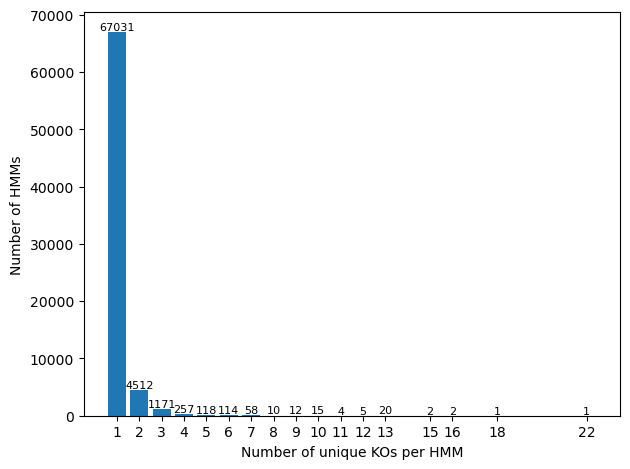

In [31]:
import matplotlib.pyplot as plt

n_ko_per_foam = foam_annots_hmm_mapped[["HMM", "HMM_N_KOs"]].drop_duplicates()
counts = (
    n_ko_per_foam["HMM_N_KOs"]
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure()
bars = plt.bar(counts.index, counts.values)

plt.xlabel("Number of unique KOs per HMM")
plt.ylabel("Number of HMMs")
plt.xticks(counts.index)

for x, y in zip(counts.index, counts.values):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

#### 2.6.2. Assign functions/names to FOAM HMMs
Since it's relatively rare that a FOAM HMM was assigned >1 KO, we will have HMM descriptions be a concatenation of all unique functions.

In [32]:
foam_hmm_named = foam_annots_hmm_mapped.copy()

def _clean(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    s = str(x).strip()
    return "" if s.lower() in {"nan", "none", "null"} else s

def _pick_name_row(r):
    fn = _clean(r.get("Function", ""))
    if fn:
        return fn
    for col in ["L4", "L3", "L2", "L1"]:
        v = _clean(r.get(col, ""))
        if v:
            return v
    return ""

def _fmt_fn_ec(fn, ec):
    fn = _clean(fn)
    ec = _clean(ec)
    if not ec:
        return fn

    ecs = [e for e in ec.split() if e]
    if not ecs:
        return fn

    def _ensure_prefix(e):
        e = e.strip()
        if not e:
            return ""
        return e if e.lower().startswith("ec:") else f"[EC:{e}]"

    ecs_fmt = " ".join(_ensure_prefix(e) for e in ecs if _ensure_prefix(e))
    if fn:
        return f"{fn} {ecs_fmt}"
    return ecs_fmt

base_name = foam_hmm_named.apply(_pick_name_row, axis=1)
foam_hmm_named["_fn_ec"] = [_fmt_fn_ec(n, e) for n, e in zip(base_name, foam_hmm_named["EC"])]

foam_hmm_named["HMM_name"] = (
    foam_hmm_named.groupby("HMM")["_fn_ec"]
      .transform(lambda s: "; ".join(pd.Series(s).astype(str).str.strip().replace("", pd.NA).dropna().drop_duplicates()))
)

foam_hmm_named.drop(columns=["_fn_ec"], inplace=True)
foam_hmm_named

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
...,...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]


In [33]:
foam_hmm_named.to_csv('../CheckAMG/files/FOAM.tsv', sep='\t', index=False)

In [34]:
foam_desc = foam_hmm_named[["HMM", "HMM_name"]].drop_duplicates().rename(columns={"HMM": "id", "HMM_name": "name"})
foam_desc["db"] = "FOAM"
foam_desc = foam_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
foam_desc

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
73328,HMMsoil9999,FOAM,ABC.CD.A; putative ABC transport system ATP-binding protein
73329,HMMsoil99990,FOAM,"HIBADH, mmsB; 3-hydroxyisobutyrate dehydrogenase [EC:1.1.1.31]"
73330,HMMsoil99996,FOAM,ABC.MN.A; manganese/iron transport system ATP-binding protein
73331,HMMsoil99997,FOAM,ABC.SN.P; NitT/TauT family transport system permease protein


In [35]:
len(foam_desc["id"].unique()), len(foam_desc)

(73333, 73333)

In [36]:
foam_desc[foam_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.7. Add protein families from the CAMPER database

In [37]:
camper_table = './data/CAMPER_hmm_scores.tsv'
camper_desc = pd.read_csv(camper_table, sep='\t')
camper_desc = camper_desc.rename(columns={"hmm_name": "id", "definition": "name"})
camper_desc['db'] = 'CAMPER'
camper_desc = camper_desc[['id', 'db', 'name']]

# Replace few instances of hmm_name with .hmm suffix in their names
camper_desc['id'] = camper_desc['id'].str.replace('.hmm', '', regex=False)

# Remove duplicates if any
camper_desc = camper_desc.drop_duplicates()
camper_desc = camper_desc[['id', 'db', 'name']].sort_values(by='id').reset_index(drop=True)
camper_desc

,id,db,name
0,AA1,CAMPER,AA1
1,AA2,CAMPER,AA2
2,AA3_2,CAMPER,AA3_2
3,AA4,CAMPER,AA4
4,AA6,CAMPER,AA6
...,...,...,...
284,K26181,CAMPER,naringenin degradation protein FdeC
285,K26182,CAMPER,naringenin degradation protein FdeH
286,K26183,CAMPER,naringenin degradation protein FdeJ
287,K26184,CAMPER,naringenin degradation protein FdeB


In [38]:
len(camper_desc["id"].unique()), len(camper_desc)

(289, 289)

In [39]:
camper_desc[camper_desc.duplicated(subset=['id'], keep=False)].sort_values(by='id')

,id,db,name


### 2.8. Combine all tables and write the final `hmm_id_to_name.tsv` table

In [40]:
all_hmms = pd.concat(
    [kegg_desc, pfam_desc, phrog_desc, cazy_desc, metabolic_desc, foam_desc, camper_desc],
    ignore_index=True
)
all_hmms

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
241955,K26181,CAMPER,naringenin degradation protein FdeC
241956,K26182,CAMPER,naringenin degradation protein FdeH
241957,K26183,CAMPER,naringenin degradation protein FdeJ
241958,K26184,CAMPER,naringenin degradation protein FdeB


In [41]:
all_hmms["db"].value_counts()

db
PHROG        109404
FOAM          73333
Pfam          30134
KEGG          28008
dbCAN           466
METABOLIC       326
CAMPER          289
Name: count, dtype: int64

In [42]:
all_hmms.to_csv('../CheckAMG/files/hmm_id_to_name.tsv', sep="\t", index=False)

## 2. Construct the AMG table

### 2.1. Metabolic proteins from KEGG

In [43]:
ko_brite["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Human Diseases                          10447
Metabolism                               8941
Environmental Information Processing     6129
Organismal Systems                       6105
Not Included in Pathway or Brite         3781
Cellular Processes                       3508
Genetic Information Processing           2492
Name: count, dtype: int64

In [44]:
ko_brite["B_name"].value_counts()

B_name
Protein families: genetic information processing      8818
Protein families: signaling and cellular processes    8089
Protein families: metabolism                          4076
Signal transduction                                   3864
Infectious disease: viral                             1979
Unclassified: metabolism                              1867
Immune system                                         1733
Neurodegenerative disease                             1711
Cancer: overview                                      1654
Signaling molecules and interaction                   1604
Endocrine system                                      1523
Carbohydrate metabolism                               1363
Infectious disease: bacterial                         1265
Cancer: specific types                                1130
Amino acid metabolism                                 1091
Cell growth and death                                  996
Metabolism of terpenoids and polyketides         

#### 2.1.2. Select KOs based on classification
Use all that are classified as "Metabolism" in level A, or those classified as "Not Included in Pathway or Brite" in level A and classified as "Unclassified metabolism" in level B.

In [45]:
ko_metabolism = ko_brite[(ko_brite["A_name"]=="Metabolism") | (ko_brite["B_name"]=="Unclassified: metabolism") | (ko_brite["A_name"]=="Brite Hierarchies")]
ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Protein families: genetic information processing"]
ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Protein families: signaling and cellular processes"]
ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Viral protein families"]
ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="RNA family"]
ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Not included in regular maps"]
# ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Glycan biosynthesis and metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["B_name"]!="Nucleotide metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Enzymes with EC numbers"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Nucleotide metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Glycan metabolism"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Ether lipid metabolism [PATH:ko00565]"]
# ko_metabolism = ko_metabolism[ko_metabolism["C_name"]!="Lipid metabolism"]
ko_metabolism

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
0,K00844,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,HK; hexokinase [EC:2.7.1.1]
1,K12407,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,GCK; glucokinase [EC:2.7.1.2]
2,K00845,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
3,K25026,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
4,K01810,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,"GPI, pgi; glucose-6-phosphate isomerase [EC:5.3.1.9]"
...,...,...,...,...,...,...,...,...,...
61851,K24410,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,tfuA; TfuA protein
61852,K26958,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxA_B; bacilliredoxin
61853,K26959,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxC; monothiol bacilliredoxin
61854,K28160,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,sadH; putative oxidoreductase


In [46]:
ko_metabolism["A_name"].value_counts()

A_name
Metabolism                          8939
Brite Hierarchies                   4076
Not Included in Pathway or Brite    1867
Name: count, dtype: int64

In [47]:
ko_metabolism["B_name"].value_counts()

B_name
Protein families: metabolism                   4076
Unclassified: metabolism                       1867
Carbohydrate metabolism                        1363
Amino acid metabolism                          1091
Metabolism of terpenoids and polyketides        967
Biosynthesis of other secondary metabolites     905
Glycan biosynthesis and metabolism              891
Energy metabolism                               889
Xenobiotics biodegradation and metabolism       738
Lipid metabolism                                733
Metabolism of cofactors and vitamins            718
Nucleotide metabolism                           338
Metabolism of other amino acids                 306
Name: count, dtype: int64

In [48]:
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 100, 'display.width', 800):    
    print(ko_metabolism["C_name"].value_counts())

C_name
Enzymes with EC numbers                                                                   1555
Peptidases and inhibitors [BR:ko01002]                                                    1043
Protein kinases [BR:ko01001]                                                               646
Polyketide biosynthesis proteins [BR:ko01008]                                              537
Glycosyltransferases [BR:ko01003]                                                          423
Cytochrome P450 [BR:ko00199]                                                               376
Protein phosphatases and associated proteins [BR:ko01009]                                  339
Purine metabolism [PATH:ko00230]                                                           224
Oxidative phosphorylation [PATH:ko00190]                                                   224
Methane metabolism [PATH:ko00680]                                                          197
Lipopolysaccharide biosynthesis proteins [B

In [49]:
kegg_desc_metabolism = kegg_desc[kegg_desc['id'].isin(ko_metabolism['KO'])]
kegg_desc_metabolism

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
28002,K28728,KEGG,porC; pyruvate synthase (flavodoxin) subunit C [EC:1.2.8.1]
28003,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
28005,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
28006,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


#### 2.1.3. Filter down the KOs
There are many relevant metabolic annotations, but they also contain other annotations that are certainly non metabolic, like `K01185  E3.2.1.17; lysozyme`, and others that suggest a metabolic function but are known to be often encoded by viruses for non metabolic functions, like `K28365 agl16; glycosyltransferase`. So we will use a set of keywords and substrings designed to match only to annotations that indicate obvious non-metabolic functions to remove these from `ko_metabolism`.

In [50]:
# keywords beneath "substring" will be searched as substrings (case insensitive, not whole word)
# keywords beneath "case_sensitive" will be searched as substrings but case sensitive
# keywords beneath "whole_word" will be searched as whole words but case insensitive
# keywords beneath "case_sensitive_whole_word" will be searched as both

FILTER_KEYWORDS_DICT = {
    "essential": { # Annotations with these keywords cannot be saved by any of the exceptions below
        "substring" : [
            # Structural, packaging, or surface proteins
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head", "phage neck", "neck protein",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
            # Cell entry and lysis
            "peptidase",  "EC:3.4.", "EC 3.4.", "cell wall", "peptidoglycan",
            "endolysin", "endolisin", "lysozyme",
            "muramidase", "acetylmuram", "muramate", "lysis", "EC:3.2.1.17", "EC 3.2.1.17",
            "receptor", "adhesion", "adsorption", "adhesin", "penicillin-binding", "penicillin binding",
            # Viral GTs and GHs:
            # these often suggest the right biochemical activity, but are probably
            # are used in a non-metabolic context since viruses do encode their own GHs and GTs for
            # non-metabolic purposes (cell attachment and entry)
            "glycosyltransferase", "glycosyl transferase", "EC:2.4.", "EC 2.4.",
            "glycosyl hydrolase", "glycoside hydrolase", "glycosylase", "EC:3.2.", "EC 3.2.",
            # DNA/RNA replication and nuclease activity but not nucleotide metabolism
            "nuclease", "CRISPR", "replication",
            "ribonuclease", "EC:3.1.26.", "EC 3.1.26.", "EC:3.1.27.", "EC 3.1.27.",
            "deoxyribonuclease", "EC:3.1.21.", "EC 3.1.21.", "EC:3.1.22.", "EC 3.1.22.",
            "exonuclease", "endonuclease",
            "recombinase", "recombination", "integrase", "integration", "excisionase", "resolvase", "helicase",
            "transposase", "transposition", "transposon",
            "sigma-54", "sigma 54", "sigma-70", "sigma 70", "sigma 70", "sigma factor", "anti-sigma", "anti sigma",
            "DNA ligase",  "RNA ligase", "DNA polymerase", "RNA polymerase",
            "STATS domain", "zinc-finger",
            # tRNA or transcriptonal regulation/modification
            "transcription", "transcriptional",
            "queosine", "rhodanese",
            "6-pyruvoyltetrahydropterin", "EC:4.2.3.12", "EC 4.2.3.12",
            "6-carboxytetrahydropterin", "6-pyruvoyl tetrahydrobiopterin", "EC:4.1.2.50", "EC 4.1.2.50",
            "7-cyano-7-deazaguanine synthase", "CPH4 synthase",
            # Non-essential but other non-metabolic functions
            "toxin", "antitoxin", "toxin-antitoxin",
            "antimicrobial", "antibiotic", "resistance", "antiviral",
            "SPFH domain / Band 7 family", "SPFH domain-Band 7 family", "toxin",
            "sporulation", "resistance",
        ],
        "case_sensitive" : [],
        "whole_word" : [
            # Structural or surface proteins
            "Ig-like", "Ig-domain", "Ig like", "Ig domain",
            # Cell entry and lysis
            "lysin", "lisin", "holin", # Dont want to exclude "lysine" or "choline" or similar
            "murA", "murB", "murC", "murD", "murD2", "murE", "murF", "murEF", "murG",
            "murI", "murJ", "murK", "murL", "murM", "murN", "murP", "murQ", "murR", "murU",
            "vpu",
            # DNA/RNA replication and nuclease activity but not nucleotide metabolism
            "DnaJ", "ParB",
            # # tRNA or transcriptonal regulation/modification
            # "queA", "queB", "queC", "queD", "queE", "queF", "dsrC",
        ],
        "case_sensitive_whole_word" : [
            "DNA", "RNA", "tRNA", "rRNA",
        ],
    },
}

In [51]:
import re

BOUND = r"(?:^|[\s\-\_/.,;:()\[\]{}<>\"'`|\\])"
EBND  = r"(?:$|[\s\-\_/.,;:()\[\]{}<>\"'`|\\])"

def is_exact_ec(s: str) -> bool:
    return bool(re.fullmatch(r"EC[:\s]\s*\d+\.\d+\.\d+\.\d+", str(s).strip()))

def compile_kw(kw: str, mode: str):
    kw = str(kw).strip()
    if not kw:
        return None
    if is_exact_ec(kw):
        ec_num = re.sub(r"^EC[:\s]\s*", "", kw.strip())
        pat    = rf"\bEC[:\s]{re.escape(ec_num)}\b"
        flags  = re.IGNORECASE if mode in {"substring", "whole_word"} else 0
        return re.compile(pat, flags=flags)
    if mode == "substring":
        return re.compile(re.escape(kw), flags=re.IGNORECASE)
    if mode == "case_sensitive":
        return re.compile(re.escape(kw))
    if mode == "whole_word":
        return re.compile(rf"{BOUND}{re.escape(kw)}{EBND}", flags=re.IGNORECASE)
    if mode == "case_sensitive_whole_word":
        return re.compile(rf"{BOUND}{re.escape(kw)}{EBND}")
    raise ValueError(f"Unknown mode: {mode}")

def compile_dict(keyword_dict: dict):
    out = []
    for exception, rules in keyword_dict.items():
        for mode in ["substring", "case_sensitive", "whole_word", "case_sensitive_whole_word"]:
            for kw in (rules.get(mode) or []):
                pat = compile_kw(kw, mode)
                if pat is not None:
                    out.append((exception, mode, kw, pat))
    return out

def flag_hmms_with_keywords(all_hmms: pd.DataFrame, filter_keywords_dict: dict) -> pd.DataFrame:
    compiled = compile_dict(filter_keywords_dict)

    def all_matches(text: str):
        hits = []
        for exception, mode, kw, pat in compiled:
            if pat.search(text):
                hits.append((exception, mode, kw))
        return hits

    flagged_hmms = all_hmms.copy()
    flagged_hmms["name"] = flagged_hmms["name"].fillna("")

    # matches per row: tuples are (exception, mode, keyword)
    flagged_hmms["keyword_matches"] = flagged_hmms["name"].astype(str).map(all_matches)

    # expanded / audit-style columns
    flagged_hmms["n_total_matches"] = flagged_hmms["keyword_matches"].map(len)

    def _uniq_join(hits, idx):
        if not hits:
            return ""
        return "; ".join(sorted({h[idx] for h in hits}))

    flagged_hmms["matched_exceptions"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 0))
    flagged_hmms["matched_modes"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 1))
    flagged_hmms["matched_keywords"] = flagged_hmms["keyword_matches"].map(lambda hits: _uniq_join(hits, 2))

    # deterministic first hit (for quick skim)
    def _first_hit(hits):
        if not hits:
            return ("", "", "")
        return sorted(hits, key=lambda x: (x[0], x[1], x[2]))[0]

    first = flagged_hmms["keyword_matches"].map(_first_hit)
    flagged_hmms["first_exception"] = [t[0] for t in first]
    flagged_hmms["first_match_mode"] = [t[1] for t in first]
    flagged_hmms["first_matched_keyword"] = [t[2] for t in first]

    # convenience boolean: any filter hit
    flagged_hmms["any_filter"] = flagged_hmms["keyword_matches"].map(lambda hits: len(hits) > 0)

    # per-exception booleans
    all_exceptions = sorted(set(filter_keywords_dict.keys()))
    for exc in all_exceptions:
        flagged_hmms[f"filter_{exc}"] = flagged_hmms["keyword_matches"].map(
            lambda hits, e=exc: any(h[0] == e for h in hits)
        )

    exc_cols = [f"filter_{exc}" for exc in all_exceptions]
    flagged_hmms["n_exceptions_matched"] = flagged_hmms[exc_cols].sum(axis=1).astype(int)
    flagged_hmms["has_any_match"] = flagged_hmms["n_total_matches"] > 0
    flagged_hmms["has_multi_match"] = flagged_hmms["n_total_matches"] > 1
    flagged_hmms["has_multi_exception_match"] = flagged_hmms["n_exceptions_matched"] > 1

    # subset to rows that match anything
    flagged_hmms = flagged_hmms[flagged_hmms["has_any_match"]].copy()
    return flagged_hmms

In [52]:
ko_metabolism_enzymes_with_ec = ko_metabolism[ko_metabolism["C_name"]=="Enzymes with EC numbers"]
ko_metabolism_exclude = flag_hmms_with_keywords(kegg_desc_metabolism[kegg_desc_metabolism["id"].isin(ko_metabolism_enzymes_with_ec["KO"])], FILTER_KEYWORDS_DICT)
ko_metabolism_exclude

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,first_matched_keyword,any_filter,filter_essential,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
619,K00684,KEGG,aat; leucyl/phenylalanyl-tRNA---protein transferase [EC:2.3.2.6],"[(essential, case_sensitive_whole_word, tRNA)]",1,essential,case_sensitive_whole_word,tRNA,essential,case_sensitive_whole_word,tRNA,True,True,1,True,False,False
680,K00754,KEGG,bshA; L-malate glycosyltransferase [EC:2.4.1.-],"[(essential, substring, glycosyltransferase), (essential, substring, EC:2.4.)]",2,essential,substring,EC:2.4.; glycosyltransferase,essential,substring,EC:2.4.,True,True,1,True,True,False
699,K00774,KEGG,PARP16; protein mono-ADP-ribosyltransferase 16 [EC:2.4.2.-],"[(essential, substring, EC:2.4.)]",1,essential,substring,EC:2.4.,essential,substring,EC:2.4.,True,True,1,True,False,False
899,K00986,KEGG,ltrA; RNA-directed DNA polymerase [EC:2.7.7.49],"[(essential, substring, DNA polymerase), (essential, case_sensitive_whole_word, DNA), (essential...",3,essential,case_sensitive_whole_word; substring,DNA; DNA polymerase; RNA,essential,case_sensitive_whole_word,DNA,True,True,1,True,True,False
1050,K01150,KEGG,endA; deoxyribonuclease I [EC:3.1.21.1],"[(essential, substring, nuclease), (essential, substring, ribonuclease), (essential, substring, ...",4,essential,substring,EC:3.1.21.; deoxyribonuclease; nuclease; ribonuclease,essential,substring,EC:3.1.21.,True,True,1,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27256,K27982,KEGG,E3.2.1.140; lacto-N-biosidase [EC:3.2.1.140],"[(essential, substring, EC:3.2.)]",1,essential,substring,EC:3.2.,essential,substring,EC:3.2.,True,True,1,True,False,False
27257,K27983,KEGG,E3.2.1.228; funoran endo-alpha-hydrolase [EC:3.2.1.228],"[(essential, substring, EC:3.2.)]",1,essential,substring,EC:3.2.,essential,substring,EC:3.2.,True,True,1,True,False,False
27639,K28365,KEGG,agl16; glycosyltransferase [EC:2.4.1.-],"[(essential, substring, glycosyltransferase), (essential, substring, EC:2.4.)]",2,essential,substring,EC:2.4.; glycosyltransferase,essential,substring,EC:2.4.,True,True,1,True,True,False
27951,K28677,KEGG,E3.2.1.129; endo-alpha-sialidase [EC:3.2.1.129],"[(essential, substring, EC:3.2.)]",1,essential,substring,EC:3.2.,essential,substring,EC:3.2.,True,True,1,True,False,False


In [53]:
kegg_desc_metabolism = kegg_desc_metabolism[~kegg_desc_metabolism["id"].isin(ko_metabolism_exclude["id"])]
kegg_desc_metabolism

,id,db,name
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00002,KEGG,"AKR1A1, adh; alcohol dehydrogenase (NADP+) [EC:1.1.1.2]"
2,K00003,KEGG,hom; homoserine dehydrogenase [EC:1.1.1.3]
3,K00004,KEGG,"BDH, butB; (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [..."
4,K00005,KEGG,gldA; glycerol dehydrogenase [EC:1.1.1.6]
...,...,...,...
28002,K28728,KEGG,porC; pyruvate synthase (flavodoxin) subunit C [EC:1.2.8.1]
28003,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
28005,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
28006,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


### 2.2. AMGs from FOAM

In [54]:
# Define forbidden categories (FOAM L1 and L2 categories that will *never* be considered as AMGs)
def_forbid_l1 = {#'07_Nucleic acid metabolism', # These are allowed in CheckAMG in some circumstances using the 'allow_nucleotide' keyword filtering, so they stay here
                #  '12_Transporters', # Actually, several experimentally verified AMGs are transporters, so this category should not be fully excluded
                #  '20_Hydrolysis of polymers', # These are allowed in CheckAMG in some circumstances using the 'allow_glycosyl' filtering, so they stay here
                 '21_Cellular response to stress'}
def_forbid_l2 = {
    'Polysaccharide biosynthesis and assembly of cell surface structure',
    # 'Glycoside hydrolase', 'Polysaccharide lyase', 'Glycosyltransferase' # Same note as above
}
foam_forbibben = foam_hmm_named[foam_hmm_named["L1"].apply(lambda x: x in def_forbid_l1) | foam_hmm_named["L2"].apply(lambda x: x in def_forbid_l2)]
foam_forbibben

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
118588,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13006,wbqR; UDP-perosamine 4-acetyltransferase,2.3.1.-,HMMsoil34107,1,wbqR; UDP-perosamine 4-acetyltransferase [EC:2.3.1.-]
118589,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13006,wbqR; UDP-perosamine 4-acetyltransferase,2.3.1.-,HMMsoil86372,2,lpxA; UDP-N-acetylglucosamine acyltransferase [EC:2.3.1.129]; wbqR; UDP-perosamine 4-acetyltrans...
118590,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil2846,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
118591,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil12012,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
118592,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Lipopolysaccharide biosynthesis,NaN,K13018,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase",2.3.1.201,HMMsoil12899,1,"wbpD, wlbB; UDP-2-acetamido-3-amino-2,3-dideoxy-glucuronate N-acetyltransferase [EC:2.3.1.201]"
...,...,...,...,...,...,...,...,...,...,...
185705,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil59919,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185706,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil64327,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185707,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65016,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]
185708,21_Cellular response to stress,Trehalose metabolism in response to cold stress,NaN,NaN,K01087,otsB; trehalose 6-phosphate phosphatase,3.1.3.12,HMMsoil65359,1,otsB; trehalose 6-phosphate phosphatase [EC:3.1.3.12]


In [55]:
foam_annots_metabolism = foam_hmm_named[~foam_hmm_named["HMM"].isin(foam_forbibben["HMM"])]
foam_annots_metabolism

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
0,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil264,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
1,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil3012,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
2,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil4333,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
3,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil8500,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
4,01_Fermentation,Bifidobacterium shunt,NaN,NaN,K00016,"LDH, ldh; L-lactate dehydrogenase",1.1.1.27,HMMsoil16238,1,"LDH, ldh; L-lactate dehydrogenase [EC:1.1.1.27]"
...,...,...,...,...,...,...,...,...,...,...
130092,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil75231,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130093,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil77389,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130094,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil78127,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]
130095,20_Hydrolysis of polymers,Arabinose,NaN,NaN,K01209,abfA; alpha-L-arabinofuranosidase,3.2.1.55,HMMsoil120072,1,abfA; alpha-L-arabinofuranosidase [EC:3.2.1.55]


In [56]:
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 100, 'display.width', 800):    
    print(foam_annots_metabolism["L1"].value_counts())

L1
12_Transporters                                                                  26469
06_Amino acid utilization biosynthesis metabolism                                25069
01_Fermentation                                                                  12343
20_Hydrolysis of polymers                                                         8130
14_Methanogenesis                                                                 6956
07_Nucleic acid metabolism                                                        5938
15_Methylotrophy                                                                  5693
19_Saccharide and derivated synthesis                                             4675
05_Fatty acid oxidation                                                           4189
09_Carbohydrate Active enzyme - CAZy                                              3416
11_Nitrogen cycle                                                                 2778
08_Hydrocarbon degradation              

In [57]:
foam_filtered = foam_desc[~foam_desc['id'].isin(foam_forbibben['HMM'])]
foam_filtered

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
73328,HMMsoil9999,FOAM,ABC.CD.A; putative ABC transport system ATP-binding protein
73329,HMMsoil99990,FOAM,"HIBADH, mmsB; 3-hydroxyisobutyrate dehydrogenase [EC:1.1.1.31]"
73330,HMMsoil99996,FOAM,ABC.MN.A; manganese/iron transport system ATP-binding protein
73331,HMMsoil99997,FOAM,ABC.SN.P; NitT/TauT family transport system permease protein


### 2.3. AMGs from METABOLIC
Table already exists

In [58]:
metabolic_desc

,id,db,name
0,Cyc1,METABOLIC,Iron oxidation
1,Cyc2_repCluster1,METABOLIC,Iron oxidation
2,Cyc2_repCluster2,METABOLIC,Iron oxidation
3,Cyc2_repCluster3,METABOLIC,Iron oxidation
4,CymA,METABOLIC,Iron reduction
...,...,...,...
321,soxZ,METABOLIC,sulfur-oxidizing protein SoxZ
322,sulfide_quinone_oxidoreductase_sqr,METABOLIC,sulfide:quinone oxidoreductase
323,sulfocyanin,METABOLIC,Iron oxidation
324,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase


### 2.4. AMGs from dbCAN/CAZymes
Already exists

In [59]:
cazy_desc

,id,db,name
0,AA0,dbCAN,None
1,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...
2,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...
3,AA11,dbCAN,AA11 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of chit...
4,AA12,dbCAN,The pyrroloquinoline quinone-dependent oxidoreductase activity was demonstrated for the CC1G_095...
...,...,...,...
461,PL5,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
462,PL6,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
463,PL7,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
464,PL8,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


### 2.5. AMGs from the DRAM-V AMG database (Pfam only)

In [60]:
dramv_amgs = pd.read_csv('./data/amg_database.tsv', sep='\t')
dramv_amgs

,KO,EC,PFAM,gene,module,metabolism,reference,verified
0,K00616,EC:2.2.1.2,NaN,talC; transaldolase,M00007,M,Thompson et al. 2011,True
1,K00036,EC:1.1.1.49; EC:1.1.1.363; EC:1.1.1.388,NaN,zwf; glucose-6-phosphate 1-dehydrogenase,M00006,M,Thompson et al. 2011,True
2,K19243,EC:1.1.1.49; EC:1.1.1.363; EC:1.1.1.388,NaN,zwf; glucose-6-phosphate 1-dehydrogenase,M00006,M,Thompson et al. 2011,True
3,K00033,EC:1.1.1.44; EC:1.1.1.343,NaN,gnd; 6-phosphogluconate dehydrogenase,M00004,M,Thompson et al. 2011,True
4,K02703,EC:1.10.3.9,NaN,psbA; photosystem II reaction center D1 protein,M00161,M,Clokie et al. 2006; Sullivan et al. 2005; Lindell et al. 2004; Lindell et al. 2005; Mann et al. ...,True
...,...,...,...,...,...,...,...,...
274,NaN,NaN,PF03659,Glycosyl hydrolase family 71; endo-alpha-mannosidase,NaN,NaN,Emerson et al. 2018,False
275,NaN,NaN,PF13385,Concanavalin A-like lectin; extracellular arabinase,NaN,NaN,Emerson et al. 2018,False
276,K01779,EC:5.1.1.13,NaN,racD; aspartate Racmase,NaN,NaN,Trubl et al. 2018,False
277,NaN,NaN,PF01786,Plastoquinol terminal oxidase (PTOX),NaN,NaN,Sullivan et al. 2010; Ignacio?Espinoza et al. 2012; Roux et al. 2016,False


In [61]:
# Split PFAM into one-per-row (keeps other columns duplicated)
dramv_amgs_pfam = (
    dramv_amgs[~dramv_amgs["PFAM"].isna()].assign(
        PFAM=dramv_amgs[~dramv_amgs["PFAM"].isna()]["PFAM"]
        .fillna("")  # so split works
        .astype(str)
        .str.split(r"\s*;\s*")  # split on ';' with optional spaces
    )
    .explode("PFAM", ignore_index=True)
)

dramv_amgs_pfam["PFAM"] = dramv_amgs_pfam["PFAM"].replace("", pd.NA)

# Normalized Pfam IDs
dramv_amgs_pfam["Pfam_ID_norm"] = dramv_amgs_pfam["PFAM"].astype("string").str.replace(r"\.\d+$", "", regex=True)

# Reformat
dramv_amgs_pfam = dramv_amgs_pfam.rename(columns={"PFAM": "id", "gene": "name"})
dramv_amgs_pfam["db"] = "Pfam"
dramv_amgs_pfam = dramv_amgs_pfam[["id", "db", "name"]]
dramv_amgs_pfam

,id,db,name
0,PF00504,Pfam,hlip; high-light inducible protein
1,PF01384,Pfam,pstS; phosphate transport system substrate-binding protein
2,PF10032,Pfam,pstS; phosphate transport system substrate-binding protein
3,PF02672,Pfam,"cp12, calvin cycle protein inhibitor"
4,PF00317,Pfam,nrdA/nrdB; ribonucleotide reductase (RNR)
...,...,...,...
256,PF03659,Pfam,Glycosyl hydrolase family 71; endo-alpha-mannosidase
257,PF13385,Pfam,Concanavalin A-like lectin; extracellular arabinase
258,PF01786,Pfam,Plastoquinol terminal oxidase (PTOX)
259,PF01077,Pfam,rdsrA; reverse-acting dissimilatory sulfite reductase (alpha subunit)


In [62]:
all_hmms_norm = all_hmms.copy()
all_hmms_norm["id_norm"] = all_hmms_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
all_hmms_norm[all_hmms_norm["db"]=="Pfam"]

,id,db,name,id_norm
28008,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family),PF00001
28009,PF00002.30,Pfam,7 transmembrane receptor (Secretin family),PF00002
28010,PF00003.29,Pfam,7 transmembrane sweet-taste receptor of 3 GCPR,PF00003
28011,PF00004.36,Pfam,ATPase family associated with various cellular activities (AAA),PF00004
28012,PF00005.34,Pfam,ABC transporter,PF00005
...,...,...,...,...
58137,PF31274.1,Pfam,"Restriction endonuclease CglI H-subunit, C-terminal domain",PF31274
58138,PF31275.1,Pfam,Testis-expressed protein 51,PF31275
58139,PF31276.1,Pfam,Family of unknown function (DUF8849),PF31276
58140,PF31277.1,Pfam,Antimicrobial peptide damicornin,PF31277


In [63]:
dramv_amgs_pfam_norm = all_hmms_norm[all_hmms_norm["id_norm"].isin(dramv_amgs_pfam["id"])]
dramv_amgs_pfam_norm

,id,db,name,id_norm
28023,PF00016.28,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain",PF00016
28039,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD,PF00032
28041,PF00034.27,Pfam,Cytochrome c,PF00034
28051,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain",PF00044
28106,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain",PF00101
...,...,...,...,...
41521,PF14489.12,Pfam,QueF-like protein,PF14489
41792,PF14765.13,Pfam,Polyketide synthase dehydratase N-terminal domain,PF14765
41846,PF14819.12,Pfam,"Nitrile reductase, 7-cyano-7-deazaguanine-reductase N-term",PF14819
168197,PF01053,METABOLIC,methionine gamma-lyase,PF01053


In [64]:
dramv_amgs_desc = dramv_amgs_pfam_norm[dramv_amgs_pfam_norm["db"]=="Pfam"].drop("id_norm", axis=1)
dramv_amgs_desc

,id,db,name
28023,PF00016.28,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain"
28039,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD
28041,PF00034.27,Pfam,Cytochrome c
28051,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain"
28106,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain"
...,...,...,...
40816,PF13759.13,Pfam,Putative 2OG-Fe(II) oxygenase
41144,PF14100.12,Pfam,Family of unknown function (DUF6807)
41521,PF14489.12,Pfam,QueF-like protein
41792,PF14765.13,Pfam,Polyketide synthase dehydratase N-terminal domain


### 2.5. AMGs from the CAMPER database
Table already exists

In [65]:
camper_desc

,id,db,name
0,AA1,CAMPER,AA1
1,AA2,CAMPER,AA2
2,AA3_2,CAMPER,AA3_2
3,AA4,CAMPER,AA4
4,AA6,CAMPER,AA6
...,...,...,...
284,K26181,CAMPER,naringenin degradation protein FdeC
285,K26182,CAMPER,naringenin degradation protein FdeH
286,K26183,CAMPER,naringenin degradation protein FdeJ
287,K26184,CAMPER,naringenin degradation protein FdeB


### 2.6. Combine the AMG tables made so far

In [66]:
amg_table_pre = pd.concat([foam_filtered, metabolic_desc, cazy_desc, kegg_desc_metabolism, dramv_amgs_desc, camper_desc], ignore_index=True)
amg_table_pre

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
66345,K26181,CAMPER,naringenin degradation protein FdeC
66346,K26182,CAMPER,naringenin degradation protein FdeH
66347,K26183,CAMPER,naringenin degradation protein FdeJ
66348,K26184,CAMPER,naringenin degradation protein FdeB


### 2.7 Extra AMGs
Pfam HMMs don't have a database-set ontology like KEGG and FOAM. However, Pfams can be mapped to Gene Ontology (GO) numbers, which has a polyhierarchical/grpah structure with descriptions that can be used to classify GO numbers as metabolic-like.

#### 2.7.1. Load and map Pfam, KEGG reactions, and EC numbers to GO

In [67]:
import re
from collections import defaultdict, deque
 
def parse_x2go(filepath, key_prefix):
    mapping = defaultdict(set)
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('!') or ' > ' not in line:
                continue
            left, right = line.split(' > ', 1)
            if not left.startswith(key_prefix + ':'):
                continue
            src_id = left[len(key_prefix) + 1:].split()[0]
            go_match = re.search(r'GO:(\d+)\s*$', right)
            if go_match:
                mapping[src_id].add('GO:' + go_match.group(1))
    return dict(mapping)
 
pfam2go   = parse_x2go('./data/pfam2go.txt',          'Pfam')

#### 2.7.2. Load and build graph of GO terms and hierarchy

In [68]:
import obonet
import networkx as nx

go_graph_raw = obonet.read_obo('./data/go-basic.obo')

go_graph = nx.MultiDiGraph()
go_graph.add_nodes_from(go_graph_raw.nodes(data=True))
for u, v, key in go_graph_raw.edges(keys=True):
    if key in ('is_a', 'part_of'):
        go_graph.add_edge(u, v, key=key)

go_graph_rev = go_graph.reverse()

alt_id_map = {}
for node_id, data in go_graph_raw.nodes(data=True):
    for alt in data.get('alt_id', []):
        alt_id_map[alt] = node_id

def resolve_go(go_id):
    return alt_id_map.get(go_id, go_id)

def go_descendants(root):
    return nx.descendants(go_graph_rev, root)

def go_ancestors(go_id):
    return set(go_graph.successors(go_id))

#### 2.7.3. Establish metabolic-like GO numbers

In [69]:
# BIOLOGICAL PROCESS (BP): descendants of GO:0008152

EXCLUDED_SUBTREE_ROOTS = {
    'GO:0016032', # viral process
    'GO:0043170', # macromolecule metabolic process
    'GO:0006259', # DNA metabolic process
    'GO:0009059', # macromolecule biosynthetic process
    'GO:0006139', # nucleobase-containing compound metabolic process
    'GO:0008653', # lipopolysaccharide metabolic process
    'GO:0046653', # tetrahydrofolate metabolic process
    'GO:0032259', # methylation
}

metabolic_all = go_descendants('GO:0008152')

excluded_go = set()
for root in EXCLUDED_SUBTREE_ROOTS:
    excluded_go.add(root)
    excluded_go |= go_descendants(root)

GO_METABOLIC_RESCUE = {
    'GO:0006096', # glycolytic process
    'GO:0006098', # pentose-phosphate shunt
    'GO:0009052', # pentose-phosphate shunt, non-oxidative branch
    'GO:0000271', # polysaccharide biosynthetic process
    'GO:0000272', # polysaccharide catabolic process
    'GO:0005976', # polysaccharide metabolic process
    'GO:0015936', # coenzyme A metabolic process
    'GO:0015937', # coenzyme A biosynthetic process
    'GO:0032324', # molybdopterin cofactor biosynthetic process
    'GO:0051191', # prosthetic group biosynthetic process
    'GO:0010206', # photosystem II repair
}

metabolic_bp = (metabolic_all - excluded_go) | GO_METABOLIC_RESCUE


# MOLECULAR FUNCTION (MF): selected subtrees under GO:0003674

# Roots of MF subtrees to include
MF_INCLUDED_ROOTS = {
    'GO:0016491', # oxidoreductase activity
    'GO:0016740', # transferase activity
    'GO:0016787', # hydrolase activity
    'GO:0016829', # lyase activity
    'GO:0016853', # isomerase activity
    'GO:0016874', # ligase activity
    'GO:0009055', # electron transfer activity
    'GO:0022857', # transmembrane transporter activity
    'GO:0036094', # small molecule binding
    'GO:1901681', # sulfur compound binding
    'GO:0030246', # carbohydrate binding
    'GO:0097367', # carbohydrate derivative binding
    'GO:0016597', # amino acid binding
    'GO:0008289', # lipid binding
    'GO:0046906', # tetrapyrrole binding
}

# MF subtrees to exclude (analogous to EXCLUDED_SUBTREE_ROOTS for BP)
MF_EXCLUDED_ROOTS = {
    'GO:0003676', # nucleic acid binding
    'GO:0000166', # nucleotide binding
    'GO:0046812', # host cell surface binding
    'GO:0032552', # deoxyribonucleotice binding
    'GO:0032500', # muramyl dipeptide binding
    'GO:0005543', # phospholipid binding
    'GO:0001530', # lipopolysaccharide binding
    'GO:0016757', # glycosyltransferase activity
    'GO:0016798', # hydrolase activity, acting on glycosyl bonds
    'GO:0008233', # peptidase activity
}

# MF terms to rescue if they fall under an excluded MF subtree
MF_RESCUE = set(
)

# build metabolic_mf
mf_included = set()
for root in MF_INCLUDED_ROOTS:
    mf_included.add(root)
    mf_included |= go_descendants(root)

mf_excluded = set()
for root in MF_EXCLUDED_ROOTS:
    mf_excluded.add(root)
    mf_excluded |= go_descendants(root)

metabolic_mf = (mf_included - mf_excluded) | MF_RESCUE

In [70]:
ko_brite[ko_brite["KO"]=="K01619"]

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
201,K01619,09100,Metabolism,09101,Carbohydrate metabolism,00030,Pentose phosphate pathway [PATH:ko00030],ko00030,"deoC, DERA; deoxyribose-phosphate aldolase [EC:4.1.2.4]"


#### 2.7.4. Build the combined set of metabolic GO numbers

In [71]:
metabolic_go = metabolic_bp | metabolic_mf

print(f'GO terms loaded:                            {go_graph.number_of_nodes()}')
print(f'alt_id mappings:                            {len(alt_id_map)}')
print(f'metabolic_all (descendants of GO:0008152):  {len(metabolic_all)}')
print(f'excluded_go (BP subtracted subtrees):       {len(excluded_go)}')
print(f'GO_METABOLIC_RESCUE (BP rescue):            {len(GO_METABOLIC_RESCUE)}')
print(f'metabolic_bp (final BP):                    {len(metabolic_bp)}')
print(f'mf_included (MF before exclusion):          {len(mf_included)}')
print(f'mf_excluded (MF subtracted subtrees):       {len(mf_excluded)}')
print(f'MF_RESCUE (MF rescue):                      {len(MF_RESCUE)}')
print(f'metabolic_mf (final MF):                    {len(metabolic_mf)}')
print(f'metabolic_go (BP + MF combined):            {len(metabolic_go)}')

GO terms loaded:                            38739
alt_id mappings:                            3297
metabolic_all (descendants of GO:0008152):  4854
excluded_go (BP subtracted subtrees):       2405
GO_METABOLIC_RESCUE (BP rescue):            11
metabolic_bp (final BP):                    2602
mf_included (MF before exclusion):          7758
mf_excluded (MF subtracted subtrees):       1165
MF_RESCUE (MF rescue):                      0
metabolic_mf (final MF):                    6890
metabolic_go (BP + MF combined):            9492


#### 2.7.5. Filter the metabolic GO IDs to exclude non-metabolic functions
Using the same set of substrings/keywords that correspond to "essential" (non-metabolic/non-auxiliary) functions used to filter the "Enzymes with EC numbers" category KOs in Section 2.1.

In [72]:
# Pre-compile all patterns once
COMPILED = {}
for cat, modes in FILTER_KEYWORDS_DICT.items():
    COMPILED[cat] = {}
    for mode, kws in modes.items():
        COMPILED[cat][mode] = [
            (kw, compile_kw(kw, mode))
            for kw in kws
            if kw and compile_kw(kw, mode) is not None
        ]

NON_ESSENTIAL_CATS = [cat for cat in COMPILED if cat != 'essential']

def get_search_text(go_id: str) -> str:
    """Name only — definitions mention cofactors/reactants that cause false positives."""
    return go_graph_raw.nodes.get(go_id, {}).get('name', '')

def match_category(text: str, cat: str) -> list[tuple[str, str]]:
    """Return list of (keyword, mode) pairs that matched. Empty = no match."""
    hits = []
    for mode, kw_pats in COMPILED[cat].items():
        for kw, pat in kw_pats:
            if pat.search(text):
                hits.append((kw, mode))
    return hits

def classify_go(go_id: str) -> dict:
    text = get_search_text(go_id)
    node = go_graph_raw.nodes.get(go_id, {})

    essential_hits = match_category(text, 'essential')
    category_hits  = {
        cat: match_category(text, cat)
        for cat in NON_ESSENTIAL_CATS
    }

    return {
        'go_id'        : go_id,
        'name'         : node.get('name', 'N/A'),
        'namespace'    : node.get('namespace', 'N/A'),
        'is_essential' : bool(essential_hits),
        'essential_hits': essential_hits,
        'category_hits': {k: v for k, v in category_hits.items() if v},
        'matched'      : bool(essential_hits) or any(category_hits.values()),
    }

# Classify all terms directly
results = {go_id: classify_go(go_id) for go_id in metabolic_go}

directly_essential = {go_id for go_id, r in results.items() if r['is_essential']}
directly_category  = {go_id for go_id, r in results.items() if r['category_hits']}
directly_matched   = {go_id for go_id, r in results.items() if r['matched']}

# Propagate DOWN to descendants
essential_with_descendants = set()
for go_id in directly_essential:
    essential_with_descendants.add(go_id)
    essential_with_descendants |= (go_descendants(go_id) & metabolic_go)

category_with_descendants = set()
for go_id in directly_category:
    category_with_descendants.add(go_id)
    category_with_descendants |= (go_descendants(go_id) & metabolic_go)

matched_gos   = essential_with_descendants | category_with_descendants
unmatched_gos = metabolic_go - matched_gos

# Build dataframe
def hits_to_str(hits: list[tuple]) -> str:
    return '; '.join(f'"{kw}" ({mode})' for kw, mode in hits)

def category_hits_to_str(category_hits: dict) -> str:
    parts = []
    for cat, hits in category_hits.items():
        parts.append(f"[{cat}] " + ', '.join(f'"{kw}"' for kw, _ in hits))
    return '; '.join(parts)

rows = []
for go_id in metabolic_go:
    r    = results[go_id]
    node = go_graph_raw.nodes.get(go_id, {})
    rows.append({
        'go_id'         : go_id,
        'name'          : node.get('name', 'N/A'),
        'namespace'     : node.get('namespace', 'N/A'),
        'matched'       : go_id in matched_gos,
        'is_essential'  : go_id in essential_with_descendants,
        'has_category'  : go_id in category_with_descendants,
        'direct_hit'    : r['matched'],
        'propagated'    : (not r['matched']) and (go_id in matched_gos),
        'essential_hits': hits_to_str(r['essential_hits']),
        'categories'    : category_hits_to_str(r['category_hits']),
    })

df_all = (
    pd.DataFrame(rows)
    .sort_values(['matched', 'go_id'], ascending=[False, True])
    .reset_index(drop=True)
)

df_matched   = df_all[df_all.matched].reset_index(drop=True)
df_unmatched = df_all[~df_all.matched].reset_index(drop=True)

print(f"metabolic_go total          : {len(metabolic_go)}")
print(f"directly matched            : {len(directly_matched)}")
print(f"  directly essential        : {len(directly_essential)}")
print(f"  directly category         : {len(directly_category)}")
print(f"matched incl. descendants   : {len(df_matched)}")
print(f"  of which propagated       : {df_all.propagated.sum()}")
print(f"unmatched                   : {len(df_unmatched)}")

metabolic_go total          : 9492
directly matched            : 464
  directly essential        : 464
  directly category         : 0
matched incl. descendants   : 563
  of which propagated       : 99
unmatched                   : 8929


In [73]:
metabolic_go_filtered = metabolic_go - set(df_matched["go_id"])
go_all = set(go_graph_raw.nodes.keys())
len(metabolic_go), len(metabolic_go_filtered), len(go_all)

(9492, 8929, 38739)

#### 2.7.6. Map GO numbers to the Pfam IDs in the `all_hmms_norm` table

In [74]:
def norm_pfam(pfam_id):
    return re.sub(r'\.\d+$', '', str(pfam_id))

In [75]:
# normalize Pfam descriptions
pfam = all_hmms_norm[all_hmms_norm["db"] == "Pfam"].copy()

pfam2go_df = (
    pd.DataFrame(
        [(id, resolve_go(go)) for id, gos in pfam2go.items() for go in gos],
        columns=['id_norm', 'GO']
    )
    .merge(
        pfam,
        left_on="id_norm", right_on="id_norm", how="right"
    )
)

pfam2go_df = pfam2go_df[pfam2go_df["id_norm"].str.startswith("PF")]
pfam2go_df

,id_norm,GO,id,db,name
0,PF00001,GO:0004930,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family)
1,PF00001,GO:0016020,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family)
2,PF00001,GO:0007186,PF00001.27,Pfam,7 transmembrane receptor (rhodopsin family)
3,PF00002,GO:0004930,PF00002.30,Pfam,7 transmembrane receptor (Secretin family)
4,PF00002,GO:0016020,PF00002.30,Pfam,7 transmembrane receptor (Secretin family)
...,...,...,...,...,...
34770,PF31274,NaN,PF31274.1,Pfam,"Restriction endonuclease CglI H-subunit, C-terminal domain"
34771,PF31275,NaN,PF31275.1,Pfam,Testis-expressed protein 51
34772,PF31276,NaN,PF31276.1,Pfam,Family of unknown function (DUF8849)
34773,PF31277,NaN,PF31277.1,Pfam,Antimicrobial peptide damicornin


#### 2.7.7. Build the extra AMGs from Pfam table

In [76]:
# Classify GO terms and build metabolic_go_filtered (metabolic_go minus keyword matches)
keyword_matched = {go_id for go_id, r in results.items() if r['matched']}
metabolic_go_filtered = metabolic_go - keyword_matched

In [77]:
extra_amgs_pfam = pfam2go_df[pfam2go_df["GO"].isin(metabolic_go_filtered)]
extra_amgs_pfam = extra_amgs_pfam[["id", "db", "name"]]
# Exclude individual domains
extra_amgs_pfam = extra_amgs_pfam[~extra_amgs_pfam['name'].str.contains("domain", case=False, na=False)]
extra_amgs_pfam = extra_amgs_pfam.drop_duplicates().reset_index(drop=True)
extra_amgs_pfam

,id,db,name
0,PF00025.28,Pfam,ADP-ribosylation factor family
1,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD
2,PF00033.25,Pfam,Cytochrome b/b6/petB
3,PF00034.27,Pfam,Cytochrome c
4,PF00042.29,Pfam,Globin
...,...,...,...
1233,PF22769.2,Pfam,dCTP deaminase-like
1234,PF24309.2,Pfam,IMEF cargo Flp protein
1235,PF25129.2,Pfam,Pyr4-like transmembrane terpene cyclases
1236,PF25299.2,Pfam,ADA2 ZZ-type zing finger


#### 2.7.8. Filter HMMs by description keywords again
Since Pfam names may still indicate obvious non-metabolic functions, but their GO numbers might not

In [78]:
extra_amgs_pfam_exclude = flag_hmms_with_keywords(extra_amgs_pfam, FILTER_KEYWORDS_DICT)
extra_amgs_pfam_exclude

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,first_matched_keyword,any_filter,filter_essential,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
25,PF00145.24,Pfam,C-5 cytosine-specific DNA methylase,"[(essential, case_sensitive_whole_word, DNA)]",1,essential,case_sensitive_whole_word,DNA,essential,case_sensitive_whole_word,DNA,True,True,1,True,False,False
28,PF00150.25,Pfam,Cellulase (glycosyl hydrolase family 5),"[(essential, substring, glycosyl hydrolase)]",1,essential,substring,glycosyl hydrolase,essential,substring,glycosyl hydrolase,True,True,1,True,False,False
46,PF00232.25,Pfam,Glycosyl hydrolase family 1,"[(essential, substring, glycosyl hydrolase)]",1,essential,substring,glycosyl hydrolase,essential,substring,glycosyl hydrolase,True,True,1,True,False,False
49,PF00246.30,Pfam,Zinc carboxypeptidase,"[(essential, substring, peptidase)]",1,essential,substring,peptidase,essential,substring,peptidase,True,True,1,True,False,False
60,PF00295.24,Pfam,Glycosyl hydrolases family 28,"[(essential, substring, glycosyl hydrolase)]",1,essential,substring,glycosyl hydrolase,essential,substring,glycosyl hydrolase,True,True,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187,PF14752.12,Pfam,Retinol binding protein receptor,"[(essential, substring, receptor), (essential, substring, receptor)]",2,essential,substring,receptor,essential,substring,receptor,True,True,1,True,True,False
1189,PF14876.12,Pfam,Respiratory growth transcriptional regulator,"[(essential, substring, transcription), (essential, substring, transcriptional)]",2,essential,substring,transcription; transcriptional,essential,substring,transcription,True,True,1,True,True,False
1195,PF15965.12,Pfam,TRAF-like zinc-finger,"[(essential, substring, zinc-finger)]",1,essential,substring,zinc-finger,essential,substring,zinc-finger,True,True,1,True,False,False
1228,PF21457.4,Pfam,"RNA-binding, Nab2-type zinc finger","[(essential, case_sensitive_whole_word, RNA)]",1,essential,case_sensitive_whole_word,RNA,essential,case_sensitive_whole_word,RNA,True,True,1,True,False,False


In [79]:
extra_amgs_pfam = extra_amgs_pfam[~extra_amgs_pfam["id"].isin(extra_amgs_pfam_exclude["id"])]
extra_amgs_pfam

,id,db,name
0,PF00025.28,Pfam,ADP-ribosylation factor family
1,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD
2,PF00033.25,Pfam,Cytochrome b/b6/petB
3,PF00034.27,Pfam,Cytochrome c
4,PF00042.29,Pfam,Globin
...,...,...,...
1233,PF22769.2,Pfam,dCTP deaminase-like
1234,PF24309.2,Pfam,IMEF cargo Flp protein
1235,PF25129.2,Pfam,Pyr4-like transmembrane terpene cyclases
1236,PF25299.2,Pfam,ADA2 ZZ-type zing finger


In [80]:
amg_table_pre = pd.concat([amg_table_pre, extra_amgs_pfam], ignore_index=True).drop(columns=["name_norm"], errors="ignore").drop_duplicates(subset=['id', 'db', 'name']).reset_index(drop=True)
amg_table_pre

,id,db,name
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]"
1,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...
2,HMMsoil100,FOAM,ABC.MS.P; multiple sugar transport system permease protein
3,HMMsoil1000,FOAM,XANG; xanthocillin biosynthesis cytochrome P450 monooxygenase [EC:1.14.-.-]
4,HMMsoil10000,FOAM,"paaF, echA; enoyl-CoA hydratase [EC:4.2.1.17]"
...,...,...,...
67366,PF22769.2,Pfam,dCTP deaminase-like
67367,PF24309.2,Pfam,IMEF cargo Flp protein
67368,PF25129.2,Pfam,Pyr4-like transmembrane terpene cyclases
67369,PF25299.2,Pfam,ADA2 ZZ-type zing finger


### 2.8. Combine into one AMG table with V-scores
First need to match Pfam V-scores to their ids while ignoring mismatched verison numbers

In [81]:
vscores_pfam_norm = vscores[vscores["db"]=="Pfam"].copy()
vscores_pfam_norm["id_norm"] = vscores_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
vscores_pfam_norm

,id,name,V-score,VL-score,db,id_norm
20005,PF00589.26,Phage integrase family,10.00,4.833415,Pfam,PF00589
20006,PF01381.26,Helix-turn-helix,10.00,4.823363,Pfam,PF01381
20007,PF04860.16,Phage portal protein,10.00,4.700946,Pfam,PF04860
20008,PF01555.22,DNA methylase,10.00,4.700011,Pfam,PF01555
20009,PF10145.13,Phage-related minor tail protein,10.00,4.670598,Pfam,PF10145
...,...,...,...,...,...,...
30835,PF12863.11,Domain of unknown function (DUF3821),0.01,0.000000,Pfam,PF12863
30836,PF07906.17,"ShET2 enterotoxin, N-terminal region",0.01,0.000000,Pfam,PF07906
30837,PF13781.10,DoxX-like family,0.01,0.000000,Pfam,PF13781
30838,PF20062.3,Family of unknown function (DUF6461),0.01,0.000000,Pfam,PF20062


In [82]:
amg_table_pfam_norm = amg_table_pre[amg_table_pre["db"]=="Pfam"]
amg_table_pfam_norm["id_norm"] = amg_table_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)
amg_table_pfam_norm

/tmp/ipykernel_734310/336179442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_table_pfam_norm["id_norm"] = amg_table_pfam_norm["id"].astype("string").str.replace(r"\.\d+$", "", regex=True)


,id,db,name,id_norm
65813,PF00016.28,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain",PF00016
65814,PF00032.23,Pfam,Cytochrome b(C-terminal)/b6/petD,PF00032
65815,PF00034.27,Pfam,Cytochrome c,PF00034
65816,PF00044.31,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain",PF00044
65817,PF00101.26,Pfam,"Ribulose bisphosphate carboxylase, small chain",PF00101
...,...,...,...,...
67366,PF22769.2,Pfam,dCTP deaminase-like,PF22769
67367,PF24309.2,Pfam,IMEF cargo Flp protein,PF24309
67368,PF25129.2,Pfam,Pyr4-like transmembrane terpene cyclases,PF25129
67369,PF25299.2,Pfam,ADA2 ZZ-type zing finger,PF25299


In [83]:
vscores_pfam_norm

,id,name,V-score,VL-score,db,id_norm
20005,PF00589.26,Phage integrase family,10.00,4.833415,Pfam,PF00589
20006,PF01381.26,Helix-turn-helix,10.00,4.823363,Pfam,PF01381
20007,PF04860.16,Phage portal protein,10.00,4.700946,Pfam,PF04860
20008,PF01555.22,DNA methylase,10.00,4.700011,Pfam,PF01555
20009,PF10145.13,Phage-related minor tail protein,10.00,4.670598,Pfam,PF10145
...,...,...,...,...,...,...
30835,PF12863.11,Domain of unknown function (DUF3821),0.01,0.000000,Pfam,PF12863
30836,PF07906.17,"ShET2 enterotoxin, N-terminal region",0.01,0.000000,Pfam,PF07906
30837,PF13781.10,DoxX-like family,0.01,0.000000,Pfam,PF13781
30838,PF20062.3,Family of unknown function (DUF6461),0.01,0.000000,Pfam,PF20062


In [84]:
amg_table_pfam_vscores = amg_table_pfam_norm.merge(
    vscores_pfam_norm.drop(['id', 'name'], axis=1),
    left_on=["id_norm", "db"],
    right_on=["id_norm", "db"],
    how="left"
    ).drop(["id_norm"], axis=1)
amg_table_pfam_vscores = amg_table_pfam_vscores[["id", "V-score", "VL-score", "db", "name"]]
amg_table_pfam_vscores

,id,V-score,VL-score,db,name
0,PF00016.28,0.71,1.851258,Pfam,"Ribulose bisphosphate carboxylase large chain, catalytic domain"
1,PF00032.23,0.10,1.000000,Pfam,Cytochrome b(C-terminal)/b6/petD
2,PF00034.27,0.83,1.919078,Pfam,Cytochrome c
3,PF00044.31,0.82,1.913814,Pfam,"Glyceraldehyde 3-phosphate dehydrogenase, NAD binding domain"
4,PF00101.26,NaN,NaN,Pfam,"Ribulose bisphosphate carboxylase, small chain"
...,...,...,...,...,...
1264,PF22769.2,NaN,NaN,Pfam,dCTP deaminase-like
1265,PF24309.2,NaN,NaN,Pfam,IMEF cargo Flp protein
1266,PF25129.2,NaN,NaN,Pfam,Pyr4-like transmembrane terpene cyclases
1267,PF25299.2,NaN,NaN,Pfam,ADA2 ZZ-type zing finger


In [85]:
amg_table = amg_table_pre[amg_table_pre["db"]!="Pfam"].merge(vscores.drop('name', axis=1), on=["id", "db"], how="left")
amg_table = pd.concat([amg_table, amg_table_pfam_vscores], ignore_index=True)
amg_table = (
    amg_table[['id', 'V-score', 'VL-score', 'db', 'name']]
    .assign(has_vscore=amg_table['V-score'].notna())
    .sort_values(by=['has_vscore', 'db', 'V-score', 'VL-score', 'id'], ascending=[False, True, False, False, True])
    .drop(columns='has_vscore')
    .reset_index(drop=True)
).drop_duplicates()
amg_table

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K06904,10.0,4.582325,KEGG,GP4; Escherichia/Staphylococcus phage prohead protease
2,K01356,10.0,4.349763,KEGG,lexA; repressor LexA [EC:3.4.21.88]
3,K23619,10.0,4.341474,KEGG,COL28A; collagen type XXVIII alpha
4,K01358,10.0,4.322178,KEGG,"clpP, CLPP; ATP-dependent Clp protease, protease subunit [EC:3.4.21.92]"
...,...,...,...,...,...
67366,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
67367,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
67368,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
67369,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


In [86]:
len(amg_table[["id", "db"]].drop_duplicates()), len(amg_table)

(67371, 67371)

In [87]:
amg_table[amg_table.duplicated(subset=['id', 'db'], keep=False)].sort_values(by='id')

,id,V-score,VL-score,db,name


In [88]:
amg_table["db"].value_counts()

db
FOAM         54352
KEGG         10669
Pfam          1269
dbCAN          466
METABOLIC      326
CAMPER         289
Name: count, dtype: int64

In [89]:
amg_table[~amg_table["V-score"].isna()]["db"].value_counts()

db
KEGG    8942
Pfam     885
Name: count, dtype: int64

## 3. Construct the APG table

### 3.1. Establish a set of keywords used to search for physiology-related genes

In [90]:
# Relaxed keywords: case-insensitive, substring match
physiology_keywords_relaxed = {
    "heatshock": "Systems that manage protein folding under heat stress.",
    "heat shock": "Systems systems that manage protein folding under heat stress.",
    "heat-shock": "Systems systems that manage protein folding under heat stress.",
    "coldshock": "Response to cold temperatures.",
    "cold shock": "Response to cold temperatures.",
    "cold-shock": "Response to cold temperatures.",
    "stress": "General category of responses to environmental challenges.",
    "oxidative": "Responses that help cells manage oxidative stress.",
    "sporulation": "Systems governing sporulation in bacteria and archaea.",
    "stringent": "Stringent regulators that control gene expression during stress.",
    "biofilm": "Biofilm formation and dispersal in microbial communities.",
    "motility": "Bacterial and archaeal motility.",
    "flagellar": "Flagellar assembly and function (may also be involved in cell cycle).",
    "flagellum": "Flagellar assembly and function (may also be involved in cell cycle).",
    "virulence": "Systems controlling pathogen virulence factor expression.",
    "toxin-antitoxin": "Toxin-antitoxin systems involved in bacterial persistence.",
    "toxin": "Toxins involved in bacterial persistence and inter-microbial competition.",
    "antitoxin": "Antitoxins involved in bacterial persistence and inter-microbial competition.",
    "lysogenic": "RLysogenic-lytic switch in temperate phages.",
    "lysogeny": "Lysogeny in temperate phages and prophages.",
    "secretion": "Secretion systems for protein export in bacteria and archaea.",
    "anti-defense": "Anti-CRISPR/anti-defense proteins.",
    "anti defense": "Anti-CRISPR/anti-defense proteins.",
    "anti-crispr": "Anti-CRISPR/anti-defense proteins.",
    "anti crispr": "Anti-CRISPR/anti-defense proteins.",
    "anti-cbass": "Anti-CRISPR/anti-defense proteins.",
    "anti cbass": "Anti-CRISPR/anti-defense proteins.",
    "anti-DarT": "Anti-CRISPR/anti-defense proteins.",
    "anti DarT": "Anti-CRISPR/anti-defense proteins.",
    "anti-gabija": "Anti-CRISPR/anti-defense proteins.",
    "anti gabija": "Anti-CRISPR/anti-defense proteins.",
    "antirestriction": "Anti-CRISPR/anti-defense proteins.",
    "anti-restriction": "Anti-CRISPR/anti-defense proteins.",
    "anti restriction": "Anti-CRISPR/anti-defense proteins.",
    "CBASS inhibitor": "Anti-CRISPR/anti-defense proteins.",
    "abortive": "Anti-CRISPR/anti-defense proteins.",
    "crispr": "CRISPR-Cas systems and associated proteins.",
    "gabija": "Gabija defense system and associated proteins.",
}

# Strict keywords:
# - case_sensitive=True: must match exact case
# - whole_word=True: use word boundaries (\b...\b)
physiology_keywords_strict = {
    "Acr": {"desc": "Anti-CRISPR/anti-defense proteins.", "case_sensitive": True, "whole_word": False},
    "Abi": {"desc": "Anti-CRISPR/anti-defense proteins.", "case_sensitive": True, "whole_word": False},
    "CBASS": {"desc": "CRISPR-Cas systems and associated proteins.", "case_sensitive": True, "whole_word": False},
}

def _kw_to_regex(kw: str, case_sensitive: bool, whole_word: bool) -> str:
    pat = re.escape(kw)
    if whole_word:
        pat = rf"\b{pat}\b"
    if case_sensitive:
        return pat
    return rf"(?i:{pat})" # case-insensitive just for this token

### 3.2. Subset the all HMM table to get HMMs with matching APG keywords

In [91]:
relaxed_part = rf"(?i:(?:{'|'.join(map(re.escape, physiology_keywords_relaxed.keys()))}))"
strict_parts = [
    _kw_to_regex(k, v.get("case_sensitive", False), v.get("whole_word", False))
    for k, v in physiology_keywords_strict.items()
]
pattern = rf"(?:{relaxed_part}" + (rf"|(?:{'|'.join(strict_parts)})" if strict_parts else "") + r")"
APGs = all_hmms[all_hmms["name"].str.contains(pattern, regex=True, na=False)]
APGs

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
1994,K02167,KEGG,"betI; TetR/AcrR family transcriptional regulator, transcriptional repressor of bet genes"
2207,K02382,KEGG,flbA; flagellar protein FlbA
...,...,...,...
241022,HMMsoil98775,FOAM,"kinB; two-component system, sporulation sensor kinase B [EC:2.7.13.3]"
241383,HMMsoil99468,FOAM,Response to osmotic stress
241413,HMMsoil99531,FOAM,Response to osmotic stress
241469,HMMsoil99642,FOAM,"ERK, MAPK1_3; mitogen-activated protein kinase 1/3 [EC:2.7.11.24]; MAPK7; mitogen-activated prot..."


In [92]:
APGs['db'].value_counts()

db
Pfam     805
KEGG     702
FOAM     451
PHROG     78
Name: count, dtype: int64

In [93]:
physiology_counts = {}

def _kw_to_regex(kw: str, case_sensitive: bool, whole_word: bool) -> tuple[str, int]:
    pat = re.escape(kw)
    if whole_word:
        pat = rf"\b{pat}\b"
    flags = 0 if case_sensitive else re.IGNORECASE
    return pat, flags

for kw in physiology_keywords_relaxed.keys():
    physiology_counts[kw] = APGs["name"].str.contains(re.escape(kw), case=False, regex=True, na=False).sum()
for kw, spec in physiology_keywords_strict.items():
    pat, flags = _kw_to_regex(
        kw,
        case_sensitive=spec.get("case_sensitive", False),
        whole_word=spec.get("whole_word", False),
    )
    physiology_counts[kw] = APGs["name"].str.contains(pat, flags=flags, regex=True, na=False).sum()

physiology_counts_df = (
    pd.DataFrame(list(physiology_counts.items()), columns=["Keyword", "Count"])
    .sort_values(["Count", "Keyword"], ascending=[False, True])
    .reset_index(drop=True)
)
physiology_counts_df

,Keyword,Count
0,toxin,564
1,sporulation,386
2,secretion,304
3,stress,201
4,antitoxin,159
5,crispr,156
6,flagellar,151
7,virulence,67
8,Acr,55
9,toxin-antitoxin,44


## 4. Construct the AReG table

### 4.1. Establish a set of keywords used to search for regulation-related genes

In [94]:
regulatory_keywords = {
    "regulation": "General term for gene expression control mechanisms.",
    "regulator": "Broad category covering proteins that modulate gene expression.",
    "repressor": "Proteins that inhibit transcription by binding to DNA.",
    "activator": "Proteins that enhance transcription by facilitating RNA polymerase binding.",
    "transcription": "Core process regulated by various factors to control gene expression.",
    "sigma": "Sigma factors are essential for RNA polymerase initiation in bacteria and phages.",
    "response": "Regulators often respond to environmental or cellular signals.",
    "sensor": "Proteins that detect environmental stimuli in regulatory networks.",
    "two-component": "Common bacterial signal transduction system for gene regulation.",
    "two component": "Common bacterial signal transduction system for gene regulation.",
    "quorum": "Regulation of gene expression based on population density (quorum sensing).",
    "autoinducer": "Molecules that mediate quorum sensing for population-wide regulation.",
    "signal": "Broad term covering molecules and pathways involved in regulation.",
    "DNA-binding": "Transcription factors that regulate genes by interacting with DNA sequences.",
    "DNA binding": "Transcription factors that regulate genes by interacting with DNA sequences.",
    "RNA-binding": "Proteins that regulate translation or degradation of RNA transcripts.",
    "RNA binding": "Proteins that regulate translation or degradation of RNA transcripts.",
    "helix-turn-helix": "A common structural motif in DNA-binding regulatory proteins.",
    "helix turn helix": "A common structural motif in DNA-binding regulatory proteins.",
    "epigenetic": "Regulation beyond DNA sequence, including methylation and histone-like proteins.",
    "histone": "Histone-like proteins in bacteria, archaea, and phages influencing gene packaging.",
    "OmpR": "Regulator involved in osmoregulation and gene expression modulation.",
    "RcsB": "Response regulator involved in transcriptional control of cell envelope functions.",
    "attenuation": "Regulatory mechanism controlling transcription termination.",
    "silencer": "Regulatory element that suppresses gene expression.",
    "enhancer": "Regulatory DNA sequence that increases transcription efficiency.",
    "coactivator": "Proteins that assist activators in promoting transcription.",
    "corepressor": "Proteins that assist repressors in silencing gene expression.",
    "nucleoid-associated": "Proteins involved in DNA structuring and gene regulation.",
    "nucleoid associated": "Proteins involved in DNA structuring and gene regulation.",
    "chaperone": "Proteins assisting in proper folding of transcriptional regulators.",
    "chaperonin": "Proteins assisting in proper folding of transcriptional regulators.",
    "antitermination": "Regulatory system preventing premature transcription termination.",
    "riboregulator": "RNA-based regulatory element influencing gene expression.",
    "ncRNA": "Non-coding RNAs involved in gene regulation.",
    "antisense": "Antisense RNAs that regulate gene expression by base pairing.",
    "aptamer": "RNA molecules that bind ligands to regulate gene expression.",
    "terminator": "Regulatory sequence signaling RNA polymerase to stop transcription.",
    "feedback": "Regulatory loops controlling gene expression via feedback inhibition.",
    "cohesin": "Protein complexes that regulate chromosomal structure and gene expression.",
}


### 4.2. Subset the all HMM table to get HMMs with matching AReG keywords

In [95]:
AReGs = all_hmms[all_hmms["name"].str.contains(r"(?i)(" + "|".join(map(re.escape, regulatory_keywords)) + r")", case=False, na=False)]
AReGs

/tmp/ipykernel_734310/2429741525.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  AReGs = all_hmms[all_hmms["name"].str.contains(r"(?i)(" + "|".join(map(re.escape, regulatory_keywords)) + r")", case=False, na=False)]


,id,db,name
335,K00373,KEGG,"narJ, narW; nitrate reductase molybdenum cofactor assembly chaperone NarJ/NarW"
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
549,K00610,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
852,K00936,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
...,...,...,...
241618,HMMsoil99907,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
241621,HMMsoil99910,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
241622,HMMsoil99913,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
241623,HMMsoil99914,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [96]:
AReGs['db'].value_counts()

db
FOAM         10097
KEGG          2183
Pfam          1424
PHROG          655
METABOLIC        1
Name: count, dtype: int64

In [97]:
regulation_counts = {keyword: 0 for keyword in regulatory_keywords.keys()}

for keyword in regulatory_keywords.keys():
    regulation_counts[keyword] = AReGs['name'].str.contains(keyword, case=False, na=False).sum()

regulation_counts_df = pd.DataFrame(list(regulation_counts.items()), columns=['Keyword', 'Count'])
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 100, 'display.width', 800):
    print(regulation_counts_df)

                Keyword  Count
0            regulation    373
1             regulator   2317
2             repressor    375
3             activator    303
4         transcription   1708
5                 sigma    158
6              response   1135
7                sensor   9758
8         two-component   9808
9         two component      1
10               quorum     22
11          autoinducer     68
12               signal    200
13          DNA-binding    178
14          DNA binding    226
15          RNA-binding    116
16          RNA binding     44
17     helix-turn-helix     90
18     helix turn helix      8
19           epigenetic      0
20              histone    149
21                 OmpR   3195
22                 RcsB      4
23          attenuation      5
24             silencer      1
25             enhancer     63
26          coactivator     31
27          corepressor     12
28  nucleoid-associated      6
29  nucleoid associated      1
30            chaperone    317
31      

## 5. Quantify how "metabolic-like" and "auxiliary-like" the AMGs in the AMG table are with an `amg_weight` metric
In the context of viral auxiliary metabolism, not all annotations labeled as "metabolic" ontologically are likely to be involved in host metabolism and nutrient cycling. In this section, most annotations in the AMG table have ontological categories in KEGG, FOAM, and Gene Ontology (GO). These categories will be examined and classified as metabolic or non-metabolic based on their descriptions. Since annotations are often assigned to >1 ontological categories, the ratio of metabolic-like to non-metabolic-like categories will be calculated for AMG anntoations to estimate how likely it is that the annotation is involved in a host metabolic pathway rather than an "essential" viral process. Also, where, available, VL-scores for annotations will also be used to downscale the ratios to produce a final `amg_weight`. This is so that higher values indicate that the annotated function is predominantly associated with metabolic pathways (high ratio) and is uncommon in viral genomes (low VL-score), which is what would be expected for an AMG. Lower values would indicate functions that are either very common in viral genomes (high VL-scores; likely a non-auxiliary role), or predominantly associated with non-metabolic or essential pathways (low ratio), or both.

In [98]:
from collections import defaultdict
import numpy as np
np.random.seed(20260401)

base_dict = {
    "metabolic_paths": np.nan, "total_paths": np.nan, "path_source": None,
    "metabolic_ratio": np.nan,
}

amg_score_dict = defaultdict(lambda: base_dict.copy())

def update_amg_scores(score_dict, score_df, id_col, source_label):
    new, existing, updated, retained = 0, 0, 0, 0
    for idx, row in score_df.iterrows():
        hmm_id = row[id_col]
        if hmm_id not in score_dict.keys():
            new += 1
            score_dict[hmm_id]["metabolic_paths"] = row["metabolic_paths"]
            score_dict[hmm_id]["total_paths"] = row["total_paths"]
            score_dict[hmm_id]["metabolic_ratio"] = row["metabolic_ratio"]
            score_dict[hmm_id]["path_source"] = source_label
        else:
            existing += 1
            if row["metabolic_ratio"] != np.nan:
                if score_dict[hmm_id]["metabolic_ratio"] != np.nan:
                    if row["metabolic_ratio"] < score_dict[hmm_id]["metabolic_ratio"]:
                        updated += 1
                        score_dict[hmm_id]["metabolic_paths"] = row["metabolic_paths"]
                        score_dict[hmm_id]["total_paths"] = row["total_paths"]
                        score_dict[hmm_id]["metabolic_ratio"] = row["metabolic_ratio"]
                        score_dict[hmm_id]["path_source"] = source_label
                    else:
                        retained += 1
                else:
                    updated += 1
                    score_dict[hmm_id]["metabolic_paths"] = row["metabolic_paths"]
                    score_dict[hmm_id]["total_paths"] = row["total_paths"]
                    score_dict[hmm_id]["metabolic_ratio"] = row["metabolic_ratio"]
                    score_dict[hmm_id]["path_source"] = source_label
            else:
                retained += 1
    print(f"Source {source_label}:\n\t{new:,} new entries\n\t{existing:,} existing entries\n\t{updated:,} updated with lower score\n\t{retained:,} retained")
    print(f"\t{len(score_dict):,} total entries after update\n")
    return score_dict

### 5.1. Classify metabolic vs. non-metabolic pathways

In [99]:
# Update ko_metabolism to contain the filtered KOs from Section 2, but with the same structure (columns) as the original
ko_metabolism = ko_metabolism[ko_metabolism["KO"].isin(kegg_desc_metabolism["id"])]
ko_metabolism

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
0,K00844,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,HK; hexokinase [EC:2.7.1.1]
1,K12407,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,GCK; glucokinase [EC:2.7.1.2]
2,K00845,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
3,K25026,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,glk; glucokinase [EC:2.7.1.2]
4,K01810,09100,Metabolism,09101,Carbohydrate metabolism,00010,Glycolysis / Gluconeogenesis [PATH:ko00010],ko00010,"GPI, pgi; glucose-6-phosphate isomerase [EC:5.3.1.9]"
...,...,...,...,...,...,...,...,...,...
61851,K24410,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,tfuA; TfuA protein
61852,K26958,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxA_B; bacilliredoxin
61853,K26959,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,brxC; monothiol bacilliredoxin
61854,K28160,09190,Not Included in Pathway or Brite,09191,Unclassified: metabolism,99999,Others,None,sadH; putative oxidoreductase


In [100]:
ko_brite["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Human Diseases                          10447
Metabolism                               8941
Environmental Information Processing     6129
Organismal Systems                       6105
Not Included in Pathway or Brite         3781
Cellular Processes                       3508
Genetic Information Processing           2492
Name: count, dtype: int64

In [101]:
# These are either too broad or overlap substantially with other categories that included metabolic functions, so they will be ignored for filtering
ignored_a_names = ["Human Diseases", "Organismal Systems", "Cellular Processes"]
ko_brite_filtered = ko_brite[~ko_brite["A_name"].isin(ignored_a_names)]
ko_brite_filtered["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Metabolism                               8941
Environmental Information Processing     6129
Not Included in Pathway or Brite         3781
Genetic Information Processing           2492
Name: count, dtype: int64

In [102]:
with pd.option_context('display.max_rows', 30, 'display.max_colwidth', 100, 'display.width', 800):    
    print(ko_brite_filtered[ko_brite_filtered["A_name"] == "Not Included in Pathway or Brite"]["C_name"].value_counts())

C_name
Enzymes with EC numbers             1555
Viral proteins                       573
Function unknown                     348
Signaling proteins                   326
Cell growth                          129
Energy metabolism                    126
Structural proteins                  108
General function prediction only     106
Others                                90
Transcription                         67
Replication and repair                59
Secondary metabolism                  47
Transport                             43
Protein processing                    35
Glycan metabolism                     30
Carbohydrate metabolism               28
Cell motility                         26
Amino acid metabolism                 24
Lipid metabolism                      21
Cofactor metabolism                   20
Translation                           16
Nucleotide metabolism                  4
Name: count, dtype: int64


In [103]:
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 100, 'display.width', 800):    
    print(ko_brite_filtered["B_name"].value_counts())

B_name
Protein families: genetic information processing      8818
Protein families: signaling and cellular processes    8089
Protein families: metabolism                          4076
Signal transduction                                   3864
Unclassified: metabolism                              1867
Signaling molecules and interaction                   1604
Carbohydrate metabolism                               1363
Amino acid metabolism                                 1091
Metabolism of terpenoids and polyketides               967
Biosynthesis of other secondary metabolites            905
Glycan biosynthesis and metabolism                     891
Energy metabolism                                      889
Viral protein families                                 861
Unclassified: genetic information processing           762
Xenobiotics biodegradation and metabolism              738
Lipid metabolism                                       733
Metabolism of cofactors and vitamins             

In [104]:
metabolic_b_names = ko_brite_filtered["B_name"].unique().tolist()
non_metabolic_b_names = [
    "Protein families: genetic information processing",
    "Signal transduction",
    "Signaling molecules and interaction",
    "Information processing in viruses",
    "Viral protein families",
    "Unclassified: genetic information processing",
    "RNA family",
    "Translation",
    "Replication and repair",
    "Nucleotide metabolism",
    "Transcription",
    "Chromosome",
    "Glycan biosynthesis and metabolism",
    ]
metabolic_b_names = [name for name in metabolic_b_names if name not in non_metabolic_b_names]
metabolic_b_names

['Carbohydrate metabolism',
 'Energy metabolism',
 'Lipid metabolism',
 'Amino acid metabolism',
 'Metabolism of other amino acids',
 'Metabolism of cofactors and vitamins',
 'Metabolism of terpenoids and polyketides',
 'Biosynthesis of other secondary metabolites',
 'Xenobiotics biodegradation and metabolism',
 'Not included in regular maps',
 'Folding, sorting and degradation',
 'Membrane transport',
 'Protein families: metabolism',
 'Protein families: signaling and cellular processes',
 'Unclassified: metabolism',
 'Unclassified: signaling and cellular processes',
 'Poorly characterized']

In [105]:
with pd.option_context('display.max_rows', 400, 'display.max_colwidth', 100, 'display.width', 800):    
    print(ko_brite_filtered[ko_brite_filtered["B_name"].isin(metabolic_b_names)]["C_name"].value_counts())

C_name
Transporters [BR:ko02000]                                                 2105
Enzymes with EC numbers                                                   1555
Peptidases and inhibitors [BR:ko01002]                                    1043
Exosome [BR:ko04147]                                                       689
Protein kinases [BR:ko01001]                                               646
Polyketide biosynthesis proteins [BR:ko01008]                              537
ABC transporters [PATH:ko02010]                                            515
Cilium and associated proteins [BR:ko03037]                                483
Domain-containing proteins not elsewhere classified [BR:ko04990]           482
Secretion system [BR:ko02044]                                              449
Cytoskeleton proteins [BR:ko04812]                                         444
Glycosyltransferases [BR:ko01003]                                          423
G protein-coupled receptors [BR:ko04030]     

In [106]:
metabolic_c_names = ko_brite_filtered[ko_brite_filtered["B_name"].isin(metabolic_b_names)]["C_name"].unique().tolist()
non_metabolic_c_names = [
    "Peptidases and inhibitors [BR:ko01002]",
    "Transcription factors [BR:ko03000]",
    "Exosome [BR:ko04147]",
    "Cilium and associated proteins [BR:ko03037]",
    "Domain-containing proteins not elsewhere classified [BR:ko04990]",
    "Secretion system [BR:ko02044]",
    "Cytoskeleton proteins [BR:ko04812]",
    "Glycosyltransferases [BR:ko01003]",
    "G protein-coupled receptors [BR:ko04030]",
    "CD molecules [BR:ko04090]",
    "Function unknown",
    "Cytokines and neuropeptides [BR:ko04052]",
    "Two-component system [BR:ko02022]",
    "Prokaryotic defense system [BR:ko02048]",
    "Antimicrobial resistance genes [BR:ko01504]",
    "Cell adhesion molecules [BR:ko04515]",
    "GTP-binding proteins [BR:ko04031]",
    "Glycosaminoglycan binding proteins [BR:ko00536]",
    "Lipopolysaccharide biosynthesis proteins [BR:ko01005]",
    "Bacterial motility proteins [BR:ko02035]",
    "Protein processing in endoplasmic reticulum [PATH:ko04141]",
    "Cell growth",
    "Cytokine receptors [BR:ko04050]",
    "Structural proteins",
    "General function prediction only",
    "Peptidoglycan biosynthesis and degradation proteins [BR:ko01011]",
    "Bacterial toxins [BR:ko02042]",
    "Glycosylphosphatidylinositol (GPI)-anchored proteins [BR:ko00537]",
    "RNA degradation [PATH:ko03018]",
    "Bacterial secretion system [PATH:ko03070]",
    "One carbon pool by folate [PATH:ko00670]",
    "Nuclear receptors [BR:ko03310]",
    "Pattern recognition receptors [BR:ko04054]",
    "SNARE interactions in vesicular transport [PATH:ko04130]",
    "Glycan metabolism",
    "Cell motility",
    "Viral proteins",
    "Nucleotide metabolism",
    "Biosynthesis of various nucleotide sugars [PATH:ko00541]",
    "Lipopolysaccharide biosynthesis [PATH:ko00540]",
    "Peptidoglycan biosynthesis [PATH:ko00550]",
    "Glycerophospholipid metabolism [PATH:ko00564]",
    "Ether lipid metabolism [PATH:ko00565]",
    "Glycan biosynthesis and metabolism",
    # "Lipid metabolism", # At the "C"-level, these are all under "unclassified metabolism" and are jsut 22 of them, so I think it's okay to exclude them all, but at the "B"-level, they are more specific and include more potential AMGs in more diverse pathways, so I keep them
]
metabolic_c_names = sorted([name for name in metabolic_c_names if name not in non_metabolic_c_names])
metabolic_c_names

['ABC transporters [PATH:ko02010]',
 'Acarbose and validamycin biosynthesis [PATH:ko00525]',
 'Aflatoxin biosynthesis [PATH:ko00254]',
 'Alanine, aspartate and glutamate metabolism [PATH:ko00250]',
 'Amino acid metabolism',
 'Amino acid related enzymes [BR:ko01007]',
 'Aminobenzoate degradation [PATH:ko00627]',
 'Anthocyanin biosynthesis [PATH:ko00942]',
 'Arachidonic acid metabolism [PATH:ko00590]',
 'Arginine and proline metabolism [PATH:ko00330]',
 'Arginine biosynthesis [PATH:ko00220]',
 'Ascorbate and aldarate metabolism [PATH:ko00053]',
 'Atrazine degradation [PATH:ko00791]',
 'Benzoate degradation [PATH:ko00362]',
 'Benzoxazinoid biosynthesis [PATH:ko00402]',
 'Betalain biosynthesis [PATH:ko00965]',
 'Biosynthesis of 12-, 14- and 16-membered macrolides [PATH:ko00522]',
 'Biosynthesis of ansamycins [PATH:ko01051]',
 'Biosynthesis of enediyne antibiotics [PATH:ko01059]',
 'Biosynthesis of siderophore group nonribosomal peptides [PATH:ko01053]',
 'Biosynthesis of type II polyketide

In [107]:
METABOLIC_TRANSPORT_KEYWORDS = [
    # ABC system components keep ONLY when paired with specific substrate context
    r'\bATP.binding cassette\b',            # subfamily naming implies metabolic
    r'\bATP-binding/permease protein\b',    # combo form is more specific
    r'\benergy-coupling factor transport\b',
    r'\bABC-2 type transport\b',
    r'\bputative ABC transport\b',
    r'\bMFS transporter\b',

    # SLC / solute carrier
    r'\bsolute carrier\b',

    # PTS system
    r'\bPTS system\b',
    r'\bphosphotransferase system\b',
    r'\bEII[A-D]\b',
    r'\bphosphocarrier\b',
    r'\bmultiphosphoryl transfer\b',
    r'\bphosphoenolpyruvate\b',

    # TRAP-type transport systems
    r'\bTRAP-type transport\b',

    # Mechanosensitive channels
    r'\bmechanosensitive channel\b',
    r'\bmechanosensitive ion channel\b',

    # Mitochondrial metabolite carriers
    r'\bmitochondrial carrier\b',
    r'\bsideroflexin\b',

    # Cholesterol / sterol transport
    r'\bNiemann.Pick\b',
    r'\bcholesterol\b',

    # Organic solute transporters
    r'\borganic solute transporter\b',

    # Auxin transport
    r'\bauxin\b',

    # Iron acquisition (siderophore-based outer membrane receptors)
    r'\bsiderophore\b',
    r'\bferric.*dicitrate\b|\bdicitrate.*transport\b',
    r'\bcatecholate siderophore\b',
    r'\byersiniabactin\b',
    r'\bpesticin\b',
    r'\bferrienterochelin\b',
    r'\bferric coprogen\b',
    r'\bTonB-dependent\b',

    # Copper processing
    r'\bCu-processing\b',

    # Specific ions
    r'\bmanganese\b', r'\bmagnesium\b', r'\bcalcium\b', r'\bpotassium\b',
    r'\bsodium\b', r'\bphosphate\b', r'\bchloride\b', r'\bcobalt\b',
    r'\bzinc\b', r'\biron\b', r'\bcopper\b', r'\bmercuric\b', r'\bproton\b',
    r'\bcation\b', r'\banion\b',
    r'\barsenite\b', r'\barsenic\b',
    r'\bnickel\b',
    r'\bmolybdate\b', r'\btungstate\b',
    r'\bboron\b',
    r'\bchromate\b',
    r'\bfluoride\b',
    r'\bMn2\+\b', r'\bMg2\+\b',

    # Organic metabolite substrates
    r'\bammonium\b',
    r'\bcholine\b',
    r'\bformate\b',
    r'\buracil\b',
    r'\bornithine\b',
    r'\bspermidine\b', r'\bputrescine\b',
    r'\bpolyamine\b',
    r'\bshikimat\b',
    r'\bheme\b', r'\bhaem\b',
    r'\bsulfate\b', r'\bnitrate\b', r'\btaurine\b', r'\bnitrite\b',
    r'\bthiosulfate\b', r'\bsulfonate\b',
    r'\bphosphonate\b', r'\bpyruvate\b', r'\bmalate\b', r'\bfumarate\b',
    r'\bdicarboxylat\b',
    r'\bglutamate\b', r'\baspartate\b', r'\balanine\b', r'\bglycine\b',
    r'\bleucine\b', r'\bisoleucine\b', r'\bvaline\b', r'\blysine\b',
    r'\bhistidine\b', r'\bthreonine\b', r'\bserine\b', r'\bproline\b',
    r'\barginine\b', r'\bcysteine\b', r'\bcystine\b', r'\btyrosine\b',
    r'\bphenylalanine\b', r'\btryptophan\b', r'\bmethionine\b',
    r'\bmethylcysteine\b', r'\bmethylmethionine\b', r'\bhomoserine\b',
    r'\basparagine\b',
    r'\bGABA\b',
    r'\bglycerate\b', r'\bglycolate\b', r'\bglycerol\b',
    r'\bL-arabinose\b', r'\bD-xylose\b', r'\bgalactose\b', r'\bglucose\b',
    r'\bribose\b', r'\bfructose\b', r'\bmannose\b', r'\bxylose\b',
    r'\barabinose\b', r'\bgalactofuranose\b', r'\brhamnose\b',
    r'\bsucrose\b', r'\bmaltose\b', r'\blactose\b', r'\btrehalose\b',
    r'\bsimple sugar\b', r'\bmultiple sugar\b', r'\bmonosaccharide\b',
    r'\boligosaccharide\b',
    r'\bgluconate\b', r'\bglucuronid\b',
    r'\bglucitol\b',
    r'\bfructoselysine\b',
    r'\bketo-3-deoxygluconate\b',
    r'\bL-idonate\b',
    r'\blactate\b',
    r'\bmalonate\b',
    r'\bbenzoate\b',
    r'\bacetate\b',
    r'\bethanolamine\b',
    r'\ballantoin\b',
    r'\bxanthin\b',
    r'\buric acid\b',
    r'\bpurine\b',
    r'\bpyrimidin\b',
    r'\bqueuosin\b',
    r'\btrigonellin\b',
    r'\bpropanediol\b',
    r'\bpseudouridin\b',
    r'\bS-adenosylmethionine\b',
    r'\bnicotinamide\b', r'\bniacin\b',
    r'\bpolygalacturonan\b', r'\brhamnogalacturonan\b', r'\bpectin\b',
    r'\boligogalacturonide\b',
    r'\bacetoin\b', r'\bbutanediol\b',
    r'\bdipeptide\b', r'\bpeptide\b', r'\bamino.acid\b',
    r'\bfatty.acid\b', r'\bnucleoside\b', r'\bnucleotide\b',
    r'\burea\b', r'\blipid\b', r'\bvitamin\b', r'\bcobalamin\b', r'\bfolate\b',
    r'\bthiamine\b', r'\briboflavin\b', r'\bbiotin\b',
    r'\bNitT/TauT\b',
    r'\bp-hydroxybenzoic acid\b',
    r'\bpleuromutilin\b', r'\blincosamide\b', r'\bstreptogramin\b',
    r'\bGDP-fucose\b',
    r'\bhydroxyproline\b',
    r'\bdimethyl sulfoxide\b',

    # Phospholipid transport
    r'\bphospholipid transport\b',

    # Iron/heme acquisition receptors
    r'\bhemoglobin.*receptor\b',
    r'\btransferrin.*receptor\b',
    r'\blactoferrin.*receptor\b',

    # Channel types with defined metabolic substrates
    r'\bbestrophin\b',
    r'\buniporter\b', r'\bsymporter\b', r'\bantiporter\b',
    r'\bion transport\b',
    r'\bhigh affinity\b',
    r'\bacid-activated\b',
    r'\bcalcium homeostasis\b', r'\bcalcium load\b', r'\bcalcium uniporter\b',
    r'\bmetal transporter\b',
    r'\bmgtE\b',
]

NON_METABOLIC_TRANSPORT_KEYWORDS = [
    # Aquaporins — water/glycerol channels, not metabolic transport
    r'\baquaporin\b',
    r'\bAQP\d*\b',

    # Efflux pumps — drug resistance, not primary metabolism
    r'\bmultidrug efflux\b',
    r'\befflux pump\b',
    r'\bMATE family\b',
    r'\bsmall multidrug resistance\b',
    # membrane fusion proteins are almost exclusively efflux system components
    r'\bmembrane fusion protein\b',

    # Protein import/translocase machinery
    r'\bmitochondrial import receptor\b',
    r'\bmitochondrial import.*translocase\b',
    r'\bTOM\d+\b',
    r'\bTIM\d+\b',
    r'\btranslocase of the (outer|inner) membrane\b',

    # Apoptosis regulators
    r'\bapoptosis regulator\b',
    r'\bBcl-2\b', r'\bbcl-x\b',

    # Membrane scaffold / stomatin family
    r'\bstomatin\b',

    # Enzyme subunits that are clearly not transport-related
    # (reductases, hydrolases — but NOT PTS kinases or metabolic enzyme-transporters)
    # r'\breductase subunit (alpha|beta|gamma|delta|epsilon|[A-C])\b',
    r'\bhydroxylase subunit\b',
    r'\b5-hydroxyisourate hydrolase\b',
    r'\bascorbate-dependent reductase\b',    # CYB561 family
    r'\bferrireductase\b',

    # Defensins / toxins / cytolysins
    r'\bdefensin\b',
    r'\bleukocidin\b',
    r'\bhemolysin\b',
    r'\btoxin\b',

    # Adhesins / virulence surface proteins
    r'\badhesion protein\b',
    r'\bvirulence\b', r'\bvacuolating\b', r'\bcytotoxin\b',
    r'\bserine protease\b', r'\bserine endopeptidase\b',
    r'\bautotransporter\b', r'\bserum resistance\b',
    r'\bIgA-specific\b', r'\battachment invasion\b',
    r'\btracheal colonization\b', r'\bpertactin\b',
    r'\bsurface-exposed\b', r'\bimmunogenic\b',
    r'\busher protein\b',
    r'\binvasin\b',
    r'\bentericidin\b',

    # Secretion systems
    r'\btype I secretion system\b',
    r'\btype III secretion\b',
    r'\btype IV secretion\b',

    # Cell wall / LPS / polysaccharide structural machinery
    r'\bO-antigen\b',
    r'\bflippase\b',
    r'\bpolysaccharide biosynthesis\b',
    r'\bVi polysaccharide\b',
    r'\bhomopolymeric.*transport\b',
    r'\benterobacterial common antigen\b',
    r'\bglycol?ipid deposition\b',

    # Structural / signaling membrane proteins
    r'\bdendritic cell-specific\b',
    r'\bosteoclast.*transmembrane\b',
    r'\bnuclear membrane organization\b',
    r'\bstromal interaction molecule\b',    # calcium sensor, not transporter
    r'\boxysterol-binding\b',

    # Stress/regulatory proteins
    r'\buniversal stress protein\b',
    r'\bbasic membrane protein [A-Z]\b',

    # Generic uncharacterized TMEMs
    r'\btransmembrane protein \d+\b',
    r'\btransmembrane inner ear\b',

    # Structural porins (no specific substrate)
    r'\bouter membrane (pore|porin|protein [A-Z])\b',
    r'\bmajor outer membrane\b',

    # Motility
    r'\bflagellar\b', r'\bchemotaxis protein Mot\b',

    # Tol/Exb
    r'\bbiopolymer transport\b',

    # Oxygen storage
    r'\bneuroglobin\b', r'\bcytoglobin\b', r'\bmyoglobin\b',

    # Peroxisome biogenesis
    r'\bperoxin\b',

    # Miscellaneous
    r'\bMyoD family inhibitor\b',
    r'\breactive oxygen species modulator\b',
    r'\bpeptidoglycan-binding\b',
    r'\bBRI3.binding\b',
    r'\bendoregulin\b',
    r'\bsmall integral membrane protein\b',
    r'\bprotein PHTF\b',
    r'\bLHFPL\b',
]


def classify_transporter(desc: str) -> str:
    """
    Returns 'metabolic', 'non_metabolic', or 'ambiguous'.
    Matching is case-insensitive.
    """
    desc_lower = desc.lower()

    is_metabolic = any(
        re.search(pat, desc_lower, flags=re.IGNORECASE)
        for pat in METABOLIC_TRANSPORT_KEYWORDS
    )
    is_non_metabolic = any(
        re.search(pat, desc_lower, flags=re.IGNORECASE)
        for pat in NON_METABOLIC_TRANSPORT_KEYWORDS
    )

    if is_metabolic and not is_non_metabolic:
        return 'metabolic'
    elif is_non_metabolic and not is_metabolic:
        return 'non_metabolic'
    elif is_metabolic and is_non_metabolic:
        return 'ambiguous'  # conflicting signals — inspect manually
    else:
        return 'ambiguous'  # no signal — inspect manually


mask = ko_brite_filtered["C_name"] == "Transporters [BR:ko02000]"
df_transporters = ko_brite_filtered[mask].copy()

df_transporters["transport_class"] = df_transporters["D_desc"].apply(classify_transporter)

In [108]:
print(df_transporters["transport_class"].value_counts())

transport_class
metabolic        1362
ambiguous         503
non_metabolic     240
Name: count, dtype: int64


In [109]:
non_metabolic_d_descs = df_transporters[df_transporters["transport_class"] != "metabolic"]["D_desc"].unique().tolist()
metabolic_d_descs = ko_brite_filtered[ko_brite_filtered["C_name"].isin(metabolic_c_names)]["D_desc"].unique().tolist()
metabolic_d_descs = sorted([name for name in metabolic_d_descs if name not in non_metabolic_d_descs])
len(metabolic_d_descs)

11125

In [110]:
NON_METABOLIC_EC_KEYWORDS = [
    # DNA/RNA polymerases, binding proteins, and nucleases
    r'\bDNA polymerase\b', r'\bRNA polymerase\b',
    r'\bDNA-binding', r'\bRNA-binding',
    r'\btRNA\b',
    r'nuclease\b', r'\bDNase', r'\bRNase',
    # Glycan-related enzymes (just those here without other classifications)
    r'\bglycosyltransferase\b', r'\bglycoside hydrolase\b', r'\bpolysaccharide deacetylase\b',
    r'EC:3.2.', r'EC:2.4.', r'EC:3.5.1.',
    # Lysis
    r'\blys\b', r'\blytic\b', r'\bendolysin\b', r'\blysozyme\b',
    r'\bpeptidoglycan', r'penicillin\b', r'\bcell wall\b',
    r'peptidase', r'EC:3.4.',
    # Other essential phage proteins
    r'\bportal\b', r'\bterminase\b', r'\bscapsid\b', r'\bhead-tail\b',
    r'\bbaseplate\b', r'\btape measure\b', r'\bholin\b', r'\bspanin\b',
]

ec_descs = ko_brite_filtered[ko_brite_filtered["C_name"]=="Enzymes with EC numbers"]["D_desc"].unique().tolist()
non_metabolic_ec_d_descs = []
for desc in ec_descs:
    if any(re.search(pat, desc, flags=re.IGNORECASE) for pat in NON_METABOLIC_EC_KEYWORDS):
        non_metabolic_ec_d_descs.append(desc)

In [111]:
len(set(ec_descs) - set(non_metabolic_ec_d_descs)), len(set(non_metabolic_ec_d_descs))

(1324, 229)

In [112]:
ko_levels = (
    all_hmms[all_hmms["db"]=="KEGG"]
    .merge(
        (
            ko_brite_filtered[["KO", "A_name", "B_name", "C_name", "D_desc"]]
            .rename(columns={"KO": "id"})
        ),
        on="id", how="left"
    )
    .drop_duplicates()
    .assign(C_name=lambda df: df["C_name"].fillna(df["B_name"]))
)
ko_levels

,id,db,name,A_name,B_name,C_name,D_desc
0,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]",Metabolism,Carbohydrate metabolism,Glycolysis / Gluconeogenesis [PATH:ko00010],"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
1,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]",Metabolism,Carbohydrate metabolism,Pyruvate metabolism [PATH:ko00620],"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
2,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]",Metabolism,Lipid metabolism,Fatty acid degradation [PATH:ko00071],"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
3,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]",Metabolism,Amino acid metabolism,Tyrosine metabolism [PATH:ko00350],"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
4,K00001,KEGG,"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]",Metabolism,Metabolism of cofactors and vitamins,Retinol metabolism [PATH:ko00830],"E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]"
...,...,...,...,...,...,...,...
44495,K28729,KEGG,porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1],Metabolism,Energy metabolism,Other carbon fixation pathways [PATH:ko00720],porD; pyruvate synthase (flavodoxin) subunit D [EC:1.2.8.1]
44496,K28730,KEGG,XG; glycoprotein XG,Not Included in Pathway or Brite,Unclassified: signaling and cellular processes,Signaling proteins,XG; glycoprotein XG
44497,K28731,KEGG,sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444],Metabolism,Carbohydrate metabolism,Sulfoquinovose metabolism [PATH:ko00566],sfcH; sulfofucose 1-dehydrogenase [EC:1.1.1.444]
44498,K28732,KEGG,sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185],Metabolism,Carbohydrate metabolism,Sulfoquinovose metabolism [PATH:ko00566],sfcF; 6-deoxy-6-sulfo-D-galactonate dehydratase [EC:4.2.1.185]


In [113]:
# KO total paths
ko_total = (
    ko_levels
    .groupby("id")["C_name"]
    .nunique()
    .rename("total_paths")
)

# KO metabolic paths
ko_metabolic = (
    ko_levels[
        (~ko_levels["D_desc"].isin(non_metabolic_d_descs)) &
        (~((ko_levels["C_name"]=="Enzymes with EC numbers") & (ko_levels["D_desc"].isin(non_metabolic_ec_d_descs)))) &
        (~ko_levels["C_name"].isin(non_metabolic_c_names)) &
        (~ko_levels["B_name"].isin(non_metabolic_b_names)) &
        (ko_levels["D_desc"].isin(metabolic_d_descs)) &
        (ko_levels["C_name"].isin(metabolic_c_names)) &
        (ko_levels["B_name"].isin(metabolic_b_names))
    ]
    .groupby("id")["C_name"]
    .nunique()
    .rename("metabolic_paths")
)

# Combine
ko_scores = (
    ko_total
    .to_frame()
    .join(ko_metabolic, how="left")
    .fillna(0)
    .assign(metabolic_ratio=lambda df: df["metabolic_paths"] / df["total_paths"])
    .reset_index()
)

ko_scores

,id,total_paths,metabolic_paths,metabolic_ratio
0,K00001,9,9.0,1.000000
1,K00002,7,6.0,0.857143
2,K00003,3,3.0,1.000000
3,K00004,1,1.0,1.000000
4,K00005,2,2.0,1.000000
...,...,...,...,...
28003,K28729,2,2.0,1.000000
28004,K28730,1,1.0,1.000000
28005,K28731,1,1.0,1.000000
28006,K28732,1,1.0,1.000000


In [114]:
amg_score_dict = update_amg_scores(amg_score_dict, ko_scores.reset_index().rename(columns={"KO": "id"}), "id", "KEGG")

Source KEGG:
	28,008 new entries
	0 existing entries
	0 updated with lower score
	0 retained
	28,008 total entries after update



In [115]:
with pd.option_context('display.max_rows', 30, 'display.max_colwidth', 100, 'display.width', 800):
    print(foam_annots["L1"].value_counts())

L1
21_Cellular response to stress                                                   1460
06_Amino acid utilization biosynthesis metabolism                                1173
19_Saccharide and derivated synthesis                                             930
01_Fermentation                                                                   658
12_Transporters                                                                   555
20_Hydrolysis of polymers                                                         478
07_Nucleic acid metabolism                                                        411
09_Carbohydrate Active enzyme - CAZy                                              315
14_Methanogenesis                                                                 128
02_Homoacetogenesis                                                               118
05_Fatty acid oxidation                                                            93
08_Hydrocarbon degradation                         

In [116]:
metabolic_l1_names = foam_annots_metabolism["L1"].unique().tolist()
non_metabolic_l1_names = [
    "07_Nucleic acid metabolism",
    "21_Cellular response to stress",
]
metabolic_l1_names = [name for name in metabolic_l1_names if name not in non_metabolic_l1_names]
metabolic_l1_names

['01_Fermentation',
 '02_Homoacetogenesis',
 '03_Superpathway of thiosulfate metabolism (Desulfovibrio sulfodismutans)',
 '04_Utililization of sugar, conversion of pentose to EMP pathway intermediates',
 '05_Fatty acid oxidation',
 '06_Amino acid utilization biosynthesis metabolism',
 '08_Hydrocarbon degradation',
 '09_Carbohydrate Active enzyme - CAZy',
 '10_TCA cycle',
 '11_Nitrogen cycle',
 '12_Transporters',
 '13_Hydrogen metabolism',
 '14_Methanogenesis',
 '15_Methylotrophy',
 '16_Embden Meyerhof-Parnos (EMP)',
 '17_Gluconeogenesis',
 '18_Sulfur compounds metabolism',
 '19_Saccharide and derivated synthesis',
 '20_Hydrolysis of polymers']

In [117]:
foam_metabolic_l1 = (
    foam_annots_metabolism[foam_annots_metabolism["L1"].isin(metabolic_l1_names)]
    .assign(L2=lambda df: df["L2"].fillna(df["L1"]))
)
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 100, 'display.width', 800):
    print(foam_metabolic_l1["L2"].value_counts())

L2
ABC transporters, prokaryotic type                                                                                       22177
Pyruvate Fermentation                                                                                                     8614
Amino acid biosynthesis precursor pyruvate and oxaloacetate                                                               6615
Disaccaride phosphorylase                                                                                                 4675
Valine, leucine and isoleucine degradation                                                                                3911
Phosphotransferase system (pts)                                                                                           3041
From formate                                                                                                              2962
Starch                                                                                                      

In [118]:
metabolic_l2_names = foam_metabolic_l1["L2"].unique().tolist()
non_metabolic_l2_names = [
    "Glycosyltransferase",
    "Glycoside hydrolase",
    "Polysaccharide biosynthesis and assembly of cell surface structure",
]
metabolic_l2_names = sorted([name for name in metabolic_l2_names if name not in non_metabolic_l2_names])
metabolic_l2_names

['03_Superpathway of thiosulfate metabolism (Desulfovibrio sulfodismutans)',
 'ABC transporters, prokaryotic type',
 'Acetate formation from acetyl-coA I',
 'Acetate formation from acetyl-coA II',
 'Acetoin biosynthesis',
 'Acetyl-coA fermentation to butyrate II (clostridium)',
 'Acetylene degradation',
 'Alanine, aspartate and glutamate metabolism (contain asparagin as well)',
 'Amino acid biosynthesis precursor pyruvate and oxaloacetate',
 'Aminoacid dehydratase',
 'Ammonia assimilation',
 'Arabinose',
 'Arginine and proline metabolism',
 'Aromatic carboxylic acid degradation',
 'BTEX and related aromatics degradation',
 'Bifidobacterium shunt',
 'Carbohydrate esterase',
 'Cellulose',
 'Chemoautotrophic oxidation of sulfur compounds',
 'Chitin',
 'Chlorinated aromatics degradation',
 'Cysteine and methionine metabolism',
 'D-arginine and D-ornithine metabolism',
 'D-glutamine and D-glutamate metabolism',
 'Disaccaride phosphorylase',
 'EMP',
 'EMP  in archea',
 'EMP modified pathway'

In [119]:
mask = foam_metabolic_l1["L1"] == "12_Transporters"
df_foam_transporters = foam_metabolic_l1[mask].copy()
df_foam_transporters["transport_class"] = df_foam_transporters["HMM_name"].apply(classify_transporter)

In [120]:
metabolic_foam_names = foam_metabolic_l1["HMM_name"].unique().tolist()
non_metabolic_foam_names = df_foam_transporters[df_foam_transporters["transport_class"] != "metabolic"].sort_values("HMM_name")["HMM_name"].unique().tolist()
non_metabolic_foam_names = non_metabolic_foam_names + [name for name in metabolic_foam_names if "peptidase" in name.lower()]
metabolic_foam_names = sorted([name for name in metabolic_foam_names if name not in non_metabolic_foam_names])
len(metabolic_foam_names)

1955

In [121]:
foam_levels = (
    all_hmms[all_hmms["db"]=="FOAM"]
    .merge(foam_annots_hmm_mapped[["HMM", "KO", "L1", "L2"]].rename(columns={"HMM": "id"}).drop_duplicates(), on="id", how="inner")
    .drop_duplicates()
    .assign(L2=lambda df: df["L2"].fillna(df["L1"]))
)
foam_levels

,id,db,name,KO,L1,L2
0,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]",K01834,16_Embden Meyerhof-Parnos (EMP),EMP
1,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]",K01834,16_Embden Meyerhof-Parnos (EMP),Glycolysis III (EMP)
2,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]",K01834,16_Embden Meyerhof-Parnos (EMP),EMP in archea
3,HMMsoil1,FOAM,"PGAM, gpmA; 2,3-bisphosphoglycerate-dependent phosphoglycerate mutase [EC:5.4.2.11]",K01834,17_Gluconeogenesis,Gluconeogenesis in archea
4,HMMsoil10,FOAM,ddpD; peptide/nickel transport system ATP-binding protein; ddpF; peptide/nickel transport system...,K02031,12_Transporters,"ABC transporters, prokaryotic type"
...,...,...,...,...,...,...
169636,HMMsoil9999,FOAM,ABC.CD.A; putative ABC transport system ATP-binding protein,K02003,12_Transporters,"ABC transporters, prokaryotic type"
169637,HMMsoil99990,FOAM,"HIBADH, mmsB; 3-hydroxyisobutyrate dehydrogenase [EC:1.1.1.31]",K00020,06_Amino acid utilization biosynthesis metabolism,Histidine degradation
169638,HMMsoil99996,FOAM,ABC.MN.A; manganese/iron transport system ATP-binding protein,K09820,12_Transporters,"ABC transporters, prokaryotic type"
169639,HMMsoil99997,FOAM,ABC.SN.P; NitT/TauT family transport system permease protein,K02050,12_Transporters,"ABC transporters, prokaryotic type"


In [122]:
# FOAM KO total paths
foam_ko_total = (
    foam_levels
    .groupby("KO")["L2"]
    .nunique()
    .rename("total_paths")
)

# FOAM KO metabolic paths
foam_ko_metabolic = (
    foam_levels[
        (~foam_levels["name"].isin(non_metabolic_foam_names)) &
        (~foam_levels["L2"].isin(non_metabolic_l2_names)) &
        (~foam_levels["L1"].isin(non_metabolic_l1_names)) &
        (foam_levels["name"].isin(metabolic_foam_names)) &
        (foam_levels["L2"].isin(metabolic_l2_names)) &
        (foam_levels["L1"].isin(metabolic_l1_names))
    ]
    .groupby("KO")["L2"]
    .nunique()
    .rename("metabolic_paths")
)

# Combine
foam_ko_scores = (
    foam_ko_total
    .to_frame()
    .join(foam_ko_metabolic, how="left")
    .fillna(0)
    .assign(metabolic_ratio=lambda df: df["metabolic_paths"] / df["total_paths"])
    .reset_index()
)

foam_ko_scores

,KO,total_paths,metabolic_paths,metabolic_ratio
0,K00001,5,0.0,0.0
1,K00003,5,5.0,1.0
2,K00004,2,2.0,1.0
3,K00006,1,0.0,0.0
4,K00007,1,1.0,1.0
...,...,...,...,...
2609,K16254,1,1.0,1.0
2610,K16255,1,1.0,1.0
2611,K16257,1,1.0,1.0
2612,K16259,1,1.0,1.0


In [123]:
amg_score_dict = update_amg_scores(amg_score_dict, foam_ko_scores, "KO", "FOAM")

Source FOAM:
	73 new entries
	2,541 existing entries
	625 updated with lower score
	1,916 retained
	28,081 total entries after update



In [124]:
# Map KOs back to FOAM HMMs
# Use all KOs associated with FOAM profiles for metabolci ratio calcualtions
# numerator and denominator are sums of paths across all associated KOs for the profile)
foam_hmm_scores = (
    foam_levels
    .merge(foam_ko_scores, on="KO", how="left")
    .drop(["KO", "L1", "L2"], axis=1)
    .drop_duplicates()
    .groupby("id")
    .agg({
        "metabolic_paths": "sum",
        "total_paths": "sum"
    })
    .assign(metabolic_ratio=lambda df: df["metabolic_paths"] / df["total_paths"])
    .reset_index()
)
foam_hmm_scores

,id,metabolic_paths,total_paths,metabolic_ratio
0,HMMsoil1,4.0,4,1.0
1,HMMsoil10,1.0,1,1.0
2,HMMsoil100,1.0,1,1.0
3,HMMsoil1000,1.0,1,1.0
4,HMMsoil10000,6.0,6,1.0
...,...,...,...,...
73328,HMMsoil9999,1.0,1,1.0
73329,HMMsoil99990,1.0,1,1.0
73330,HMMsoil99996,1.0,1,1.0
73331,HMMsoil99997,1.0,1,1.0


In [125]:
amg_score_dict = update_amg_scores(amg_score_dict, foam_hmm_scores, "id", "FOAM")

Source FOAM:
	73,333 new entries
	0 existing entries
	0 updated with lower score
	0 retained
	101,414 total entries after update



#### 5.5. Calculate metabolic ratios and AMG weights for Pfam annotations using GO
Pfam HMMs don't have a database-set ontology like KEGG and FOAM. However, the same metric can be calculated using Gene Ontology (GO) if GOs are also classified as metabolic-like versus non-metabolic-like, since Pfams can be mapped to GO terms. At the Pfam HMM level, the `metabolic_ratio` is computed as a simple binary ratio: the count of a Pfam's GO annotations that fall in `metabolic_go_filtered`, divided by its total in-scope GO annotations. This ratio feeds into `calc_weight` alongside the VL-score to produce the final AMG weight.

#### 5.5.1. Load and map KEGG reactions and EC numbers to GO
Already have Pfam to GO mappings and metabolic classified GO numbers from Section 2.

In [126]:
rxn2go = parse_x2go('./data/kegg_reaction2go.txt', 'KEGG_REACTION')
ec2go_map = parse_x2go('./data/ec2go.txt', 'EC')

In [127]:
pfam2go_df = (
    pd.DataFrame(
        [(pfam, resolve_go(go)) for pfam, gos in pfam2go.items() for go in gos],
        columns=['id', 'GO']
    )
    .merge(
        all_hmms.map(norm_pfam),
        left_on="id", right_on="id", how="inner"
    )
)

pfam2go_df = pfam2go_df[pfam2go_df["id"].str.startswith("PF")]
pfam2go_df

,id,GO,db,name
0,PF00001,GO:0004930,Pfam,7 transmembrane receptor (rhodopsin family)
1,PF00001,GO:0016020,Pfam,7 transmembrane receptor (rhodopsin family)
2,PF00001,GO:0007186,Pfam,7 transmembrane receptor (rhodopsin family)
3,PF00002,GO:0004930,Pfam,7 transmembrane receptor (Secretin family)
4,PF00002,GO:0016020,Pfam,7 transmembrane receptor (Secretin family)
...,...,...,...,...
9828,PF26212,GO:0039678,Pfam,Phage T7 Internal virion protein gp15
9829,PF26410,GO:0000272,Pfam,GH family 5 beta-mannosidase-like
9830,PF26410,GO:0004553,Pfam,GH family 5 beta-mannosidase-like
9831,PF26544,GO:0007005,Pfam,Mitochondrial distribution and morphology protein 12


#### 5.5.2. Get background non-metabolic GOs for AMG weight calculations
Some GO numbers should be excluded from the background (the denominator of the `metabolic_ratio`), since some GO numbers are very broad and can still contain metabolic functions.

In [128]:
# GOs to exclude from the denominator

DENOMINATOR_EXCLUDED_NAMESPACES = set({
    # Don't exclude entire namespaces since they are very broad, but if we did, this would be the place to do it
    # 'cellular_component', # entire CC namespace
    # 'molecular_function', # entire MF namespace
})

DENOMINATOR_EXCLUDED_ROOTS = {
    'GO:0016020', # membrane
    'GO:0110165', # cellular anatomical structure
}

DENOMINATOR_EXCLUDED_IDS = set({
    # individual GO IDs to exclude regardless of namespace/subtree
    # 'GO:0005575',
})

# build the full exclusion set
denominator_excluded = set(DENOMINATOR_EXCLUDED_IDS)

# add namespace-based exclusions
for go_id, data in go_graph_raw.nodes(data=True):
    if data.get('namespace') in DENOMINATOR_EXCLUDED_NAMESPACES:
        denominator_excluded.add(go_id)

# add subtree-based exclusions
for root in DENOMINATOR_EXCLUDED_ROOTS:
    denominator_excluded.add(root)
    denominator_excluded |= go_descendants(root)

go_all_filtered = go_all - denominator_excluded

print(f"go_all original            : {len(go_all)}")
print(f"excluded by namespace      : {sum(1 for g in go_all if go_graph_raw.nodes.get(g, {}).get('namespace') in DENOMINATOR_EXCLUDED_NAMESPACES)}")
print(f"excluded by subtree roots  : {len(set.union(*[{root} | go_descendants(root) for root in DENOMINATOR_EXCLUDED_ROOTS]) & go_all) if DENOMINATOR_EXCLUDED_ROOTS else 0}")
print(f"excluded by individual IDs : {len(DENOMINATOR_EXCLUDED_IDS & go_all)}")
print(f"go_all_filtered            : {len(go_all_filtered)}")


go_all original            : 38739
excluded by namespace      : 0
excluded by subtree roots  : 3434
excluded by individual IDs : 0
go_all_filtered            : 35305


#### 5.5.3. Get non-VL-score adjusted metabolic ratios for Pfam using metabolic/non-metabolic GO designations

In [129]:
# Pfam x GO mapping with metabolic_go_filtered membership flags
pfam_go = (
    pfam2go_df[pfam2go_df['GO'].notna()]
        [['id', 'GO']]
        .drop_duplicates()
        .copy()
)

# Attach membership flags
pfam_go['in_go_all']   = pfam_go['GO'].isin(go_all_filtered)
pfam_go['in_filtered'] = pfam_go['GO'].isin(metabolic_go_filtered)
pfam_go

,id,GO,in_go_all,in_filtered
0,PF00001,GO:0004930,True,False
1,PF00001,GO:0016020,False,False
2,PF00001,GO:0007186,True,False
3,PF00002,GO:0004930,True,False
4,PF00002,GO:0016020,False,False
...,...,...,...,...
9828,PF26212,GO:0039678,True,False
9829,PF26410,GO:0000272,True,True
9830,PF26410,GO:0004553,True,False
9831,PF26544,GO:0007005,True,False


In [130]:
# Compute per-Pfam metabolic ratios from GO annotations
# metabolic_ratio is the per-Pfam fraction of GO annotations that are metabolic (binary count / total GO count)

pfam_scores = (
    pfam_go[pfam_go['in_go_all']] # restrict denominator to in-scope GOs only
        .groupby('id')
        .agg(
            total_paths = ('GO', 'count'), # total in-scope GO annotations for this Pfam
            metabolic_paths = ('in_filtered', 'sum'), # binary count of metabolic GOs
        )
        .assign(
            metabolic_ratio = lambda df: df['metabolic_paths'] / df['total_paths'], # metabolic_ratio: binary metabolic ratio, used in final AMG weight
        )
        .reset_index()
)
pfam_scores

,id,total_paths,metabolic_paths,metabolic_ratio
0,PF00001,2,0,0.0
1,PF00002,2,0,0.0
2,PF00003,2,0,0.0
3,PF00004,2,0,0.0
4,PF00005,2,0,0.0
...,...,...,...,...
4779,PF25762,1,0,0.0
4780,PF26163,1,0,0.0
4781,PF26212,1,0,0.0
4782,PF26410,2,1,0.5


In [131]:
amg_score_dict = update_amg_scores(amg_score_dict, pfam_scores, "id", "GO")

Source GO:
	4,784 new entries
	0 existing entries
	0 updated with lower score
	0 retained
	106,198 total entries after update



#### 5.6.1. Map CAZymes in the AMG table to GO

In [132]:
def extract_ec_numbers(name_str):
    """Extract all EC numbers from a name string."""
    if not name_str or name_str == 'None':
        return []
    return re.findall(r'EC (\d+[\d\.\-]+)', name_str)

def map_cazyme_to_go(df_dbcan, ec2go_map):
    """
    Map CAZyme IDs to GO terms via EC numbers in the name column.
    Returns a dict: {cazyme_id: set_of_go_terms}
    """
    cazyme_go_map = {}
    
    for _, row in df_dbcan.iterrows():
        cazyme_id = row['id']
        ec_numbers = extract_ec_numbers(str(row['name']))
        
        go_terms = set()
        for ec in ec_numbers:
            # Direct match first
            if ec in ec2go_map:
                go_terms.update(ec2go_map[ec])
            
            # Also try hierarchical/wildcard parents (e.g. 1.1.1.5 -> try 1.1.1.- -> 1.1.- -> 1.-)
            parts = ec.split('.')
            for i in range(len(parts) - 1, 0, -1):
                wildcard_ec = '.'.join(parts[:i] + ['-'] * (len(parts) - i))
                if wildcard_ec in ec2go_map:
                    go_terms.update(ec2go_map[wildcard_ec])
        
        cazyme_go_map[cazyme_id] = go_terms
    
    return cazyme_go_map

In [133]:
df_dbcan = all_hmms[all_hmms["db"] == "dbCAN"]
cazyme_go_map = map_cazyme_to_go(df_dbcan, ec2go_map)

In [134]:
rows = [
    {"id": caz, "GO": go}
    for caz, go_set in cazyme_go_map.items()
    for go in go_set
]
cazyme2go_df = pd.DataFrame(rows)

cazyme2go_df['in_go_all'] = cazyme2go_df['GO'].isin(go_all_filtered)
cazyme2go_df['in_filtered'] = cazyme2go_df['GO'].isin(metabolic_go_filtered)

cazy_scores = (
    cazyme2go_df[cazyme2go_df['in_go_all']]
    .groupby('id')
    .agg(
        total_paths = ('GO', 'count'),
        metabolic_paths = ('in_filtered', 'sum'),
    )
    .assign(
        metabolic_ratio = lambda df: df['metabolic_paths'] / df['total_paths'],
    )
    .reset_index()
)
cazy_scores

,id,total_paths,metabolic_paths,metabolic_ratio
0,AA1,4,4,1.0
1,AA10,2,2,1.0
2,AA13,2,2,1.0
3,AA14,2,2,1.0
4,AA15,2,2,1.0
...,...,...,...,...
340,PL5,5,5,1.0
341,PL6,7,7,1.0
342,PL7,7,7,1.0
343,PL8,9,9,1.0


In [135]:
amg_score_dict = update_amg_scores(amg_score_dict, cazy_scores, "id", "GO")

Source GO:
	345 new entries
	0 existing entries
	0 updated with lower score
	0 retained
	106,543 total entries after update



#### 5.7.1. Use TIGRFAM to GO mappings to calculate GO-based metabolic ratios for METABOLIC

In [136]:
tigrfam_desc = pd.read_csv('./data/hmm_PGAP.tsv', sep='\t')
tigrfam_desc.rename(columns={"source_identifier": "id", "product_name": "name"}, inplace=True)
tigrfam_desc = tigrfam_desc[["id", "name", "ec_numbers", "go_terms"]]
tigrfam_desc = tigrfam_desc[~tigrfam_desc["id"].isna()]
tigrfam_desc = tigrfam_desc[tigrfam_desc["id"].str.startswith("TIGR")]
tigrfam_desc

,id,name,ec_numbers,go_terms
804,TIGR00058,hemerythrin family non-heme iron protein,NaN,NaN
805,TIGR00272,diphthamide biosynthesis protein 2,NaN,GO:0017183
806,TIGR00424,"5'-adenylylsulfate reductase, thioredoxin-independent",NaN,"GO:0006790,GO:0016667"
807,TIGR00469,phenylalanine--tRNA ligase,6.1.1.20,"GO:0004826,GO:0005739,GO:0006432"
808,TIGR00495,ErbB3-binding protein EBP1,NaN,NaN
...,...,...,...,...
34345,TIGR03530,gliding motility lipoprotein GldJ,NaN,NaN
34346,TIGR03952,zinc-dependent metalloproteinase lipoprotein,NaN,"GO:0006508,GO:0008237,GO:0008270"
34347,TIGR04131,T9SS type B sorting domain-containing protein,NaN,GO:0031240
34348,TIGR04194,grasp-with-spasm system A modified peptide,NaN,NaN


In [137]:
tigr2go_df = tigrfam_desc[~tigrfam_desc["go_terms"].isna()].copy()[["id", "go_terms"]]
tigr2go_df["go_list"] = tigr2go_df["go_terms"].str.split(",").apply(lambda lst: [go.strip() for go in lst if go.strip()])
tigr2go_df = tigr2go_df.explode("go_list").rename(columns={"go_list": "GO"}).drop(columns=["go_terms"])
tigr2go_df

,id,GO
805,TIGR00272,GO:0017183
806,TIGR00424,GO:0006790
806,TIGR00424,GO:0016667
807,TIGR00469,GO:0004826
807,TIGR00469,GO:0005739
...,...,...
34346,TIGR03952,GO:0006508
34346,TIGR03952,GO:0008237
34346,TIGR03952,GO:0008270
34347,TIGR04131,GO:0031240


In [138]:
tigr2go_df['in_go_all'] = tigr2go_df['GO'].isin(go_all_filtered)
tigr2go_df['in_filtered'] = tigr2go_df['GO'].isin(metabolic_go_filtered)

tigr_scores = (
    tigr2go_df[tigr2go_df['in_go_all']]
    .groupby('id')
    .agg(
        total_paths = ('GO', 'count'),
        metabolic_paths = ('in_filtered', 'sum'),
    )
    .assign(
        metabolic_ratio = lambda df: df['metabolic_paths'] / df['total_paths'],
    )
    .reset_index()
)

tigr_scores = tigr_scores[tigr_scores["id"].isin(all_hmms["id"])]
tigr_scores

,id,total_paths,metabolic_paths,metabolic_ratio
14,TIGR00016,3,3,1.000000
170,TIGR00192,2,2,1.000000
171,TIGR00193,3,3,1.000000
178,TIGR00203,1,1,1.000000
283,TIGR00339,2,2,1.000000
541,TIGR00651,2,1,0.500000
647,TIGR00780,1,1,1.000000
648,TIGR00781,1,1,1.000000
649,TIGR00782,1,1,1.000000
835,TIGR01054,3,0,0.000000


In [139]:
amg_score_dict = update_amg_scores(amg_score_dict, tigr_scores, "id", "GO")

Source GO:
	53 new entries
	0 existing entries
	0 updated with lower score
	0 retained
	106,596 total entries after update



### 5.7.2. Assign `metabolic_ratio=1.0` to remaining METABOLIC and CAMPER HMMs
Ideally, all METABOLIC and CAMPER database HMMs represent metabolic functions by design. So, METABOLIC and CAMPER HMMs not scored by any previous route receive `metabolic_ratio = 1.0`.

In [140]:
# METABOLIC & CAMPER profiles that are not KOs and do not map to GO
# Ideally
other_scores = all_hmms.map(norm_pfam)[all_hmms.map(norm_pfam)["db"].isin(["METABOLIC", "CAMPER"])]
other_scores = other_scores[["id"]].drop_duplicates().reset_index(drop=True)
other_scores["metabolic_paths"] = 1.0
other_scores["total_paths"] = 1.0
other_scores["metabolic_ratio"] = 1.0
other_scores

,id,metabolic_paths,total_paths,metabolic_ratio
0,Cyc1,1.0,1.0,1.0
1,Cyc2_repCluster1,1.0,1.0,1.0
2,Cyc2_repCluster2,1.0,1.0,1.0
3,Cyc2_repCluster3,1.0,1.0,1.0
4,CymA,1.0,1.0,1.0
...,...,...,...,...
603,K26181,1.0,1.0,1.0
604,K26182,1.0,1.0,1.0
605,K26183,1.0,1.0,1.0
606,K26184,1.0,1.0,1.0


In [141]:
amg_score_dict = update_amg_scores(amg_score_dict, other_scores, "id", None)

Source None:
	128 new entries
	480 existing entries
	0 updated with lower score
	480 retained
	106,724 total entries after update



In [142]:
amg_table

,id,V-score,VL-score,db,name
0,K00558,10.0,4.626063,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
1,K06904,10.0,4.582325,KEGG,GP4; Escherichia/Staphylococcus phage prohead protease
2,K01356,10.0,4.349763,KEGG,lexA; repressor LexA [EC:3.4.21.88]
3,K23619,10.0,4.341474,KEGG,COL28A; collagen type XXVIII alpha
4,K01358,10.0,4.322178,KEGG,"clpP, CLPP; ATP-dependent Clp protease, protease subunit [EC:3.4.21.92]"
...,...,...,...,...,...
67366,PL5,NaN,NaN,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)"
67367,PL6,NaN,NaN,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....
67368,PL7,NaN,NaN,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...
67369,PL8,NaN,NaN,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...


#### 5.3.2. make amg table

In [143]:
amg_score_df = pd.DataFrame.from_dict(amg_score_dict, orient="index").reset_index().rename(columns={"index": "id"})
amg_score_df = amg_score_df[amg_score_df["metabolic_paths"]>0] # At least 1 metabolic function
amg_score_df

,id,metabolic_paths,total_paths,path_source,metabolic_ratio
1,K00002,6.0,7.0,KEGG,0.857143
2,K00003,3.0,3.0,KEGG,1.000000
3,K00004,1.0,1.0,KEGG,1.000000
4,K00005,2.0,2.0,KEGG,1.000000
6,K00007,2.0,2.0,KEGG,1.000000
...,...,...,...,...,...
106719,D00009,1.0,1.0,None,1.000000
106720,D00023,1.0,1.0,None,1.000000
106721,D00042,1.0,1.0,None,1.000000
106722,D00043,1.0,1.0,None,1.000000


#### 5.2.2. Assign V-scores and VL-scores to FOAM HMMs
V- and VL-scores have not been calculated for FOAM directly. But each FOAM HMM maps to one or more KOs via `foam_annots_hmm_mapped`. V/VL scores are looked up per KO from the KEGG rows in vscores, then averaged across all KOs mapped to that HMM.

In [144]:
foam_hmm_vscores = (
    foam_annots_hmm_mapped[["HMM", "KO"]]
    .drop_duplicates()
    .merge(vscores[vscores["db"]=="KEGG"][["id", "VL-score"]], left_on="KO", right_on="id", how="left")
    .groupby("HMM")
    .agg(
        n_kos=("KO", "nunique"),
        n_kos_with_vlscore=("VL-score", "count"),
        VL_score_mean=("VL-score", "mean"),
    )
    .rename(columns={"VL_score_mean": "VL-score"})
    .reset_index()
    .rename(columns={"HMM": "id"})
)
n_with_vl = (foam_hmm_vscores['n_kos_with_vlscore'] > 0).sum()
n_wo_vl = (foam_hmm_vscores['n_kos_with_vlscore'] == 0).sum()
foam_hmm_vscores = foam_hmm_vscores[["id", "VL-score"]]
 
print(f"FOAM HMMs with at least one KO VL-score: {n_with_vl:,}")
print(f"FOAM HMMs with no KO VL-score:           {n_wo_vl:,}")
foam_hmm_vscores

FOAM HMMs with at least one KO VL-score: 69,648
FOAM HMMs with no KO VL-score:           3,685


,id,VL-score
0,HMMsoil1,2.920123
1,HMMsoil10,3.372939
2,HMMsoil100,2.178977
3,HMMsoil1000,1.698970
4,HMMsoil10000,1.954243
...,...,...
73328,HMMsoil9999,3.384712
73329,HMMsoil99990,2.453318
73330,HMMsoil99996,3.459091
73331,HMMsoil99997,2.501059


In [145]:
vscores_expanded = vscores.copy()
vscores_expanded = pd.concat([
    vscores_expanded,
    foam_hmm_vscores], ignore_index=True)
vscores_expanded

,id,name,V-score,VL-score,db
0,K04763,integrase/recombinase XerD,10.0,4.890952,KEGG
1,K14059,integrase,10.0,4.882297,KEGG
2,K03733,integrase/recombinase XerC,10.0,4.875391,KEGG
3,K00571,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72],10.0,4.829278,KEGG
4,K06909,phage terminase large subunit,10.0,4.826871,KEGG
...,...,...,...,...,...
143046,HMMsoil9999,NaN,NaN,3.384712,NaN
143047,HMMsoil99990,NaN,NaN,2.453318,NaN
143048,HMMsoil99996,NaN,NaN,3.459091,NaN
143049,HMMsoil99997,NaN,NaN,2.501059,NaN


In [146]:
# Only normalize the 'id' column, leave VL-score untouched
vl_lookup = vscores_expanded[["id", "VL-score"]].copy()
vl_lookup["id"] = vl_lookup["id"].map(norm_pfam)
amg_score_df = amg_score_df.merge(vl_lookup, on="id", how="left")
amg_score_df['VL-score'] = amg_score_df['VL-score'].astype(float)
amg_score_df = amg_score_df.sort_values(by=["VL-score"], ascending=False)
amg_score_df

,id,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score
58971,PF01555,1.0,2.0,GO,0.5,4.700011
428,K00558,1.0,5.0,KEGG,0.2,4.626063
51691,HMMsoil80579,2.0,2.0,FOAM,1.0,4.626063
27621,HMMsoil24217,2.0,2.0,FOAM,1.0,4.626063
18973,HMMsoil127341,2.0,2.0,FOAM,1.0,4.626063
...,...,...,...,...,...,...
60769,D00009,1.0,1.0,None,1.0,NaN
60770,D00023,1.0,1.0,None,1.0,NaN
60771,D00042,1.0,1.0,None,1.0,NaN
60772,D00043,1.0,1.0,None,1.0,NaN


In [147]:
n_with_vl = (~amg_score_df['VL-score'].isna()).sum()
n_wo_vl = (amg_score_df['VL-score'].isna()).sum()
 
print(f"HMMs with at least one KO VL-score: {n_with_vl:,}")
print(f"HMMs with no KO VL-score:           {n_wo_vl:,}")

HMMs with at least one KO VL-score: 54,337
HMMs with no KO VL-score:           6,437


In [148]:
VL_MAX = amg_table["VL-score"].max(skipna=True)
# How strongly the VL-score downscales the ratio. 1.0 applies the full penalty (VL can drive the
# weight to 0); lower values make the VL-score matter less and floor the penalty above 0.
VL_PENALTY_WEIGHT = 0.75

def calc_weight(ratio, vl_score):
    """Capped geometric mean of a ratio and its VL penalty. Returns ratio when VL is absent."""
    if pd.isna(ratio):
        return pd.NA
    if pd.isna(vl_score):
        return ratio
    penalty = max(0.0, 1.0 - VL_PENALTY_WEIGHT * float(vl_score) / VL_MAX)
    geo = (float(ratio) * penalty) ** 0.5
    return min(float(ratio), geo)

In [149]:
amg_score_df = (
    amg_score_df
    .assign(
        AMG_weight=lambda df: df.apply(lambda row: calc_weight(row["metabolic_ratio"], row["VL-score"]), axis=1)
    )
    .sort_values(by="AMG_weight", ascending=False, na_position="last")
)
amg_score_df

,id,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight
60773,D00044,1.0,1.0,None,1.000000,NaN,1.000000
9784,K26574,2.0,2.0,KEGG,1.000000,NaN,1.000000
9766,K26524,1.0,1.0,KEGG,1.000000,NaN,1.000000
9775,K26565,2.0,2.0,KEGG,1.000000,NaN,1.000000
9776,K26566,1.0,1.0,KEGG,1.000000,NaN,1.000000
...,...,...,...,...,...,...,...
12206,HMMsoil10583,1.0,21.0,FOAM,0.047619,1.934973,0.047619
33816,HMMsoil3683,1.0,21.0,FOAM,0.047619,1.934973,0.047619
38425,HMMsoil4722,1.0,21.0,FOAM,0.047619,1.934973,0.047619
34443,HMMsoil3809,1.0,21.0,FOAM,0.047619,1.934973,0.047619


#### 5.2.2. Map AMG scores back to the all-HMM table to get names and repeated profiles in different databases, and filter again to just the profiles with AMG scores

In [150]:
def normalize_desc(text):
    try:
        text = str(text)
    except Exception:
        return ""
    if not text:
        return ""
    text = text.lower()

    # remove EC numbers
    text = re.sub(r"\[ec:[^\]]+\]", " ", text)

    # remove gene abbreviations before semicolons (gpmA;, paaF, echA;)
    text = re.sub(r"\b[a-z]{2,10}[a-z0-9]*\s*[,]*\s*[a-z]{0,10}[a-z0-9]*\s*;", " ", text)

    # replace hyphens with spaces
    text = re.sub(r"-", " ", text)

    # remove punctuation except commas between numbers
    text = re.sub(r"[^\w\s,]", " ", text)

    # collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [151]:
amg_table_with_scores = (
    all_hmms_norm
    .merge(amg_score_df, left_on="id_norm", right_on="id", how="right")
    .drop(columns=["id_norm", "id_y"])
    .rename(columns={"id_x": "id"})
    .sort_values(by=["AMG_weight", "path_source", "metabolic_paths"], ascending=[False, False, False])
)

amg_table_with_scores["amg_level"] = pd.cut(
    pd.to_numeric(amg_table_with_scores["AMG_weight"], errors="coerce"),
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.001],
    right=False,
    labels=["very low", "low", "medium", "high", "very high"],
    include_lowest=True,
)

amg_table_with_scores

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
171,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2536,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2537,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
83,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
363,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
...,...,...,...,...,...,...,...,...,...,...
61171,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61172,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61173,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61174,HMMsoil3809,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low


In [152]:
amg_table_with_scores[amg_table_with_scores["AMG_weight"]>amg_table_with_scores["metabolic_ratio"]]

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level


In [153]:
amg_table_with_scores[amg_table_with_scores["AMG_weight"]>0.6]

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
171,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2536,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2537,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
83,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
363,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
...,...,...,...,...,...,...,...,...,...,...
56601,K01551,KEGG,"arsA, ASNA1, GET3; arsenite/tail-anchored protein-transporting ATPase [EC:7.3.2.7 7.3.-.-]",2.0,3.0,KEGG,0.666667,2.794488,0.603845,high
56602,K22320,KEGG,oleD; 2-alkyl-3-oxoalkanoate reductase [EC:1.1.1.412],1.0,1.0,KEGG,1.000000,3.934599,0.601750,high
56603,K00847,KEGG,"E2.7.1.4, scrK; fructokinase [EC:2.7.1.4]",2.0,3.0,KEGG,0.666667,2.818885,0.601658,high
56604,K01790,KEGG,"rfbC, rmlC; dTDP-4-dehydrorhamnose 3,5-epimerase [EC:5.1.3.13]",2.0,3.0,KEGG,0.666667,2.820201,0.601540,high


In [154]:
amg_table_with_scores[amg_table_with_scores["AMG_weight"]<0.6]

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
56622,HMMsoil4330,FOAM,cysE; serine O-acetyltransferase [EC:2.3.1.30]; wcaB; putative colanic acid biosynthesis acetylt...,7.0,9.0,FOAM,0.777778,3.320236,0.599254,medium
56623,K18981,KEGG,udh; uronate dehydrogenase [EC:1.1.1.203],1.0,1.0,KEGG,1.000000,3.958181,0.598565,medium
56624,K17741,KEGG,GRE2; NADPH-dependent methylglyoxal reductase [EC:1.1.1.283],2.0,3.0,KEGG,0.666667,2.857935,0.598140,medium
56625,HMMsoil4014,FOAM,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]; gmd, GMDS; GDPmannose 4,6-dehydratase [EC:4.2....",2.0,2.0,FOAM,1.000000,3.969109,0.597083,medium
56626,HMMsoil4732,FOAM,"galE, GALE; UDP-glucose 4-epimerase [EC:5.1.3.2]; gmd, GMDS; GDPmannose 4,6-dehydratase [EC:4.2....",2.0,2.0,FOAM,1.000000,3.969109,0.597083,medium
...,...,...,...,...,...,...,...,...,...,...
61171,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61172,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61173,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
61174,HMMsoil3809,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low


## 6. Construct the AVG filtering tables
Leverage the classifications/ontology/categories for KEGG, FOAM, and PHROG to get HMMs attributed to each filter category, as well as string matching to descriptions for other databases like Pfam.

### 6.1. AMG filter table

#### 6.1.1. Keywords with no exceptions
These should be known essential or common non-metabolic viral functions, but not too broad.

##### 6.1.1.1. KEGG

In [155]:
ko_brite_filtered["A_name"].value_counts()

A_name
Brite Hierarchies                       22367
Metabolism                               8941
Environmental Information Processing     6129
Not Included in Pathway or Brite         3781
Genetic Information Processing           2492
Name: count, dtype: int64

In [156]:
ko_brite_filtered["B_name"].value_counts()

B_name
Protein families: genetic information processing      8818
Protein families: signaling and cellular processes    8089
Protein families: metabolism                          4076
Signal transduction                                   3864
Unclassified: metabolism                              1867
Signaling molecules and interaction                   1604
Carbohydrate metabolism                               1363
Amino acid metabolism                                 1091
Metabolism of terpenoids and polyketides               967
Biosynthesis of other secondary metabolites            905
Glycan biosynthesis and metabolism                     891
Energy metabolism                                      889
Viral protein families                                 861
Unclassified: genetic information processing           762
Xenobiotics biodegradation and metabolism              738
Lipid metabolism                                       733
Metabolism of cofactors and vitamins             

In [157]:
with pd.option_context('display.max_rows', 500,):
    print(ko_brite_filtered["C_name"].value_counts())

C_name
Transporters [BR:ko02000]                                                                 2105
Enzymes with EC numbers                                                                   1555
Transcription factors [BR:ko03000]                                                        1506
Membrane trafficking [BR:ko04131]                                                         1410
Chromosome and associated proteins [BR:ko03036]                                           1213
Peptidases and inhibitors [BR:ko01002]                                                    1043
Ubiquitin system [BR:ko04121]                                                              798
Viral proteins [BR:ko03200]                                                                790
Exosome [BR:ko04147]                                                                       689
Protein kinases [BR:ko01001]                                                               646
Ribosome biogenesis [BR:ko03009]           

In [158]:
ko_essential = ko_brite_filtered[
    # (ko_brite_filtered["A_name"] == "Genetic Information Processing") |
    # ((ko_brite_filtered["B_name"] == "Protein families: genetic information processing") & (ko_brite_filtered["C_name"] != "Ubiquitin system [BR:ko04121")) |
    # ((ko_brite_filtered["B_name"] == "Unclassified: genetic information processing") & (ko_brite_filtered["C_name"] != "Protein processing")) |
    (ko_brite_filtered["B_name"] == "Replication and repair") |
    # (ko_brite_filtered["B_name"] == "Transcription") |
    # ((ko_brite_filtered["B_name"] == "Translation") & (ko_brite_filtered["C_name"] != "Ribosome [PATH:ko03010]")) |
    (ko_brite_filtered["C_name"] == "Peptidoglycan biosynthesis [PATH:ko00550]") |
    (ko_brite_filtered["C_name"] == "Viral proteins") |
    (ko_brite_filtered["C_name"] == "Viral proteins [BR:ko03200]") |
    (ko_brite_filtered["C_name"] == "DNA repair and recombination proteins [BR:ko03400]") |
    # (ko_brite_filtered["C_name"] == "Messenger RNA biogenesis [BR:ko03019]") |
    # (ko_brite_filtered["C_name"] == "Transcription machinery [BR:ko03021]") |
    # (ko_brite_filtered["C_name"] == "Transfer RNA biogenesis [BR:ko03016]") |
    (ko_brite_filtered["C_name"] == "DNA replication proteins [BR:ko03032]") |
    (ko_brite_filtered["C_name"] == "Cell adhesion molecules [BR:ko04515]") |
    (ko_brite_filtered["C_name"] == "Viral replication [PATH:ko03240]") |
    (ko_brite_filtered["C_name"] == "Viral genome structure [PATH:ko03230]") |
    (ko_brite_filtered["C_name"] == "Cell adhesion molecule (CAM) interaction [PATH:ko04514]") |
    (ko_brite_filtered["C_name"] == "Structural proteins") |
    # (ko_brite_filtered["C_name"] == "Translation factors [BR:ko03012]") |
    (ko_brite_filtered["C_name"] == "Peptidoglycan biosynthesis and degradation proteins [BR:ko01011]") |
    (ko_brite_filtered["C_name"] == "Viral fusion proteins [BR:ko03210]") |
    (ko_brite_filtered["C_name"] == "Virion - Bacteriophages T4 and T7 [PATH:ko03259]") |
    # (ko_brite_filtered["C_name"] == "Aminoacyl-tRNA biosynthesis [PATH:ko00970]") |
    (ko_brite_filtered["C_name"] == "RNA polymerase [PATH:ko03020]") |
    (ko_brite_filtered["C_name"] == "Viral life cycle - HIV-1 [PATH:ko03250]") |
    (ko_brite_filtered["C_name"] == "Nucleotide excision repair [PATH:ko03420]") |
    (ko_brite_filtered["C_name"] == "DNA replication [PATH:ko03030]") |
    (ko_brite_filtered["C_name"] == "Replication and repair") |
    (ko_brite_filtered["C_name"] == "Base excision repair [PATH:ko03410]") |
    (ko_brite_filtered["C_name"] == "Virion - Orthopoxvirus [PATH:ko03268]") |
    (ko_brite_filtered["C_name"] == "Mismatch repair [PATH:ko03430]") |
    (ko_brite_filtered["C_name"] == "Virion - Hepatitis viruses [PATH:ko03272]") |
    (ko_brite_filtered["C_name"] == "Virion - Ebolavirus, Lyssavirus and Morbillivirus [PATH:ko03265]") |
    # (ko_brite_filtered["C_name"] == "Basal transcription factors [PATH:ko03022]") |
    (ko_brite_filtered["C_name"] == "Virion - Herpesvirus [PATH:ko03266]") |
    (ko_brite_filtered["C_name"] == "Virion - Lassa virus and SFTS virus [PATH:ko03273]") |
    (ko_brite_filtered["C_name"] == "Virion - Coronavirus [PATH:ko03262]") |
    (ko_brite_filtered["C_name"] == "Virion - Flavivirus and Alphavirus [PATH:ko03264]") |
    (ko_brite_filtered["C_name"] == "Virion - Bacteriophage lambda [PATH:ko03258]") |
    (ko_brite_filtered["C_name"] == "Virion - Human immunodeficiency virus [PATH:ko03260]") |
    (ko_brite_filtered["C_name"] == "Non-homologous end-joining [PATH:ko03450]") |
    (ko_brite_filtered["C_name"] == "Virion - Adenovirus [PATH:ko03267]") |
    # (ko_brite_filtered["C_name"] == "Translation") |
    (ko_brite_filtered["C_name"] == "Virion - Rotavirus [PATH:ko03271]") |
    (ko_brite_filtered["C_name"] == "Virion - Enterovirus [PATH:ko03263]") |
    (ko_brite_filtered["C_name"] == "Virion - Influenza virus [PATH:ko03261]") |
    ((ko_brite_filtered["C_name"] == "Function unknown") & (ko_brite_filtered["D_desc"].str.contains("phage")))
    ]
ko_essential = ko_essential[ko_essential["C_name"] != "Sulfur relay system [PATH:ko04122]"]

In [159]:
with pd.option_context('display.max_rows', 15000, 'display.max_colwidth', 100, 'display.width', 800):
    print(ko_essential)

           KO   A_id                                A_name   B_id                                              B_name   C_id                                                            C_name   C_path                                                                                               D_desc
5415   K00790  09100                            Metabolism  09107                  Glycan biosynthesis and metabolism  00550                         Peptidoglycan biosynthesis [PATH:ko00550]  ko00550                                 murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase [EC:2.5.1.7]
5416   K00075  09100                            Metabolism  09107                  Glycan biosynthesis and metabolism  00550                         Peptidoglycan biosynthesis [PATH:ko00550]  ko00550                                               murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
5417   K01924  09100                            Metabolism  09107                  Glycan biosynt

In [160]:
ko_essential["B_name"].value_counts()

B_name
Viral protein families                                861
Information processing in viruses                     713
Protein families: genetic information processing      705
Unclassified: genetic information processing          632
Replication and repair                                363
Protein families: signaling and cellular processes    193
Signaling molecules and interaction                   111
Unclassified: signaling and cellular processes        108
Protein families: metabolism                           94
Transcription                                          66
Glycan biosynthesis and metabolism                     55
Poorly characterized                                    5
Name: count, dtype: int64

In [161]:
with pd.option_context('display.max_rows', 100, 'display.max_colwidth', 100, 'display.width', 800):
    print(ko_essential["C_name"].value_counts())

C_name
Viral proteins [BR:ko03200]                                         790
Viral proteins                                                      573
DNA repair and recombination proteins [BR:ko03400]                  503
DNA replication proteins [BR:ko03032]                               202
Cell adhesion molecules [BR:ko04515]                                193
Viral replication [PATH:ko03240]                                    130
Viral genome structure [PATH:ko03230]                               119
Cell adhesion molecule (CAM) interaction [PATH:ko04514]             111
Structural proteins                                                 108
Peptidoglycan biosynthesis and degradation proteins [BR:ko01011]     94
Homologous recombination [PATH:ko03440]                              72
Viral fusion proteins [BR:ko03210]                                   71
Virion - Bacteriophages T4 and T7 [PATH:ko03259]                     68
RNA polymerase [PATH:ko03020]                            

In [162]:
ko_no_exception = set(ko_essential["KO"].tolist())
len(ko_no_exception)

2650

##### 6.1.1.2. PHROG

In [163]:
phrog_annots["category"].value_counts()

category
unknown function                                     104106
tail                                                   1257
DNA, RNA and nucleotide metabolism                     1105
head and packaging                                      989
other                                                   580
moron, auxiliary metabolic gene and host takeover       468
transcription regulation                                337
lysis                                                   314
connector                                               139
integration and excision                                109
Name: count, dtype: int64

In [164]:
phrog_essential_df = phrog_annots[
    (phrog_annots["category"] == "tail") | (phrog_annots["category"] == "head and packaging") | (phrog_annots["category"] == "connector") |
    (phrog_annots["category"] == "integration and excision") | (phrog_annots["category"] == "transcription regulation") |
    (phrog_annots["category"] == "lysis")
    ]
phrog_essential = set(phrog_essential_df["phrog_id"].tolist())
len(phrog_essential)

3145

##### 6.1.1.3. Other databases
Use similar string matching as above to pull annotations with matching descriptions from other databases

In [165]:
amg_essential_pre = all_hmms[
    all_hmms["id"].isin(ko_no_exception) | all_hmms["id"].isin(phrog_essential)
]
amg_essential_pre

,id,db,name
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
470,K00525,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
471,K00526,KEGG,"E1.17.4.1B, nrdB, nrdF; ribonucleoside-diphosphate reductase beta chain [EC:1.17.4.1]"
500,K00558,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
509,K00567,KEGG,"ogt, MGMT; methylated-DNA-[protein]-cysteine S-methyltransferase [EC:2.1.1.63]"
...,...,...,...
167358,phrog_9983,PHROG,tail protein
167402,phrog_9987,PHROG,holin
167435,phrog_999,PHROG,head vertex assembly chaperone
167458,phrog_9992,PHROG,baseplate assembly protein


In [166]:
# normalize AMG descriptions
amg_essential_pre["name_norm"] = amg_essential_pre["name"].map(normalize_desc)

# exact match join
essential_matches = amg_essential_pre.merge(
    all_hmms.assign(name_norm=all_hmms["name"].map(normalize_desc)),
    on="name_norm",
    how="inner",
    suffixes=("_essential", "_all")
)

essential_matches = essential_matches[[
    "id_essential",
    "name_essential",
    "id_all",
    "db_all",
    "name_all"
]].drop_duplicates()

essential_matches

/tmp/ipykernel_734310/4194634962.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_essential_pre["name_norm"] = amg_essential_pre["name"].map(normalize_desc)


,id_essential,name_essential,id_all,db_all,name_all
0,K00075,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
1,K00075,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],HMMsoil11710,FOAM,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
2,K00075,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],HMMsoil117168,FOAM,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
3,K00075,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],HMMsoil118808,FOAM,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
4,K00525,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]",K00525,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
...,...,...,...,...,...
449505,K00558,DNA (cytosine-5)-methyltransferase 1,HMMsoil127341,FOAM,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
449506,K00558,DNA (cytosine-5)-methyltransferase 1,HMMsoil24217,FOAM,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
449507,K00558,DNA (cytosine-5)-methyltransferase 1,HMMsoil69094,FOAM,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
449508,K00558,DNA (cytosine-5)-methyltransferase 1,HMMsoil80579,FOAM,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"


In [167]:
amg_essential = all_hmms[all_hmms["id"].isin(essential_matches["id_all"])]
amg_essential

,id,db,name
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
470,K00525,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]"
471,K00526,KEGG,"E1.17.4.1B, nrdB, nrdF; ribonucleoside-diphosphate reductase beta chain [EC:1.17.4.1]"
500,K00558,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]"
509,K00567,KEGG,"ogt, MGMT; methylated-DNA-[protein]-cysteine S-methyltransferase [EC:2.1.1.63]"
...,...,...,...
241296,HMMsoil993,FOAM,NTH; endonuclease III [EC:4.2.99.18]
241301,HMMsoil99306,FOAM,polA; DNA polymerase I [EC:2.7.7.7]
241349,HMMsoil99397,FOAM,dnaG; DNA primase [EC:2.7.7.101]
241444,HMMsoil99601,FOAM,"mutM, fpg; formamidopyrimidine-DNA glycosylase [EC:3.2.2.23] [EC:4.2.99.18]"


In [168]:
amg_essential["db"].value_counts()

db
PHROG        3233
KEGG         2660
FOAM         1695
Pfam           63
METABOLIC       2
Name: count, dtype: int64

#### 6.1.2. Nucleotide metabolism

##### 6.1.2.1. KEGG

In [169]:
ko_brite_nucleotide = ko_brite[
    (ko_brite["B_name"]=="Nucleotide metabolism") |
    (ko_brite["C_name"]=="Nucleotide metabolism") |
    (ko_brite["C_name"]=="Biosynthesis of various nucleotide sugars [PATH:ko00541]")
    ]

In [170]:
ko_nucleotide = set(ko_brite_nucleotide["KO"].tolist())
len(ko_nucleotide)

438

##### 6.1.2.2. FOAM

In [171]:
foam_nucleotide_df = foam_hmm_named[foam_hmm_named["L1"]=="07_Nucleic acid metabolism"]
with pd.option_context('display.max_rows', 500,):
    print(foam_nucleotide_df["Function"].value_counts())

Function
E4.6.1.1; adenylate cyclase                                                                                                                 509
relA; GTP pyrophosphokinase                                                                                                                 284
E3.1.3.5; 5'-nucleotidase                                                                                                                   182
trxB, TRR; thioredoxin reductase (NADPH)                                                                                                    181
carA, CPA1; carbamoyl-phosphate synthase small subunit                                                                                      161
dnaQ; DNA polymerase III subunit epsilon                                                                                                    160
cpdB; 2',3'-cyclic-nucleotide 2'-phosphodiesterase / 3'-nucleotidase                                                           

In [172]:
foam_nucleotide = set(foam_nucleotide_df["HMM"].tolist())
len(foam_nucleotide)

4622

##### 6.1.2.3. PHROG

In [173]:
phrog_nucleotide_df = phrog_annots[phrog_annots["category"]=="DNA, RNA and nucleotide metabolism"]
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 100, 'display.width', 800):
    print(phrog_nucleotide_df["annot"].value_counts())

annot
HNH endonuclease                                                 125
DNA binding protein                                               82
HTH DNA binding protein                                           56
DNA polymerase                                                    56
replication initiation protein                                    48
endonuclease                                                      47
DNA primase                                                       44
exonuclease                                                       37
single strand DNA binding protein                                 31
DNA helicase                                                      26
ParB-like partition protein                                       17
thymidylate synthase                                              15
replication protein                                               15
RusA-like Holliday junction resolvase                             14
Holliday junction resolvase 

In [174]:
phrog_nucleotide = set(phrog_nucleotide_df["phrog_id"].tolist())
len(phrog_nucleotide)

1105

##### 6.1.2.4. Other databases
Use similar string matching as above to pull annotations with matching descriptions from other databases

In [175]:
amg_nucleotide_pre = all_hmms[
    all_hmms["id"].isin(ko_nucleotide) | all_hmms["id"].isin(foam_nucleotide) | all_hmms["id"].isin(phrog_nucleotide)
]
amg_nucleotide_pre

,id,db,name
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]"
68,K00073,KEGG,allD; ureidoglycolate dehydrogenase (NAD+) [EC:1.1.1.350]
81,K00087,KEGG,"ygeS, xdhA; xanthine dehydrogenase molybdenum-binding subunit [EC:1.17.1.4]"
82,K00088,KEGG,"IMPDH, guaB; IMP dehydrogenase [EC:1.1.1.205]"
...,...,...,...
241564,HMMsoil99815,FOAM,"UPB1, pydC; beta-ureidopropionase [EC:3.5.1.6]"
241565,HMMsoil99817,FOAM,iunH; purine nucleosidase [EC:3.2.2.1]
241572,HMMsoil99828,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]
241577,HMMsoil99839,FOAM,Pyruvate to leucine; Pyrimidine metabolism


In [176]:
# normalize AMG descriptions
amg_nucleotide_pre["name_norm"] = amg_nucleotide_pre["name"].map(normalize_desc)

# exact match join
nucleotide_matches = amg_nucleotide_pre.merge(
    all_hmms.assign(name_norm=all_hmms["name"].map(normalize_desc)),
    on="name_norm",
    how="inner",
    suffixes=("_nucleotide", "_all")
)

nucleotide_matches = nucleotide_matches[[
    "id_nucleotide",
    "name_nucleotide",
    "id_all",
    "db_all",
    "name_all"
]].drop_duplicates()

nucleotide_matches

/tmp/ipykernel_734310/2884689410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_nucleotide_pre["name_norm"] = amg_nucleotide_pre["name"].map(normalize_desc)


,id_nucleotide,name_nucleotide,id_all,db_all,name_all
0,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
1,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil10046,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
2,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil14160,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
3,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil1807,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
4,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil22623,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
...,...,...,...,...,...
562388,HMMsoil99840,E4.6.1.1; adenylate cyclase [EC:4.6.1.1],HMMsoil98163,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]
562389,HMMsoil99840,E4.6.1.1; adenylate cyclase [EC:4.6.1.1],HMMsoil98228,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]
562390,HMMsoil99840,E4.6.1.1; adenylate cyclase [EC:4.6.1.1],HMMsoil98693,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]
562391,HMMsoil99840,E4.6.1.1; adenylate cyclase [EC:4.6.1.1],HMMsoil99828,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]


In [177]:
amg_nucleotide = all_hmms[all_hmms["id"].isin(nucleotide_matches["id_all"])]
amg_nucleotide

,id,db,name
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]"
68,K00073,KEGG,allD; ureidoglycolate dehydrogenase (NAD+) [EC:1.1.1.350]
81,K00087,KEGG,"ygeS, xdhA; xanthine dehydrogenase molybdenum-binding subunit [EC:1.17.1.4]"
82,K00088,KEGG,"IMPDH, guaB; IMP dehydrogenase [EC:1.1.1.205]"
...,...,...,...
241565,HMMsoil99817,FOAM,iunH; purine nucleosidase [EC:3.2.2.1]
241572,HMMsoil99828,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]
241577,HMMsoil99839,FOAM,Pyruvate to leucine; Pyrimidine metabolism
241579,HMMsoil99840,FOAM,E4.6.1.1; adenylate cyclase [EC:4.6.1.1]


In [178]:
amg_nucleotide["db"].value_counts()

db
FOAM         5388
PHROG        1124
KEGG          534
Pfam           59
METABOLIC       9
Name: count, dtype: int64

In [179]:
amg_nucleotide[amg_nucleotide["db"]=="METABOLIC"]

,id,db,name
168059,K00390,METABOLIC,phosphoadenosine phosphosulfate reductase
168079,K00860,METABOLIC,adenylylsulfate kinase
168080,K00955,METABOLIC,bifunctional enzyme CysN/CysC
168081,K00956,METABOLIC,sulfate adenylyltransferase subunit 1
168082,K00957,METABOLIC,sulfate adenylyltransferase subunit 2
168211,TIGR00192,METABOLIC,urease subunit beta
168212,TIGR00193,METABOLIC,urease subunit gamma
168214,TIGR00339,METABOLIC,sulfate adenylyltransferase
168229,TIGR01792,METABOLIC,urease subunit alpha


#### 6.1.3. Lipopolysaccharide and phospholipid metabolism

##### 6.1.3.1. KEGG

In [180]:
with pd.option_context('display.max_rows', 100,):
    print(ko_brite[
        (ko_brite["B_name"]=="Lipid metabolism") | (ko_brite["C_name"]=="Ether lipid metabolism [PATH:ko00565]")
        ]["C_name"].value_counts())

C_name
Glycerophospholipid metabolism [PATH:ko00564]             118
Glycerolipid metabolism [PATH:ko00561]                     95
Fatty acid degradation [PATH:ko00071]                      60
Sphingolipid metabolism [PATH:ko00600]                     57
Arachidonic acid metabolism [PATH:ko00590]                 51
Steroid hormone biosynthesis [PATH:ko00140]                46
Fatty acid biosynthesis [PATH:ko00061]                     42
Mycolic acid biosynthesis [PATH:ko00074]                   36
Steroid biosynthesis [PATH:ko00100]                        34
Biosynthesis of unsaturated fatty acids [PATH:ko01040]     32
Ether lipid metabolism [PATH:ko00565]                      31
Linoleic acid metabolism [PATH:ko00591]                    27
alpha-Linolenic acid metabolism [PATH:ko00592]             26
Fatty acid elongation [PATH:ko00062]                       25
Cutin, suberine and wax biosynthesis [PATH:ko00073]        20
Primary bile acid biosynthesis [PATH:ko00120]              18
S

In [181]:
ko_brite_lipid = ko_brite[
    (ko_brite["C_name"]=="Lipopolysaccharide biosynthesis [PATH:ko00540]") |
    (ko_brite["C_name"]=="Glycerophospholipid metabolism [PATH:ko00564]") |
    (ko_brite["C_name"]=="Ether lipid metabolism [PATH:ko00565]")
    ]

In [182]:
ko_lipid = set(ko_brite_lipid["KO"].tolist())
len(ko_lipid)

179

In [183]:
ko_brite[ko_brite["KO"]=="K10946"]

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
1863,K10946,09100,Metabolism,09102,Energy metabolism,00680,Methane metabolism [PATH:ko00680],ko00680,pmoC-amoC; methane/ammonia monooxygenase subunit C
2097,K10946,09100,Metabolism,09102,Energy metabolism,00910,Nitrogen metabolism [PATH:ko00910],ko00910,pmoC-amoC; methane/ammonia monooxygenase subunit C


##### 6.1.3.2. Other databases
Use similar string matching as above to pull annotations with matching descriptions from other databases

In [184]:
amg_lipid_pre = all_hmms[all_hmms["id"].isin(ko_lipid)]
amg_lipid_pre

,id,db,name
5,K00006,KEGG,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
52,K00057,KEGG,gpsA; glycerol-3-phosphate dehydrogenase (NAD(P)+) [EC:1.1.1.94]
89,K00096,KEGG,"araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]"
98,K00105,KEGG,glpO; alpha-glycerophosphate oxidase [EC:1.1.3.21]
103,K00111,KEGG,"glpA, glpD; glycerol-3-phosphate dehydrogenase [EC:1.1.5.3]"
...,...,...,...
22453,K23160,KEGG,"wabB, rfbU; GlcNAc transferase"
23902,K24623,KEGG,"waaH; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]"
24151,K24872,KEGG,yvoF; heptaprenylglycerol acetyltransferase [EC:2.3.1.-]
24471,K25193,KEGG,SDC; serine decarboxylase [EC:4.1.1.-]


In [185]:
# normalize AMG descriptions
amg_lipid_pre["name_norm"] = amg_lipid_pre["name"].map(normalize_desc)

# exact match join
lipid_matches = amg_lipid_pre.merge(
    all_hmms.assign(name_norm=all_hmms["name"].map(normalize_desc)),
    on="name_norm",
    how="inner",
    suffixes=("_lipid", "_all")
)

lipid_matches = lipid_matches[[
    "id_lipid",
    "name_lipid",
    "id_all",
    "db_all",
    "name_all"
]].drop_duplicates()

lipid_matches

/tmp/ipykernel_734310/1243729657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_lipid_pre["name_norm"] = amg_lipid_pre["name"].map(normalize_desc)


,id_lipid,name_lipid,id_all,db_all,name_all
0,K00006,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8],K00006,KEGG,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
1,K00006,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8],HMMsoil63710,FOAM,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
2,K00006,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8],HMMsoil73943,FOAM,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
3,K00057,gpsA; glycerol-3-phosphate dehydrogenase (NAD(P)+) [EC:1.1.1.94],K00057,KEGG,gpsA; glycerol-3-phosphate dehydrogenase (NAD(P)+) [EC:1.1.1.94]
4,K00096,"araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]",K00096,KEGG,"araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]"
...,...,...,...,...,...
632,K24623,"waaH; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]",K00713,KEGG,"waaD; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]"
633,K24623,"waaH; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]",K24623,KEGG,"waaH; UDP-glucose:(glucosyl)LPS alpha-1,2-glucosyltransferase [EC:2.4.1.-]"
634,K24872,yvoF; heptaprenylglycerol acetyltransferase [EC:2.3.1.-],K24872,KEGG,yvoF; heptaprenylglycerol acetyltransferase [EC:2.3.1.-]
635,K25193,SDC; serine decarboxylase [EC:4.1.1.-],K25193,KEGG,SDC; serine decarboxylase [EC:4.1.1.-]


In [186]:
amg_lipid= all_hmms[all_hmms["id"].isin(lipid_matches["id_all"])]
amg_lipid

,id,db,name
5,K00006,KEGG,GPD1; glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
52,K00057,KEGG,gpsA; glycerol-3-phosphate dehydrogenase (NAD(P)+) [EC:1.1.1.94]
89,K00096,KEGG,"araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]"
98,K00105,KEGG,glpO; alpha-glycerophosphate oxidase [EC:1.1.3.21]
103,K00111,KEGG,"glpA, glpD; glycerol-3-phosphate dehydrogenase [EC:1.1.5.3]"
...,...,...,...
241098,HMMsoil9894,FOAM,lpxD; UDP-3-O-[3-hydroxymyristoyl] glucosamine N-acyltransferase [EC:2.3.1.191]
241182,HMMsoil9908,FOAM,lpxD; UDP-3-O-[3-hydroxymyristoyl] glucosamine N-acyltransferase [EC:2.3.1.191]
241193,HMMsoil99097,FOAM,lpxA; UDP-N-acetylglucosamine acyltransferase [EC:2.3.1.129]
241339,HMMsoil99376,FOAM,lpxD; UDP-3-O-[3-hydroxymyristoyl] glucosamine N-acyltransferase [EC:2.3.1.191]


In [187]:
amg_lipid["db"].value_counts()

db
FOAM     390
KEGG     182
Pfam       9
PHROG      1
Name: count, dtype: int64

#### 6.1.4. Glycan biosynthesis and metabolism ("hidden" GTs/GHs)

##### 6.1.4.1. KEGG

In [188]:
ko_brite_glycan = ko_brite[(ko_brite["B_name"]=="Glycan biosynthesis and metabolism") | (ko_brite["C_name"]=="Glycosyltransferases [BR:ko01003]")]
ko_brite_glycan

,KO,A_id,A_name,B_id,B_name,C_id,C_name,C_path,D_desc
4720,K09001,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00520,Amino sugar and nucleotide sugar metabolism [PATH:ko00520],ko00520,anmK; anhydro-N-acetylmuramic acid kinase [EC:2.7.1.170]
4721,K02777,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00520,Amino sugar and nucleotide sugar metabolism [PATH:ko00520],ko00520,crr; sugar PTS system EIIA component [EC:2.7.1.-]
4722,K11192,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00520,Amino sugar and nucleotide sugar metabolism [PATH:ko00520],ko00520,murP; N-acetylmuramic acid PTS system EIICB component [EC:2.7.1.192]
4723,K28208,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00520,Amino sugar and nucleotide sugar metabolism [PATH:ko00520],ko00520,murK; N-acetylmuramate/N-acetylglucosamine kinase [EC:2.7.1.- 2.7.1.59]
4724,K22292,09100,Metabolism,09107,Glycan biosynthesis and metabolism,00520,Amino sugar and nucleotide sugar metabolism [PATH:ko00520],ko00520,mupP; N-acetyl-D-muramate 6-phosphate phosphatase [EC:3.1.3.105]
...,...,...,...,...,...,...,...,...,...
40068,K02577,09180,Brite Hierarchies,09181,Protein families: metabolism,01003,Glycosyltransferases [BR:ko01003],None,NDST2; heparan sulfate N-deacetylase/N-sulfotransferase NDST2 [EC:3.5.1.- 2.8.2.8]
40069,K02578,09180,Brite Hierarchies,09181,Protein families: metabolism,01003,Glycosyltransferases [BR:ko01003],None,NDST3; heparan sulfate N-deacetylase/N-sulfotransferase NDST3 [EC:3.5.1.- 2.8.2.8]
40070,K02579,09180,Brite Hierarchies,09181,Protein families: metabolism,01003,Glycosyltransferases [BR:ko01003],None,NDST4; heparan sulfate N-deacetylase/N-sulfotransferase NDST4 [EC:3.5.1.- 2.8.2.8]
40071,K03193,09180,Brite Hierarchies,09181,Protein families: metabolism,01003,Glycosyltransferases [BR:ko01003],None,UST; dermatan/chondrotin sulfate uronyl 2-O-sulfotransferase UST [EC:2.8.2.-]


In [189]:
ko_glycan = set(ko_brite_glycan["KO"].tolist())
len(ko_glycan)

944

##### 6.1.4.2. FOAM

In [190]:
foam_glycan_broad_df = foam_hmm_named[(foam_hmm_named["L1"]=="09_Carbohydrate Active enzyme - CAZy") | (foam_hmm_named["L1"] == "19_Saccharide and derivated synthesis")]
foam_glycan_broad_df["L2"].value_counts(), foam_glycan_broad_df["L3"].value_counts()

(L2
 Disaccaride phosphorylase                                             4842
 Polysaccharide biosynthesis and assembly of cell surface structure    2813
 Glycoside hydrolase                                                   2734
 Glycosyltransferase                                                    836
 Carbohydrate esterase                                                  322
 Polysaccharide lyase                                                    89
 Name: count, dtype: int64,
 L3
 Maltose                             1728
 Sucrose                             1592
 Lactose                             1360
 Lipopolysaccharide biosynthesis     1309
 Peptidoglycan biosynthesis           545
 N-glycan biosynthesis                501
 Mucin type O-glycan biosynthesis     296
 Cellobiose                           162
 Murein                               162
 Name: count, dtype: int64)

In [191]:
foam_glycan_l2_categories = [
    "Polysaccharide biosynthesis and assembly of cell surface structure",
    "Glycoside hydrolase",
    "Glycosyltransferase",

]

In [192]:
foam_glycan_df = foam_hmm_named[(foam_hmm_named["L2"].isin(foam_glycan_l2_categories))]
foam_glycan_df

,L1,L2,L3,L4,KO,Function,EC,HMM,HMM_N_KOs,HMM_name
58777,09_Carbohydrate Active enzyme - CAZy,Glycosyltransferase,NaN,NaN,K10222,"bphD; 2,6-dioxo-6-phenylhexa-3-enoate hydrolase",3.7.1.8,HMMsoil26619,1,"bphD; 2,6-dioxo-6-phenylhexa-3-enoate hydrolase [EC:3.7.1.8]"
58778,09_Carbohydrate Active enzyme - CAZy,Glycosyltransferase,NaN,NaN,K10222,"bphD; 2,6-dioxo-6-phenylhexa-3-enoate hydrolase",3.7.1.8,HMMsoil56732,1,"bphD; 2,6-dioxo-6-phenylhexa-3-enoate hydrolase [EC:3.7.1.8]"
58779,09_Carbohydrate Active enzyme - CAZy,Glycosyltransferase,NaN,NaN,K00692,sacB; levansucrase,2.4.1.10,HMMsoil63333,1,sacB; levansucrase [EC:2.4.1.10]
58780,09_Carbohydrate Active enzyme - CAZy,Glycosyltransferase,NaN,NaN,K00693,GYS; glycogen synthase,2.4.1.11,HMMsoil1176,1,GYS; glycogen synthase [EC:2.4.1.11]
58781,09_Carbohydrate Active enzyme - CAZy,Glycosyltransferase,NaN,NaN,K00693,GYS; glycogen synthase,2.4.1.11,HMMsoil11002,2,"GYS; glycogen synthase [EC:2.4.1.11]; PYG, glgP; glycogen phosphorylase [EC:2.4.1.1]"
...,...,...,...,...,...,...,...,...,...,...
121396,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Murein,NaN,K00790,murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase,2.5.1.7,HMMsoil25245,1,murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase [EC:2.5.1.7]
121397,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Murein,NaN,K00790,murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase,2.5.1.7,HMMsoil79779,1,murA; UDP-N-acetylglucosamine 1-carboxyvinyltransferase [EC:2.5.1.7]
121398,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Murein,NaN,K00075,murB; UDP-N-acetylmuramate dehydrogenase,1.3.1.98,HMMsoil11710,1,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
121399,19_Saccharide and derivated synthesis,Polysaccharide biosynthesis and assembly of cell surface structure,Murein,NaN,K00075,murB; UDP-N-acetylmuramate dehydrogenase,1.3.1.98,HMMsoil117168,1,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]


In [193]:
foam_glycan = set(foam_glycan_df["HMM"].tolist())
len(foam_glycan)

5025

##### 6.1.4.3. dbCAN

In [194]:
cazyme_df = all_hmms[all_hmms["db"]=="dbCAN"]
cazyme_df['id'] = cazyme_df['id'].astype(str)
cazyme_df['cazyme_prefix'] = cazyme_df['id'].str.replace(r'\d+', '', regex=True)
cazyme_df

/tmp/ipykernel_734310/1480299890.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cazyme_df['id'] = cazyme_df['id'].astype(str)
/tmp/ipykernel_734310/1480299890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cazyme_df['cazyme_prefix'] = cazyme_df['id'].str.replace(r'\d+', '', regex=True)


,id,db,name,cazyme_prefix
167546,AA0,dbCAN,None,AA
167547,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...,AA
167548,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...,AA
167549,AA11,dbCAN,AA11 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of chit...,AA
167550,AA12,dbCAN,The pyrroloquinoline quinone-dependent oxidoreductase activity was demonstrated for the CC1G_095...,AA
...,...,...,...,...
168007,PL5,dbCAN,"alginate lyase (EC 4.2.2.3); endo-beta-1,4-glucuronan lyase (EC 4.2.2.14)",PL
168008,PL6,dbCAN,alginate lyase (EC 4.2.2.3); chondroitinase B (EC 4.2.2.19); MG-specific alginate lyase (EC 4.2....,PL
168009,PL7,dbCAN,poly(beta-mannuronate) lyase / M-specific alginate lyase (EC 4.2.2.3); alpha-L-guluronate lyase ...,PL
168010,PL8,dbCAN,hyaluronate lyase (EC 4.2.2.1); chondroitin AC lyase (EC 4.2.2.5); xanthan lyase (EC 4.2.2.12); ...,PL


In [195]:
cazyme_df["cazyme_prefix"].value_counts()

cazyme_prefix
GH     174
GT     116
CBM     94
PL      43
CE      21
AA      18
Name: count, dtype: int64

In [196]:
cazyme_categories = ["GH", "GT"]

In [197]:
cazyme_df = cazyme_df[cazyme_df["cazyme_prefix"].isin(cazyme_categories)]
cazyme_df

,id,db,name,cazyme_prefix
167679,GH0,dbCAN,Glycoside hydrolases not yet assigned to a family.,GH
167680,GH1,dbCAN,beta-glucosidase (EC 3.2.1.21); beta-galactosidase (EC 3.2.1.23); beta-mannosidase (EC 3.2.1.25)...,GH
167681,GH10,dbCAN,"endo-1,4-beta-xylanase (EC 3.2.1.8); endo-1,3-beta-xylanase (EC 3.2.1.32); tomatinase (EC 3.2.1....",GH
167682,GH100,dbCAN,alkaline and neutral invertase (EC 3.2.1.26),GH
167683,GH101,dbCAN,endo-alpha-N-acetylgalactosaminidase (EC 3.2.1.97),GH
...,...,...,...,...
167964,GT95,dbCAN,UDP-beta-L-Araf:hydroxyproline beta-L-arabinofuranosyltransferase (EC 2.4.2.-);,GT
167965,GT96,dbCAN,UDP-Gal: peptidyl serine alpha-galactosyltransferase (EC 2.4.1.-),GT
167966,GT97,dbCAN,"CMP-Neu5Ac:alpha-galactoside alpha-2,6-sialyltransferase (EC 2.4.99.-); CMP-Neu5Ac:alpha-glucosi...",GT
167967,GT98,dbCAN,Dol-P-Man : protein [tryptophan] alpha-C-mannosyltransferase (EC 2.4.1.-),GT


In [198]:
cazyme_glycan = set(cazyme_df["id"].tolist())
len(cazyme_glycan)

290

##### 6.1.4.4. Other databases
Use similar string matching as above to pull annotations with matching descriptions from other databases

In [199]:
amg_glycan_pre = all_hmms[all_hmms["id"].isin(cazyme_glycan) | all_hmms["id"].isin(foam_glycan) | all_hmms["id"].isin(ko_glycan)]
amg_glycan_pre

,id,db,name
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132]
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]"
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
295,K00326,KEGG,CYB5R; cytochrome-b5 reductase [EC:1.6.2.2]
...,...,...,...
241587,HMMsoil9986,FOAM,"cd, ma, nplT; cyclomaltodextrinase / maltogenic alpha-amylase / neopullulanase [EC:3.2.1.54] [EC..."
241601,HMMsoil9988,FOAM,CHS1; chitin synthase [EC:2.4.1.16]
241618,HMMsoil99907,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
241620,HMMsoil9991,FOAM,lacZ; beta-galactosidase [EC:3.2.1.23]


In [200]:
# normalize AMG descriptions
amg_glycan_pre["name_norm"] = amg_glycan_pre["name"].map(normalize_desc)

# exact match join
glycan_matches = amg_glycan_pre.merge(
    all_hmms.assign(name_norm=all_hmms["name"].map(normalize_desc)),
    on="name_norm",
    how="inner",
    suffixes=("_glycan", "_all")
)

glycan_matches = glycan_matches[[
    "id_glycan",
    "name_glycan",
    "id_all",
    "db_all",
    "name_all"
]].drop_duplicates()

glycan_matches

/tmp/ipykernel_734310/444494173.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amg_glycan_pre["name_norm"] = amg_glycan_pre["name"].map(normalize_desc)


,id_glycan,name_glycan,id_all,db_all,name_all
0,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
1,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil10046,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
2,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil14160,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
3,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil1807,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
4,K00012,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",HMMsoil22623,FOAM,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
...,...,...,...,...,...
394351,HMMsoil99920,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...,HMMsoil79777,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...
394352,HMMsoil99920,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...,HMMsoil84115,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...
394353,HMMsoil99920,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...,HMMsoil8699,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...
394354,HMMsoil99920,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...,HMMsoil88441,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...


In [201]:
amg_glycan = all_hmms[all_hmms["id"].isin(glycan_matches["id_all"])]
amg_glycan

,id,db,name
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]"
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132]
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]"
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98]
295,K00326,KEGG,CYB5R; cytochrome-b5 reductase [EC:1.6.2.2]
...,...,...,...
241620,HMMsoil9991,FOAM,lacZ; beta-galactosidase [EC:3.2.1.23]
241628,HMMsoil99920,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...
241734,K02615,CAMPER,"3-oxo-5,6-didehydrosuberyl-CoA/3-oxoadipyl-CoA thiolase [EC:2.3.1.223 2.3.1.174]"
241789,K07550,CAMPER,benzoylsuccinyl-CoA thiolase BbsB subunit [EC:2.3.1.310]


In [202]:
amg_glycan["db"].value_counts()

db
FOAM         5702
KEGG         1164
dbCAN         290
PHROG          90
METABOLIC      27
Pfam           25
CAMPER          3
Name: count, dtype: int64

#### 6.1.5. Combine the AMG filter tables

In [203]:
amg_filter_df = (
    pd.concat(
        [
            amg_essential,
            amg_nucleotide,
            amg_lipid,
            amg_glycan,
        ]
    )
)
amg_filter_df = amg_filter_df.assign(
    filter_essential = False,
    filter_glucan = False,
    filter_lipid = False,
    filter_methyl = False,
    filter_allow_nucleotide = False,
)
amg_filter_df.loc[amg_filter_df["id"].isin(essential_matches["id_all"]), "filter_essential"] = True
amg_filter_df.loc[amg_filter_df["id"].isin(glycan_matches["id_all"]), "filter_glucan"] = True
amg_filter_df.loc[amg_filter_df["id"].isin(lipid_matches["id_all"]), "filter_lipid"] = True
amg_filter_df.loc[amg_filter_df["id"].isin([]), "filter_methyl"] = True
amg_filter_df.loc[amg_filter_df["id"].isin(nucleotide_matches["id_all"]), "filter_nucleotide"] = True
amg_filter_df

,id,db,name,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_allow_nucleotide,filter_nucleotide
70,K00075,KEGG,murB; UDP-N-acetylmuramate dehydrogenase [EC:1.3.1.98],True,True,False,False,False,NaN
470,K00525,KEGG,"E1.17.4.1A, nrdA, nrdE; ribonucleoside-diphosphate reductase alpha chain [EC:1.17.4.1]",True,False,False,False,False,True
471,K00526,KEGG,"E1.17.4.1B, nrdB, nrdF; ribonucleoside-diphosphate reductase beta chain [EC:1.17.4.1]",True,False,False,False,False,True
500,K00558,KEGG,"DNMT1, dcm; DNA (cytosine-5)-methyltransferase 1 [EC:2.1.1.37]",True,False,False,False,False,NaN
509,K00567,KEGG,"ogt, MGMT; methylated-DNA-[protein]-cysteine S-methyltransferase [EC:2.1.1.63]",True,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...
241620,HMMsoil9991,FOAM,lacZ; beta-galactosidase [EC:3.2.1.23],False,True,False,False,False,NaN
241628,HMMsoil99920,FOAM,glmU; bifunctional UDP-N-acetylglucosamine pyrophosphorylase / glucosamine-1-phosphate N-acetylt...,False,True,False,False,False,True
241734,K02615,CAMPER,"3-oxo-5,6-didehydrosuberyl-CoA/3-oxoadipyl-CoA thiolase [EC:2.3.1.223 2.3.1.174]",False,True,False,False,False,NaN
241789,K07550,CAMPER,benzoylsuccinyl-CoA thiolase BbsB subunit [EC:2.3.1.310],False,True,False,False,False,NaN


#### 6.1.6. Add additional annotations to the filter table using keywords
Using the `FILTER_KEYWORDS_DICT` as used to identify non-metabolic/auxiliary GOs, above, but with additional categories to flag annotations invovled in nucleotide metabolism, cell attatchment/entry, methylation, and lysis. These won't all be included together, since the purpose of the AMG weights is to indicate AMG-like vs. non-AMG-like functions, but they can be used for optional stricter filtering. 

In [204]:
FILTER_KEYWORDS_DICT["nucleotide"] = {
    "substring" : [
        "nucleotide", "nucleoside", "nucleosyl", "nucleic acid",
        "deoxyribose", "ribose", "ribulose",
        "purine", "pyrimidine", "pyrimidinase",
        "adenine", "adenylate", "adenosyl",
        "guanine", "guanosine", "guanylate", "guanosyl",
        "cytosine", "cytidine", "cytidylate", "cytidyl",
        "thymine", "thymidine", "thymidylate", "thymidyl",
        "uracil", "uridine", "uridylate", "uridyl", "EC:1.1.1.22", "EC 1.1.1.22",
        "inosine", "inosinate", "inosyl",
        "xanthine", "xanthosine", "xanthylate", "xanthyl",
        "ribonucleotide", "ribonucleotide reductase", "ribonucleoside-diphosphate reductase", "ribonucleoside diphosphate reductase",
        "phosphoribo", "phosphoribosyl", "EC: 2.4.2.10", "EC 2.4.2.10", "PLD-like domain", "phosphodiester",
        "nucleotidyltransferase", "nucleotidyl transferase", "nucleotidase", "NUDIX", "EC:2.7.7.", "EC 2.7.7.",
        "nucleoside-diphosphate", "nucleoside diphosphate",
        "dihydrofolate reductase", "dihydroorotase", "dihydroorotate dehydrogenase", "EC:1.3.5.2", "EC 1.3.5.2", "dihydroorotate hydrolase",
        "citidine kinase", "cytidylate kinase", "cytidylyltransferase", "EC:2.7.1.74", "EC 2.7.1.74", 
        "uridine kinase", "uridylate kinase", "EC: 2.7.1.48", "EC 2.7.1.48", "EC: 2.7.1.49", "EC 2.7.1.49", 
        "uridine-cytidine kinase", "uridine cytidine kinase", "uridine/cytidine kinase", "EC:2.7.1.83", "EC 2.7.1.83",
        "thymidylate kinase", "thymidylate kinase", "EC:2.7.1.21", "EC 2.7.1.21",
        "aspartate carbamoyltransferase", "aspartate transcarbamylase",
        "carbamoyl phosphate synthase", "carbamoyl-phosphate synthase", "EC:6.3.5.5", "EC 6.3.5.5",
        "carbamoylaspartic dehydrase", "carbamoyl aspartic dehydratase", "carbamylaspartotranskinase", "EC:3.5.2.3", "EC 3.5.2.3",
        "thymidylate synthase", "thymidylyltransferase",
        "shikimate dehydrogenase", "shikimate kinase", "phosphoribosyltransferase", "adenylosuccinate",
        "orotidine 5'-phosphate decarboxylase", "orotidine-5'-phosphate decarboxylase", "EC:4.1.1.23", "EC 4.1.1.23",
        "ATP cone", "AAA domain",
        "nicotinamide", "nicotinamidase", "NAD synthase", "NAD synthetase", "NAD+ synthase", "NAD+ synthetase",
        "NAD kinase", "NAD+ kinase",
        # These ones below often suggest the right biochemical activity, but probably are used in a non-metabolic context too often to be allowed
        "SIS domain", "adenylyltransferase",
    ],
    "case_sensitive" : [
        "dADP", "dATP", "dAMP",
        "dGDP", "dGTP", "dGMP",
        "dCDP", "dCTP", "dCMP",
        "dUDP", "dUTP", "dUMP",
        "dTDP", "dTTP", "dTMP",
    ],
    "whole_word" : [
        "purA", "purB", "purC", "purD", "purH", "purK",
        "purL", "purM", "purN", "purO", "purP", "purQ",
        "purR", "purS", "purT", "purU", "purZ",
        "pyrB", "pyrC", "pyrD", "pyrE", "pyrF",
        "pyrG", "pyrH", "pyrI", "pyrR", "pyrS",
        "adenosine", # Don't want to exclude "phosphoadenosine" and similar
    ],
    "case_sensitive_whole_word" : [
        "CDP", "CTP", "CMP", "CMPK",
        "UDP", "UTP", "UMP", "UMPK", "UGDH",
        "TDP", "TTP", "TMP", "TMPK",
        "ADP", "GDP", "GTP",
        "DHFR", "NADK",
    ],
}

FILTER_KEYWORDS_DICT["glucan"] = {
    "substring" : [
        "pectate lyase", "EC:4.2.2.2", "EC 4.2.2.2",
        "D-glycero-beta-D-manno-heptose-7-phosphate kinase", "EC:2.7.1.167", "EC 2.7.1.167",
        "chitinase", "chitosanase", "concanavalin A-like lectin",
        "histidine phosphatase", "histidinol phosphatase", "histidinol-phosphatase",
        "concanavalin A-like lectin",
    ],
    "case_sensitive" : [],
    "whole_word" : [],
    "case_sensitive_whole_word" : [],
}

FILTER_KEYWORDS_DICT["methyl"] = {
    "substring" : [
        "adenosyltransferase", "radical SAM",
        "methyltransferase", "methylation", "EC: 2.1.", "EC 2.1.",
        "methionine sulfoxide reductase", "methionine-sulfoxide reductase",
        "S-adenosylmethionine", "S-adenosyl methionine", "adenosylmethionine",
    ],
    "case_sensitive" : [],
    "whole_word" : [
        "methylase", # Don't want to exclude "demethylase"
        ],
    "case_sensitive_whole_word" : [],
}

FILTER_KEYWORDS_DICT["lipid"] = {
    "substring": [
        "lipopolysaccharide", "lipooligosaccharide", "phospholipid",
        # These ones below often suggest the right biochemical activity, but probably are used in a non-metabolic context too often to be allowed
        "acyl carrier", "acyl-carrier", "phospholipase",
        "acyltransferase", "acyl transferase", "acyl carrier", "acyl-carrier",
        "D-glycero-beta-D-manno-heptose-7-phosphate kinase"
    ],
    "case_sensitive" : [],
    "whole_word" : [
        "lipid a", "lipid-a",
        ],
    "case_sensitive_whole_word" : [],
}

In [205]:
from pprint import pprint
pprint(FILTER_KEYWORDS_DICT)

{'essential': {'case_sensitive': [],
               'case_sensitive_whole_word': ['DNA', 'RNA', 'tRNA', 'rRNA'],
               'substring': ['baseplate',
                             'capsid',
                             'portal',
                             'receptor',
                             'sheath',
                             'virion structure',
                             'virion structural',
                             'head decoration',
                             'head morphogenesis',
                             'head protein',
                             'head vertex',
                             'phage head',
                             'phage neck',
                             'neck protein',
                             'tail assembly',
                             'tail fiber',
                             'tail fibre',
                             'tail length',
                             'tail peptide',
                             'tail protein',
   

#### 6.1.6.1. Flag any matching annotation from the table with all HMMs
Using the same `flag_hmms_with_keywords` function as in Section 2, but with additional filter categories defined above.

In [206]:
flagged_hmms_metabolism = flag_hmms_with_keywords(all_hmms, FILTER_KEYWORDS_DICT)
flagged_hmms_metabolism

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,...,any_filter,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]","[(nucleotide, substring, EC:1.1.1.22), (nucleotide, substring, EC 1.1.1.22), (nucleotide, case_s...",3,nucleotide,case_sensitive_whole_word; substring,EC 1.1.1.22; EC:1.1.1.22; UGDH,nucleotide,case_sensitive_whole_word,...,True,False,False,False,False,True,1,True,True,False
13,K00014,KEGG,aroE; shikimate dehydrogenase [EC:1.1.1.25],"[(nucleotide, substring, shikimate dehydrogenase)]",1,nucleotide,substring,shikimate dehydrogenase,nucleotide,substring,...,True,False,False,False,False,True,1,True,False,False
54,K00059,KEGG,"fabG, OAR1; 3-oxoacyl-[acyl-carrier protein] reductase [EC:1.1.1.100]","[(lipid, substring, acyl-carrier), (lipid, substring, acyl-carrier)]",2,lipid,substring,acyl-carrier,lipid,substring,...,True,False,False,True,False,False,1,True,True,False
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132],"[(nucleotide, case_sensitive_whole_word, GDP)]",1,nucleotide,case_sensitive_whole_word,GDP,nucleotide,case_sensitive_whole_word,...,True,False,False,False,False,True,1,True,False,False
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]","[(nucleotide, case_sensitive, dTDP)]",1,nucleotide,case_sensitive,dTDP,nucleotide,case_sensitive,...,True,False,False,False,False,True,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241635,HMMsoil99934,FOAM,ABC-2.LPSE.A; lipopolysaccharide transport system ATP-binding protein,"[(lipid, substring, lipopolysaccharide)]",1,lipid,substring,lipopolysaccharide,lipid,substring,...,True,False,False,True,False,False,1,True,False,False
241640,HMMsoil99939,FOAM,"yitG, ymfD, yfmO; MFS transporter, ACDE family, multidrug resistance protein","[(essential, substring, resistance), (essential, substring, resistance)]",2,essential,substring,resistance,essential,substring,...,True,True,False,False,False,False,1,True,True,False
241645,HMMsoil99950,FOAM,"gcvT, AMT; aminomethyltransferase [EC:2.1.2.10]","[(methyl, substring, methyltransferase)]",1,methyl,substring,methyltransferase,methyl,substring,...,True,False,False,False,True,False,1,True,False,False
241653,HMMsoil99961,FOAM,Antibiotic ABC transporter [mD:m00248],"[(essential, substring, antibiotic)]",1,essential,substring,antibiotic,essential,substring,...,True,True,False,False,False,False,1,True,False,False


In [207]:
flagged_hmms_metabolism.columns

Index(['id', 'db', 'name', 'keyword_matches', 'n_total_matches',
       'matched_exceptions', 'matched_modes', 'matched_keywords',
       'first_exception', 'first_match_mode', 'first_matched_keyword',
       'any_filter', 'filter_essential', 'filter_glucan', 'filter_lipid',
       'filter_methyl', 'filter_nucleotide', 'n_exceptions_matched',
       'has_any_match', 'has_multi_match', 'has_multi_exception_match'],
      dtype='object')

In [208]:
amg_filters_extra = flagged_hmms_metabolism[
    [
        "id", "db", "name",
        "filter_essential",
        "filter_glucan",
        "filter_lipid",
        "filter_methyl",
        "filter_nucleotide",
    ]
].fillna(False)
amg_filters_extra

,id,db,name,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide
11,K00012,KEGG,"UGDH, ugd; UDPglucose 6-dehydrogenase [EC:1.1.1.22]",False,False,False,False,True
13,K00014,KEGG,aroE; shikimate dehydrogenase [EC:1.1.1.25],False,False,False,False,True
54,K00059,KEGG,"fabG, OAR1; 3-oxoacyl-[acyl-carrier protein] reductase [EC:1.1.1.100]",False,False,True,False,False
61,K00066,KEGG,algD; GDP-mannose 6-dehydrogenase [EC:1.1.1.132],False,False,False,False,True
62,K00067,KEGG,"rfbD, rmlD; dTDP-4-dehydrorhamnose reductase [EC:1.1.1.133]",False,False,False,False,True
...,...,...,...,...,...,...,...,...
241635,HMMsoil99934,FOAM,ABC-2.LPSE.A; lipopolysaccharide transport system ATP-binding protein,False,False,True,False,False
241640,HMMsoil99939,FOAM,"yitG, ymfD, yfmO; MFS transporter, ACDE family, multidrug resistance protein",True,False,False,False,False
241645,HMMsoil99950,FOAM,"gcvT, AMT; aminomethyltransferase [EC:2.1.2.10]",False,False,False,True,False
241653,HMMsoil99961,FOAM,Antibiotic ABC transporter [mD:m00248],True,False,False,False,False


In [209]:
import numpy as np
np.random.seed(20260401)
import pandas as pd
import matplotlib.pyplot as plt

df = flagged_hmms_metabolism.copy()

EXCEPTIONS = ["essential", "nucleotide", "glucan", "methyl", "lipid"]
EXC_COLS = [f"filter_{e}" for e in EXCEPTIONS if f"filter_{e}" in df.columns]

def add_bar_labels(ax):
    for c in ax.containers:
        labels = []
        for v in c.datavalues:
            labels.append(f"{int(v)}" if np.isfinite(v) else "")
        ax.bar_label(c, labels=labels, padding=2, fontsize=8)

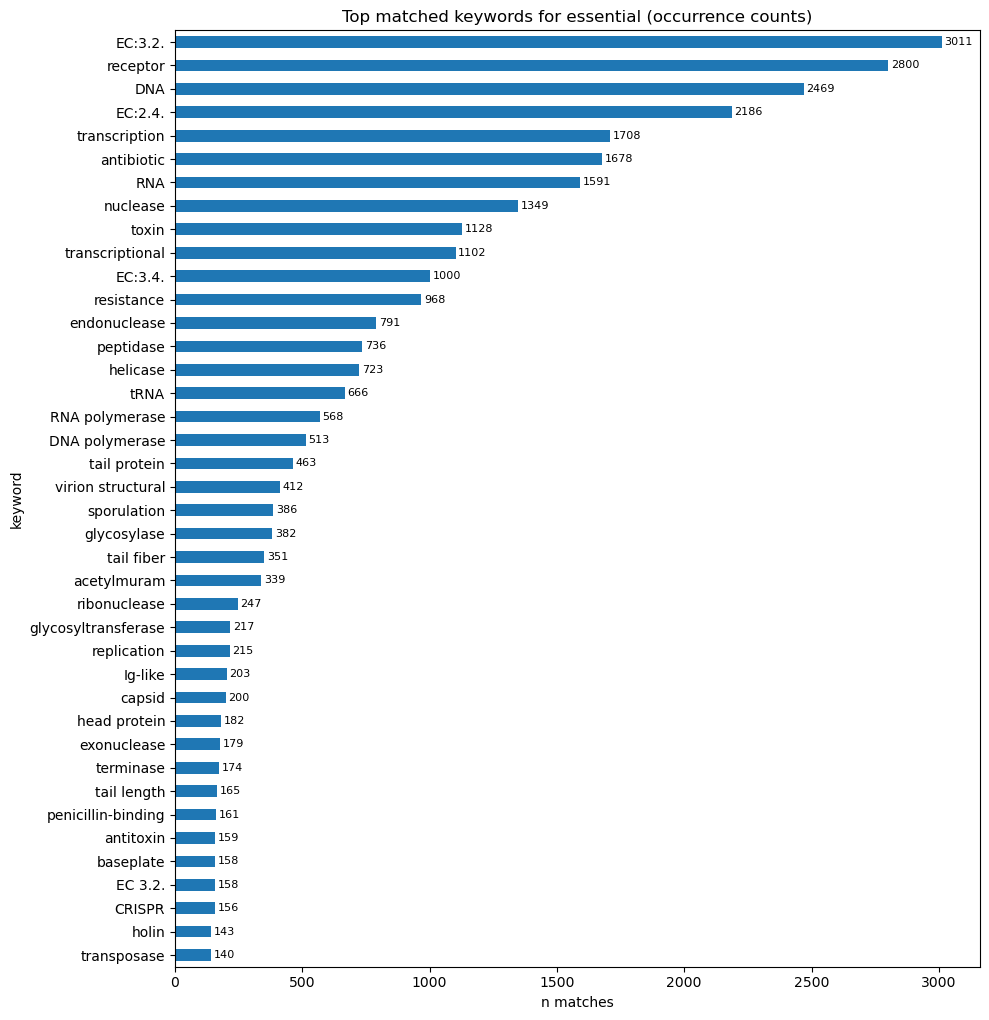

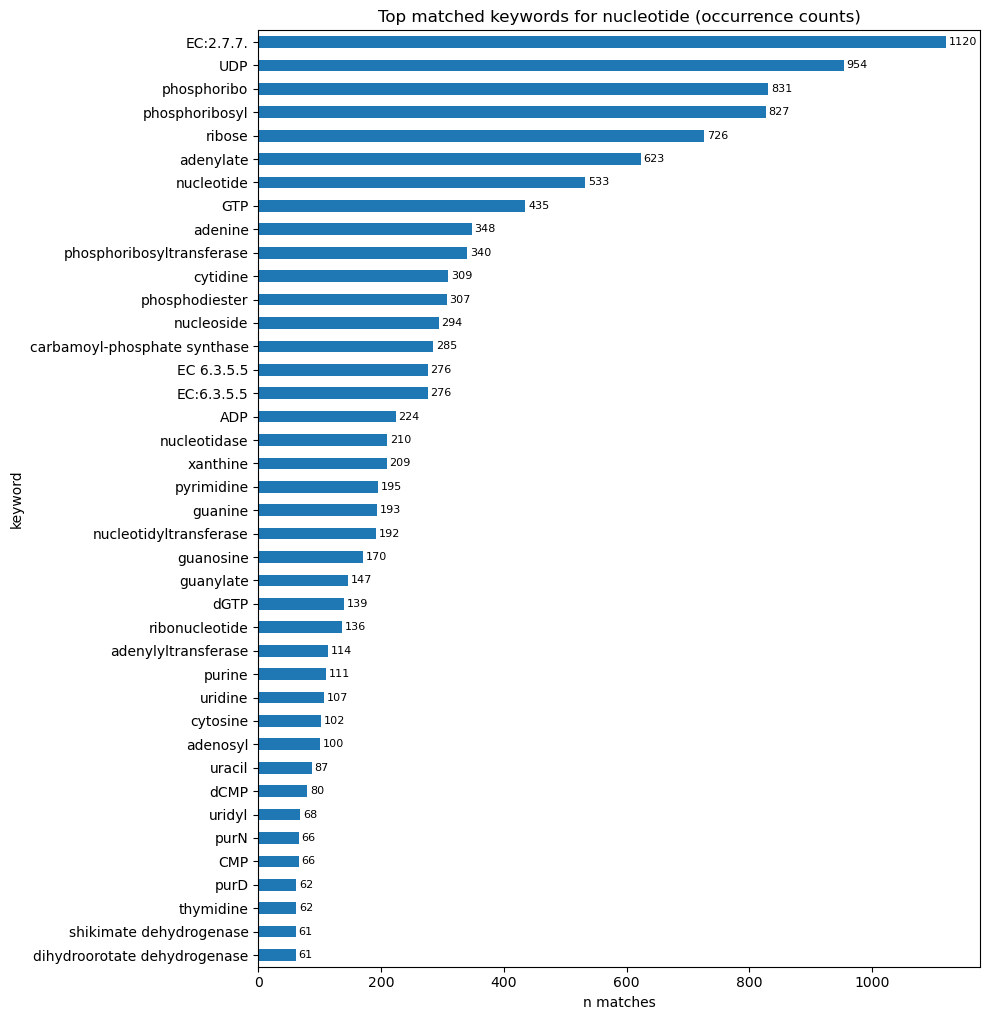

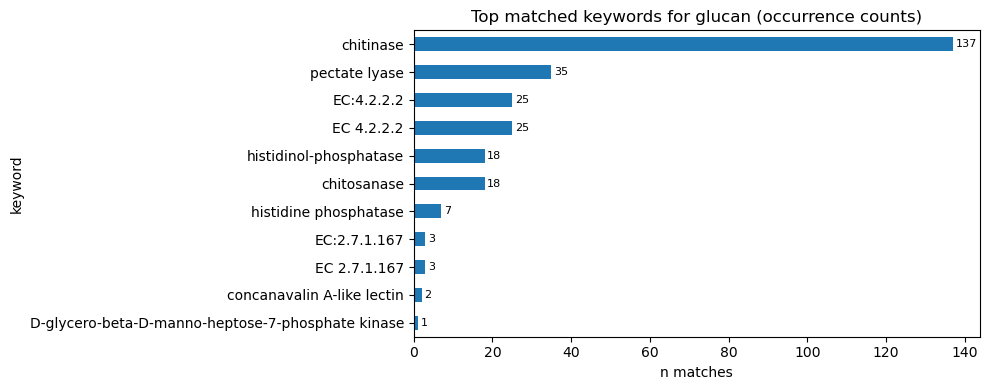

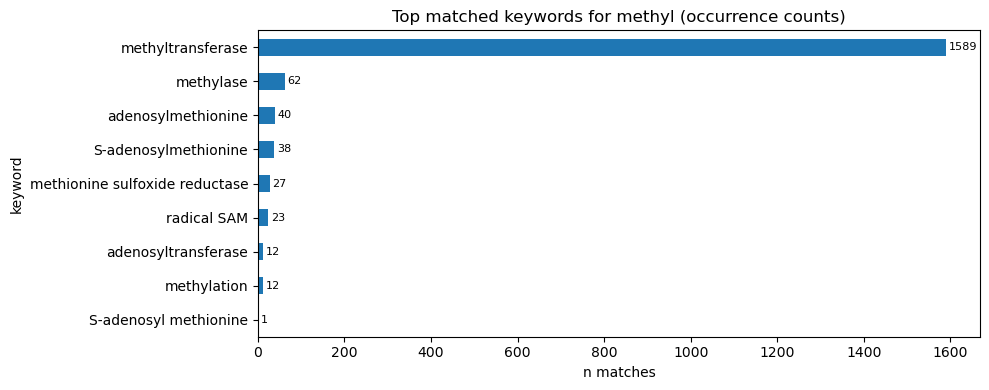

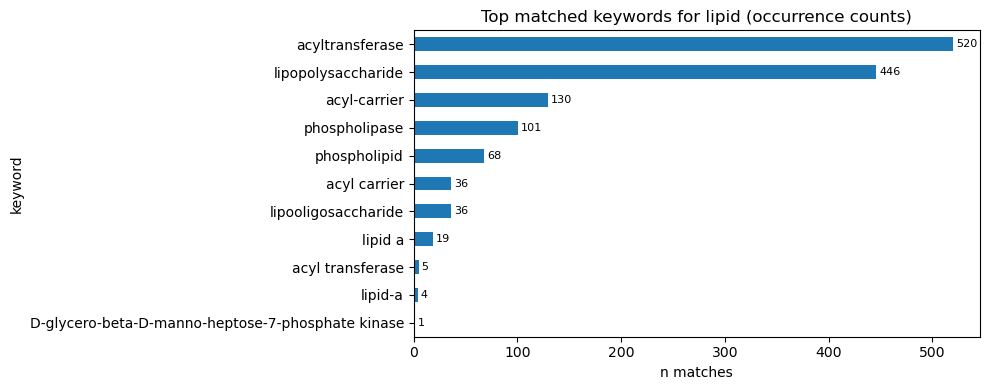

In [210]:
from collections import Counter

def plot_top_keywords_for_exception(df, exception, top_n=40, by="keyword"):
    # by: "keyword" or "mode"
    counts = Counter()
    for hits in df["keyword_matches"]:
        for (exc, mode, kw) in hits:
            if exc != exception:
                continue
            if by == "keyword":
                counts[kw] += 1
            elif by == "mode":
                counts[mode] += 1
            else:
                raise ValueError("by must be one of: keyword, mode")

    if not counts:
        print(f"No matches for exception={exception}")
        return

    s = pd.Series(dict(counts)).sort_values(ascending=False).head(top_n)

    if by == "keyword":
        fig_h = max(4, 0.22 * len(s) + 1.5)
        fig, ax = plt.subplots(figsize=(10, fig_h))
        s.iloc[::-1].plot(kind="barh", ax=ax)
        ax.set_title(f"Top matched keywords for {exception} (occurrence counts)")
        ax.set_xlabel("n matches")
        ax.set_ylabel("keyword")
        add_bar_labels(ax)
        plt.tight_layout()
        plt.show()

# 1) one plot per exception: top keywords
for exc in EXCEPTIONS:
    plot_top_keywords_for_exception(df, exc, top_n=40, by="keyword")

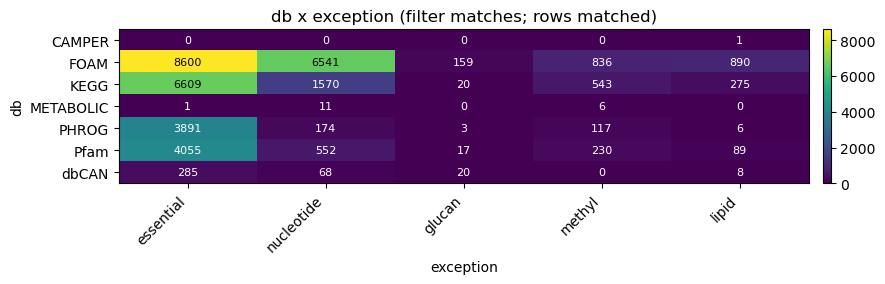

In [211]:
import numpy as np
np.random.seed(20260401)
import matplotlib.pyplot as plt

EXC_COLS = [f"filter_{e}" for e in EXCEPTIONS if f"filter_{e}" in df.columns]

db = (
    df.groupby("db", dropna=False)[EXC_COLS]
    .sum()
    .astype(int)
    .sort_index()
)
db.columns = [c.replace("filter_", "") for c in db.columns]

# align rows/cols
dbs = sorted(set(db.index))
db = db.reindex(dbs).fillna(0).astype(int).reindex(columns=EXCEPTIONS, fill_value=0)

def plot_db_exception_heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(9, 0.5 + 0.35 * len(mat)))
    im = ax.imshow(mat.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("exception")
    ax.set_ylabel("db")
    ax.set_xticks(range(len(EXCEPTIONS)))
    ax.set_xticklabels(EXCEPTIONS, rotation=45, ha="right")
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    vmax = mat.values.max() if mat.size else 0
    thresh = vmax / 2 if vmax else 0

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = int(mat.iat[i, j])
            ax.text(j, i, str(v), ha="center", va="center", fontsize=8, color="black" if v > thresh else "white")

    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

plot_db_exception_heatmap(db, "db x exception (filter matches; rows matched)")

#### 6.1.7. Combine the AMG filter tables to make the final AMG filter table

In [212]:
# Combine on id+db, letting True override False from either source
filter_cols = [
    "filter_essential", "filter_glucan", "filter_lipid",
    "filter_methyl", "filter_nucleotide",
]

amg_filters_final = (
    amg_filter_df.merge(amg_filters_extra, on=["id", "db", "name"], how="outer", suffixes=("_a", "_b"))
)

# For each filter column, OR the two sources (treating NA as False)
for col in filter_cols:
    col_a = f"{col}_a" if f"{col}_a" in amg_filters_final.columns else col
    col_b = f"{col}_b" if f"{col}_b" in amg_filters_final.columns else col
    if col_a in amg_filters_final.columns and col_b in amg_filters_final.columns:
        amg_filters_final[col] = (
            amg_filters_final[col_a].fillna(False).astype(bool) |
            amg_filters_final[col_b].fillna(False).astype(bool)
        )
        amg_filters_final = amg_filters_final.drop(columns=[col_a, col_b])
    elif col_a in amg_filters_final.columns:
        amg_filters_final[col] = amg_filters_final[col_a].fillna(False).astype(bool)
        amg_filters_final = amg_filters_final.drop(columns=[col_a])
    elif col not in amg_filters_final.columns:
        amg_filters_final[col] = False

# Final column order
amg_filters_final = amg_filters_final[
    ["id", "db", "name"] + filter_cols
].sort_values(["db", "id"]).reset_index(drop=True)

print(f"amg_filter_df rows:      {len(amg_filter_df)}")
print(f"amg_filters_extra rows:  {len(amg_filters_extra)}")
print(f"combined rows:           {len(amg_filters_final)}")
amg_filters_final

amg_filter_df rows:      22650
amg_filters_extra rows:  31963
combined rows:           38768


/tmp/ipykernel_734310/1170887941.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  amg_filters_final[col_a].fillna(False).astype(bool) |
/tmp/ipykernel_734310/1170887941.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  amg_filters_final[col_b].fillna(False).astype(bool)
/tmp/ipykernel_734310/1170887941.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent

,id,db,name,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide
0,K00632,CAMPER,acetyl-CoA acyltransferase [EC:2.3.1.16],False,False,True,False,False
1,K02615,CAMPER,"3-oxo-5,6-didehydrosuberyl-CoA/3-oxoadipyl-CoA thiolase [EC:2.3.1.223 2.3.1.174]",False,True,False,False,False
2,K07550,CAMPER,benzoylsuccinyl-CoA thiolase BbsB subunit [EC:2.3.1.310],False,True,False,False,False
3,K10222,CAMPER,"2,6-dioxo-6-phenylhexa-3-enoate hydrolase [EC:3.7.1.8]",False,True,False,False,False
4,HMMsoil100009,FOAM,ramA; alpha-L-rhamnosidase [EC:3.2.1.40],True,True,False,False,False
...,...,...,...,...,...,...,...,...
38763,PL10,dbCAN,pectate lyase (EC 4.2.2.2),False,True,False,False,False
38764,PL2,dbCAN,pectate lyase (EC 4.2.2.2); exo-polygalacturonate lyase (EC 4.2.2.9).,False,True,False,False,False
38765,PL3,dbCAN,pectate lyase (EC 4.2.2.2).,False,True,False,False,False
38766,PL42,dbCAN,"L-rhamnose-alpha-1,4-D-glucuronate lyase (EC 4.2.2.-); L-Rhalpha-alpha-1,4-GlcA alpha-L-rhamnohy...",True,False,False,False,False


In [213]:
amg_filters_final.to_csv("../CheckAMG/files/AMG_filters.tsv", sep="\t", index=False)

### 6.2. False APG table

In [214]:
FILTER_KEYWORDS_DICT_PHYS = {
    "essential": {
        "substring" : [
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
            # Nucleases and DNA modifying/degrading enzymes
            "endonuclease", "exonuclease", "nuclease",
            "restriction enzyme", "restriction endonuclease", "restriction-modification", "restriction system",
            "methylase", "methyltransferase", "methylation",
            # Not essential but false hits due to ontologoy terms
            "unknown function",
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "nucleotide": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "glucan": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

In [215]:
flagged_hmms_phys = flag_hmms_with_keywords(all_hmms, FILTER_KEYWORDS_DICT_PHYS)
flagged_hmms_phys

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,...,any_filter,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65],"[(essential, substring, methylase)]",1,essential,substring,methylase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
483,K00541,KEGG,NNMT; nicotinamide N-methyltransferase [EC:2.1.1.1],"[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
484,K00542,KEGG,GAMT; guanidinoacetate N-methyltransferase [EC:2.1.1.2],"[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
485,K00543,KEGG,ASMT; acetylserotonin O-methyltransferase [EC:2.1.1.4],"[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
486,K00544,KEGG,BHMT; betaine-homocysteine S-methyltransferase [EC:2.1.1.5],"[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241843,K15066,CAMPER,vanillate/3-O-methylgallate O-demethylase [EC:2.1.1.341],"[(essential, substring, methylase)]",1,essential,substring,methylase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
241940,K23526,CAMPER,"aromatic O-demethylase, cytochrome P450 subunit [EC:1.14.14.-]","[(essential, substring, methylase)]",1,essential,substring,methylase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
241941,K23527,CAMPER,"aromatic O-demethylase, reductase subunit [EC:1.6.2.-]","[(essential, substring, methylase)]",1,essential,substring,methylase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
241942,K24244,CAMPER,"5,5'-dehydrodivanillate O-demethylase ferredoxin subunit","[(essential, substring, methylase)]",1,essential,substring,methylase,essential,substring,...,True,True,False,False,False,False,1,True,False,False


In [216]:
apg_filters = flagged_hmms_phys[
    [
        "id", "db", "name",
        "filter_essential",
        "filter_glucan",
        "filter_lipid",
        "filter_methyl",
        "filter_nucleotide",
        ]
    ]
apg_filters

,id,db,name,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65],True,False,False,False,False
483,K00541,KEGG,NNMT; nicotinamide N-methyltransferase [EC:2.1.1.1],True,False,False,False,False
484,K00542,KEGG,GAMT; guanidinoacetate N-methyltransferase [EC:2.1.1.2],True,False,False,False,False
485,K00543,KEGG,ASMT; acetylserotonin O-methyltransferase [EC:2.1.1.4],True,False,False,False,False
486,K00544,KEGG,BHMT; betaine-homocysteine S-methyltransferase [EC:2.1.1.5],True,False,False,False,False
...,...,...,...,...,...,...,...,...
241843,K15066,CAMPER,vanillate/3-O-methylgallate O-demethylase [EC:2.1.1.341],True,False,False,False,False
241940,K23526,CAMPER,"aromatic O-demethylase, cytochrome P450 subunit [EC:1.14.14.-]",True,False,False,False,False
241941,K23527,CAMPER,"aromatic O-demethylase, reductase subunit [EC:1.6.2.-]",True,False,False,False,False
241942,K24244,CAMPER,"5,5'-dehydrodivanillate O-demethylase ferredoxin subunit",True,False,False,False,False


In [217]:
apg_filters.to_csv("../CheckAMG/files/APG_filters.tsv", sep="\t", index=False)

### 6.3. False AReG table
Still retain annotations if the keywords 'regulation', 'regualtory', or 'regulator' are also present.

In [316]:
FILTER_KEYWORDS_DICT_REG = {
    "essential": {
        "substring" : [
            # Structural/surface/cell entry proteins
            "baseplate", "capsid", "portal", "receptor", "sheath", "virion", "virion structure", "virion structural",
            "head decoration", "head morphogenesis", "head protein", "head vertex", "phage head",
            "tail assembly", "tail fiber", "tail fibre", "tail length", "tail peptide", "tail protein", "tail spike", "tail terminator", "phage tail",
            "immunoglobulin", "terminase",
            # DNA/RNA replication and nuclease activity but not gene regulation
            "nuclease", "replication",
            "ribonuclease", "EC:3.1.26.", "EC 3.1.26.", "EC:3.1.27.", "EC 3.1.27.",
            "deoxyribonuclease", "EC:3.1.21.", "EC 3.1.21.", "EC:3.1.22.", "EC 3.1.22.",
            "exonuclease", "endonuclease",
            "recombinase", "recombination", "integrase", "integration", "excisionase", "resolvase", "helicase",
            "transposase", "transposition", "transposon",
            "DNA ligase",  "RNA ligase", "DNA polymerase", "RNA polymerase",
            "primase", "topoisomerase", "gyrase",
            "single strand DNA binding", "single-strand DNA binding", "single strand DNA-binding", "single-strand DNA-binding",  
            "single stranded DNA binding", "single-stranded DNA binding", "single stranded DNA-binding", "single-stranded DNA-binding", 
            # Often related to DNA modification rather than gene regulation
            "adenosyltransferase", "radical SAM",
            "methyltransferase", "methylation", "EC: 2.1.", "EC 2.1.",
            "methionine sulfoxide reductase", "methionine-sulfoxide reductase",
            "S-adenosylmethionine", "S-adenosyl methionine", "adenosylmethionine",
            # Not essential, but involved in adaptive immunity, not in direct gene regulation
            "CRISPR", "spacer",
            # General, not essential but not specific to regulation
            "adaptation", 
        ],
        "case_sensitive" : [
            # DNA/RNA replication
            "ssb",
        ],
        "whole_word" : [
            # Commonly associated with restriction-modification systems, not gene regulation
            "methylase", # Don't want to exclude "demethylase"
            ],
        "case_sensitive_whole_word" : [
            # 
        ],
    },
    "nucleotide": { # This won't be used as an actual filter, it will just be a way to mark annotations that we want to rescue
        "substring" : [
            "regulatory", "regulation", "regulator"
        ],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "glucan": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [], 
        "case_sensitive_whole_word" : [],
    },
    "methyl": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
    "lipid": {
        "substring" : [],
        "case_sensitive" : [],
        "whole_word" : [],
        "case_sensitive_whole_word" : [],
    },
}

In [317]:
flagged_hmms_reg = flag_hmms_with_keywords(all_hmms, FILTER_KEYWORDS_DICT_REG)
flagged_hmms_reg

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,...,any_filter,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
166,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
282,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase,"[(nucleotide, substring, regulator)]",1,nucleotide,substring,regulator,nucleotide,substring,...,True,False,False,False,False,True,1,True,False,False
361,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
393,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241575,HMMsoil99831,FOAM,"glnL, ntrB; two-component system, NtrC family, nitrogen regulation sensor histidine kinase GlnL ...","[(nucleotide, substring, regulation)]",1,nucleotide,substring,regulation,nucleotide,substring,...,True,False,False,False,False,True,1,True,False,False
241598,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]","[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
241609,HMMsoil99891,FOAM,"K11527; two-component system, sensor histidine kinase and response regulator [EC:2.7.13.3]","[(nucleotide, substring, regulator)]",1,nucleotide,substring,regulator,nucleotide,substring,...,True,False,False,False,False,True,1,True,False,False
241630,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...","[(essential, substring, methyltransferase), (essential, whole_word, methylase)]",2,essential,substring; whole_word,methylase; methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,True,False


In [319]:
# Rescue flagged annotations that also contain "regulation" using the `allow_nucleotide` category
mask = flagged_hmms_reg["filter_nucleotide"].fillna(False).astype(bool)
flagged_hmms_reg.loc[mask, "filter_essential"] = False
flagged_hmms_reg.loc[mask, "filter_nucleotide"] = False
flagged_hmms_reg

,id,db,name,keyword_matches,n_total_matches,matched_exceptions,matched_modes,matched_keywords,first_exception,first_match_mode,...,any_filter,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide,n_exceptions_matched,has_any_match,has_multi_match,has_multi_exception_match
166,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
282,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase,"[(nucleotide, substring, regulator)]",1,nucleotide,substring,regulator,nucleotide,substring,...,True,False,False,False,False,False,1,True,False,False
361,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
393,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5","[(essential, substring, integration)]",1,essential,substring,integration,essential,substring,...,True,True,False,False,False,False,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241575,HMMsoil99831,FOAM,"glnL, ntrB; two-component system, NtrC family, nitrogen regulation sensor histidine kinase GlnL ...","[(nucleotide, substring, regulation)]",1,nucleotide,substring,regulation,nucleotide,substring,...,True,False,False,False,False,False,1,True,False,False
241598,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]","[(essential, substring, methyltransferase)]",1,essential,substring,methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,False,False
241609,HMMsoil99891,FOAM,"K11527; two-component system, sensor histidine kinase and response regulator [EC:2.7.13.3]","[(nucleotide, substring, regulator)]",1,nucleotide,substring,regulator,nucleotide,substring,...,True,False,False,False,False,False,1,True,False,False
241630,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...","[(essential, substring, methyltransferase), (essential, whole_word, methylase)]",2,essential,substring; whole_word,methylase; methyltransferase,essential,substring,...,True,True,False,False,False,False,1,True,True,False


In [320]:
areg_filters = flagged_hmms_reg[
    [
        "id", "db", "name",
        "filter_essential",
        "filter_glucan",
        "filter_lipid",
        "filter_methyl",
        "filter_nucleotide",
        ]
    ]

# Remove rows that have no remaining flags / all are false
bool_cols = areg_filters.select_dtypes(include="bool").columns
areg_filters = areg_filters.loc[
    areg_filters[bool_cols].any(axis=1)
].reset_index(drop=True)

areg_filters

,id,db,name,filter_essential,filter_glucan,filter_lipid,filter_methyl,filter_nucleotide
0,K00182,KEGG,"WNT2; wingless-type MMTV integration site family, member 2",True,False,False,False,False
1,K00312,KEGG,"WNT3; wingless-type MMTV integration site family, member 3",True,False,False,False,False
2,K00408,KEGG,"WNT4; wingless-type MMTV integration site family, member 4",True,False,False,False,False
3,K00444,KEGG,"WNT5; wingless-type MMTV integration site family, member 5",True,False,False,False,False
4,K00445,KEGG,"WNT6; wingless-type MMTV integration site family, member 6",True,False,False,False,False
...,...,...,...,...,...,...,...,...
9863,HMMsoil99583,FOAM,"rhlB; ATP-dependent RNA helicase RhlB [EC:3.6.4.13]; deaD, cshA; ATP-dependent RNA helicase DeaD...",True,False,False,False,False
9864,HMMsoil99686,FOAM,E2.1.1.104; caffeoyl-CoA O-methyltransferase [EC:2.1.1.104],True,False,False,False,False
9865,HMMsoil99877,FOAM,"metH, MTR; 5-methyltetrahydrofolate--homocysteine methyltransferase [EC:2.1.1.13]",True,False,False,False,False
9866,HMMsoil99924,FOAM,"ubiE; demethylmenaquinone methyltransferase / 2-methoxy-6-polyprenyl-1,4-benzoquinol methylase [...",True,False,False,False,False


In [321]:
areg_filters.to_csv("../CheckAMG/files/AReG_filters.tsv", sep="\t", index=False)

## 7. Check for overlap between AMG, APG, and AReG tables and resolve

### 7.1. Between APGs and AReGs

In [322]:
overlap_aregs_apgs = pd.merge(AReGs, APGs, how='inner', on=['id', 'db', 'name'])
with pd.option_context('display.max_rows', 500, 'display.max_colwidth', 100, 'display.width', 800):
    print(overlap_aregs_apgs["name"].unique())

['betI; TetR/AcrR family transcriptional regulator, transcriptional repressor of bet genes'
 'flhC; flagellar transcriptional activator FlhC'
 'flhD; flagellar transcriptional activator FlhD'
 'fliS; flagellar secretion chaperone FliS'
 'spo0F; two-component system, response regulator, stage 0 sporulation protein F'
 'kinA; two-component system, sporulation sensor kinase A [EC:2.7.13.3]'
 'pilG; twitching motility two-component system response regulator PilG'
 'pilH; twitching motility two-component system response regulator PilH'
 'acrR, smeT; TetR/AcrR family transcriptional regulator, acrAB operon repressor'
 'ctsR; transcriptional regulator of stress and heat shock response'
 'spoVT; AbrB family transcriptional regulator, stage V sporulation protein T'
 'slmA, ttk; TetR/AcrR family transcriptional regulator'
 'bolA; BolA family transcriptional regulator, general stress-responsive regulator'
 'spoIIID; putative DeoR family transcriptional regulator, stage III sporulation protein D'


Overlaps between APGs and AReGs are assigned to AReG (regulation takes precedence over physiology).

In [323]:
APGs_filtered = APGs[~APGs["name"].isin(overlap_aregs_apgs["name"])]
APGs_filtered

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
2207,K02382,KEGG,flbA; flagellar protein FlbA
2208,K02383,KEGG,flbB; flagellar protein FlbB
...,...,...,...
239161,HMMsoil9519,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
239405,HMMsoil95682,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
239734,HMMsoil96343,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
240197,HMMsoil97222,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [324]:
overlap_aregs_apgs_filtered = pd.merge(AReGs, APGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_aregs_apgs_filtered

,id,db,name


### 7.2. Between AReGs and AMGs

In [325]:
overlap_aregs_amgs = pd.merge(AReGs, amg_table_with_scores, how='inner', on=['id', 'db', 'name'])
with pd.option_context('display.max_rows', 1000, 'display.max_colwidth', 100, 'display.width', 800):
    print(overlap_aregs_amgs)

                id         db                                                                                                 name  metabolic_paths  total_paths path_source  metabolic_ratio  VL-score  AMG_weight  amg_level
0           K00610       KEGG                                              pyrI; aspartate carbamoyltransferase regulatory subunit              1.0          2.0        KEGG         0.500000  0.477121    0.500000     medium
1           K00936       KEGG                             pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]              1.0          2.0        KEGG         0.500000  2.572872    0.500000     medium
2           K01538       KEGG  FXYD2, ATP1G1; sodium/potassium-transporting ATPase subunit gamma (FXYD domain-containing ion tr...              1.0          4.0        KEGG         0.250000       NaN    0.250000        low
3           K01846       KEGG                                 glmS, mutS, mamA; methylaspartate mutase sigma

Overlaps between AReGs and AMGs are assigned to AReG by default, **except for the curated metabolic functions below**, which remain AMGs.

In [326]:
allowed_functions = [
    "glmS, mutS, mamA; methylaspartate mutase sigma subunit [EC:5.4.99.1]",
    "narJ, narW; nitrate reductase molybdenum cofactor assembly chaperone NarJ/NarW",
    "psbO; photosystem II oxygen-evolving enhancer protein 1",
    "psbP; photosystem II oxygen-evolving enhancer protein 2",
    "psbQ; photosystem II oxygen-evolving enhancer protein 3",
    "actVA5; two-component flavin-dependent monooxygenase [EC:1.14.14.-]",
    "methane monooxygenase regulatory protein B",
    "sgcC, mdpC; two-component FAD-dependent monooxygenase [EC:1.14.14.15 1.14.14.-]"
    "hisZ; ATP phosphoribosyltransferase regulatory subunit",
    "mmoB; methane monooxygenase regulatory protein B"
]
AMGs_filtered = amg_table_with_scores[
    ~amg_table_with_scores["name"].isin(
        overlap_aregs_amgs[~overlap_aregs_amgs["name"].isin(allowed_functions)]["name"]
    )
]
AMGs_filtered = AMGs_filtered.reset_index(drop=True)
AMGs_filtered

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
0,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
1,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
3,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
4,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
...,...,...,...,...,...,...,...,...,...,...
60817,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60818,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60819,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60820,HMMsoil3809,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low


In [327]:
AReGs_filtered = AReGs[~AReGs["name"].isin(allowed_functions)]
AReGs_filtered

,id,db,name
337,K00375,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
425,K00478,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
549,K00610,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
852,K00936,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
1233,K01343,KEGG,PLAT; tissue plasminogen activator [EC:3.4.21.68]
...,...,...,...
241618,HMMsoil99907,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
241621,HMMsoil99910,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
241622,HMMsoil99913,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
241623,HMMsoil99914,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [328]:
overlap_aregs_amgs_filtered = pd.merge(AReGs_filtered, AMGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_aregs_amgs_filtered

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level


### 7.3. Between AMGs and APGs

In [329]:
overlap_amgs_apgs = pd.merge(AMGs_filtered, APGs_filtered, how='inner', on=['id', 'db', 'name'])
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 100, 'display.width', 800):
    print(overlap_amgs_apgs)

               id    db                                                                                                 name  metabolic_paths  total_paths path_source  metabolic_ratio  VL-score  AMG_weight  amg_level
0          K26994  KEGG                                                                 sdpA; sporulation delaying protein A              1.0          1.0        KEGG         1.000000       NaN    1.000000  very high
1          K26997  KEGG                                                                 sdpC; cannibalism toxin, SdpC family              1.0          1.0        KEGG         1.000000       NaN    1.000000  very high
2          K21202  KEGG                                              2-ODD; (-)-deoxypodophyllotoxin synthase [EC:1.14.20.8]              1.0          1.0        KEGG         1.000000       NaN    1.000000  very high
3          K28298  KEGG                                                                             tse5; toxin protein Tse5        

Overlaps between AMGs and APGs are assigned to APG by default, **except for the curated id(s) below** (`K04035`), which remain AMGs.

In [330]:
allowed_ids = ["K04035"]
AMGs_filtered = AMGs_filtered[~AMGs_filtered["name"].isin(overlap_amgs_apgs[~overlap_amgs_apgs["id"].isin(allowed_ids)]["name"])]
AMGs_filtered = AMGs_filtered.reset_index(drop=True)
AMGs_filtered

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
0,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
1,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
3,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
4,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
...,...,...,...,...,...,...,...,...,...,...
60765,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60766,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60767,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60768,HMMsoil3809,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low


In [331]:
APGs_filtered = APGs_filtered[~APGs_filtered["name"].isin(AMGs_filtered["name"])]
APGs_filtered

,id,db,name
1826,K01993,KEGG,ABC-2.TX; HlyD family secretion protein
1838,K02005,KEGG,ABC.CD.TX; HlyD family secretion protein
1855,K02022,KEGG,ABC.MR.TX; HlyD family secretion protein
2207,K02382,KEGG,flbA; flagellar protein FlbA
2208,K02383,KEGG,flbB; flagellar protein FlbB
...,...,...,...
239161,HMMsoil9519,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
239405,HMMsoil95682,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
239734,HMMsoil96343,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
240197,HMMsoil97222,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [332]:
overlap_amgs_apgs = pd.merge(AMGs_filtered, APGs_filtered, how='inner', on=['id', 'db', 'name'])
overlap_amgs_apgs

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level


### 7.4. one final check for overlaps to be safe

In [333]:
ids_A = set(AMGs_filtered["id"].dropna().astype(str))
ids_P = set(APGs_filtered["id"].dropna().astype(str))
ids_R = set(AReGs_filtered["id"].dropna().astype(str))

overlap_AP = ids_A & ids_P
overlap_AR = ids_A & ids_R
overlap_PR = ids_P & ids_R
overlap_all = ids_A & ids_P & ids_R

print(
    "AMG∩APG:", len(overlap_AP),
    "| AMG∩AReG:", len(overlap_AR),
    "| APG∩AReG:", len(overlap_PR),
    "| AMG∩APG∩AReG:", len(overlap_all)
)

AMG∩APG: 0 | AMG∩AReG: 0 | APG∩AReG: 0 | AMG∩APG∩AReG: 0


### 7.5. Write the final `AMGs.tsv`, `APGs.tsv`, and `AReGs.tsv` tables and check final DB value counts

In [334]:
AMGs_filtered

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level
0,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
1,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
2,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high
3,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
4,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high
...,...,...,...,...,...,...,...,...,...,...
60765,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60766,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60767,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low
60768,HMMsoil3809,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low


In [335]:
AMGs_filtered["db"].value_counts()

db
FOAM         48124
KEGG         10055
Pfam          1611
dbCAN          346
METABOLIC      298
CAMPER         279
Name: count, dtype: int64

In [336]:
AMGs_filtered.to_csv('../CheckAMG/files/AMGs.tsv', index=False, sep='\t')

In [337]:
APGs_filtered = APGs_filtered.merge(vscores.drop('name', axis=1).reset_index(), on=["id", "db"], how="left")
APGs_filtered = APGs_filtered[["id", "V-score", "VL-score", "db", "name"]]
APGs_filtered

,id,V-score,VL-score,db,name
0,K01993,1.33,2.123852,KEGG,ABC-2.TX; HlyD family secretion protein
1,K02005,1.49,2.173186,KEGG,ABC.CD.TX; HlyD family secretion protein
2,K02022,1.15,2.060698,KEGG,ABC.MR.TX; HlyD family secretion protein
3,K02382,NaN,NaN,KEGG,flbA; flagellar protein FlbA
4,K02383,0.02,0.301030,KEGG,flbB; flagellar protein FlbB
...,...,...,...,...,...
1503,HMMsoil9519,NaN,NaN,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24]
1504,HMMsoil95682,NaN,NaN,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...
1505,HMMsoil96343,NaN,NaN,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system..."
1506,HMMsoil97222,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid..."


In [338]:
APGs_filtered["db"].value_counts()

db
Pfam     751
KEGG     579
FOAM     101
PHROG     77
Name: count, dtype: int64

In [339]:
APGs_filtered.to_csv('../CheckAMG/files/APGs.tsv', index=False, sep='\t')

In [340]:
AReGs_filtered = AReGs_filtered.merge(vscores.drop('name', axis=1).reset_index(), on=["id", "db"], how="left")
AReGs_filtered = AReGs_filtered[["id", "V-score", "VL-score", "db", "name"]]
AReGs_filtered

,id,V-score,VL-score,db,name
0,K00375,10.00,3.148911,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase
1,K00478,NaN,NaN,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65]
2,K00610,0.03,0.477121,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit
3,K00936,3.74,2.572872,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]"
4,K01343,0.73,1.863323,KEGG,PLAT; tissue plasminogen activator [EC:3.4.21.68]
...,...,...,...,...,...
14277,HMMsoil99907,NaN,NaN,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3..."
14278,HMMsoil99910,NaN,NaN,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]"
14279,HMMsoil99913,NaN,NaN,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c..."
14280,HMMsoil99914,NaN,NaN,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]"


In [341]:
AReGs_filtered["db"].value_counts()

db
FOAM     10027
KEGG      2176
Pfam      1424
PHROG      655
Name: count, dtype: int64

In [342]:
AReGs_filtered.to_csv('../CheckAMG/files/AReGs.tsv', index=False, sep='\t')

## 8. Plot AMG weights

In [343]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from adjustText import adjust_text
import numpy as np
np.random.seed(20260401)
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def plot_weight_vs_vl(df, highlight_ids=None, ratio_col="metabolic_ratio", weight_col="AMG_weight",
                      ratio_label="Metabolic ratio", weight_label="AMG weight",
                      figsize=(8, 6), cmap="viridis", grid_res=300, smooth_sigma=8, no_data_region=None):
    plot_df = df.dropna(subset=["VL-score", weight_col, ratio_col]).copy()

    # Fall back to a plain scatter when there are too few points to interpolate a surface
    if len(plot_df) < 5 or plot_df["VL-score"].nunique() < 3 or plot_df[ratio_col].nunique() < 3:
        fig, ax = plt.subplots(figsize=figsize)
        sc = ax.scatter(plot_df["VL-score"], plot_df[ratio_col], c=plot_df[weight_col],
                        cmap=cmap, vmin=0.0, vmax=1.0, s=30, edgecolors="none")
        fig.colorbar(sc, ax=ax, label=weight_label)
        ax.set_xlabel("VL-score", fontsize=12)
        ax.set_ylabel(ratio_label, fontsize=12)
        plt.tight_layout()
        plt.show()
        return fig, ax

    x = plot_df["VL-score"].values
    y = plot_df[ratio_col].values
    z = plot_df[weight_col].values

    # Build interpolation grid
    xmin_pad = (x.max() - x.min()) * 0.01
    ymin_pad = (y.max() - y.min()) * 0.01
    xmax_pad = (x.max() - x.min()) * 0.075
    ymax_pad = (y.max() - y.min()) * 0.075
    xi = np.linspace(x.min() - xmin_pad, x.max() + xmax_pad, grid_res)
    yi = np.linspace(y.min() - ymin_pad, y.max() + ymax_pad, grid_res)
    Xi, Yi = np.meshgrid(xi, yi)

    # Linear interpolation, fill outside convex hull with nearest-neighbour
    Zi_linear  = griddata((x, y), z, (Xi, Yi), method="linear")
    Zi_nearest = griddata((x, y), z, (Xi, Yi), method="nearest")
    Zi = np.where(np.isnan(Zi_linear), Zi_nearest, Zi_linear)

    # kill extrapolation in a region with no real data, if requested
    if no_data_region is not None:
        x_thr, y_thr = no_data_region
        Zi[(Xi > x_thr) & (Yi < y_thr)] = 0.0

    # Smooth
    Zi = gaussian_filter(Zi, sigma=smooth_sigma)
    Zi = np.clip(Zi, 0.0, 1.0)

    # Contour levels
    levels_fill    = np.linspace(0.0, 1.0, 256) # smooth gradient fill
    levels_contour = np.arange(0.2, 1.01, 0.2)  # lines at 0, 0.2, 0.4 ... 1.0

    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

    # Figure
    fig, ax = plt.subplots(figsize=figsize)

    # Gradient background
    cf = ax.contourf(Xi, Yi, Zi, levels=levels_fill,
                     cmap=cmap, norm=norm, zorder=0)

    # Contour lines
    ax.contour(Xi, Yi, Zi, levels=levels_contour,
               colors="white", linewidths=1.2, alpha=0.7, zorder=1)

    # Scatter points
    if highlight_ids:
        bg_mask = ~plot_df["id"].isin(highlight_ids.keys())
    else:
        bg_mask = pd.Series(True, index=plot_df.index)

    bg = plot_df[bg_mask]
    ax.scatter(bg["VL-score"], bg[ratio_col],
               color="white", alpha=0.45, s=22,
               edgecolors="none", linewidths=0, zorder=2)

    # Colorbar
    cbar = fig.colorbar(cf, ax=ax, pad=0.025, format=mticker.FormatStrFormatter("%.1f"), ticks=np.arange(0.0, 1.01, 0.2))
    cbar.set_label(weight_label, fontsize=12, labelpad=8)

    # Highlighted points
    if highlight_ids:
        hi_df = plot_df[plot_df["id"].isin(highlight_ids.keys())].drop_duplicates(subset="id")
        ax.scatter(hi_df["VL-score"], hi_df[ratio_col],
                   color="white", s=90,
                   edgecolors="black", linewidths=1.8, zorder=4)

        texts = []
        for _, row in hi_df.iterrows():
            label = highlight_ids.get(row["id"], str(row["id"]))
            t = ax.text(row["VL-score"], row[ratio_col], label,
                        fontsize=8, color="white", fontweight="bold", zorder=5,
                        ha="center", va="center")
            texts.append(t)

        adjust_text(
            texts,
            x=hi_df["VL-score"].values,
            y=hi_df[ratio_col].values,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="black", lw=1.0, alpha=0.6),
            expand=(1.2, 2.8),
            force_text=(0.9, 0.5),
            force_points=(0.8, 0.5),
            only_move={"points": "xy", "text": "xy"},
            max_move=90,
        )

    ax.set_xlim(xi.min(), xi.max())
    ax.set_ylim(yi.min(), yi.max())
    ax.set_xlabel("VL-score", fontsize=12)
    ax.set_ylabel(ratio_label, fontsize=12)
    ax.grid(True, alpha=0.2, linewidth=0.4, color="white")
    plt.tight_layout()
    plt.show()
    return fig, ax

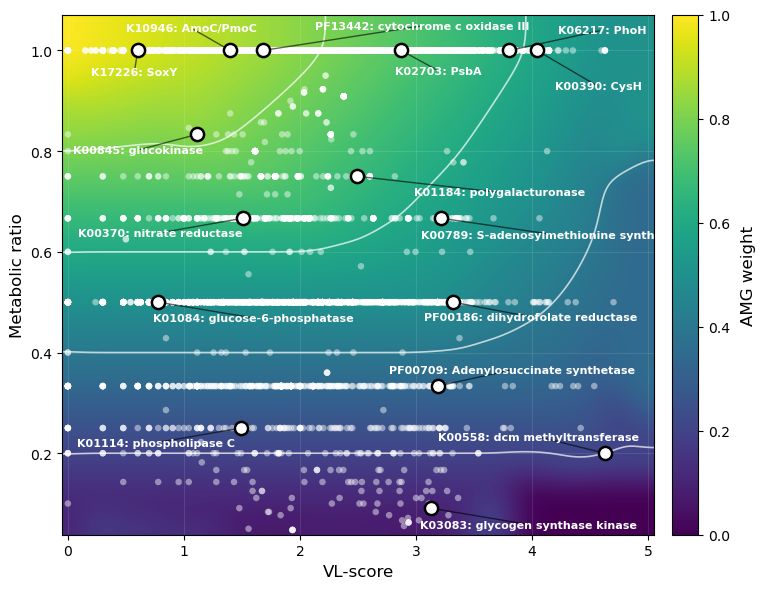

In [344]:
# highlight_ids: keys = values from the 'id' column, values = the label to show
highlight_ids = {
    'K00390': 'K00390: CysH',
    'K02703': 'K02703: PsbA',
    'K17226': 'K17226: SoxY',
    'K06217': 'K06217: PhoH',
    'K10946': 'K10946: AmoC/PmoC',
    'K00558': 'K00558: dcm methyltransferase',
    'K00956': 'K00956: CysN',
    # 'K13811': 'K13811: PAPSS',
    'K01184': 'K01184: polygalacturonase',
    'K00789': 'K00789: S-adenosylmethionine synthetase',
    'K00370': 'K00370: nitrate reductase',
    'K00845': 'K00845: glucokinase',
    # 'K03741': 'K03741: arsenate reductase',
    'PF13442.12': 'PF13442: cytochrome c oxidase III',
    # 'K01916': 'K01916: NAD+ synthase',
    'K01084': 'K01084: glucose-6-phosphatase',
    'PF00186.25': 'PF00186: dihydrofolate reductase',
    'TIGR02188' : 'TIGR02188: acetyl-CoA synthetase',
    'PF04724.19': 'PF04724: Glycosyl transferase',
    # 'K00287': 'K00287: Dihydrofolate reductase',
    'K01114': 'K01114: phospholipase C',
    'PF00709.28': 'PF00709: Adenylosuccinate synthetase',
    'K03083': 'K03083: glycogen synthase kinase',
    # 'PF00145.24': 'PF00145: cytosine-specific DNA methylase',
    
}

fig, ax = plot_weight_vs_vl(AMGs_filtered, highlight_ids=highlight_ids, no_data_region=(3.8, 0.15))

## 9. Generate the viral hallmark gene table
As described in [Roux et al. (2014), <i>eLife</i>](https://doi.org/10.7554/eLife.03125), viral hallmark genes are annotations with any of the following keywords:

- "virion structur*"
- "capsid"
- "portal"
- "tail"
- "terminase"

### 9.1. Define and the conditions for viral hallmark genes in the all HMM table and filter

In [345]:
viral_hallmark_genes = all_hmms[all_hmms['name'].str.contains('virion structur|capsid|portal|tail|terminase', case=False, na=False)]
viral_hallmark_genes

,id,db,name
1430,K01551,KEGG,"arsA, ASNA1, GET3; arsenite/tail-anchored protein-transporting ATPase [EC:7.3.2.7 7.3.-.-]"
6504,K06906,KEGG,gpU; phage tail protein
6505,K06907,KEGG,FI; Bacteriophage tail sheath protein
6506,K06908,KEGG,FII; Bacteriophage tail tube protein
6507,K06909,KEGG,xtmB; phage terminase large subunit
...,...,...,...
166736,phrog_9927,PHROG,virion structural protein
166903,phrog_9942,PHROG,tail fiber protein
166913,phrog_99429,PHROG,major tail protein
167091,phrog_9959,PHROG,tail length tape measure protein


In [346]:
viral_hallmark_genes["db"].value_counts()

db
PHROG    1861
Pfam      373
KEGG      102
Name: count, dtype: int64

### 9.2. Write the final `viral_hallmark_genes.tsv` table

In [347]:
viral_hallmark_genes.to_csv('../CheckAMG/files/viral_hallmark_genes.tsv', sep="\t", index=False)

## 10. Construct the MGE/mobility gene table

### 10.1. Establish conditions for filtering the all HMM table by keywords

In [348]:
# mge_kw = re.compile(
#     r"(?i)\b("
#     r"transposase|insertion\s+sequence|tnp[A-Z]*|IS\d{2,}|"     # Transposons
#     r"integrase|recombinase|resolvase|relaxase|"                # Integrative
#     r"plasmid|partition|par[ABM]|copy\s*number|crispr|"         # Plasmid / TA / defense
#     r"HNH|GIY[-_]YIG|PD-?D[E|D]XK|homing endonuclease"          # Endonucleases
#     r")\b"
# )

# Viral keywords: always keep
viral_kw = re.compile(
    r"\b(phage|capsid|tail|portal|head|terminase|baseplate|holin|endolysin|virion)\b",
    flags=re.IGNORECASE,
)

# MGE keywords **excluding** Tra*
mge_kw = re.compile(
    r"(?i)\b("
    r"transposase|insertion\s+sequence|tnp[A-Z]*|IS\d{2,}|"       # Transposons
    r"integrase|recombinase|resolvase|relaxase|DDE superfamily|DDE domain|" # Integrative
    r"plasmid|partition|par[ABM]|copy\s*number"                  # Plasmid / TA
    r"HNH|GIY[-_]YIG|PD-?D[E|D]XK|homing endonuclease"          # Endonucleases
    r")\b"
)

# Case-sensitive match for TraI, TraG, etc.
tra_kw = re.compile(r"\bTra[A-Z0-9][A-Za-z0-9_-]*\b")

### 10.2. Load additional plasmid marker genes from geNomad's database

In [349]:
plasmid_marker_ids = set()
with open("./data/plasmid_hallmark_annotation.txt", "r") as f:
    for line in f:
        if line.startswith("#"):
            continue
        plasmid_marker_ids.add(line.strip())

### 10.3. Filter the HMM table using the keywords and geNomad markers

In [350]:
def decide(row):
    id   = row["id"] if isinstance(row["id"], str) else ""
    if "." in id:
        id = id.split(".")[0]
    name = row["name"] if isinstance(row["name"], str) else ""
    vl   = row["V-score"]

    if viral_kw.search(name):
        return "keep"
    if id in plasmid_marker_ids:
        return "filter"
    if (mge_kw.search(name) or tra_kw.search(name)):
        return "filter"
    return "keep"

def is_genomad_plasmid_marker(row):
    id = row["id"] if isinstance(row["id"], str) else ""
    if "." in id:
        id = id.split(".")[0]
    return id in plasmid_marker_ids

In [351]:
vscores_cp = vscores.copy()
vscores_cp["decision"] = vscores_cp.apply(decide, axis=1)
vscores_cp["genomad_plasmid_marker"] = vscores_cp.apply(is_genomad_plasmid_marker, axis=1)
vscores_cp

,id,name,V-score,VL-score,db,decision,genomad_plasmid_marker
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG,filter,False
1,K14059,integrase,10.00,4.882297,KEGG,filter,False
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG,filter,False
3,K00571,site-specific DNA-methyltransferase (adenine-specific) [EC:2.1.1.72],10.00,4.829278,KEGG,keep,False
4,K06909,phage terminase large subunit,10.00,4.826871,KEGG,keep,False
...,...,...,...,...,...,...,...
243425,phrog_22476,NaN,0.01,0.000000,PHROG,keep,False
243426,phrog_4110,NaN,0.01,0.000000,PHROG,keep,False
243427,phrog_17200,NaN,0.01,0.000000,PHROG,keep,False
243428,phrog_6460,NaN,0.01,0.000000,PHROG,keep,False


In [352]:
mobile_genes_table = vscores_cp[vscores_cp["decision"] == "filter"].drop(columns="decision")
mobile_genes_table

,id,name,V-score,VL-score,db,genomad_plasmid_marker
0,K04763,integrase/recombinase XerD,10.00,4.890952,KEGG,False
1,K14059,integrase,10.00,4.882297,KEGG,False
2,K03733,integrase/recombinase XerC,10.00,4.875391,KEGG,False
24,K03497,"ParB family transcriptional regulator, chromosome partitioning protein",10.00,4.484769,KEGG,True
51,K06400,site-specific DNA recombinase,10.00,4.373298,KEGG,False
...,...,...,...,...,...,...
231728,phrog_27175,transposase,0.04,0.602060,PHROG,False
232055,phrog_16545,ParB-like partition protein,0.03,0.477121,PHROG,False
233354,phrog_33277,ParB-like partition protein,0.03,0.477121,PHROG,False
237984,phrog_14449,transposase,0.02,0.301030,PHROG,False


In [353]:
mobile_genes_table["db"].value_counts()

db
Pfam     209
PHROG    149
KEGG      93
Name: count, dtype: int64

In [354]:
mobile_genes_table["genomad_plasmid_marker"].value_counts()

genomad_plasmid_marker
False    301
True     150
Name: count, dtype: int64

### 10.4. Write the `mobile_genes.tsv` table

In [355]:
mobile_genes_table.to_csv('../CheckAMG/files/mobile_genes.tsv', sep="\t", index=False)

## 11. AMG function categories

### 11.1. Strategy and unified L1 categories

Each AMG/APG/AReG annotation gets a hierarchical functional assignment with up to three levels (L1 → L2 → L3), inspired by FOAM (4 levels), METABOLIC (Category → Function) and KEGG BRITE (A → B → C → D). The same L1 vocabulary is used across all three tables only where biologically appropriate, but the three tables have **distinct L1 ontologies** because their members are biologically distinct (auxiliary metabolism vs. physiology vs. regulation). Multiple L1/L2 assignments per annotation are allowed and expected, since many enzymes are genuinely multi-functional.

Sources used:

* **AMGs**: FOAM (`L1`–`L4`), METABOLIC (`Category`/`Function`), KEGG BRITE (`B_name`/`C_name`/`D_desc`), CAZy class (GH, GT, PL, CE, AA, CBM), CAMPER definitions (polyphenol-centric), and Pfam → GO ancestor traversal against curated L1 anchor terms.
* **APGs**: keyword/regex pattern matching against the description (`name`), informed by the same APG keyword dictionary used to build the table in Section 3, plus PHROG categories for PHROG entries.
* **AReGs**: keyword/regex pattern matching against `name`, informed by the AReG keyword dictionary used in Section 4, plus PHROG categories.

An annotation that has no clean assignment at L2 or L3 simply gets `None` for those levels. Annotations that fall outside the L1 vocabulary (rare; mostly stress-response FOAM rows that slipped into AMGs via shared KOs) are left unassigned at L1 — which is preferable to forcing a misleading category.

### 11.2. Define unified L1 ontology vocabularies

In [356]:
# AMG L1: broad metabolic/cycling processes
AMG_L1_DESCRIPTIONS = {
    'Carbohydrate metabolism': (
        'Central carbon metabolism (glycolysis/EMP, gluconeogenesis, TCA, pentose phosphate, '
        'fermentation, sugar interconversion) plus complex carbohydrate / polysaccharide '
        'degradation, and biosynthesis (CAZy: GH, GT, PL, CE, AA, CBM).'
    ),
    'Energy metabolism': (
        'Electron transport, oxidative phosphorylation, hydrogenases, and photosynthesis '
        '(light reactions and antenna proteins) — the primary ATP/redox-generating processes.'
    ),
    'Carbon fixation & C1 metabolism': (
        'Inorganic carbon fixation (CBB/Calvin, reverse TCA, Wood-Ljungdahl, 3HP/4HB, DC/4-HB), '
        'methanogenesis and methylotrophy, and other C1 transformations (methane, methanol, '
        'formaldehyde, formate, CO).'
    ),
    'Nitrogen metabolism': (
        'Nitrogen cycling: N2 fixation, nitrification, denitrification, DNRA, anammox, ammonia '
        'assimilation, urea/nitrile utilization, hydroxylamine/NO/N2O turnover.'
    ),
    'Sulfur metabolism': (
        'Inorganic and organic sulfur cycling: assimilatory and dissimilatory sulfate/sulfite '
        'reduction, sulfide / S0 / sulfite / thiosulfate oxidation and reduction, DMSO/DMS '
        'turnover, organosulfur metabolism, sulfur amino-acid metabolism.'
    ),
    'Phosphorus metabolism': (
        'Phosphate transport (Pst, Pit), phosphate starvation response (Pho regulon: PhoH, '
        'PhoBR, PhoPR), phosphatases (alkaline/acid/phytase), phosphonate / phosphite '
        'metabolism (Phn cluster, phosphonoacetate hydrolase), inositol phosphate/phytate '
        'metabolism, polyphosphate metabolism.'
    ),
    'Oxygen metabolism': (
        'Functions for consumption and production of molecular oxygen (O2). '
        'Includes aerobic respiration / terminal oxidases (cytochrome c oxidase, bd / bo / aa3-type), '
        'mono- and di-oxygenases that incorporate O2 into substrates, photosynthetic '
        'O2 evolution by photosystem II (water-splitting), DARK O2 PRODUCTION '
        '(chlorite dismutase, nitric-oxide dismutase / NOD), and reactive O2 species '
        'detoxification enzymes that liberate O2 (catalase, superoxide dismutase, peroxidases). '
        'Overlaps intentionally with Energy metabolism for terminal oxidases and PSII; '
        'overlaps with Other inorganic element cycling for chlorite dismutase.'
    ),
    'Hydrogen metabolism': (
        'Functions for consumption and production of molecular hydrogen (H2). '
        'Includes uptake hydrogenase (H2 oxidation: hupLS / hyaAB / hybAB), '
        'H2 evolution / production (mixed-acid fermentation, hyfG / hycE / hydA), and '
        'hydrogenase enzyme classes ([NiFe], [FeFe], [Fe]-only / Hmd). Overlaps '
        'intentionally with Energy metabolism since hydrogenases are also part of '
        'electron-transport / energy-conserving systems.'
    ),
    'Other inorganic element cycling': (
        'Cycling of redox-active metals/metalloids and halogens: Fe (oxidation/reduction, siderophores), '
        'Mn, As (arsenate/arsenite), Hg, Se, halogenated compounds, perchlorate/chlorite reduction.'
    ),
    'Amino acid metabolism': (
        'Biosynthesis and degradation of proteinogenic and selected non-proteinogenic amino acids, '
        'and closely related nitrogenous metabolites (excluding strictly nucleotide-AA crosstalk). '
        'Includes SAM-cycle transmethylation reactions.'
    ),
    'Lipid & fatty acid metabolism': (
        'Fatty acid biosynthesis, elongation and beta/alpha/omega oxidation; glycerolipid, '
        'phospholipid, sphingolipid metabolism; sterols and isoprenoid lipids.'
    ),
    'Cofactor & vitamin metabolism': (
        'Biosynthesis and salvage of coenzymes, vitamins: heme/porphyrin, cobalamin, biotin, FAD, '
        'NAD(P), folate, thiamine, pantothenate/CoA, molybdopterin, etc.'
    ),
    'Secondary metabolite metabolism': (
        'Terpenoid and polyketide metabolism, antibiotic biosynthesis, polyphenol/flavonoid (CAMPER), '
        'and other specialized/secondary metabolites.'
    ),
    'Aromatic & xenobiotic degradation': (
        'Catabolism of aromatic and polyaromatic compounds, BTEX, halogenated aromatics, hydrocarbons, '
        'and other xenobiotics.'
    ),
    'Metabolic substrate transport': (
        'Membrane transport of metabolic substrates: sugars, amino acids, peptides, nucleosides, '
        'organic acids, metal/inorganic ions, vitamins (ABC, MFS, PTS, TonB-dependent, TRAP, etc.).'
    ),
}

# APG L1: viral/host physiology beyond core metabolism
APG_L1_DESCRIPTIONS = {
    'Stress response & homeostasis': (
        'Heat-shock, cold-shock, oxidative, osmotic, nitrosative, and general stress responses '
        '(including stringent response and cellular response to stress).'
    ),
    'Defense & anti-defense systems': (
        'CRISPR-Cas and Cas accessories, restriction-modification, abortive infection, Gabija, '
        'CBASS-related and other defense systems, plus anti-defense / anti-CRISPR proteins.'
    ),
    'Toxin-antitoxin systems': (
        'Type I-VII TA modules and free-standing toxins/antitoxins involved in persistence, '
        'addiction systems, and inter-microbial competition.'
    ),
    'Motility & cell-surface dynamics': (
        'Flagellar assembly and function, motility apparatus, biofilm formation/dispersal, and '
        'related cell-surface remodeling processes.'
    ),
    'Sporulation & developmental': (
        'Sporulation, dormancy and other developmental cell-state transitions.'
    ),
    'Secretion & extracellular processes': (
        'Type I-VII secretion systems and accessory protein-export machinery.'
    ),
    'Lysogenic & lytic conversion': (
        'Lysogenic conversion factors and the lysogenic/lytic decision in temperate phages and prophages.'
    ),
    'Virulence & host interaction': (
        'Virulence factors and pathogen/host-interaction proteins (excluding TA toxins covered above).'
    ),
}

# AReG L1: regulatory machinery
AReG_L1_DESCRIPTIONS = {
    'Transcriptional regulation': (
        'Sigma factors, transcription factors (activators, repressors, coactivators, corepressors), '
        'DNA-binding regulatory motifs (HTH, etc.), promoter/enhancer/silencer elements, terminators.'
    ),
    'Signal transduction & two-component systems': (
        'Two-component systems (sensor histidine kinases + response regulators), other environmental '
        'sensors, and feedback signal-transduction loops.'
    ),
    'Quorum sensing & cell-cell signalling': (
        'Autoinducer synthesis and perception, and quorum/density-dependent gene expression control.'
    ),
    'Post-transcriptional / RNA-mediated regulation': (
        'Riboswitches/aptamers, antisense and small/non-coding RNAs, RNA-binding regulators, '
        'attenuation and antitermination systems.'
    ),
    'Chromatin/nucleoid organization & epigenetic regulation': (
        'Histone-like proteins, nucleoid-associated proteins, cohesin-like complexes, and '
        'epigenetic-style regulation.'
    ),
    'Regulatory chaperones & coregulators': (
        'Chaperones/chaperonins acting in regulatory contexts (folding of TFs, response regulators).'
    ),
}

print(f"AMG L1 categories  : {len(AMG_L1_DESCRIPTIONS)}")
print(f"APG L1 categories  : {len(APG_L1_DESCRIPTIONS)}")
print(f"AReG L1 categories : {len(AReG_L1_DESCRIPTIONS)}")


AMG L1 categories  : 15
APG L1 categories  : 8
AReG L1 categories : 6


### 11.3. Map AMG source ontologies to unified L1

In [357]:
# FOAM L1 -> unified AMG L1
# FOAM L1=07 (nucleic acid metabolism) is intentionally None: nucleotide metabolism is treated as a viral-essential/non-AMG pathway
# FOAM L1=21 (cellular response to stress) is intentionally None for AMG: those rows belong to APG
FOAM_L1_TO_AMG_L1 = {
    '01_Fermentation': 'Carbohydrate metabolism',
    '02_Homoacetogenesis': 'Carbon fixation & C1 metabolism',
    '03_Superpathway of thiosulfate metabolism (Desulfovibrio sulfodismutans)': 'Sulfur metabolism',
    '04_Utililization of sugar, conversion of pentose to EMP pathway intermediates': 'Carbohydrate metabolism',
    '05_Fatty acid oxidation': 'Lipid & fatty acid metabolism',
    '06_Amino acid utilization biosynthesis metabolism': 'Amino acid metabolism',
    '07_Nucleic acid metabolism': None,
    '08_Hydrocarbon degradation': 'Aromatic & xenobiotic degradation',
    '09_Carbohydrate Active enzyme - CAZy': 'Carbohydrate metabolism',
    '10_TCA cycle': 'Carbohydrate metabolism',
    '11_Nitrogen cycle': 'Nitrogen metabolism',
    '12_Transporters': 'Metabolic substrate transport',
    '13_Hydrogen metabolism': 'Energy metabolism',
    '14_Methanogenesis': 'Carbon fixation & C1 metabolism',
    '15_Methylotrophy': 'Carbon fixation & C1 metabolism',
    '16_Embden Meyerhof-Parnos (EMP)': 'Carbohydrate metabolism',
    '17_Gluconeogenesis': 'Carbohydrate metabolism',
    '18_Sulfur compounds metabolism': 'Sulfur metabolism',
    '19_Saccharide and derivated synthesis': 'Carbohydrate metabolism',
    '20_Hydrolysis of polymers': 'Carbohydrate metabolism',
    '21_Cellular response to stress': None,
}

# METABOLIC Category -> unified AMG L1
METABOLIC_TO_AMG_L1 = {
    'Amino acid utilization': 'Amino acid metabolism',
    'Aromatics degradation': 'Aromatic & xenobiotic degradation',
    'As cycling': 'Other inorganic element cycling',
    'C1 metabolism': 'Carbon fixation & C1 metabolism',
    'Carbon fixation': 'Carbon fixation & C1 metabolism',
    'Chlorite reduction': 'Other inorganic element cycling',
    'Complex carbon degradation': 'Carbohydrate metabolism',
    'Ethanol fermentation': 'Carbohydrate metabolism',
    'Fatty acid degradation': 'Lipid & fatty acid metabolism',
    'Fermentation': 'Carbohydrate metabolism',
    'Halogenated compound utilization': 'Other inorganic element cycling',
    'Hydrogenases': 'Energy metabolism',
    'Iron cycling': 'Other inorganic element cycling',
    'Manganese cycling': 'Other inorganic element cycling',
    'Methane metabolism': 'Carbon fixation & C1 metabolism',
    'Nitrile hydration': 'Nitrogen metabolism',
    'Nitrogen cycling': 'Nitrogen metabolism',
    'Oxidative phosphorylation': 'Energy metabolism',
    'Oxygen metabolism (Oxidative phosphorylation Complex IV)': 'Energy metabolism',
    'Perchlorate reduction': 'Other inorganic element cycling',
    'Selenate reduction': 'Other inorganic element cycling',
    'Sulfur cycling': 'Sulfur metabolism',
    'Sulfur cycling enzymes (detailed)': 'Sulfur metabolism',
    'Thermophilic specific': None,
    'Urea utilization': 'Nitrogen metabolism',
}

# KEGG BRITE B_name -> unified AMG L1
KEGG_B_TO_AMG_L1 = {
    'Carbohydrate metabolism': 'Carbohydrate metabolism',
    'Energy metabolism': 'Energy metabolism',
    'Lipid metabolism': 'Lipid & fatty acid metabolism',
    'Amino acid metabolism': 'Amino acid metabolism',
    'Metabolism of other amino acids': 'Amino acid metabolism',
    'Metabolism of cofactors and vitamins': 'Cofactor & vitamin metabolism',
    'Metabolism of terpenoids and polyketides': 'Secondary metabolite metabolism',
    'Biosynthesis of other secondary metabolites': 'Secondary metabolite metabolism',
    'Xenobiotics biodegradation and metabolism': 'Aromatic & xenobiotic degradation',
    'Membrane transport': 'Metabolic substrate transport',
    'Glycan biosynthesis and metabolism': 'Carbohydrate metabolism',
    # 'Nucleotide metabolism' intentionally absent — treated as viral-essential, not AMG.
}

# KEGG BRITE C_name -> unified AMG L1 (overrides B-level when more specific)
# Several pathways inside KEGG B='Energy metabolism' are biologically more specific than 'Energy metabolism'
KEGG_C_TO_AMG_L1_OVERRIDES = {
    'Photosynthesis [PATH:ko00195]': 'Energy metabolism',
    'Photosynthesis - antenna proteins [PATH:ko00196]': 'Energy metabolism',
    'Carbon fixation by Calvin cycle [PATH:ko00710]': 'Carbon fixation & C1 metabolism',
    'Other carbon fixation pathways [PATH:ko00720]': 'Carbon fixation & C1 metabolism',
    'Methane metabolism [PATH:ko00680]': 'Carbon fixation & C1 metabolism',
    'Nitrogen metabolism [PATH:ko00910]': 'Nitrogen metabolism',
    'Sulfur metabolism [PATH:ko00920]': 'Sulfur metabolism',
}

# CAZy class prefix -> unified AMG L1 (all map to Carbohydrate metabolism but L2 distinguishes)
CAZY_PREFIX_TO_L2 = {
    'GH': 'Glycoside hydrolase',
    'GT': 'Glycosyltransferase',
    'PL': 'Polysaccharide lyase',
    'CE': 'Carbohydrate esterase',
    'AA': 'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
    'CBM': 'Carbohydrate-binding module',
}

# GO BP/MF anchor terms whose descendants imply each AMG L1
# These are deliberately specific so that broad terms ('metabolic process', 'transport') don't cause every Pfam to inherit every L1
GO_ANCHORS_AMG_L1 = {
    'Carbohydrate metabolism': [
        'GO:0005975',  # carbohydrate metabolic process
        'GO:0006096',  # glycolytic process
        'GO:0006098',  # pentose-phosphate shunt
        'GO:0006099',  # tricarboxylic acid cycle
        'GO:0005976',  # polysaccharide metabolic process
        'GO:0044042',  # glucan metabolic process
        'GO:0044262',  # cellular carbohydrate metabolic process
        'GO:0019200',  # carbohydrate kinase activity
    ],
    'Energy metabolism': [
        'GO:0009055',  # electron transfer activity
        'GO:0022900',  # electron transport chain
        'GO:0006119',  # oxidative phosphorylation
        'GO:0042773',  # ATP synthesis coupled electron transport
        'GO:0042774',  # plasma membrane ATP synthesis coupled electron transport
        'GO:0015979',  # photosynthesis
        'GO:0009765',  # photosynthesis, light harvesting
        'GO:0019646',  # aerobic electron transport chain
    ],
    'Carbon fixation & C1 metabolism': [
        'GO:0015977',  # carbon fixation
        'GO:0015948',  # methanogenesis
        'GO:0046292',  # formaldehyde metabolic process
        'GO:0046294',  # formaldehyde catabolic process
        'GO:0046170',  # methanol catabolic process
        'GO:0006083',  # acetate metabolic process
    ],
    'Nitrogen metabolism': [
        'GO:0009399',  # nitrogen fixation
        'GO:0042126',  # nitrate metabolic process
        'GO:0019740',  # nitrogen utilization
        'GO:0006808',  # regulation of nitrogen utilization
        'GO:0042128',  # nitrate assimilation
        'GO:0008940',  # nitrate reductase activity
    ],
    'Sulfur metabolism': [
        'GO:0006790',  # sulfur compound metabolic process
        'GO:0019378',  # sulfide oxidation
        'GO:0044272',  # sulfur compound biosynthetic process
        'GO:0019419',  # sulfate reduction
    ],
    'Other inorganic element cycling': [
        'GO:0006879',  # cellular iron ion homeostasis
        'GO:0034755',  # iron ion transmembrane transport
        'GO:0006826',  # iron ion transport
        'GO:0050610',  # methylarsonate reductase activity
        'GO:0030145',  # manganese ion binding (not specific enough alone, but ok as anchor)
        'GO:0046685',  # response to arsenic-containing substance
    ],
    'Amino acid metabolism': [
        'GO:0006520',  # cellular amino acid metabolic process
        'GO:0008652',  # cellular amino acid biosynthetic process
        'GO:0009063',  # cellular amino acid catabolic process
    ],
    'Lipid & fatty acid metabolism': [
        'GO:0006629',  # lipid metabolic process
        'GO:0006631',  # fatty acid metabolic process
        'GO:0008610',  # lipid biosynthetic process
        'GO:0006637',  # acyl-CoA metabolic process
        'GO:0044255',  # cellular lipid metabolic process
    ],
    'Cofactor & vitamin metabolism': [
        'GO:0051186',  # cofactor metabolic process
        'GO:0051188',  # cofactor biosynthetic process
        'GO:0006732',  # coenzyme metabolic process
        'GO:0006767',  # water-soluble vitamin metabolic process
        'GO:0042362',  # fat-soluble vitamin biosynthetic process
        'GO:0033013',  # tetrapyrrole metabolic process
    ],
    'Secondary metabolite metabolism': [
        'GO:0019748',  # secondary metabolic process
        'GO:0006721',  # terpenoid metabolic process
        'GO:0030638',  # polyketide metabolic process
        'GO:0017000',  # antibiotic biosynthetic process
        'GO:0009813',  # flavonoid biosynthetic process
    ],
    'Aromatic & xenobiotic degradation': [
        'GO:0019439',  # aromatic compound catabolic process
        'GO:0042178',  # xenobiotic catabolic process
        'GO:0042537',  # benzene-containing compound metabolic process
        'GO:0019336',  # phenol-containing compound catabolic process
        'GO:0042952',  # beta-ketoadipate pathway
    ],
    'Metabolic substrate transport': [
        'GO:0008643',  # carbohydrate transport
        'GO:0006865',  # amino acid transport
        'GO:0015711',  # organic anion transport
        'GO:0015849',  # organic acid transport
        'GO:0034219',  # carbohydrate transmembrane transport
    ],
}

### 11.4. Build per-source ID to  `[(L1, L2, L3), ...]` lookup tables

In [358]:
from itertools import islice

def clean_str(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    return s

def strip_path_tag(s):
    if s is None:
        return None
    return re.sub(r'\s*\[(?:PATH|BR):[^\]]+\]\s*', '', str(s)).strip() or None

def dedupe_cats(cats):
    seen, out = set(), []
    for c in cats:
        if c in seen:
            continue
        seen.add(c)
        out.append(c)
    return out

#### 11.4.1. FOAM

In [359]:
foam_id_to_amg_cats = {}
for hmm_id, sub in foam_hmm_named.groupby('HMM'):
    cats = []
    for _, r in sub.iterrows():
        l1 = FOAM_L1_TO_AMG_L1.get(r.get('L1'))
        if not l1:
            continue
        l2 = clean_str(r.get('L2'))
        l3 = clean_str(r.get('L3')) or clean_str(r.get('L4'))
        cats.append((l1, l2, l3))
    if cats:
        foam_id_to_amg_cats[hmm_id] = dedupe_cats(cats)

In [360]:
pprint(dict(islice(foam_id_to_amg_cats.items(), 5)))
print(f"Categorized FOAM IDs: {len(foam_id_to_amg_cats):,}")

{'HMMsoil1': [('Carbohydrate metabolism', 'EMP', None),
              ('Carbohydrate metabolism', 'Glycolysis III (EMP)', None),
              ('Carbohydrate metabolism', 'EMP  in archea', None),
              ('Carbohydrate metabolism', 'Gluconeogenesis in archea', None)],
 'HMMsoil10': [('Metabolic substrate transport',
                'ABC transporters, prokaryotic type',
                'PEPtide and nickel transporters')],
 'HMMsoil100': [('Metabolic substrate transport',
                 'ABC transporters, prokaryotic type',
                 'Oligosaccharide and polyol transporters')],
 'HMMsoil1000': [('Amino acid metabolism', 'Tryptophan metabolism', None)],
 'HMMsoil10000': [('Lipid & fatty acid metabolism',
                   'Fatty acid beta-oxidation I',
                   None),
                  ('Lipid & fatty acid metabolism',
                   'Fatty acid beta-oxidation II (core pathway)',
                   None),
                  ('Lipid & fatty acid metabolism',
  

#### 11.4.2. KEGG

In [361]:
kegg_id_to_amg_cats = {}
for ko, sub in ko_brite.groupby('KO'):
    cats = []
    for _, r in sub.iterrows():
        c_raw = r.get('C_name')
        b_raw = r.get('B_name')
        d_raw = r.get('D_desc')
        l1 = KEGG_C_TO_AMG_L1_OVERRIDES.get(c_raw)
        if not l1:
            l1 = KEGG_B_TO_AMG_L1.get(b_raw)
        if not l1:
            continue
        l2 = strip_path_tag(c_raw)
        l3 = clean_str(d_raw)
        cats.append((l1, l2, l3))
    if cats:
        kegg_id_to_amg_cats[ko] = dedupe_cats(cats)

In [362]:
pprint(dict(islice(kegg_id_to_amg_cats.items(), 2)))
print(f"Categorized KEGG IDs: {len(kegg_id_to_amg_cats):,}")

{'K00001': [('Carbohydrate metabolism',
             'Glycolysis / Gluconeogenesis',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Carbohydrate metabolism',
             'Pyruvate metabolism',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Lipid & fatty acid metabolism',
             'Fatty acid degradation',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Amino acid metabolism',
             'Tyrosine metabolism',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Cofactor & vitamin metabolism',
             'Retinol metabolism',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Aromatic & xenobiotic degradation',
             'Chloroalkane and chloroalkene degradation',
             'E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]'),
            ('Aromatic & xenobiotic degradation',
             'Naphthalene degradation',

#### 11.4.3. METABOLIC

In [363]:
metabolic_id_to_amg_cats = {}
for hmm_id, sub in lengthened_df.groupby('id'):
    cats = []
    for _, r in sub.iterrows():
        l1 = METABOLIC_TO_AMG_L1.get(r.get('Category'))
        if not l1:
            continue
        l2 = clean_str(r.get('Function'))
        l3 = clean_str(r.get('Gene name'))
        if l3 and l2 and l3.strip().lower() == l2.strip().lower():
            l3 = None
        cats.append((l1, l2, l3))
    if cats:
        metabolic_id_to_amg_cats[hmm_id] = dedupe_cats(cats)

In [364]:
pprint(dict(islice(metabolic_id_to_amg_cats.items(), 5)))
print(f"Categorized METABOLIC IDs: {len(metabolic_id_to_amg_cats):,}")

{'Cyc1': [('Other inorganic element cycling', 'Iron oxidation', 'Cyc1')],
 'Cyc2_repCluster1': [('Other inorganic element cycling',
                       'Iron oxidation',
                       'Cyc2_repCluster1')],
 'Cyc2_repCluster2': [('Other inorganic element cycling',
                       'Iron oxidation',
                       'Cyc2_repCluster2')],
 'Cyc2_repCluster3': [('Other inorganic element cycling',
                       'Iron oxidation',
                       'Cyc2_repCluster3')],
 'CymA': [('Other inorganic element cycling', 'Iron reduction', 'CymA')]}
Categorized METABOLIC IDs: 325


#### 11.4.4. dbCAN/CAZy

In [365]:
cazy_id_to_amg_cats = {}
for _, r in cazy_desc.iterrows():
    fam = r.get('id', '')
    m = re.match(r'^(GH|GT|PL|CE|AA|CBM)\d+', str(fam))
    if not m:
        continue
    pref = m.group(1)
    l2 = CAZY_PREFIX_TO_L2.get(pref)
    cazy_id_to_amg_cats[fam] = [('Carbohydrate metabolism', l2, fam)]

In [366]:
pprint(dict(islice(cazy_id_to_amg_cats.items(), 5)))
print(f"Categorized dbCAN IDs: {len(cazy_id_to_amg_cats):,}")

{'AA0': [('Carbohydrate metabolism',
          'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
          'AA0')],
 'AA1': [('Carbohydrate metabolism',
          'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
          'AA1')],
 'AA10': [('Carbohydrate metabolism',
           'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
           'AA10')],
 'AA11': [('Carbohydrate metabolism',
           'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
           'AA11')],
 'AA12': [('Carbohydrate metabolism',
           'Auxiliary activity (lytic polysaccharide monooxygenase / redox)',
           'AA12')]}
Categorized dbCAN IDs: 466


#### 11.4.5. CAMPER

In [367]:
def camper_l1_l2(name):
    n = (name or '').lower()
    if any(k in n for k in (
        'flavon', 'isoflavon', 'chalcone', 'phloretin', 'tannin', 'anthocyan',
        'lignos', 'lignin', 'polyphenol',
    )):
        return ('Secondary metabolite metabolism', 'Polyphenol / flavonoid metabolism')
    if any(k in n for k in ('phenol', 'phenyl', 'hydroxybenzoate', 'catechol', 'naphthal',
                            'biphenyl', 'aromatic')):
        return ('Aromatic & xenobiotic degradation', 'Aromatic compound metabolism')
    if 'reductase' in n or 'oxidase' in n or 'dehydrogenase' in n:
        return ('Secondary metabolite metabolism', 'Polyphenol-related redox enzyme')
    return ('Secondary metabolite metabolism', None)

camper_id_to_amg_cats = {}
for _, r in camper_desc.iterrows():
    l1, l2 = camper_l1_l2(r.get('name', ''))
    camper_id_to_amg_cats[r['id']] = [(l1, l2, clean_str(r.get('name')))]

In [368]:
pprint(dict(islice(camper_id_to_amg_cats.items(), 5)))
print(f"Categorized CAMPER IDs: {len(camper_id_to_amg_cats):,}")

{'AA1': [('Secondary metabolite metabolism', None, 'AA1')],
 'AA2': [('Secondary metabolite metabolism', None, 'AA2')],
 'AA3_2': [('Secondary metabolite metabolism', None, 'AA3_2')],
 'AA4': [('Secondary metabolite metabolism', None, 'AA4')],
 'AA6': [('Secondary metabolite metabolism', None, 'AA6')]}
Categorized CAMPER IDs: 289


#### 11.4.6. Pfam

1. For each L1, expand each anchor to all of its descendants in go_graph (which already contains is_a + part_of edges in Section 2.7.2)
2. Drop anchors that aren't in the graph
3. Invert: GO -> set of L1 implied

In [369]:
go_to_amg_l1_set = defaultdict(set)
go_to_anchor_name = {}
for l1, anchors in GO_ANCHORS_AMG_L1.items():
    for a in anchors:
        a = resolve_go(a)
        if a not in go_graph_raw.nodes:
            continue
        anchor_name = go_graph_raw.nodes[a].get('name', a)
        go_to_anchor_name.setdefault(a, anchor_name)
        go_to_amg_l1_set[a].add(l1)
        for d in go_descendants(a):
            go_to_amg_l1_set[d].add(l1)

pfam_id_to_amg_cats = {}
for pfam_id, gos in pfam2go.items():
    cats = []
    for go in gos:
        go = resolve_go(go)
        l1s = go_to_amg_l1_set.get(go)
        if not l1s:
            continue
        go_name = go_graph_raw.nodes.get(go, {}).get('name', go)
        for l1 in l1s:
            cats.append((l1, go_name, go))
    if cats:
        pfam_id_to_amg_cats[pfam_id] = dedupe_cats(cats)

In [370]:
pprint(dict(islice(pfam_id_to_amg_cats.items(), 5)))
print(f"Categorized Pfam IDs: {len(pfam_id_to_amg_cats):,}")

{'PF00032': [('Energy metabolism', 'electron transfer activity', 'GO:0009055')],
 'PF00033': [('Energy metabolism', 'electron transfer activity', 'GO:0009055')],
 'PF00034': [('Energy metabolism', 'electron transfer activity', 'GO:0009055')],
 'PF00064': [('Carbohydrate metabolism',
              'carbohydrate metabolic process',
              'GO:0005975')],
 'PF00068': [('Lipid & fatty acid metabolism',
              'phospholipid metabolic process',
              'GO:0006644'),
             ('Metabolic substrate transport',
              'arachidonate secretion',
              'GO:0050482')]}
Categorized Pfam IDs: 573


### 11.5. Assign categories to filtered AVGs

#### 11.5.1 AMGs

In [371]:
def _amg_cats_for_row(id_, db, name):
    if db == 'FOAM':
        return foam_id_to_amg_cats.get(id_, [])
    if db == 'KEGG':
        return kegg_id_to_amg_cats.get(id_, [])
    if db == 'METABOLIC':
        return metabolic_id_to_amg_cats.get(id_, [])
    if db == 'dbCAN':
        return cazy_id_to_amg_cats.get(id_, [])
    if db == 'CAMPER':
        # CAMPER ids include both KEGG-style KOs and bespoke D-numbers
        # KOs route to KEGG first, then fall back to CAMPER's own polyphenol-centric annotation
        kegg_hit = kegg_id_to_amg_cats.get(id_, [])
        if kegg_hit:
            return kegg_hit
        return camper_id_to_amg_cats.get(id_, [])
    if db == 'Pfam':
        norm = norm_pfam(id_)
        return pfam_id_to_amg_cats.get(norm, [])
    return []

def _join_unique(values):
    out, seen = [], set()
    for v in values:
        if v is None:
            continue
        if v in seen:
            continue
        seen.add(v)
        out.append(v)
    return ' | '.join(out) if out else None

def _categorize_table(df, resolver):
    cats_per_row = [resolver(r['id'], r['db'], r.get('name', '')) for _, r in df.iterrows()]
    L1 = [_join_unique([c[0] for c in cats]) for cats in cats_per_row]
    L2 = [_join_unique([c[1] for c in cats]) for cats in cats_per_row]
    L3 = [_join_unique([c[2] for c in cats]) for cats in cats_per_row]
    paths = [
        _join_unique([
            ' > '.join([str(x) for x in c if x is not None]) for c in cats
        ]) for cats in cats_per_row
    ]
    out = df.copy()
    out['category_L1'] = L1
    out['category_L2'] = L2
    out['category_L3'] = L3
    out['category_paths'] = paths
    return out

In [372]:
AMGs_categorized = _categorize_table(AMGs_filtered, _amg_cats_for_row)

In [373]:
AMGs_categorized

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level,category_L1,category_L2,category_L3,category_paths
0,K25996,KEGG,"frdC, fdrC; succinate dehydrogenase subunit C",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high,Carbohydrate metabolism | Energy metabolism | Carbon fixation & C1 metabolism,Citrate cycle (TCA cycle) | Pyruvate metabolism | Butanoate metabolism | Oxidative phosphorylati...,"frdC, fdrC; succinate dehydrogenase subunit C","Carbohydrate metabolism > Citrate cycle (TCA cycle) > frdC, fdrC; succinate dehydrogenase subuni..."
1,K14580,KEGG,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high,Aromatic & xenobiotic degradation,Aminobenzoate degradation | Nitrotoluene degradation | Ethylbenzene degradation | Naphthalene de...,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....","Aromatic & xenobiotic degradation > Aminobenzoate degradation > nahAd, ndoC, nbzAd, dntAd; napht..."
2,K14580,CAMPER,"naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1.14.12.24]",5.0,5.0,KEGG,1.000000,NaN,1.000000,very high,Aromatic & xenobiotic degradation,Aminobenzoate degradation | Nitrotoluene degradation | Ethylbenzene degradation | Naphthalene de...,"nahAd, ndoC, nbzAd, dntAd; naphthalene 1,2-dioxygenase subunit beta [EC:1.14.12.12 1.14.12.23 1....","Aromatic & xenobiotic degradation > Aminobenzoate degradation > nahAd, ndoC, nbzAd, dntAd; napht..."
3,K27095,KEGG,"accE5, accE; acyl-CoA carboxylase epsilon subunit",4.0,4.0,KEGG,1.000000,NaN,1.000000,very high,Carbohydrate metabolism | Lipid & fatty acid metabolism | Amino acid metabolism,Glyoxylate and dicarboxylate metabolism | Propanoate metabolism | Mycolic acid biosynthesis | Va...,"accE5, accE; acyl-CoA carboxylase epsilon subunit","Carbohydrate metabolism > Glyoxylate and dicarboxylate metabolism > accE5, accE; acyl-CoA carbox..."
4,K27802,KEGG,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],4.0,4.0,KEGG,1.000000,NaN,1.000000,very high,Carbohydrate metabolism | Carbon fixation & C1 metabolism,Citrate cycle (TCA cycle) | Glyoxylate and dicarboxylate metabolism | Propanoate metabolism | Ot...,acnA; aconitate hydratase A / 2-methylisocitrate dehydratase [EC:4.2.1.3 4.2.1.99],Carbohydrate metabolism > Citrate cycle (TCA cycle) > acnA; aconitate hydratase A / 2-methylisoc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60765,HMMsoil10583,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low,Carbohydrate metabolism | Lipid & fatty acid metabolism | Amino acid metabolism | Carbon fixatio...,Acetoin biosynthesis | Fatty acid beta-oxidation I | Fatty acid beta-oxidation III (unsaturated)...,(R)-acetoin biosynthesis I | (s)-acetoin biosynthesis | Meso-butanediol biosynthesis II | Superp...,Carbohydrate metabolism > Acetoin biosynthesis > (R)-acetoin biosynthesis I | Carbohydrate metab...
60766,HMMsoil3683,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low,Carbohydrate metabolism | Lipid & fatty acid metabolism | Amino acid metabolism | Carbon fixatio...,Acetoin biosynthesis | Fatty acid beta-oxidation I | Fatty acid beta-oxidation III (unsaturated)...,(R)-acetoin biosynthesis I | (s)-acetoin biosynthesis | Meso-butanediol biosynthesis II | Superp...,Carbohydrate metabolism > Acetoin biosynthesis > (R)-acetoin biosynthesis I | Carbohydrate metab...
60767,HMMsoil4722,FOAM,"E2.2.1.2, talA, talB; transaldolase [EC:2.2.1.2]; tal-pgi; transaldolase / glucose-6-phosphate i...",1.0,21.0,FOAM,0.047619,1.934973,0.047619,very low,Carbohydrate metabolism | Lipid & fatty acid metabolism | Amino acid metabolism | Carbon fixatio...,Acetoin biosynthesis | 

AMG L1 coverage and per-database breakdown:

In [374]:
amg_unassigned = AMGs_categorized['category_L1'].isna().sum()
print(f"AMG rows               : {len(AMGs_categorized):,}")
print(f"AMG rows with L1       : {(len(AMGs_categorized) - amg_unassigned):,}")
print(f"AMG rows without L1    : {amg_unassigned:,}")
print()
print('AMG rows by L1 (multi-assignment splits a row across all of its L1s):')
amg_l1_counts = (
    AMGs_categorized['category_L1']
    .dropna()
    .str.split(' | ', regex=False)
    .explode()
    .value_counts()
)
print(amg_l1_counts.to_string())

AMG rows               : 60,770
AMG rows with L1       : 55,127
AMG rows without L1    : 5,643

AMG rows by L1 (multi-assignment splits a row across all of its L1s):
category_L1
Metabolic substrate transport        21724
Amino acid metabolism                14015
Carbohydrate metabolism               9955
Carbon fixation & C1 metabolism       4669
Aromatic & xenobiotic degradation     3239
Nitrogen metabolism                   2368
Lipid & fatty acid metabolism         2321
Sulfur metabolism                     1791
Secondary metabolite metabolism       1752
Energy metabolism                      986
Cofactor & vitamin metabolism          649
Other inorganic element cycling         68


Group by database:

In [375]:
AMGs_categorized[AMGs_categorized['category_L1'].isna()][['id', 'db', 'name']].groupby('db').size()

db
KEGG    4457
Pfam    1129
dtype: int64

In [376]:
AMGs_categorized[AMGs_categorized["category_L1"].isna()]

,id,db,name,metabolic_paths,total_paths,path_source,metabolic_ratio,VL-score,AMG_weight,amg_level,category_L1,category_L2,category_L3,category_paths
106,K28469,KEGG,"NALF, FAM155; NALCN channel auxiliary factor",2.0,2.0,KEGG,1.000000,NaN,1.000000,very high,None,None,None,None
180,K10951,KEGG,"SLC12A2, NKCC1; solute carrier family 12 (sodium/potassium/chloride transporter), member 2",2.0,2.0,KEGG,1.000000,NaN,1.000000,very high,None,None,None,None
253,K04981,KEGG,"TRPM6, CHAK2; transient receptor potential cation channel subfamily M member 6 [EC:2.7.11.1]",2.0,2.0,KEGG,1.000000,NaN,1.000000,very high,None,None,None,None
254,K26524,KEGG,LST1; leukocyte-specific transcript 1 protein,1.0,1.0,KEGG,1.000000,NaN,1.000000,very high,None,None,None,None
259,K26733,KEGG,khtS; K+:H+ antiporter modulator KhtS,1.0,1.0,KEGG,1.000000,NaN,1.000000,very high,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60750,K04527,KEGG,"INSR, CD220; insulin receptor [EC:2.7.10.1]",1.0,13.0,KEGG,0.076923,2.767156,0.076923,very low,None,None,None,None
60753,K19663,KEGG,PRKCG; classical protein kinase C gamma type [EC:2.7.11.13],1.0,14.0,KEGG,0.071429,2.929930,0.071429,very low,None,None,None,None
60754,K19662,KEGG,PRKCB; classical protein kinase C beta type [EC:2.7.11.13],1.0,15.0,KEGG,0.066667,3.024075,0.066667,very low,None,None,None,None
60755,K04361,KEGG,"EGFR, ERBB1; epidermal growth factor receptor [EC:2.7.10.1]",1.0,15.0,KEGG,0.066667,2.879096,0.066667,very low,None,None,None,None


### 11.5.2. APGs

APGs are matched primarily by keyword/regex on `name`, mirroring the construction of the table in Section 3. PHROG entries additionally inherit a coarse-grained L2 from the PHROG `category` column. Multiple categories per annotation are kept (e.g. a flagellar HSP would get both stress-response and motility).

In [377]:
# APG L1 patterns: list of (regex, L1, L2)
# Order matters, earliest specific match wins for L2, but ALL matching L1s are collected (so multi-functional annotations can cover several L1s)
import re as _re_

APG_L1_PATTERNS = [
    # Defense (specific anti-defense first so they don't get swallowed by 'crispr')
    (_re_.compile(r'(?i)(anti.?crispr|anti.?cbass|anti.?defen[cs]e|anti.?dar[Tt]|anti.?gabija|antirestriction|anti.?restriction|CBASS\s+inhibitor|abortive|\bAcr[A-Z0-9]?\b|\bAbi[A-Z0-9]?\b)'),
        'Defense & anti-defense systems', 'Anti-defense / anti-CRISPR'),
    (_re_.compile(r'(?i)(\bcrispr\b|\bcas\d|\bCBASS\b|gabija)'),
        'Defense & anti-defense systems', 'CRISPR-Cas / defense system'),

    # Toxin-antitoxin
    (_re_.compile(r'(?i)(toxin.?antitoxin|\bantitoxin\b)'),
        'Toxin-antitoxin systems', 'Toxin-antitoxin module'),
    (_re_.compile(r'(?i)\w*toxin\b'),
        'Toxin-antitoxin systems', 'Toxin'),
    # Toxin-related receptor / effector proteins (heat-stable enterotoxin receptor, etc.)
    (_re_.compile(r'(?i)enterotoxin|exotoxin|cytotoxin|cardiotoxin|neurotoxin|hemolysin|verotoxin|leukotoxin|aerolysin|phytotoxin'),
        'Toxin-antitoxin systems', 'Toxin'),

    # Motility & cell surface
    (_re_.compile(r'(?i)(flagell)'),
        'Motility & cell-surface dynamics', 'Flagellar assembly/function'),
    (_re_.compile(r'(?i)\bmotility\b'),
        'Motility & cell-surface dynamics', 'Motility'),
    (_re_.compile(r'(?i)biofilm'),
        'Motility & cell-surface dynamics', 'Biofilm formation/dispersal'),

    # Sporulation
    (_re_.compile(r'(?i)sporulation'),
        'Sporulation & developmental', 'Sporulation'),

    # Secretion
    (_re_.compile(r'(?i)secretion'),
        'Secretion & extracellular processes', 'Secretion system'),

    # Lysogeny / lytic switch
    (_re_.compile(r'(?i)(lysogen|lysogeny)'),
        'Lysogeny & lytic switch', 'Lysogeny / lytic switch'),

    # Virulence
    (_re_.compile(r'(?i)virulence'),
        'Virulence & host interaction', 'Virulence factor'),

    # Stress response (kept after defense systems so e.g. 'oxidative stress' isn't pre-empted)
    (_re_.compile(r'(?i)heat.?shock'),
        'Stress response & homeostasis', 'Heat-shock response'),
    (_re_.compile(r'(?i)cold.?shock'),
        'Stress response & homeostasis', 'Cold-shock response'),
    (_re_.compile(r'(?i)oxidative'),
        'Stress response & homeostasis', 'Oxidative-stress response'),
    (_re_.compile(r'(?i)\bstringent\b'),
        'Stress response & homeostasis', 'Stringent response'),
    (_re_.compile(r'(?i)\bstress\b'),
        'Stress response & homeostasis', 'General stress response'),
]

# PHROG categories -> APG L1 fallback (only when no keyword pattern matched)
PHROG_TO_APG_L1 = {
    'lysis': ('Lysogeny & lytic switch', 'PHROG: lysis'),
    'integration and excision': ('Lysogeny & lytic switch', 'PHROG: integration and excision'),
    'moron, auxiliary metabolic gene and host takeover': ('Virulence & host interaction', 'PHROG: moron / host takeover'),
    # 'transcription regulation' would belong in AReG, not APG.
}

phrog_id_to_category = dict(zip(phrog_annots['phrog_id'], phrog_annots['category']))


def _apg_cats_for_row(id_, db, name):
    cats = []
    text = name or ''
    matched_l1 = set()
    for pat, l1, l2 in APG_L1_PATTERNS:
        if pat.search(text):
            cats.append((l1, l2, None))
            matched_l1.add(l1)

    # PHROG fallback only if keyword matching gave nothing
    if not cats and db == 'PHROG':
        cat = phrog_id_to_category.get(id_)
        mapped = PHROG_TO_APG_L1.get(cat) if cat else None
        if mapped:
            cats.append((mapped[0], mapped[1], None))

    return dedupe_cats(cats)

In [378]:
APGs_categorized = _categorize_table(APGs_filtered, _apg_cats_for_row)

In [379]:
APGs_categorized

,id,V-score,VL-score,db,name,category_L1,category_L2,category_L3,category_paths
0,K01993,1.33,2.123852,KEGG,ABC-2.TX; HlyD family secretion protein,Secretion & extracellular processes,Secretion system,None,Secretion & extracellular processes > Secretion system
1,K02005,1.49,2.173186,KEGG,ABC.CD.TX; HlyD family secretion protein,Secretion & extracellular processes,Secretion system,None,Secretion & extracellular processes > Secretion system
2,K02022,1.15,2.060698,KEGG,ABC.MR.TX; HlyD family secretion protein,Secretion & extracellular processes,Secretion system,None,Secretion & extracellular processes > Secretion system
3,K02382,NaN,NaN,KEGG,flbA; flagellar protein FlbA,Motility & cell-surface dynamics,Flagellar assembly/function,None,Motility & cell-surface dynamics > Flagellar assembly/function
4,K02383,0.02,0.301030,KEGG,flbB; flagellar protein FlbB,Motility & cell-surface dynamics,Flagellar assembly/function,None,Motility & cell-surface dynamics > Flagellar assembly/function
...,...,...,...,...,...,...,...,...,...
1503,HMMsoil9519,NaN,NaN,FOAM,SMK1; sporulation-specific mitogen-activated protein kinase SMK1 [EC:2.7.11.24],Sporulation & developmental,Sporulation,None,Sporulation & developmental > Sporulation
1504,HMMsoil95682,NaN,NaN,FOAM,MAPK4_6; mitogen-activated protein kinase 4/6 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen...,Sporulation & developmental,Sporulation,None,Sporulation & developmental > Sporulation
1505,HMMsoil96343,NaN,NaN,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system...",Secretion & extracellular processes,Secretion system,None,Secretion & extracellular processes > Secretion system
1506,HMMsoil97222,NaN,NaN,FOAM,"gspO; general secretion pathway protein O [EC:3.4.23.43] [EC:2.1.1.-]; pilD, pppA; leader peptid...",Secretion & extracellular processes,Secretion system,None,Secretion & extracellular processes > Secretion system


In [380]:
# APG L1 coverage
apg_unassigned = APGs_categorized['category_L1'].isna().sum()
print(f"APG rows               : {len(APGs_categorized):,}")
print(f"APG rows with L1       : {(len(APGs_categorized) - apg_unassigned):,}")
print(f"APG rows without L1    : {apg_unassigned:,}")
print()
apg_l1_counts = (
    APGs_categorized['category_L1']
    .dropna()
    .str.split(' | ', regex=False)
    .explode()
    .value_counts()
)
print('APG rows by L1:')
print(apg_l1_counts.to_string())

APG rows               : 1,508
APG rows with L1       : 1,496
APG rows without L1    : 12

APG rows by L1:
category_L1
Toxin-antitoxin systems                538
Secretion & extracellular processes    279
Defense & anti-defense systems         205
Motility & cell-surface dynamics       175
Sporulation & developmental            170
Stress response & homeostasis           78
Virulence & host interaction            57
Lysogeny & lytic switch                  1


In [381]:
APGs_categorized[APGs_categorized["category_L1"].isna()]

,id,V-score,VL-score,db,name,category_L1,category_L2,category_L3,category_paths
489,K22875,0.12,1.079181,KEGG,rtxC; dihydrorhizobitoxine desaturase [EC:1.14.19.61],None,None,None,None
494,K23890,0.02,0.301030,KEGG,ROQM; mycotoxins biosynthesis FAD-dependent monooxygenase [EC:1.14.14.-],None,None,None,None
495,K23892,0.06,0.778151,KEGG,ROQO; mycotoxins biosynthesis cytochrome P450 monooxygenase RoqO [EC:1.14.14.-],None,None,None,None
969,PF15339.12,NaN,NaN,Pfam,Acrosome formation-associated factor,None,None,None,None
1021,PF15657.12,NaN,NaN,Pfam,HNH/Endo VII superfamily nuclease toxins,None,None,None,None
1071,PF17486.8,NaN,NaN,Pfam,Cystine knot toxins,None,None,None,None
1073,PF17492.8,NaN,NaN,Pfam,Delta Ctenitoxins,None,None,None,None
1078,PF17557.8,NaN,NaN,Pfam,I2-superfamily conotoxins,None,None,None,None
1103,PF18734.7,NaN,NaN,Pfam,AbiU2,None,None,None,None
1104,PF18807.8,NaN,NaN,Pfam,Tripartite Tc toxins repeat,None,None,None,None


### 11.5.3. AReGs

AReGs are matched primarily by regex on `name`, mirroring the construction of the table in Section 4. PHROG entries inherit from the PHROG `category` (typically 'transcription regulation'). Order in `AReG_L1_PATTERNS` matters: the more specific patterns are checked first so that, e.g., `helix-turn-helix` doesn't get reduced to a generic `regulator` hit.

In [382]:
AReG_L1_PATTERNS = [
    # Two-component / signal transduction (specific terms first)
    (_re_.compile(r'(?i)(two.?component|histidine.?kinase|sensor.?kinase|response.?regulator)'),
        'Signal transduction & two-component systems', 'Two-component / sensor-response'),
    (_re_.compile(r'(?i)\bsensor\b'),
        'Signal transduction & two-component systems', 'Environmental sensor'),

    # Quorum sensing
    (_re_.compile(r'(?i)(quorum|autoinducer)'),
        'Quorum sensing & cell-cell signalling', 'Quorum sensing'),

    # Post-transcriptional / RNA-mediated
    (_re_.compile(r'(?i)(riboregulator|riboswitch|aptamer|antisense|ncRNA)'),
        'Post-transcriptional / RNA-mediated regulation', 'RNA-mediated regulator'),
    (_re_.compile(r'(?i)RNA.?binding'),
        'Post-transcriptional / RNA-mediated regulation', 'RNA-binding regulator'),
    (_re_.compile(r'(?i)(antitermination|attenuation)'),
        'Post-transcriptional / RNA-mediated regulation', 'Attenuation / antitermination'),

    # Chromatin / nucleoid
    (_re_.compile(r'(?i)(histone|nucleoid.?associated|cohesin)'),
        'Chromatin/nucleoid organization & epigenetic regulation', 'Nucleoid-associated / histone-like'),
    (_re_.compile(r'(?i)epigenetic'),
        'Chromatin/nucleoid organization & epigenetic regulation', 'Epigenetic regulation'),

    # Transcriptional regulation — sigma & specific roles
    (_re_.compile(r'(?i)\bsigma\b'),
        'Transcriptional regulation', 'Sigma factor'),
    (_re_.compile(r'(?i)helix.?turn.?helix'),
        'Transcriptional regulation', 'Helix-turn-helix DNA-binding'),
    (_re_.compile(r'(?i)DNA.?binding'),
        'Transcriptional regulation', 'DNA-binding transcription factor'),
    (_re_.compile(r'(?i)\brepressor\b'),
        'Transcriptional regulation', 'Repressor'),
    (_re_.compile(r'(?i)\bcoactivator\b'),
        'Transcriptional regulation', 'Coactivator'),
    (_re_.compile(r'(?i)\bcorepressor\b'),
        'Transcriptional regulation', 'Corepressor'),
    (_re_.compile(r'(?i)\bsilencer\b'),
        'Transcriptional regulation', 'Silencer'),
    (_re_.compile(r'(?i)\benhancer\b'),
        'Transcriptional regulation', 'Enhancer'),
    (_re_.compile(r'(?i)\bactivator\b'),
        'Transcriptional regulation', 'Activator'),
    (_re_.compile(r'(?i)\bterminator\b'),
        'Transcriptional regulation', 'Transcription terminator'),
    (_re_.compile(r'(?i)\btranscription\b'),
        'Transcriptional regulation', 'Transcription-associated'),

    # Regulatory chaperones
    (_re_.compile(r'(?i)(chaperone|chaperonin)'),
        'Regulatory chaperones & coregulators', 'Regulatory chaperone'),

    # Generic feedback / response (low priority, only if nothing more specific matched)
    (_re_.compile(r'(?i)\bfeedback\b'),
        'Signal transduction & two-component systems', 'Feedback regulation'),
    (_re_.compile(r'(?i)\bresponse\b'),
        'Signal transduction & two-component systems', 'Response regulator'),

    # Generic regulator (last resort)
    (_re_.compile(r'(?i)(regulator|regulation|regulatory)'),
        'Transcriptional regulation', 'General regulator'),
    (_re_.compile(r'(?i)\bsignal\b'),
        'Signal transduction & two-component systems', 'Signalling protein'),
    (_re_.compile(r'(?i)OmpR|RcsB'),
        'Signal transduction & two-component systems', 'Two-component response regulator'),
]

PHROG_TO_AReG_L1 = {
    'transcription regulation': ('Transcriptional regulation', 'PHROG: transcription regulation'),
}

def _areg_cats_for_row(id_, db, name):
    cats = []
    text = name or ''
    for pat, l1, l2 in AReG_L1_PATTERNS:
        if pat.search(text):
            cats.append((l1, l2, None))

    if not cats and db == 'PHROG':
        cat = phrog_id_to_category.get(id_)
        mapped = PHROG_TO_AReG_L1.get(cat) if cat else None
        if mapped:
            cats.append((mapped[0], mapped[1], None))

    return dedupe_cats(cats)

In [383]:
AReGs_categorized = _categorize_table(AReGs_filtered, _areg_cats_for_row)

In [384]:
AReGs_categorized

,id,V-score,VL-score,db,name,category_L1,category_L2,category_L3,category_paths
0,K00375,10.00,3.148911,KEGG,K00375; GntR family transcriptional regulator / MocR family aminotransferase,Transcriptional regulation,General regulator,None,Transcriptional regulation > General regulator
1,K00478,NaN,NaN,KEGG,HR; [histone H3]-dimethyl-L-lysine9 demethylase [EC:1.14.11.65],Chromatin/nucleoid organization & epigenetic regulation,Nucleoid-associated / histone-like,None,Chromatin/nucleoid organization & epigenetic regulation > Nucleoid-associated / histone-like
2,K00610,0.03,0.477121,KEGG,pyrI; aspartate carbamoyltransferase regulatory subunit,Transcriptional regulation,General regulator,None,Transcriptional regulation > General regulator
3,K00936,3.74,2.572872,KEGG,"pdtaS; two-component system, sensor histidine kinase PdtaS [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response | Environmental sensor,None,Signal transduction & two-component systems > Two-component / sensor-response | Signal transduct...
4,K01343,0.73,1.863323,KEGG,PLAT; tissue plasminogen activator [EC:3.4.21.68],Transcriptional regulation,Activator,None,Transcriptional regulation > Activator
...,...,...,...,...,...,...,...,...,...
14277,HMMsoil99907,NaN,NaN,FOAM,"cqsS; two-component system, CAI-1 autoinducer sensor kinase/phosphatase CqsS [EC:2.7.13.3] [EC:3...",Signal transduction & two-component systems | Quorum sensing & cell-cell signalling,Two-component / sensor-response | Environmental sensor | Quorum sensing,None,Signal transduction & two-component systems > Two-component / sensor-response | Signal transduct...
14278,HMMsoil99910,NaN,NaN,FOAM,"tctE; two-component system, OmpR family, sensor histidine kinase TctE [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response | Environmental sensor | Two-component response regulator,None,Signal transduction & two-component systems > Two-component / sensor-response | Signal transduct...
14279,HMMsoil99913,NaN,NaN,FOAM,"uhpB; two-component system, NarL family, sensor histidine kinase UhpB [EC:2.7.13.3]; degS; two-c...",Signal transduction & two-component systems,Two-component / sensor-response | Environmental sensor,None,Signal transduction & two-component systems > Two-component / sensor-response | Signal transduct...
14280,HMMsoil99914,NaN,NaN,FOAM,"pilS, pehS; two-component system, NtrC family, sensor histidine kinase PilS [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response | Environmental sensor,None,Signal transduction & two-component systems > Two-component / sensor-response | Signal transduct...


In [385]:
# AReG L1 coverage
areg_unassigned = AReGs_categorized['category_L1'].isna().sum()
print(f"AReG rows               : {len(AReGs_categorized):,}")
print(f"AReG rows with L1       : {(len(AReGs_categorized) - areg_unassigned):,}")
print(f"AReG rows without L1    : {areg_unassigned:,}")
print()
areg_l1_counts = (
    AReGs_categorized['category_L1']
    .dropna()
    .str.split(' | ', regex=False)
    .explode()
    .value_counts()
)
print('AReG rows by L1:')
print(areg_l1_counts.to_string())

AReG rows               : 14,282
AReG rows with L1       : 14,146
AReG rows without L1    : 136

AReG rows by L1:
category_L1
Signal transduction & two-component systems                10483
Transcriptional regulation                                  4382
Regulatory chaperones & coregulators                         256
Post-transcriptional / RNA-mediated regulation               188
Chromatin/nucleoid organization & epigenetic regulation      169
Quorum sensing & cell-cell signalling                         90


In [386]:
AReGs_categorized[AReGs_categorized["category_L1"].isna()]

,id,V-score,VL-score,db,name,category_L1,category_L2,category_L3,category_paths
34,K02443,0.08,0.903090,KEGG,glpP; glycerol uptake operon antiterminator,None,None,None,None
63,K02531,0.14,1.146128,KEGG,lacT; transcriptional antiterminator,None,None,None,None
162,K03480,0.17,1.230449,KEGG,glcT; transcriptional antiterminator,None,None,None,None
170,K03488,0.21,1.322219,KEGG,"licT, bglG; beta-glucoside operon transcriptional antiterminator",None,None,None,None
175,K03493,0.05,0.698970,KEGG,bglG1; transcriptional antiterminator,None,None,None,None
...,...,...,...,...,...,...,...,...,...
4060,phrog_4592,0.82,1.913814,PHROG,decoy of host sigma70,None,None,None,None
4974,HMMsoil109626,NaN,NaN,FOAM,BSK; BR-signaling kinase [EC:2.7.11.1],None,None,None,None
8436,HMMsoil2888,NaN,NaN,FOAM,BSK; BR-signaling kinase [EC:2.7.11.1],None,None,None,None
8618,HMMsoil31092,NaN,NaN,FOAM,BSK; BR-signaling kinase [EC:2.7.11.1],None,None,None,None


### 11.5.4. Keyword fallback and `Other` assignment for unassigned rows

Some rows of `AMGs_filtered` / `APGs_filtered` / `AReGs_filtered` have no L1 yet because:

* Their source database doesn't carry an ontology that was mapped (e.g., `db == ''` rows in AMGs, or Pfams whose GO terms don't fall under any AMG L1 anchor).
* They matched the table's *inclusion* keyword regex (Section 3 / 4) but the inclusion keyword wasn't covered by an L1 pattern (e.g., a less-common description).

Two-step rescue, applied only to rows where `category_L1` is still NaN:

1. **Name-based keyword fallback.** Substrate- or process-specific patterns scan the description (`name`) for unambiguous biology, e.g., `cytochrome` -> `Energy metabolism`, `siderophore` -> `Other inorganic element cycling`, `cobalamin` -> `Cofactor & vitamin metabolism`. Patterns are conservative (no bare `synthase`/`kinase`) so they don't cross-assign.
2. **`Other` L1.** Anything still unassigned is labeled `Other` rather than left blank, with a corresponding entry added to each `*_L1_DESCRIPTIONS` dict.

In [387]:
# AMG: name-based keyword fallback. Patterns are ordered specific -> general.
AMG_FALLBACK_PATTERNS = [
    # Energy metabolism (very specific)
    (re.compile(r'(?i)photosystem|photosynthe|chlorophyll|phycobil|antenna protein|light.harvest'),
        'Energy metabolism', 'Photosynthesis / light harvesting'),
    (re.compile(r'(?i)cytochrome\s*[abco]|electron[- ]transport|terminal oxidase|quinol oxidase|\bATP synthase\b|F.type ATPase|V.type ATPase|NADH[- ]dehydrogenase|NADH.quinone|succinate dehydrogenase|fumarate reductase|menaquinol|ubiquinol'),
        'Energy metabolism', 'Electron transport / oxidative phosphorylation'),
    (re.compile(r'(?i)\bhydrogenase\b'),
        'Energy metabolism', 'Hydrogenase'),

    # Carbon fixation & C1 metabolism
    (re.compile(r'(?i)methane mono|methane oxidat|methyl.coenzyme|methanogen|methylotrop|RuBisCO|rubisco|carbon fixation|formate dehydrogenase|formaldehyde dehydrogenase|tetrahydromethanopterin|coenzyme M'),
        'Carbon fixation & C1 metabolism', 'C1 / methane / carbon fixation'),

    # Nitrogen
    (re.compile(r'(?i)nitrogenase|nitrate reductase|nitrite reductase|nitric oxide reductase|nitrous oxide reductase|hydroxylamine|ammonia mono|ammonium mono|denitrif|nitrification|urease|nitrile hydratase|hydrazine'),
        'Nitrogen metabolism', 'Nitrogen cycling'),

    # Sulfur
    (re.compile(r'(?i)\bsulf(?:ate|ite|ide|ur)\b|thiosulfate|sulfite reductase|APS reductase|\bPAPS\b|dimethylsulf|\bDMS\b|\bDMSO\b|taurine'),
        'Sulfur metabolism', 'Sulfur cycling'),

    # Other inorganic element cycling
    (re.compile(r'(?i)\biron\b|ferric|ferrous|ferr(?:edoxin|itin|oxidase|ireductase)|siderophore|hemerythrin|TonB.dependent receptor'),
        'Other inorganic element cycling', 'Iron cycling'),
    (re.compile(r'(?i)\bmangan'),
        'Other inorganic element cycling', 'Manganese cycling'),
    (re.compile(r'(?i)arsen|\barsC\b|\barsB\b|\barsR\b'),
        'Other inorganic element cycling', 'Arsenic cycling'),
    (re.compile(r'(?i)mercur|\bmerA\b|\bmerB\b|\bmerR\b'),
        'Other inorganic element cycling', 'Mercury cycling'),
    (re.compile(r'(?i)selen'),
        'Other inorganic element cycling', 'Selenium cycling'),
    (re.compile(r'(?i)halogenat|haloalk|chlorinat|perchlorate|chlorite reductase|dehalogenase'),
        'Other inorganic element cycling', 'Halogen / perchlorate cycling'),

    # Lipid & fatty acid
    (re.compile(r'(?i)fatty.?acid|acyl.?CoA|long.chain.fatty|short.chain.fatty|beta.oxidation|acetyl.?CoA carboxylase|\bFab[ABFGHIZ]\b|enoyl.ACP|enoyl.CoA|acyl.ACP|fatty acyl|3.oxoacyl|3.hydroxyacyl|fatty acid desaturase'),
        'Lipid & fatty acid metabolism', 'Fatty acid metabolism'),
    (re.compile(r'(?i)phospholipid|glycerophospho|phosphatidyl|lysophospholipid|cardiolipin|sphingolipid|ceramide|sphingosine|sphinganine'),
        'Lipid & fatty acid metabolism', 'Phospholipid / sphingolipid metabolism'),
    (re.compile(r'(?i)glycerolipid|glycerol.?3.phosphate|glycerol kinase|TAG synthase|triacylglyc'),
        'Lipid & fatty acid metabolism', 'Glycerolipid metabolism'),
    (re.compile(r'(?i)sterol|cholesterol|ergosterol|phytosterol|squalene|hopene|hopanoid|isoprenoid|carotenoid biosynth'),
        'Lipid & fatty acid metabolism', 'Sterol / isoprenoid metabolism'),

    # Cofactor & vitamin
    (re.compile(r'(?i)cobalamin|\bB12\b|cobinamide|\bcob[ABCDEFGHIJKLMNOPQRSTUV]\b'),
        'Cofactor & vitamin metabolism', 'Cobalamin (B12) metabolism'),
    (re.compile(r'(?i)\bbiotin\b|biotin synthase|\bbio[ABFH]\b'),
        'Cofactor & vitamin metabolism', 'Biotin metabolism'),
    (re.compile(r'(?i)riboflavin|\bFAD\b|FADH|flavin'),
        'Cofactor & vitamin metabolism', 'Riboflavin / FAD metabolism'),
    (re.compile(r'(?i)\bfolate\b|tetrahydrofol|\bTHF\b|methenyltetra|formyltetra|methylenetetra'),
        'Cofactor & vitamin metabolism', 'Folate metabolism'),
    (re.compile(r'(?i)thiamin|\bTPP\b'),
        'Cofactor & vitamin metabolism', 'Thiamine metabolism'),
    (re.compile(r'(?i)\bNAD\b|\bNADP\b|NADH|NADPH|nicotin|niacin'),
        'Cofactor & vitamin metabolism', 'NAD(P) metabolism'),
    (re.compile(r'(?i)pantothen|coenzyme A biosynth|CoA biosynth|\bpan[BCDE]\b'),
        'Cofactor & vitamin metabolism', 'Pantothenate / CoA metabolism'),
    (re.compile(r'(?i)\bheme\b|\bhaem\b|porphyr|protoporph|coproporph|uroporph|chlorin synthase|tetrapyrrole'),
        'Cofactor & vitamin metabolism', 'Heme / porphyrin metabolism'),
    (re.compile(r'(?i)molybdopt|\bMoCo\b|\bmoa[A-G]\b|\bmoe[A-D]\b'),
        'Cofactor & vitamin metabolism', 'Molybdopterin / MoCo metabolism'),
    (re.compile(r'(?i)pyridoxal|pyridoxine|vitamin B6|\bPLP\b'),
        'Cofactor & vitamin metabolism', 'Pyridoxal (B6) metabolism'),

    # Amino acid
    (re.compile(r'(?i)\bamino[- ]acid\b|aminoacyl|glutam(?:ine|ate) synth|aspartate kinase|asparagine synth|threonine synth|serine hydroxymeth|tryptophan synth|phenylalanyl|histidinol|argininosuccinate'),
        'Amino acid metabolism', 'Amino acid metabolism'),

    # Carbohydrate / central carbon
    (re.compile(r'(?i)\bglyco(?:lytic|lysis)\b|gluconeogen|\bEMP\b|\bTCA\b|tricarboxylic|citrate cycle|pentose phosphate|glyoxylate|pyruvate (?:dehydrogenase|kinase|carboxylase|decarboxylase)|hexokinase|phosphofructo|fructose.bisphos|aldolase|enolase|fermentat'),
        'Carbohydrate metabolism', 'Central carbon metabolism'),
    (re.compile(r'(?i)cellulose|chitin|starch|pectin|xylan|glucan|polysaccharide|oligosaccharide|hemicellulose|amylase|chitinase|pullulanase|alpha.glucosidase|beta.glucosidase|xylosidase|mannosidase|galactosidase|cellulase'),
        'Carbohydrate metabolism', 'Polysaccharide metabolism'),
    (re.compile(r'(?i)\b(?:glucos|fructos|galactos|mannos|maltos|sucros|lactos|trehalos|ribos|xylos|arabinos|rhamnos)e\b|sugar phosphate|sugar kinase'),
        'Carbohydrate metabolism', 'Sugar metabolism'),

    # Aromatic & xenobiotic
    (re.compile(r'(?i)aromatic|benzo(?:ate|yl|ene)|\bphenol|phenylacet|catechol|hydroxybenzo|protocatechu|naphthalene|biphenyl|toluene|xylene|hydrocarbon|haloaromat|halobenzo|chloroaromat'),
        'Aromatic & xenobiotic degradation', 'Aromatic compound degradation'),

    # Secondary metabolite
    (re.compile(r'(?i)terpen|polyketide|isoflavon|flavonoid|chalcone|antibiotic biosynth|carotenoid|prenyltransferase|naringenin|stilbene|tannin|polyphenol'),
        'Secondary metabolite metabolism', 'Secondary metabolite metabolism'),

    # Phosphorus metabolism (NEW L1)
    (re.compile(r'(?i)\bpst[ABCS]\b|\bpit[AB]?\b|phosphate transport|inorganic phosphate'),
        'Phosphorus metabolism', 'Phosphate transport'),
    (re.compile(r'(?i)\bphoH\b|\bphoR\b|\bphoB\b|\bphoP\b|\bphoQ\b|phosphate starvation|pho regulon|phosphate-starvation-inducible'),
        'Phosphorus metabolism', 'Phosphate starvation response'),
    (re.compile(r'(?i)alkaline phosphatase|acid phosphatase|\bphoA\b|\bphoD\b|\bphoN\b|\bphoX\b'),
        'Phosphorus metabolism', 'Phosphatase / phosphate liberation'),
    (re.compile(r'(?i)phosphonate|phosphonoacetate|phosphite dehydrogenase|\bphn[CDEFGHIJKLMNOP]\b|\bptxD\b'),
        'Phosphorus metabolism', 'Phosphonate / phosphite metabolism'),
    (re.compile(r'(?i)phytase|phytate|inositol[ -]?phosph'),
        'Phosphorus metabolism', 'Inositol phosphate / phytate metabolism'),
    (re.compile(r'(?i)polyphosphate|\bppk\b|\bppx\b|polyphosphate kinase|exopolyphosphatase'),
        'Phosphorus metabolism', 'Polyphosphate metabolism'),

    # ADDITIONAL FALLBACK PATTERNS

    # Cytochrome P450 / xenobiotic-style hydroxylases -> Aromatic & xenobiotic
    (re.compile(r'(?i)cytochrome\s*P450|\bP450\b|\bCYP\d+\b'),
        'Aromatic & xenobiotic degradation', 'Drug / xenobiotic by P450'),

    # Peptidases / proteases / aminopeptidases -> Amino acid metabolism
    (re.compile(r'(?i)\baminopeptidase\b|\bcarboxypeptidase\b|\bdipeptidase\b|\btripeptidase\b'
                r'|\bdipeptidyl[- ]?peptidase\b|\btripeptidyl[- ]?peptidase\b'
                r'|\bendopeptidase\b|\bpeptidase\b|\bprotease\b|\bproteinase\b'
                r'|\bcalpain\b|\bmetalloproteinase\b|\bcathepsin\b'),
        'Amino acid metabolism', 'Peptide / protein degradation'),

    # Sulfatases / sulfotransferases / sulfurtransferases -> Sulfur (organosulfur)
    (re.compile(r'(?i)\bsulfatase\b|\barylsulfatase\b|\bsulfotransferase\b'
                r'|sulfatase[- ]maturating|\bsulfurtransferase\b|sulfurylase'
                r'|\balkyl sulfatase\b|\bcholine[- ]sulfatase\b'),
        'Sulfur metabolism', 'Organosulfur metabolism'),

    # Electron transfer flavoprotein / ETF / fix -> Energy metabolism
    (re.compile(r'(?i)electron[- ]?transfer(?:ring)?[- ]?flavoprotein'
                r'|electron transfer flavoprotein-?quinone'
                r'|\bETFDH\b|\bETFA\b|\bETFB\b|\bfixA\b|\bfixB\b|\bfixC\b|\bfixX\b'),
        'Energy metabolism', 'Electron transport / oxidative phosphorylation'),

    # Coenzyme F420 (methanogen/archaeal cofactor)
    (re.compile(r'(?i)\bcoenzyme F420\b|\bF420\b|F420H\d?'),
        'Cofactor & vitamin metabolism', 'Coenzyme F420 metabolism'),
    # Coenzyme Q / ubiquinone biosynthesis
    (re.compile(r'(?i)\bcoenzyme Q\b|ubiquinone biosynthesis|\bcoq\d+\b'
                r'|menaquinone biosynth|\bubi[A-Z]\b'),
        'Cofactor & vitamin metabolism', 'Ubiquinone / quinone biosynthesis'),
    # Mycothiol / bacillithiol (low-MW thiol cofactors)
    (re.compile(r'(?i)\bmycothiol\b|\bbacillithiol\b|\bglutaredoxin\b|\bthioredoxin\b'),
        'Cofactor & vitamin metabolism', 'Thiol cofactor metabolism'),
    # Quinolinate / nicotinate biosynthesis (NAD precursor)
    (re.compile(r'(?i)quinolinate synthetase|quinolinate phosphoribosyltransferase'),
        'Cofactor & vitamin metabolism', 'NAD(P) / nicotinamide metabolism'),

    # Lipid metabolism — broader patterns
    (re.compile(r'(?i)\bacyltransferase\b|acyl[- ]CoA|acyl[- ]lipid|acyl[- ]ACP'
                r'|fatty[- ]acid desaturase|\bdesaturase\b'
                r'|\bacyl carrier protein\b|\bACP[- ]synthase\b'
                r'|\bacyl[- ]protein\b'),
        'Lipid & fatty acid metabolism', 'Fatty acid metabolism'),
    (re.compile(r'(?i)\blipase\b|\bphospholipase\b|\bsphingomyelinase\b'
                r'|\babhydrolase\b|\bthioesterase\b'),
        'Lipid & fatty acid metabolism', 'Lipid degradation'),

    # Carbohydrate metabolism — broader patterns for sugar derivatives
    (re.compile(r'(?i)\bgluconate\b|\bgalactonate\b|\bglucuronate\b|\bidonate\b'
                r'|mannitol|\bglucitol\b|\bsorbitol\b'
                r'|\binositol(?!\s+phosph)\b|sugar alcohol|\baldose\b|\baldonic\b'
                r'|\bpolyol\b'),
        'Carbohydrate metabolism', 'Sugar interconversion'),
    (re.compile(r'(?i)\bglycosyltransferase\b|\bglycoside hydrolase\b|aminoglycoside'
                r'|glycosaminoglycan|N-acetyl(?:glucosamine|galactosamine|muramic|hexosamine)'
                r'|\bglycoside\b|\bN-glycos\w*ase\b|cellobiose dehydrogenase'),
        'Carbohydrate metabolism', 'Glycan / glycoside metabolism'),
    (re.compile(r'(?i)\bsialic acid\b|\bsialidase\b|\bN-acetylneuraminate\b|\bneuraminidase\b'),
        'Carbohydrate metabolism', 'Sugar interconversion'),

    # Secondary metabolite — flavonoid / phenylpropanoid / coumarin / lignin
    (re.compile(r'(?i)\bflavonoid\b|dihydroflavon|\bflavanone\b|\bflavone\b'
                r'|\bisoflavon|\bchalcone\b|\bstilben\b|\bcoumarin\b'
                r'|coniferyl|sinapyl|p-coumaryl|phenylpropan|\bligna(?:n|nin)\b'
                r'|\blaccase\b'),
        'Secondary metabolite metabolism', 'Polyphenol / flavonoid metabolism'),
    # Carotenoid / terpenoid / hopanoid additional
    (re.compile(r'(?i)\bcarotenoid\b|\bcarotene\b|\bapo.beta-?carotenal\b'
                r'|\bastaxanthin\b|\blycopene\b|\bzeaxanthin\b|\bbixin\b'
                r'|tuberculosin'),
        'Secondary metabolite metabolism', 'Terpenoid / carotenoid metabolism'),
    # Polyketide / nonribosomal peptide additions
    (re.compile(r'(?i)nonribosomal peptide synthetase|\bNRPS\b|\bPKS\b'
                r'|polyketide synthase|adenylation domain'),
        'Secondary metabolite metabolism', 'Polyketide / antibiotic biosynthesis'),

    # Metabolic substrate transport — ABC / channels / porins (more permissive)
    (re.compile(r'(?i)\bABC[\.\-_/](?:[A-Z0-9]+)|\bABC[A-Z]+\b|ATP[- ]?binding cassette'),
        'Metabolic substrate transport', 'ABC-type transport'),
    (re.compile(r'(?i)\bouter membrane porin\b|\bporin\b|\bpermease\b|\bsymporter\b'
                r'|\bantiporter\b|\buniporter\b|\btransloca(?:se|tion)\b'),
        'Metabolic substrate transport', 'Substrate transport'),
    (re.compile(r'(?i)\bion channel\b|\bcation channel\b|\banion channel\b'
                r'|\b(?:potassium|sodium|calcium|chloride|magnesium|copper|zinc|nickel|cobalt|cadmium)\s+(?:channel|transporter|exporter|importer)\b'),
        'Metabolic substrate transport', 'Inorganic ion transport'),
    (re.compile(r'(?i)\bchannel\b'),
        'Metabolic substrate transport', 'Substrate transport'),

    # Catch-all phosphatase (matches non-protein phosphatase; routes to Phosphorus L1)
    (re.compile(r'(?i)phosphatase|phosphohydrolase|phosphodiesterase'),
        'Phosphorus metabolism', 'Phosphatase / phosphate liberation'),
    # Coenzyme M biosynthesis (methanogen-specific cofactor)
    (re.compile(r'(?i)coenzyme m|2-?phosphosulpholactate|sulfopyruvate decarboxylase|mercaptoethanesulfonate'),
        'Cofactor & vitamin metabolism', 'Coenzyme M biosynthesis'),

    # Lactate dehydrogenase -> Fermentation (lactic)
    (re.compile(r'(?i)\bL-?lactate dehydrogenase\b|\bD-?lactate dehydrogenase\b|\blactate dehydrogenase complex\b|\blldG\b|\blldD\b|\blldE\b'),
        'Carbohydrate metabolism', 'Fermentation'),
    # Molybdenum storage / cofactor handling
    (re.compile(r'(?i)\bmolybdenum (?:storage|binding|cofactor)\b|\bmosAB\b|\bmosA\b|\bmosB\b'),
        'Cofactor & vitamin metabolism', 'Molybdopterin / MoCo metabolism'),
    # Generic esterase / alpha/beta hydrolase -> Lipid degradation
    (re.compile(r'(?i)\besterase\b|\balpha/beta hydrolase\b|\bcarboxylesterase\b'),
        'Lipid & fatty acid metabolism', 'Lipid degradation'),
    # 'transport system' substring (common in KEGG annotations like 'NitT/TauT family transport system')
    (re.compile(r'(?i)\btransport system\b|\btransport protein\b'),
        'Metabolic substrate transport', 'Substrate transport'),

    # Lipid additional rescues
    (re.compile(r'(?i)\blipoxygenase\b|\bcutinase\b|\benoyl[- ]?CoA\b|\bacyl[- ]?CoA\s+(?:hydratase|dehydrogenase|dehydratase|reductase|synthetase|ligase|hydrolase)\b'),
        'Lipid & fatty acid metabolism', 'Fatty acid metabolism'),
    (re.compile(r'(?i)\b(?:steroid|sterol|squalene|hopene|triterpen|tetraether)[- ]?(?:CoA|synthase|cyclase|reductase|hydrolase|hydratase)\b'),
        'Lipid & fatty acid metabolism', 'Sterol / isoprenoid metabolism'),
    # 3-oxoacyl / hydroxyacyl
    (re.compile(r'(?i)\b3-?oxoacyl|3-?hydroxyacyl|2,3-?dehydroacyl|trans-2,3-?dehydroacyl'),
        'Lipid & fatty acid metabolism', 'Fatty acid degradation (β-oxidation)'),

    # Solute carrier family / SLC -> Metabolic substrate transport
    (re.compile(r'(?i)\bsolute carrier\b|\bSLC\d+[A-Z]?\d*\b'),
        'Metabolic substrate transport', 'Substrate transport'),
    # ATPase pumps (Cu/Zn/Cd/Na+/K+ exporters/importers)
    (re.compile(r'(?i)\b(?:Cu|Zn|Cd|Hg|Cu\(I\)|Zn2\+|Cd2\+|Co2\+|Ni|Pb)[- ]?(?:exporting|importing|transporting)?\s*ATPase\b|\bzntA\b|\bcopA\b|\bcopB\b|\bcusA\b|\bcusB\b|\bczcA\b'),
        'Metabolic substrate transport', 'Inorganic ion transport'),
    (re.compile(r'(?i)\bpyrophosphate-?energized\b.*\bpump\b|\bP-?type ATPase\b'),
        'Metabolic substrate transport', 'Substrate transport'),

    # Sugar-acid / sugar-phosphate / sugar-amine isomerases & epimerases
    (re.compile(r'(?i)\b(?:erythrulose|fructoselysine|apulose|fucose|galactono|glucuronate|hexulose|psicose|tagatose|allose|gulose|altrose|talose)\b'),
        'Carbohydrate metabolism', 'Sugar interconversion'),
    (re.compile(r'(?i)\b(?:aldos|aldono|aldonate|sugar)[- ]?(?:lactonase|dehydratase|ulose|epimerase|isomerase|reductase|kinase)'),
        'Carbohydrate metabolism', 'Sugar interconversion'),

    # Amino-acid catabolism / AA-related additions
    (re.compile(r'(?i)\bproline\b.*(?:hydroxylase|reductase|dehydrogenase)|\b(?:tyrosine|tryptophan|leucine|valine|isoleucine|histidine|methionine|lysine|arginine|aspartate|glutamate|glutamine|asparagine|serine|threonine|cysteine|alanine|glycine|phenylalanine)\b\s+(?:reductase|dehydrogenase|decarboxylase|deaminase|aminomutase|epimerase|hydroxylase|aminotransferase|cyclodeaminase)\b'),
        'Amino acid metabolism', 'Amino acid metabolism (other)'),
    # Sarcosine / betaine / glycine reductase complex (Stickland-type AA fermentation)
    (re.compile(r'(?i)\bsarcosine reductase\b|\bbetaine reductase\b|\bglycine reductase\b|\bgrdA\b|\bgrdB\b|\bgrdE\b|\bgrdF\b|\bgrdI\b|\bprdE\b'),
        'Amino acid metabolism', 'Other amino-acid-related metabolism (β-Ala, taurine, glutathione, Se)'),
    # Glutamate-ammonia ligase / GS adenylyltransferase
    (re.compile(r'(?i)glutamate-?ammonia ligase|glutamine synthetase'),
        'Nitrogen metabolism', 'Ammonia assimilation (GS-GOGAT)'),
    # Diaminopropionate ammonia-lyase / amino acid lyases
    (re.compile(r'(?i)\bdiaminopropionate\b|\bdiaminopimelate\b|\bdiaminobutyrate\b'),
        'Amino acid metabolism', 'Lysine metabolism'),

    # Cofactor F420-dependent oxidoreductases / coenzyme A transferases
    (re.compile(r'(?i)\bcoenzyme A transferase\b|\bCoA transferase\b'),
        'Cofactor & vitamin metabolism', 'Pantothenate / CoA metabolism'),
    # Glutathione-related
    (re.compile(r'(?i)\bglutathione (?:reductase|peroxidase|amide|S-?transferase|disulfide reductase|synthase)\b'),
        'Cofactor & vitamin metabolism', 'Thiol cofactor metabolism'),

    # Secondary metabolites — NRPS / PKS lipopeptides / lanthipeptide / cyanopeptolin
    (re.compile(r'(?i)\blanthipeptide\b|\bcyclic lipopeptide synthetase\b|\bcyanopeptolin\b'
                r'|\barthrofactin\b|\bsurfactin\b|\blichenysin\b|\bbacitracin\b|\bgramicidin\b'
                r'|\bsiderophore.*synthetase\b|\bnonribosomal\b'),
        'Secondary metabolite metabolism', 'Polyketide / antibiotic biosynthesis'),
    # Indole / indole acetate / indigoidine — bacterial pigments / signaling
    (re.compile(r'(?i)\bindigoidine\b|\bviolacein\b|\bprodigiosin\b'),
        'Secondary metabolite metabolism', 'Pigment biosynthesis (carotenoid, melanin, betalain, anthocyanin)'),

    # Methanogen-specific CoM/CoB-dependent
    (re.compile(r'(?i)\b2-oxopropyl-CoM\b|\bCoM[- ]?dependent\b|\bcoenzyme M\b|\bcoenzyme B\b|\b2-mercaptoethanesulfonate\b'),
        'Cofactor & vitamin metabolism', 'Coenzyme M biosynthesis'),

    # Methylamine methyltransferase (C1)
    (re.compile(r'(?i)\bmonomethylamine methyltransferase\b|\bdimethylamine methyltransferase\b|\btrimethylamine methyltransferase\b|\bmtmB\b|\bmtbB\b|\bmttB\b'),
        'Carbon fixation & C1 metabolism', 'Methylamine / methylated amine metabolism'),

    # Aromatic / xenobiotic — additional rescues
    (re.compile(r'(?i)\b4-?vinylguaiacol\b|\b4-?hydroxyphenylalkanoate\b|\bvanillate\b|\bferulate\b|\b3-?dehydroshikimate\b'),
        'Aromatic & xenobiotic degradation', 'Aromatic compound degradation'),
    # Dioxygenase / monooxygenase / hydroxylase generic (broad — last of these)
    (re.compile(r'(?i)\baromatic.*dioxygenase\b|\bextradiol dioxygenase\b|\baromatic ring[- ]hydroxylating'),
        'Aromatic & xenobiotic degradation', 'Aromatic compound degradation'),

    # Carbohydrate-active enzymes / CBM domains (named by activity, not 'PL\d+/CBM\d+')
    (re.compile(r'(?i)\balginate lyase\b|\bpectate lyase\b|\bxanthan lyase\b|\b(?:hyaluron|chondroitin)\s+lyase\b'),
        'Carbohydrate metabolism', 'CAZy: polysaccharide lyase (PL)'),
    (re.compile(r'(?i)\bcarbohydrate[- ]binding\b'),
        'Carbohydrate metabolism', 'CAZy: carbohydrate-binding module (CBM)'),
    # Acetolactate / acetoin pathway -> Fermentation
    (re.compile(r'(?i)\bacetolactate (?:decarboxylase|synthase)\b|\bacetoin (?:biosynthesis|reductase|dehydrogenase)\b|\bbutanediol dehydrogenase\b'),
        'Carbohydrate metabolism', 'Fermentation'),

    # Fe-S cluster scaffold proteins -> Cofactor (Other) / Energy
    (re.compile(r'(?i)\bNifU\b|\bSufB\b|\bSufC\b|\bSufD\b|\bIscA\b|\bIscS\b|\bIscU\b|\biron-?sulfur (?:cluster|scaffold)\b|\b\[?Fe-?S\]?\s+cluster\b'),
        'Cofactor & vitamin metabolism', 'Iron-sulfur cluster assembly'),

    # Thiocyanate / SCN desulfurase
    (re.compile(r'(?i)\bthiocyanate (?:desulfurase|hydrolase)\b|\bSCN[- ]?desulfurase\b'),
        'Sulfur metabolism', 'Organosulfur metabolism'),

    # Linalool / monoterpene biosynthesis (already partially covered by 'terpen', but explicit)
    (re.compile(r'(?i)\blinalool\b|\bgeraniol\b|\bbornyl pyrophosphate\b|\bpinene\b|\bnerolidol\b'),
        'Secondary metabolite metabolism', 'Terpenoid / carotenoid metabolism'),

    # Acetone carboxylase / hydrocarbon C-C activation (anaerobic)
    (re.compile(r'(?i)\bacetone carboxylase\b|\bbenzylsuccinate synthase\b'),
        'Aromatic & xenobiotic degradation', 'Aliphatic hydrocarbon degradation'),

    # ROUND 3 — rescue of remaining 'Other' AMG names

    # Nitrogen metabolism — Nif accessory proteins, NO synthases / dismutases / dioxygenases
    (re.compile(r'\bnif[A-Z]\d*\b|\bnifENB\b|\bnifEN\b|\banfA\b|\banfG\b|\bvnfA\b|\bvnfG\b'),
        'Nitrogen metabolism', 'Nitrogen fixation'),
    (re.compile(r'(?i)nitrogen fixation protein'),
        'Nitrogen metabolism', 'Nitrogen fixation'),
    (re.compile(r'(?i)\bnitric oxide synthase\b|\bnitric oxide dioxygenase\b|\bnitric oxide reductase\b'
                r'|\bNO synthase\b|\bnitrite dismutase\b|\bNP\d?\b\s*nitrite\b'),
        'Nitrogen metabolism', 'Denitrification (NO3 → N2)'),
    (re.compile(r'(?i)\bnitrous oxide reductase accessory\b|\bnos[ABCDFLRX]\b'),
        'Nitrogen metabolism', 'Denitrification (NO3 → N2)'),
    (re.compile(r'(?i)\bflavodoxin\b|\bfldA\b|\bfldB\b|\bisiB\b|\bnifF\b'),
        'Energy metabolism', 'Electron transport / oxidative phosphorylation'),

    # Sulfur metabolism — sulfur-relay tRNA modification, carbon disulfide, sulfite reductase 4Fe-4S
    (re.compile(r'(?i)\btRNA\s+2-?thiouridine\b|\btus[ABCDE]\b|\bdsr[CEFH]\b\W'),
        'Sulfur metabolism', 'Organosulfur metabolism'),
    (re.compile(r'(?i)\bcarbon disulfide\b|\bCS2\b\W|\bcsh\b'),
        'Sulfur metabolism', 'Organosulfur metabolism'),
    (re.compile(r'(?i)Nitrite and sulphite reductase'),
        'Sulfur metabolism', 'Sulfite reduction'),

    # Energy — Qmo electron transfer (sulfate reduction)
    (re.compile(r'(?i)\bqmo[ABCD]\b|quinone-?modifying oxidoreductase'),
        'Energy metabolism', 'Electron transport / oxidative phosphorylation'),

    # Aminotransferases / transaminases (broader pattern -> Amino acid)
    (re.compile(r'(?i)\baminotransferase\b|\btransaminase\b'),
        'Amino acid metabolism', 'Aminotransferase / transamination'),

    # Specific amino-acid decarboxylases / deaminases
    (re.compile(r'(?i)\b(?:Orn|Lys|Arg|Asp|Glu|Hist|Cys)/.*decarboxylase\b'
                r'|\bornithine decarboxylase\b|\blysine decarboxylase\b'
                r'|\barginine decarboxylase\b|\baspartate decarboxylase\b'
                r'|\bglutamate decarboxylase\b|\bhistidine decarboxylase\b'
                r'|\btyrosine decarboxylase\b|\bphenylalanine decarboxylase\b'),
        'Amino acid metabolism', 'Amino acid metabolism (other)'),
    # RidA family iminium/2-iminobutanoate deaminase
    (re.compile(r'(?i)\bRidA\b|\b2-?iminobutanoate\b|\b2-?iminopropanoate\b|\btdcF\b|\bridA\b'),
        'Amino acid metabolism', 'Amino acid metabolism (other)'),
    # Lysyl oxidase / lysine oxidase / protein-lysine oxidase (lysine catabolism)
    (re.compile(r'(?i)\blysyl oxidase\b|\bprotein-?lysine 6-?oxidase\b|\bL-?lysine 6-?oxidase\b|\bLOX\b\W|\bLOXL[12345]?\b'),
        'Amino acid metabolism', 'Lysine metabolism'),
    # Copper amine oxidase / amine oxidase / spermidine/spermine oxidase
    (re.compile(r'(?i)\bcopper amine oxidase\b|\bamine oxidase\b|\bspermidine oxidase\b|\bspermine oxidase\b|\bhomospermidine oxidase\b'),
        'Amino acid metabolism', 'Other amino-acid-related metabolism (β-Ala, taurine, glutathione, Se)'),
    # Polyamine biosynthesis
    (re.compile(r'(?i)\bspermidine synthase\b|\bspermine synthase\b|\bagmatine\b|\bputrescine\b|\bcadaverine\b'),
        'Amino acid metabolism', 'Other amino-acid-related metabolism (β-Ala, taurine, glutathione, Se)'),

    # Methylmalonyl-CoA mutase / branched-chain CoA mutases (Val/Ile catabolism)
    (re.compile(r'(?i)\bmethylmalonyl-?CoA (?:mutase|epimerase|decarboxylase)\b'
                r'|\bisobutyryl-?CoA mutase\b|\bpivalyl-?CoA mutase\b|\b2-?hydroxyisobutanoyl-?CoA mutase\b'),
        'Amino acid metabolism', 'Branched-chain amino acid metabolism (Val/Leu/Ile)'),

    # Carbohydrate — central / glycan / polysaccharide more
    (re.compile(r'(?i)\btriose ?phosphate isomerase\b|\btriosephosphate isomerase\b'
                r'|\bphosphoglucomutase\b|\bphosphomannomutase\b|\bphosphopentomutase\b'
                r'|\bUDP-?galactopyranose mutase\b|\bUDP-?(?:glucose|galactose|N-?acetyl|GlcNAc|GalNAc)\b'
                r'|\bTDP-?(?:glucose|rhamnose|sugar)\b'
                r'|\bpyruvate phosphate dikinase\b|\bppdK\b'),
        'Carbohydrate metabolism', 'Sugar interconversion'),
    # Phosphate acetyl/butyryl transferase -> Fermentation
    (re.compile(r'(?i)\bphosphate (?:acetyl|butar?yl|propionyl)transferase\b|\bphosphate butaryl transferase\b'
                r'|\bphosphate acetyl/butaryl\b|\bphosphate propanoyl[- ]?transferase\b'),
        'Carbohydrate metabolism', 'Fermentation'),
    # Acetoacetate decarboxylase / oxaloacetate decarboxylase / malonate decarboxylase
    (re.compile(r'(?i)\bacetoacetate decarboxylase\b|\boxaloacetate decarboxylase\b|\bmalonate decarboxylase\b'),
        'Carbohydrate metabolism', 'Fermentation'),
    # Pyranose oxidase / dehydrogenase / cellobiose epimerase
    (re.compile(r'(?i)\bpyranose (?:oxidase|dehydrogenase)\b|\bcellobiose epimerase\b|\bcellobiose dehydrogenase\b'),
        'Carbohydrate metabolism', 'Polysaccharide / complex carbon degradation'),
    # Hyaluronate / chondroitin lyase / glucuronoglucanase
    (re.compile(r'(?i)\bhyaluronate lyase\b|\bhyaluron(?:idase|an binding)\b'
                r'|\bchondroitin\s*(?:AC|B)?\s*lyase\b|\bglucuronoglucanase\b'),
        'Carbohydrate metabolism', 'Polysaccharide / complex carbon degradation'),
    # Aldolase generally
    (re.compile(r'(?i)\baldolase\b|\baldol cleavage\b'),
        'Carbohydrate metabolism', 'Sugar interconversion'),

    # Phosphorus - specific exclusions (phosphate-X enzymes are central carbon, not P)

    # Cofactor / vitamin - PQQ, vitamin B6 phosphate forms, chlorophyll degradation
    (re.compile(r'(?i)\bpyrroloquinoline\s*-?\s*quinone\b|\bpyrroloquinoline-quinone synthase\b|\bpqq[A-Z]\b'),
        'Cofactor & vitamin metabolism', 'PQQ biosynthesis'),
    (re.compile(r'(?i)\bpyridoxamine\s+5\'?-?phosphate\b|\bpyridoxal\s+5\'?-?phosphate\b'),
        'Cofactor & vitamin metabolism', 'Pyridoxal (B6) metabolism'),
    (re.compile(r'(?i)\bprotochlorophyllide\b|\bchlorophyllase\b|\bchlorophyllide\b'),
        'Cofactor & vitamin metabolism', 'Heme / porphyrin / chlorophyll metabolism'),
    # Bilirubin oxidase / biliverdin / heme degradation
    (re.compile(r'(?i)\bbilirubin oxidase\b|\bbiliverdin\b|\bheme oxygenase\b|\bphycocyanobilin\b'),
        'Cofactor & vitamin metabolism', 'Heme / porphyrin / chlorophyll metabolism'),

    # Lipid - jasmonate / allene oxide / oxylipin / fatty alcohol
    (re.compile(r'(?i)\ballene oxide (?:synthase|cyclase)\b|\bjasmonate biosynthesis\b|\boxylipin\b|\bfatty alcohol oxidase\b|\blong-?chain[- ]?alcohol oxidase\b'),
        'Lipid & fatty acid metabolism', 'Fatty acid metabolism'),
    # Pyrocatechase / dioxygenase on aromatic substrate handled in aromatic block

    # Other inorganic — copper resistance / multicopper oxidase / laccase
    (re.compile(r'(?i)\bmulticopper oxidase\b|\bcopper resistance\b|\bpcoD\b|\bcopA\b|\bcopB\b|\bcopC\b|\bcopD\b|\bcusA\b|\bcusB\b|\bcusC\b|\bcusS\b|\bcueR\b|\bcueO\b'),
        'Other inorganic element cycling', 'Copper / multicopper metabolism'),
    # Nickel-containing / hydrogenase accessory / Ni-SOD
    (re.compile(r'(?i)\bnickel-?containing superoxide dismutase\b|\bNi-?SOD\b|\bhypA\b|\bhypB\b|\bhypC\b|\bhypD\b|\bhypE\b|\bhypF\b|\bnickel binding\b|\burease accessory\b'),
        'Other inorganic element cycling', 'Nickel cycling'),

    # Aromatic & xenobiotic — tryptophan halogenase / azoreductase / vanillyl
    (re.compile(r'(?i)\btryptophan\s+6-?halogenase\b|\bhalogenase\b|\bchloroperoxidase\b'),
        'Aromatic & xenobiotic degradation', 'Halogenated aromatic / chlorinated degradation'),
    (re.compile(r'(?i)\bazoreductase\b|\bazobenzene reductase\b|\bazo[- ]?dye\b'),
        'Aromatic & xenobiotic degradation', 'Aromatic compound degradation'),
    (re.compile(r'(?i)\bvanillyl[- ]?alcohol oxidase\b|\bvanillin\b|\bvanillate\b'),
        'Aromatic & xenobiotic degradation', 'Aromatic compound degradation'),
    # Polyvinyl alcohol degradation
    (re.compile(r'(?i)\bpolyvinyl alcohol dehydrogenase\b|\bPVA degradation\b'),
        'Aromatic & xenobiotic degradation', 'Aromatic / xenobiotic degradation (other)'),

    # Secondary metabolite — terpene synthases by name pattern
    # (4.2.3.x EC class is heavy on terpene synthases; \b[EC:4\.2\.3\.\d+]\b is an indicator)
    (re.compile(r'(?i)\b\w+ene synthase\b|\bterpene synthase\b|\bmonoterpene synthase\b'
                r'|\bsesquiterpene synthase\b|\bditerpene synthase\b|\btriterpene synthase\b'
                r'|\bgamma-?terpinene\b|\bdolabradiene\b|\b\(.\)-eremophilene\b|\bgermacrene\b'
                r'|\bhopene synthase\b|\bsqualene synthase\b'),
        'Secondary metabolite metabolism', 'Terpenoid / carotenoid metabolism'),
    # Annotations whose [EC:4.2.3.\d+] is present and aren't otherwise matched
    (re.compile(r'\[EC:4\.2\.3\.\d+'),
        'Secondary metabolite metabolism', 'Terpenoid / carotenoid metabolism'),
    # Aromatic methyltransferases / SAM-dependent in secondary metabolite context
    (re.compile(r'(?i)\bsalicylate.*methyltransferase\b|\banthranilate.*methyltransferase\b'
                r'|\bindole-?3-?acetate.*methyltransferase\b|\btricetin.*methyltransferase\b'
                r'|\bsesamin\s+methylenetransferase\b|\bsesamin methylene transferase\b'),
        'Secondary metabolite metabolism', 'Polyphenol / flavonoid metabolism'),
    # Menaquinone biosynthesis methyltransferase (cofactor-related)
    (re.compile(r'(?i)\bmenaquinone\b|\bmqnK\b|\bmenK\b'),
        'Cofactor & vitamin metabolism', 'Ubiquinone / quinone biosynthesis'),

    # Amino-acid biosynthesis specific:
    # Indole-3-glycerol phosphate synthase -> Trp biosynthesis
    (re.compile(r'(?i)\bindole-?3-?glycerol[- ]?phosphate synthase\b|\btrpC\b'),
        'Amino acid metabolism', 'Aromatic amino acid metabolism (Phe / Tyr / Trp)'),
    # 4-amino-4-deoxychorismate / chorismate-related
    (re.compile(r'(?i)\bchorismate\b|\b4-?amino-?4-?deoxychorismate\b|\bisochorismate\b'),
        'Amino acid metabolism', 'Aromatic amino acid metabolism (Phe / Tyr / Trp)'),
    # Specific amino acid biosynth genes
    (re.compile(r'(?i)\bargM\b|\barginine.*transaminase\b|\bcarbamoyl-?phosphate synthase\b'),
        'Amino acid metabolism', 'Arginine / proline metabolism'),

    # Oxygen metabolism fallback patterns
    # Aerobic respiration / terminal oxidases
    (re.compile(r'(?i)\bcytochrome c oxidase\b|\bcytochrome bd\b|\bcytochrome aa3\b|\bcytochrome cbb3\b|\bcytochrome caa3\b|\bcytochrome bo\b|\bquinol oxidase\b|\bterminal oxidase\b|\bcyo[ABCD]\b|\bcyd[AB]\b|\bqox[ABCD]\b|\bcco[NOPQ]\b|\bcoxA\b|\bcoxB\b|\bcoxC\b|\bcoxD\b'),
        'Oxygen metabolism', 'Aerobic respiration / terminal oxidases'),
    # Mono- / di-oxygenase activity (O2 incorporation)
    (re.compile(r'(?i)\bmonooxygenase\b|\bdioxygenase\b|\boxygenase\b'),
        'Oxygen metabolism', 'Oxygenase / monooxygenase / dioxygenase'),
    # Photosynthetic O2 evolution
    (re.compile(r'(?i)oxygen-?evolving|water-?splitting|\bpsbO\b|\bpsbP\b|\bpsbQ\b'),
        'Oxygen metabolism', 'Photosynthetic O2 evolution (PSII / water-splitting)'),
    # Dark O2 production (chlorite dismutase, nitric oxide dismutase, etc.)
    (re.compile(r'(?i)chlorite dismutase|\bcld\b|\bnitric oxide dismutase\b|\bformaldehyde dismutase\b|\bfdm\b|methanol dismutase'),
        'Oxygen metabolism', 'Dark O2 production'),
    # ROS detox enzymes (catalase, SOD, peroxidase) — also liberate O2 from H2O2 / O2-
    (re.compile(r'(?i)\bcatalase\b|catalase-?peroxidase|\bsuperoxide dismutase\b|\bSOD[12]?\b|\bsod[ABCMN]?\b|\bperoxidase\b|\bperoxiredoxin\b|\bahpC\b|\bkatE\b|\bkatG\b|glutathione peroxidase|tryparedoxin peroxidase|\btpx\b'),
        'Oxygen metabolism', 'Reactive oxygen species detoxification'),

    # Hydrogen metabolism fallback patterns
    # Hydrogenase (any flavor) — also overlaps with Energy metabolism via existing pattern
    (re.compile(r'(?i)\bhydrogenase\b|\b\[?Ni[- ]?Fe\]?[- ]?hydrogenase\b|\b\[?FeFe\]?[- ]?hydrogenase\b|\bhupL\b|\bhupS\b|\bhyaA\b|\bhyaB\b|\bhybA\b|\bhybB\b|\bhydA\b|\bhyfG\b|\bhycE\b|formate hydrogenlyase|\bhmd\b'),
        'Hydrogen metabolism', 'Hydrogenase (general)'),
    # H2 oxidation / uptake
    (re.compile(r'(?i)hydrogen oxidation|hydrogen-?oxidiz|uptake hydrogenase|hydrogen[: ]quinone'),
        'Hydrogen metabolism', 'H2 oxidation (uptake hydrogenase)'),
    # H2 evolution / production
    (re.compile(r'(?i)hydrogen production|hydrogen evolution|hydrogenosome'),
        'Hydrogen metabolism', 'H2 evolution / production'),

    # Metabolic substrate transport (kept LAST so e.g. "iron transporter" already routed to "Other inorganic element cycling" doesn't get pre-empted)
    (re.compile(r'(?i)\bABC.?transport|MFS transporter|PTS system|phosphotransferase system|TonB.dependent|TRAP.type|sugar transport|amino acid transport|peptide transport|nucleoside transport|vitamin transport|\bsymporter\b|\bantiporter\b|\buniporter\b|\bpermease\b|\btransporter\b|periplasmic.binding'),
        'Metabolic substrate transport', 'Substrate transport'),
]

def amg_keyword_fallback(name):
    """Return list of (L1, L2, L3) tuples from name-based keyword matching, or [] if none."""
    if not isinstance(name, str) or not name:
        return []
    cats = []
    for pat, l1, l2 in AMG_FALLBACK_PATTERNS:
        if pat.search(name):
            cats.append((l1, l2, None))
    return dedupe_cats(cats)

print(f"AMG fallback patterns: {len(AMG_FALLBACK_PATTERNS)}")

AMG fallback patterns: 140


In [388]:
# APG: extend the existing APG_L1_PATTERNS with a few extra fallback patterns to cover
# physiology_keywords_relaxed / physiology_keywords_strict variants the existing patterns missed
APG_FALLBACK_PATTERNS = APG_L1_PATTERNS + [
    # Acr/Abi with longer suffixes (existing pattern only allowed one trailing alnum)
    (_re_.compile(r'\bAcr\w+\b'),
        'Defense & anti-defense systems', 'Anti-defense / anti-CRISPR'),
    (_re_.compile(r'\bAbi\w+\b'),
        'Defense & anti-defense systems', 'Anti-defense / anti-CRISPR'),
    (_re_.compile(r'(?i)defen[cs]e|restriction.modification|\brestriction enzyme\b'),
        'Defense & anti-defense systems', 'Defense system'),
    # Stress variants
    (_re_.compile(r'(?i)\bstarvation\b'),
        'Stress response & homeostasis', 'Starvation response'),
    (_re_.compile(r'(?i)osmotic|osmolyte|osmoprotect'),
        'Stress response & homeostasis', 'Osmotic stress response'),
    (_re_.compile(r'(?i)nitrosative'),
        'Stress response & homeostasis', 'Nitrosative stress response'),
    # Antitoxin standalone (caught by toxin.?antitoxin already, but be safe)
    (_re_.compile(r'(?i)\bantitoxin\b'),
        'Toxin-antitoxin systems', 'Antitoxin'),
    # Integrase / IHF (lysogeny)
    (_re_.compile(r'(?i)integrase|integration host factor|\bIHF\b|\bexcisionase\b'),
        'Lysogeny & lytic switch', 'Integration / excision'),
]

def apg_keyword_fallback(name):
    if not isinstance(name, str) or not name:
        return []
    cats = []
    for pat, l1, l2 in APG_FALLBACK_PATTERNS:
        if pat.search(name):
            cats.append((l1, l2, None))
    return dedupe_cats(cats)


# AReG: extend with broader fallback patterns
# The final `regulat` substring catches regulator/regulation/regulatory/regulated as a last resort
AReG_FALLBACK_PATTERNS = AReG_L1_PATTERNS + [
    (_re_.compile(r'(?i)\bcohesin\b'),
        'Chromatin/nucleoid organization & epigenetic regulation', 'Cohesin / chromosome organization'),
    (_re_.compile(r'(?i)nucleoid'),
        'Chromatin/nucleoid organization & epigenetic regulation', 'Nucleoid organization'),
    (_re_.compile(r'(?i)riboswitch|\briboregulator\b|\baptamer\b|\bantisense\b|\bncRNA\b|small RNA|sRNA'),
        'Post-transcriptional / RNA-mediated regulation', 'RNA-mediated regulation'),
    (_re_.compile(r'(?i)transcription factor|\bTF\b'),
        'Transcriptional regulation', 'Transcription factor'),
    # Last-resort generic regulator/regulatory/regulated (catches e.g. "regulated gene")
    (_re_.compile(r'(?i)regulat'),
        'Transcriptional regulation', 'General regulator'),
]

def areg_keyword_fallback(name):
    if not isinstance(name, str) or not name:
        return []
    cats = []
    for pat, l1, l2 in AReG_FALLBACK_PATTERNS:
        if pat.search(name):
            cats.append((l1, l2, None))
    return dedupe_cats(cats)

print(f"APG fallback patterns:  {len(APG_FALLBACK_PATTERNS)}")
print(f"AReG fallback patterns: {len(AReG_FALLBACK_PATTERNS)}")

APG fallback patterns:  25
AReG fallback patterns: 30


In [389]:
# Apply: for any row with category_L1 still NaN, try keyword fallback first
# If that still produces nothing, label the row as 'Other'
def apply_fallback_and_other(df_categorized, fallback_fn, other_label='Other'):
    out = df_categorized.copy()
    mask = out['category_L1'].isna()
    n_kw = 0
    n_other = 0
    for idx in out[mask].index:
        cats = fallback_fn(out.at[idx, 'name'])
        if cats:
            out.at[idx, 'category_L1'] = _join_unique([c[0] for c in cats])
            out.at[idx, 'category_L2'] = _join_unique([c[1] for c in cats])
            out.at[idx, 'category_L3'] = _join_unique([c[2] for c in cats])
            out.at[idx, 'category_paths'] = _join_unique([
                ' > '.join([str(x) for x in c if x is not None]) for c in cats
            ])
            n_kw += 1
        else:
            out.at[idx, 'category_L1'] = other_label
            n_other += 1
    return out, n_kw, n_other


AMGs_categorized,  n_kw_amg,  n_other_amg  = apply_fallback_and_other(AMGs_categorized,  amg_keyword_fallback)
APGs_categorized,  n_kw_apg,  n_other_apg  = apply_fallback_and_other(APGs_categorized,  apg_keyword_fallback)
AReGs_categorized, n_kw_areg, n_other_areg = apply_fallback_and_other(AReGs_categorized, areg_keyword_fallback)

print(f"AMG : keyword fallback rescued {n_kw_amg:>6,} | assigned 'Other' to {n_other_amg:>5,}")
print(f"APG : keyword fallback rescued {n_kw_apg:>6,} | assigned 'Other' to {n_other_apg:>5,}")
print(f"AReG: keyword fallback rescued {n_kw_areg:>6,} | assigned 'Other' to {n_other_areg:>5,}")

# Document 'Other' in the L1 vocabularies so it's a first-class member
AMG_L1_DESCRIPTIONS.setdefault('Other',
    "Annotations whose function does not cleanly fall under any of the other unified L1 categories.")
APG_L1_DESCRIPTIONS.setdefault('Other',
    "Annotations whose physiology role does not cleanly fall under any of the other unified L1 categories.")
AReG_L1_DESCRIPTIONS.setdefault('Other',
    "Annotations whose regulatory role does not cleanly fall under any of the other unified L1 categories.")

AMG : keyword fallback rescued  2,928 | assigned 'Other' to 2,715
APG : keyword fallback rescued      3 | assigned 'Other' to     9
AReG: keyword fallback rescued      1 | assigned 'Other' to   135


'Annotations whose regulatory role does not cleanly fall under any of the other unified L1 categories.'

### 11.5.5. Canonicalize L2/L3 across databases and add dual-L1 promotions

The raw L2/L3 strings still differ across source DBs and ontologies even when they describe the same biological process. Three problems are explicitly fixed here:

1. **Semantic equivalence across DBs.** `Sulfur cycling` (FOAM), `Sulfur compounds cycle` (METABOLIC), `Sulfur metabolism` (KEGG C-name), and `sulfur compound metabolic process` (GO) all collapse to a single canonical L2.
2. **L1 == L2 redundancy.** When KEGG's C-name is the same as our L1 (e.g. `Sulfur metabolism`), drop or replace L2 and try a name-keyword lookup to derive a more specific canonical L2 (so a `cysH` annotation becomes `Assimilatory sulfate reduction`, not `Sulfur metabolism`).
3. **Inconsistent depth.** METABOLIC's hierarchical `Dissimilatory sulfur metabolism | Sulfate reduction` (an L2 that's really two levels) is split, keep only the *specific* sub-process as L2 (so `Sulfate reduction` and `Sulfate reduction (dissimilatory)` both end up at the same level under one canonical name).

Also add **multi-L1 promotions** for energy-coupled pathways, so e.g. `methanogenesis` is emitted both under `Carbon fixation & C1 metabolism` *and* `Energy metabolism`. Same for dissimilatory sulfate reduction, denitrification, anammox, dissimilatory iron oxidation/reduction, perchlorate reduction, fermentation, etc.

In [390]:
# AMG canonical L2 vocabulary (per L1)
# Each entry is a 5-tuple:
#   (canon_l2, aliases [substring/token, lowercased], name_regex_patterns,
#    energy_coupled_default, l3_table_or_None)
#
# l3_table_or_None: None means no L3 refinement (canon L3 = None for matches)
# Otherwise it is a list of (canon_l3, l3_regex_list, energy_coupled_override
# energy_coupled_override is True/False to override the L2-level default, or None to inherit it

AMG_L2_CANONICAL = {

    # SULFUR METABOLISM — substrate-based L2 with mode (assim/dissim) at L3
    # Drops the redundant 'Dissimilatory sulfur metabolism' parent category
    'Sulfur metabolism': [
        ('Sulfate reduction',
         ['sulfate reduction', 'sulfate reduction (assimilatory)',
          'sulfate reduction (dissimilatory)',
          'paps to sulfite',
          "paps (3'-phosphoadenosine 5'-phosphosulfate) <-> sulfite"],
         [r'(?i)sulfate adenylyltransferase',
          r'(?i)adenylyl-?sulfate reductase',
          r'(?i)phosphoadenosine phosphosulfate reductase',
          r'(?i)\bsat\b'],
         False,
         [
            ('Assimilatory sulfate reduction',
             [r'(?i)\(assimilatory\)', r'(?i)\bassimilatory\b',
              r'(?i)\bcysC\b', r'(?i)\bcysD\b', r'(?i)\bcysH\b',
              r'(?i)\bcysN\b',
              r'(?i)phosphoadenosine phosphosulfate reductase',
              r'(?i)adenylyl-?sulfate reductase \(glutathione\)'],
             False),
            ('Dissimilatory sulfate reduction',
             [r'(?i)\(dissimilatory\)', r'(?i)\bdissimilatory\b',
              r'(?i)\baprA\b', r'(?i)\baprB\b', r'(?i)\bsat\b',
              r'(?i)dissimilatory.*adenylyl'],
             True),
         ]),

        ('Sulfite reduction',
         ['sulfite reduction', 'sulfite to sulfide',
          'sulfide -> cysteine'],
         [r'(?i)sulfite reductase'],
         False,
         [
            ('Assimilatory sulfite reduction',
             [r'(?i)\(assimilatory\)', r'(?i)\bassimilatory\b',
              r'(?i)\bcysI\b', r'(?i)\bcysJ\b', r'(?i)\bsir\b',
              r'(?i)sulfite reductase\s*\(NADPH\)',
              r'(?i)sulfite reductase\s*\(ferredoxin\)'],
             False),
            ('Dissimilatory sulfite reduction',
             [r'(?i)\(dissimilatory\)', r'(?i)\bdissimilatory\b',
              r'(?i)\bdsrA\b', r'(?i)\bdsrB\b', r'(?i)\bdsrC\b',
              r'(?i)\bdsrJ\b', r'(?i)\bdsrK\b', r'(?i)\bdsrL\b',
              r'(?i)\bdsrM\b', r'(?i)\bdsrO\b', r'(?i)\bdsrP\b',
              r'(?i)\bdsrR\b', r'(?i)\bdsrS\b', r'(?i)\bdsrT\b',
              r'(?i)\basrA\b', r'(?i)\basrB\b', r'(?i)\basrC\b',
              r'(?i)anaerobic sulfite reductase',
              r'(?i)dissimilatory sulfite reductase'],
             True),
         ]),

        ('Sulfite oxidation',
         ['sulfite oxidation'],
         [r'(?i)\bsuoX\b', r'(?i)sulfite oxidase\b',
          r'(?i)sulfite oxidoreductase', r'(?i)sulfite dehydrogenase',
          r'(?i)\bsoeA\b', r'(?i)\bsoeB\b', r'(?i)\bsoeC\b',
          r'(?i)\bsorA\b', r'(?i)\bsorB\b'],
         True,
         None),

        ('Sulfide oxidation',
         ['sulfide oxidation'],
         [r'(?i)\bsqr\b', r'(?i)sulfide:?\s*quinone',
          r'(?i)flavocytochrome c sulf?ide',
          r'(?i)\bfccA\b', r'(?i)\bfccB\b', r'(?i)sulfide dehydrogenase'],
         True,
         None),

        ('Thiosulfate oxidation',
         ['thiosulfate oxidation'],
         [r'(?i)\bsoxA\b', r'(?i)\bsoxB\b', r'(?i)\bsoxC\b',
          r'(?i)\bsoxD\b', r'(?i)\bsoxX\b', r'(?i)\bsoxY\b', r'(?i)\bsoxZ\b',
          r'(?i)thiosulfate dehydrogenase',
          r'(?i)\bdoxA\b', r'(?i)\bdoxD\b', r'(?i)\btsdA\b',
          r'(?i)l-cysteine s-thiosulfotransferase',
          r'(?i)sulfur-oxidizing protein'],
         True,
         None),
        ('Elemental sulfur (S0) oxidation',
         ['sulfur oxidation', 'chemoautotrophic oxidation of sulfur compounds',
          'sulfur oxidation/reduction'],
         [r'(?i)sulfur dioxygenase', r'(?i)sulfur oxygenase'],
         True,
         None),
        ('Elemental sulfur (S0) reduction',
         ['sulfur reduction'],
         [r'(?i)\bsreA\b', r'(?i)\bsreB\b', r'(?i)\bsreC\b',
          r'(?i)\bsulfur reductase\b', r'(?i)\bhydA\b', r'(?i)\bhydB\b',
          r'(?i)\bhydD\b', r'(?i)\bhydG\b', r'(?i)sulfhydrogenase'],
         True,
         None),

        ('Thiosulfate disproportionation',
         ['thiosulfate disproportionation'],
         [r'(?i)thiosulfate reductase', r'(?i)polysulfide reductase',
          r'(?i)\bphsA\b', r'(?i)\bphsB\b', r'(?i)\bphsC\b'],
         True,
         None),

        ('Tetrathionate metabolism',
         ['tetrathionate'],
         [r'(?i)\btetH\b', r'(?i)tetrathionate'],
         True,
         None),

        ('Organosulfur metabolism',
         ['dmso metabolism', 'dimethyl sulfide', 'dms ', 'dimethylsulf',
          'methanesulfonate', 'methanethiol', 'dmso (dimethyl sulfoxide)',
          'sulfite production from organic sulfur',
          'alkylsulfonate/isethionate', 'methanesulfonate -> sulfite',
          'taurine -> sulfite'],
         [r'(?i)\bdmsA\b', r'(?i)\bdmsB\b', r'(?i)\bdmsC\b', r'(?i)\bdmsD\b',
          r'(?i)dimethyl[- ]?sulfid', r'(?i)dimethyl[- ]?sulfoxide',
          r'(?i)methanethiol', r'(?i)\bddh[ABC]\b', r'(?i)\bdmoA\b',
          r'(?i)\bdmd[A-Z]\b', r'(?i)methanesulfonate', r'(?i)\bsfnG\b',
          r'(?i)\bmsmA\b', r'(?i)\bmsmB\b', r'(?i)\bmtsA\b', r'(?i)\bmtsB\b',
          r'(?i)\bmddA\b', r'(?i)\bmmtN\b', r'(?i)\bdsyB\b', r'(?i)\bdsyGD\b',
          r'(?i)alkanesulfonate monooxygenase',
          r'(?i)dimethylsulfone monooxygenase',
          r'(?i)\bssu[A-Z]\b', r'(?i)\btau[A-D]\b',
          r'(?i)taurine dioxygenase'],
         False,
         [
            ('DMSO / DMS metabolism',
             [r'(?i)dmso', r'(?i)dimethyl[- ]?sulfoxide',
              r'(?i)dimethyl[- ]?sulfid', r'(?i)\bdms[A-Z]?\b',
              r'(?i)\bddh[ABC]\b', r'(?i)\bdmoA\b'],
             None),
            ('DMSP / methanethiol metabolism',
             [r'(?i)\bdmd[A-Z]\b', r'(?i)\bdsyB\b', r'(?i)\bdsyGD\b',
              r'(?i)methanethiol', r'(?i)\bmddA\b', r'(?i)\bmtsA\b',
              r'(?i)\bmtsB\b', r'(?i)\bmmtN\b', r'(?i)dimethylpropiothetin'],
             None),
            ('Methanesulfonate metabolism',
             [r'(?i)methanesulfonate', r'(?i)\bsfnG\b',
              r'(?i)\bmsmA\b', r'(?i)\bmsmB\b', r'(?i)dimethylsulfone'],
             None),
            ('Sulfonate / taurine degradation',
             [r'(?i)\bssu[A-Z]\b', r'(?i)\btau[A-D]\b',
              r'(?i)taurine dioxygenase',
              r'(?i)alkanesulfonate monooxygenase'],
             None),
         ]),

        ('Sulfur amino acid metabolism',
         ['sulfur-related amino acid metabolism', 'metabolism of organic sulfur',
          'cysteine and methionine metabolism',
          'cystathionine -> homocysteine', 'cysteine <-> 3-mercaptopyruvate',
          'cysteine <-> cystathionine', 'homocysteine -> methionine',
          'homocysteine <-> methionine',
          'mho (l-methionine (r)-s-oxide) -> methionine)',
          'oahs (o-acetylhomoserine) + sulfide -> homocysteine',
          'sah (s-adenosyl-l-homocysteine) -> homocysteine',
          'sah (s-adenosyl-l-homocysteine) -> srh (s-ribosylhomocysteine)',
          'srh (s-ribosylhomocysteine) -> homocysteine',
          'cysteine -> sulfide', 'methionine -> methanethiol',
          'methionine -> same (s-adenosyl-l-methionine)',
          'same (s-adenosyl-l-methionine) -> sah (s-adenosyl-l-homocysteine)',
          'methionine metabolic process', 's-adenosylmethionine biosynthetic process',
          'transsulfuration', 'l-cysteine biosynthetic process from l-serine'],
         [r'(?i)cystathionine', r'(?i)homocysteine',
          r'(?i)methionine synthase', r'(?i)methionine gamma-lyase',
          r'(?i)\bmccB\b', r'(?i)\bmetA\b', r'(?i)\bmetB\b', r'(?i)\bmetX\b',
          r'(?i)d-cysteine desulfhydrase',
          r'(?i)transsulfuration',
          r'(?i)s-adenosylmethionine synthetase',
          r'(?i)adenosylhomocysteinase'],
         False,
         [
            ('Cysteine biosynthesis / metabolism',
             [r'(?i)cysteine synthase', r'(?i)cystathionine',
              r'(?i)d-cysteine desulfhydrase',
              r'(?i)\bcysE\b', r'(?i)\bcysK\b', r'(?i)\bcysM\b',
              r'(?i)\bcysO\b'],
             None),
            ('Methionine biosynthesis / metabolism',
             [r'(?i)methionine synthase', r'(?i)methionine gamma-lyase',
              r'(?i)\bmetA\b', r'(?i)\bmetB\b', r'(?i)\bmetX\b',
              r'(?i)\bmccB\b'],
             None),
            ('SAM cycle / transmethylation',
             [r'(?i)s-adenosylmethionine synthetase',
              r'(?i)adenosylhomocysteinase',
              r'(?i)same .*-> sah'],
             None),
         ]),

        # Catch-all (kept LAST). If nothing else matches but the row is genuinely under L1='Sulfur metabolism', attach this generic L2
        ('Sulfur metabolism (other)',
         ['sulfur cycling', 'sulfur compounds cycle', 'sulfur metabolism',
          'sulfur compound metabolic process',
          'sulfur compound biosynthetic process'],
         [],
         False,
         None),
    ],

    # NITROGEN METABOLISM — pathway-based L2 with mode at L3 where applicable
    'Nitrogen metabolism': [
        ('Nitrogen fixation',
         ['n2 fixation', 'nitrogen fixation'],
         [r'(?i)nitrogenase', r'(?i)\bnif[A-Z]\b'],
         False,
         None),

        ('Denitrification (NO3 → N2)',
         ['nitrate reduction', 'nitric oxide reduction',
          'nitrous oxide reduction'],
         [r'(?i)\bnar[GHIJ]\b', r'(?i)\bnap[ABCDF]\b',
          r'(?i)\bnir[KSBDC]\b', r'(?i)\bnor[BCQ]\b', r'(?i)\bnos[ZD]?\b',
          r'(?i)nitrate reductase', r'(?i)nitric oxide reductase',
          r'(?i)nitrous oxide reductase'],
         True,
         [
            ('Nitrate reduction (dissimilatory)',
             [r'(?i)\bnar[GHIJ]\b', r'(?i)\bnap[ABCDF]\b',
              r'(?i)nitrate reductase'],
             True),
            ('Nitrite reduction (denitrification)',
             [r'(?i)\bnir[KS]\b', r'(?i)nitrite reductase'],
             True),
            ('Nitric oxide reduction',
             [r'(?i)\bnor[BCQ]\b', r'(?i)nitric oxide reductase'],
             True),
            ('Nitrous oxide reduction',
             [r'(?i)\bnos[ZD]?\b', r'(?i)nitrous oxide reductase'],
             True),
         ]),

        ('Nitrification (NH3 / NO2 oxidation)',
         ['nitrification', 'ammonia oxidation', 'nitrite oxidation',
          'nitrification (aerobic ammonia oxydation, bacterial and archea)'],
         [r'(?i)\bamoA\b', r'(?i)\bamoB\b', r'(?i)\bamoC\b',
          r'(?i)ammonia mono', r'(?i)\bhao\b', r'(?i)hydroxylamine',
          r'(?i)\bnxr[AB]?\b'],
         True,
         [
            ('Ammonia oxidation',
             [r'(?i)\bamo[ABC]\b', r'(?i)ammonia mono',
              r'(?i)\bhao\b', r'(?i)hydroxylamine'],
             True),
            ('Nitrite oxidation',
             [r'(?i)\bnxr[AB]?\b', r'(?i)nitrite oxidoreductase'],
             True),
         ]),

        ('Dissimilatory nitrate reduction to ammonia (DNRA)',
         ['nitrite reduction to ammonia'],
         [r'(?i)\bnrfA\b', r'(?i)\bnrfB\b', r'(?i)\bnrfH\b',
          r'(?i)cytochrome c552 nitrite reductase'],
         True,
         None),

        ('Anammox',
         ['anammox', 'hydrazine'],
         [r'(?i)\bhzs[ABC]?\b', r'(?i)hydrazine synthase',
          r'(?i)hydrazine dehydrogenase'],
         True,
         None),

        ('Assimilatory nitrate / nitrite reduction',
         ['nitrogenated compounds reduction', 'assimilatory nitrate'],
         [r'(?i)\bnasA\b', r'(?i)\bnasB\b', r'(?i)\bnirA\b',
          r'(?i)assimilatory nitrate', r'(?i)assimilatory nitrite'],
         False,
         None),

        ('Ammonia assimilation (GS-GOGAT)',
         ['ammonia assimilation'],
         [r'(?i)glutamine synthetase', r'(?i)\bglnA\b', r'(?i)\bglnE\b',
          r'(?i)\bgltB\b', r'(?i)\bgltD\b', r'(?i)glutamate synthase',
          r'(?i)glutamate dehydrogenase'],
         False,
         None),

        ('Urea utilization',
         ['urease', 'urea utilization'],
         [r'(?i)\bure[ABCDEFG]\b', r'(?i)urease', r'(?i)urea carboxylase',
          r'(?i)urea amidolyase'],
         False,
         None),

        ('Nitrile / cyanide metabolism',
         ['nitrile hydratase', 'cyanate', 'cyanide'],
         [r'(?i)nitrile hydratase', r'(?i)\bcynS\b', r'(?i)cyanate hydratase'],
         False,
         None),

        ('Nitrogen metabolism (other)',
         ['nitrogen cycling', 'nitrogen metabolism',
          'nitrogen compound metabolic process'],
         [],
         False,
         None),
    ],

    # CARBON FIXATION & C1 METABOLISM
    'Carbon fixation & C1 metabolism': [
        ('Calvin-Benson-Bassham (CBB) cycle',
         ['cbb cycle - rubisco', 'carbon fixation by calvin cycle',
          'carbon fixation in photosynthetic organisms'],
         [r'(?i)\brbcL\b', r'(?i)\brbcS\b', r'(?i)RuBisCO', r'(?i)rubisco',
          r'(?i)ribulose.bisphosphate carboxylase',
          r'(?i)phosphoribulokinase'],
         False,
         None),
        ('Reductive TCA (rTCA) cycle',
         ['reverse tca cycle', 'reductive tca cycle'],
         [r'(?i)2-oxoglutarate.*ferredoxin', r'(?i)\baclA\b', r'(?i)\baclB\b',
          r'(?i)atp.citrate lyase', r'(?i)reverse tca'],
         True,
         None),
        ('Wood-Ljungdahl pathway / homoacetogenesis',
         ['wood ljungdahl pathway', 'reductive acetyl coenzyme a pathway',
          'acetate formation from acetyl-coa i', 'acetate formation from acetyl-coa ii',
          'homoacetogenesis'],
         [r'(?i)\bacsA\b', r'(?i)\bacsB\b', r'(?i)\bacsC\b', r'(?i)\bacsD\b',
          r'(?i)\bacsE\b', r'(?i)\bacsF\b',
          r'(?i)acetyl-?CoA synthase', r'(?i)CO dehydrogenase/acetyl-?CoA',
          r'(?i)\bcooS\b', r'(?i)\bcdh', r'(?i)formyl-?methanofuran',
          r'(?i)methylene-?H4MPT'],
         True,
         None),
        ('3HP / 4HB / DC4HB cycle',
         ['3hp/4hb', '3hp/4hb or dc/4-hb', '3 hydroxypropionate cycle', 'dc/4-hb',
          'other carbon fixation pathways'],
         [r'(?i)3-?hydroxypropionate', r'(?i)4-?hydroxybutyryl',
          r'(?i)\baclA\b', r'(?i)\bhbcL\b'],
         False,
         None),
        ('Methanogenesis',
         ['methane production', 'methanogenesis', 'methanogenesis, from acetate',
          'from acetate', 'from co2', 'from dimethylamine', 'from formate',
          'from methanol', 'from methylamine', 'from trimethylamine'],
         [r'(?i)methyl-?coenzyme M', r'(?i)\bmcrA\b', r'(?i)\bmcrB\b',
          r'(?i)\bmcrC\b', r'(?i)\bmcrG\b', r'(?i)methanogenic',
          r'(?i)methanogenesis',
          r'(?i)methylenetetrahydromethanopterin',
          r'(?i)methenyltetrahydromethanopterin',
          r'(?i)\bmtaA\b', r'(?i)\bmtaB\b', r'(?i)\bmtbA\b'],
         True,
         [
            ('Methanogenesis from CO2 / formate',
             [r'(?i)from co2', r'(?i)from formate', r'(?i)\bmcrA\b',
              r'(?i)\bmcrB\b', r'(?i)\bmcrG\b', r'(?i)methyl-?coenzyme M',
              r'(?i)methenyl', r'(?i)methylene', r'(?i)tetrahydromethanopterin'],
             True),
            ('Methanogenesis from acetate',
             [r'(?i)from acetate', r'(?i)methanogenesis, from acetate',
              r'(?i)acetate kinase', r'(?i)\backA\b'],
             True),
            ('Methanogenesis from methylated compounds',
             [r'(?i)from methanol', r'(?i)from methylamine',
              r'(?i)from dimethylamine', r'(?i)from trimethylamine',
              r'(?i)\bmtaA\b', r'(?i)\bmtaB\b', r'(?i)\bmtbA\b'],
             True),
         ]),
        ('Methanotrophy / methane oxidation',
         ['methane metabolism', 'methane oxydation', 'methane oxidation',
          'methane oxidation - partculate methane monooxygenase',
          'methane oxidation - soluble methane monoxygenase',
          'methane oxidation to co2'],
         [r'(?i)\bpmoA\b', r'(?i)\bpmoB\b', r'(?i)\bpmoC\b',
          r'(?i)particulate methane monooxygenase',
          r'(?i)soluble methane monooxygenase',
          r'(?i)\bmmoB\b', r'(?i)\bmmoC\b', r'(?i)\bmmoD\b',
          r'(?i)\bmmoX\b', r'(?i)\bmmoY\b', r'(?i)\bmmoZ\b',
          r'(?i)methane mono'],
         True,
         [
            ('Particulate methane monooxygenase (pMMO)',
             [r'(?i)\bpmoA\b', r'(?i)\bpmoB\b', r'(?i)\bpmoC\b',
              r'(?i)particulate methane monooxygenase'],
             None),
            ('Soluble methane monooxygenase (sMMO)',
             [r'(?i)\bmmoX\b', r'(?i)\bmmoY\b', r'(?i)\bmmoZ\b',
              r'(?i)\bmmoB\b', r'(?i)\bmmoC\b', r'(?i)\bmmoD\b',
              r'(?i)soluble methane monooxygenase'],
             None),
         ]),
        ('Methanol oxidation',
         ['methanol oxidation', 'methanol oxidation to formaldehyde'],
         [r'(?i)methanol dehydrogenase', r'(?i)\bmxaF\b', r'(?i)\bmxaI\b',
          r'(?i)\bxoxF\b'],
         True,
         None),
        ('Methylamine / methylated amine metabolism',
         ['methylamine to formaldehyde', 'methyl amine -> formaldehyde'],
         [r'(?i)methylamine dehydrogenase', r'(?i)\bmauA\b', r'(?i)\bmauB\b',
          r'(?i)trimethylamine dehydrogenase', r'(?i)dimethylamine'],
         False,
         None),
        ('Formaldehyde oxidation / fixation',
         ['formaldehyde oxidation', 'formaldehyde oxidation (glutathione-dependent)',
          'formaldehyde oxidation (h4mpt pathway)',
          'formaldehyde oxidation (tetrahydrofolate pathway)',
          'rump pathway for formaldehyde fixation', 'serine pathway for formaldehyde fixation'],
         [r'(?i)formaldehyde dehydrogenase', r'(?i)\bfae\b\W',
          r'(?i)\bfdhA\b', r'(?i)\bfdhB\b', r'(?i)\bhxlA\b',
          r'(?i)\bhxlB\b', r'(?i)\bsgaT\b', r'(?i)formate-tetrahydrofolate'],
         False,
         None),
        ('Formate oxidation',
         ['formate oxidation'],
         [r'(?i)formate dehydrogenase', r'(?i)\bfdhA\b', r'(?i)\bfdhB\b',
          r'(?i)\bfdwA\b', r'(?i)\bfdoG\b'],
         True,
         None),
        ('CO oxidation',
         ['aerobic co oxidation'],
         [r'(?i)\bcoxL\b', r'(?i)\bcoxM\b', r'(?i)\bcoxS\b',
          r'(?i)carbon monoxide dehydrogenase'],
         True,
         None),
        ('Carbon fixation / C1 (other)',
         ['c1 / methane / carbon fixation', 'carbon fixation', 'methane metabolism'],
         [],
         False,
         None),
    ],

    # ENERGY METABOLISM
    'Energy metabolism': [
        ('Oxidative phosphorylation / ETC',
         ['oxidative phosphorylation', 'electron transport chain',
          'aerobic electron transport chain', 'anaerobic electron transport chain',
          'atp synthesis coupled electron transport',
          'mitochondrial electron transport, cytochrome c to oxygen',
          'mitochondrial electron transport, nadh to ubiquinone',
          'mitochondrial electron transport, ubiquinol to cytochrome c',
          'electron transport / oxidative phosphorylation',
          'electron transfer activity',
          'complex i', 'complex ii', 'complex iii', 'complex iv', 'complex v',
          'complex i (nadh-quinone oxidoreductase)',
          'complex i (nad(p)h-quinone oxidoreductase)',
          'complex ii (succinate dehydrogenase/fumarate reductase)',
          'complex iii (cytochrome c reductase)',
          'complex v (atp synthase: v/a-type h+/na+-transporting atpase)',
          'complex v (f-type h+-transporting atpase)',
          'oxygen metabolism - cytochrome c oxidase, caa3-type',
          'oxygen metabolism - cytochrome c oxidase, cbb3-type',
          'oxygen metabolism - cytochrome (quinone) oxidase, aa3 type, qoxabcd',
          'oxygen metabolism - cytochrome (quinone) oxidase, bd type',
          'oxygen metabolism - cytochrome (quinone) oxidase, bo type'],
         [r'(?i)cytochrome\s*[abco]\d?',
          r'(?i)cytochrome-?c oxidase',
          r'(?i)NADH dehydrogenase', r'(?i)NADH:ubiquinone',
          r'(?i)succinate dehydrogenase', r'(?i)fumarate reductase',
          r'(?i)\batp synthase\b', r'(?i)F.type ATPase', r'(?i)V.type ATPase',
          r'(?i)A.type ATPase', r'(?i)quinol oxidase'],
         False,
         None),
        ('Photosynthesis',
         ['photosynthesis', 'photosynthesis, light reaction',
          'photosynthesis, dark reaction',
          'photosynthetic electron transport chain',
          'photosynthetic electron transport in photosystem ii',
          'photosystem ii assembly', 'photosynthesis / light harvesting',
          'photosynthesis - antenna proteins', 'antenna protein'],
         [r'(?i)photosystem', r'(?i)photosynth', r'(?i)plastoquinol',
          r'(?i)\bps[ab][A-Z]\b',
          r'(?i)cytochrome b6/?f',
          r'(?i)\bpufL\b', r'(?i)\bpufM\b', r'(?i)\bpscA\b',
          r'(?i)\bpscB\b', r'(?i)\bbch[A-Z]\b',
          r'(?i)bacteriochlorophyll', r'(?i)\bfmoA\b',
          r'(?i)phycobil', r'(?i)chlorophyll a/?b binding',
          r'(?i)light-?harvesting'],
         False,
         [
            ('Oxygenic photosynthesis (PSII / water-splitting)',
             [r'(?i)\bpsb[A-Z]\b', r'(?i)photosystem ii',
              r'(?i)oxygen-evolving',
              r'(?i)water-?splitting',
              r'(?i)\bpsaA\b', r'(?i)\bpsaB\b', r'(?i)photosystem i\b',
              r'(?i)plastocyanin', r'(?i)plastoquinone',
              r'(?i)cytochrome b6/?f'],
             None),
            ('Anoxygenic photosynthesis',
             [r'(?i)\bpufL\b', r'(?i)\bpufM\b',
              r'(?i)\bpscA\b', r'(?i)\bpscB\b', r'(?i)\bpscD\b',
              r'(?i)\bbch[A-Z]\b', r'(?i)bacteriochlorophyll',
              r'(?i)\bfmoA\b', r'(?i)reaction center.*purple',
              r'(?i)anoxygenic'],
             None),
            ('Photosynthetic antenna / light-harvesting',
             [r'(?i)phycobil', r'(?i)chlorophyll a/?b binding',
              r'(?i)light-?harvesting', r'(?i)antenna',
              r'(?i)\bLH[12]\b', r'(?i)chlorosome'],
             None),
         ]),
        ('Hydrogenase',
         ['fefe hydrogenase', 'fe hydrogenase', 'ni-fe hydrogenase',
          'hydrogen oxidation aerobic', 'hydrogen production',
          'hydrogen production vii (chlorophyta, cyanobacteria)'],
         [r'(?i)\bhyaA\b', r'(?i)\bhyaB\b',
          r'(?i)\bhybA\b', r'(?i)\bhybB\b', r'(?i)\bhycE\b',
          r'(?i)hydrogen:?\s*quinone',
          r'(?i)\b\[?Fe(?:Fe)?\]?[- ]?hydrogenase\b',
          r'(?i)\b\[?Ni[- ]?Fe\]?[- ]?hydrogenase\b'],
         False,
         [
            ('[NiFe]-hydrogenase',
             [r'(?i)\b\[?Ni[- ]?Fe\]?[- ]?hydrogenase\b',
              r'(?i)ni-fe hydrogenase',
              r'(?i)\bhyaA\b', r'(?i)\bhyaB\b',
              r'(?i)\bhybA\b', r'(?i)\bhybB\b',
              r'(?i)\bhoxF\b', r'(?i)\bhoxU\b'],
             None),
            ('[FeFe]-hydrogenase',
             [r'(?i)\b\[?FeFe\]?[- ]?hydrogenase\b',
              r'(?i)fefe hydrogenase'],
             None),
            ('[Fe]-only hydrogenase (Hmd)',
             [r'(?i)\bhmd\b',
              r'(?i)methylenetetrahydromethanopterin dehydrogenase'],
             None),
         ]),
        ('Energy metabolism (other)',
         ['energy metabolism'],
         [],
         False,
         None),
    ],

    # OTHER INORGANIC ELEMENT CYCLING
    'Other inorganic element cycling': [
        ('Iron oxidation',
         ['iron oxidation'],
         [r'(?i)\bcyc2\b', r'(?i)Fe\(II\) oxidase'],
         True,
         None),
        ('Iron reduction',
         ['iron reduction', 'metal (iron/manganese) reduction'],
         [r'(?i)\bmtrA\b', r'(?i)\bmtrB\b', r'(?i)\bmtrC\b',
          r'(?i)\bomcA\b', r'(?i)\bomcB\b', r'(?i)\bcymA\b',
          r'(?i)Fe\(III\) reductase'],
         True,
         None),
        ('Iron uptake / siderophore / Fe homeostasis',
         ['iron cycling', 'iron ion transport', 'iron ion transmembrane transport',
          'cellular iron ion homeostasis', 'siderophore', 'heme transport'],
         [r'(?i)siderophore', r'(?i)\bfecA\b', r'(?i)\bfhuA\b',
          r'(?i)\bfeoA\b', r'(?i)\bfeoB\b', r'(?i)ferri.*reductase',
          r'(?i)ferritin', r'(?i)\btonB\b'],
         False,
         None),
        ('Manganese cycling',
         ['manganese oxidation', 'manganese cycling', 'manganese ion binding'],
         [r'(?i)mangan'],
         False,
         None),
        ('Arsenic (As) cycling / detoxification',
         ['arsenate reduction for detoxification',
          'arsenite oxidation for detoxification and energy metabolism',
          'arsenite oxidation for energy metabolism',
          'dissimilatory arsenate reduction',
          'arsenite methylation', 'arsenic cycling'],
         [r'(?i)\barsA\b', r'(?i)\barsB\b', r'(?i)\barsC\b',
          r'(?i)\barsR\b', r'(?i)\barrA\b', r'(?i)\barrB\b',
          r'(?i)\bacr3\b', r'(?i)arsen'],
         False,
         [
            ('Arsenate reduction (detox)',
             [r'(?i)\barsC\b', r'(?i)arsenate reductase',
              r'(?i)\barrA\b', r'(?i)\barrB\b',
              r'(?i)dissimilatory arsenate'],
             None),
            ('Arsenite oxidation',
             [r'(?i)\baioA\b', r'(?i)\baioB\b',
              r'(?i)arsenite oxidase'],
             None),
            ('Arsenite efflux / methylation',
             [r'(?i)\barsB\b', r'(?i)\bacr3\b',
              r'(?i)\barsM\b', r'(?i)arsenite methyl'],
             None),
         ]),
        ('Mercury (Hg) cycling',
         ['mercury cycling'],
         [r'(?i)\bmerA\b', r'(?i)\bmerB\b', r'(?i)\bmerR\b', r'(?i)mercur'],
         False,
         [
            ('Hg(II) reduction',
             [r'(?i)\bmerA\b', r'(?i)mercuric reductase',
              r'(?i)Hg.*reductase'],
             None),
            ('Organomercurial cleavage',
             [r'(?i)\bmerB\b', r'(?i)organomercurial lyase'],
             None),
         ]),
        ('Selenium / selenocompound metabolism',
         ['selenate reduction', 'selenium cycling', 'selenocompound metabolism'],
         [r'(?i)selen'],
         False,
         None),
        ('Halogenated compound metabolism',
         ['halogenated compounds breakdown', 'halogenated compound utilization',
          'halogen / perchlorate cycling'],
         [r'(?i)halogenat', r'(?i)haloalk', r'(?i)halocarbon',
          r'(?i)dehalogenase'],
         False,
         None),
        ('Perchlorate / chlorite reduction',
         ['perchlorate reduction', 'chlorite reduction'],
         [r'(?i)perchlorate', r'(?i)chlorite reductase', r'(?i)\bcld\b'],
         True,
         None),
        ('Inorganic element cycling (other)',
         ['other inorganic'],
         [],
         False,
         None),
    ],

    # CARBOHYDRATE METABOLISM
    'Carbohydrate metabolism': [
        ('Glycolysis / EMP',
         ['emp', 'emp  in archea', 'emp modified pathway',
          'glycolysis iii (emp)', 'glycolysis / gluconeogenesis',
          'glycolytic process', 'embden meyerhof-parnos (emp)'],
         [r'(?i)glycoly', r'(?i)\bgapA\b', r'(?i)\btpiA\b',
          r'(?i)\bpgk\b', r'(?i)hexokinase',
          r'(?i)phosphofructokinase', r'(?i)pyruvate kinase',
          r'(?i)fructose.bisphosphate aldolase', r'(?i)enolase',
          r'(?i)phosphoglycerate kinase'],
         True,
         None),
        ('Gluconeogenesis',
         ['gluconeogenesis', 'gluconeogenesis in archea'],
         [r'(?i)gluconeogen', r'(?i)PEP carboxykinase',
          r'(?i)fructose-?1,6-?bisphosphatase'],
         False,
         None),
        ('Pentose phosphate pathway',
         ['pentose phosphate pathway',
          'utililization of sugar, conversion of pentose to emp pathway intermediates',
          'pentose'],
         [r'(?i)pentose phosphate', r'(?i)6-?phosphogluconate dehydrogenase',
          r'(?i)transketolase', r'(?i)transaldolase'],
         False,
         None),
        ('TCA cycle',
         ['tca cycle', 'citrate cycle (tca cycle)', 'incomplete tca fork',
          'replenishment of tca cycle intermediates',
          'tricarboxylic acid cycle'],
         [r'(?i)\btca\b', r'(?i)citrate cycle', r'(?i)citrate synthase',
          r'(?i)isocitrate dehydrogenase', r'(?i)fumarase',
          r'(?i)malate dehydrogenase', r'(?i)succinyl-?CoA',
          r'(?i)2-?oxoglutarate dehydrogenase'],
         True,
         None),
        ('Pyruvate metabolism',
         ['pyruvate metabolism', 'pyruvate fermentation',
          'pyruvate <=> acetyl-coa + formate', 'pyruvate oxidation',
          'pyruvate fermentation to butanol'],
         [r'(?i)pyruvate dehydrogenase', r'(?i)pyruvate carboxylase',
          r'(?i)pyruvate decarboxylase',
          r'(?i)pyruvate.*formate.lyase'],
         False,
         None),
        ('Glyoxylate / dicarboxylate metabolism',
         ['glyoxylate and dicarboxylate metabolism', 'glyoxylate'],
         [r'(?i)glyoxylate', r'(?i)isocitrate lyase', r'(?i)malate synthase'],
         False,
         None),
        ('Fermentation',
         ['fermentation', 'mixed acid fermentation', 'homolactic fermentation',
          'heterolactic fermentation', 'acetoin biosynthesis',
          'acetylene degradation', 'ethanol fermentation',
          'acetaldehyde => ethanol', 'acetate => acetaldehyde',
          'bifidobacterium shunt', 'butanoate metabolism',
          'glutamate degradation v (via hydroxyglutarate)',
          'lysine fermentation to acetate and butyrate',
          'succinate fermentation to butyrate',
          'acetyl-coa fermentation to butyrate ii (clostridium)',
          'lactate utilization', 'alcohol utilization',
          'acetate to acetyl-coa', 'acetogenesis'],
         [r'(?i)L-?lactate dehydrogenase',
          r'(?i)acetate kinase', r'(?i)\backA\b', r'(?i)\bpta\b',
          r'(?i)alcohol dehydrogenase', r'(?i)acetaldehyde dehydrogenase',
          r'(?i)butyrate kinase', r'(?i)acetolactate synthase',
          r'(?i)\bpflA\b', r'(?i)\bpflB\b'],
         True,
         [
            ('Lactic acid fermentation',
             [r'(?i)L-?lactate dehydrogenase', r'(?i)D-?lactate dehydrogenase',
              r'(?i)homolactic', r'(?i)heterolactic',
              r'(?i)bifidobacterium shunt'],
             None),
            ('Mixed-acid fermentation',
             [r'(?i)mixed acid fermentation',
              r'(?i)\bpflA\b', r'(?i)\bpflB\b',
              r'(?i)pyruvate.*formate.lyase'],
             None),
            ('Ethanol fermentation',
             [r'(?i)ethanol fermentation', r'(?i)acetaldehyde => ethanol',
              r'(?i)alcohol dehydrogenase'],
             None),
            ('Butyric / butanol fermentation',
             [r'(?i)butyrate kinase',
              r'(?i)butanoate metabolism', r'(?i)butanol fermentation',
              r'(?i)succinate fermentation to butyrate',
              r'(?i)acetyl-coa fermentation to butyrate'],
             None),
            ('Acetogenesis (homo)',
             [r'(?i)acetogenesis',
              r'(?i)acetate to acetyl-coa',
              r'(?i)acetate kinase'],
             None),
         ]),
        ('CAZy: glycoside hydrolase (GH)',
         ['glycoside hydrolase'],
         [r'^\s*GH\d+'],
         False,
         None),
        ('CAZy: glycosyltransferase (GT)',
         ['glycosyltransferase'],
         [r'^\s*GT\d+'],
         False,
         None),
        ('CAZy: polysaccharide lyase (PL)',
         ['polysaccharide lyase'],
         [r'^\s*PL\d+'],
         False,
         None),
        ('CAZy: carbohydrate esterase (CE)',
         ['carbohydrate esterase'],
         [r'^\s*CE\d+'],
         False,
         None),
        ('CAZy: auxiliary activity / LPMO (AA)',
         ['auxiliary activity (lytic polysaccharide monooxygenase / redox)',
          'auxiliary activity'],
         [r'^\s*AA\d+'],
         False,
         None),
        ('CAZy: carbohydrate-binding module (CBM)',
         ['carbohydrate-binding module'],
         [r'^\s*CBM\d+'],
         False,
         None),
        ('Polysaccharide / complex carbon degradation',
         ['cellulose', 'cellulose degrading', 'chitin', 'chitin degrading',
          'starch and sucrose metabolism', 'amylolytic enzymes',
          'endohemicellulases', 'hemicullulose debranching',
          'other oligosaccharide degrading', 'hydrolysis of polymers',
          'pectin', 'xylose', 'arabinose', 'mannose', 'galactose',
          'polysaccharide catabolic process', 'polysaccharide metabolic process'],
         [r'(?i)cellulase', r'(?i)cellobiosidase', r'(?i)\bbeta-?glucosidase\b',
          r'(?i)chitinase', r'(?i)amylase', r'(?i)pullulanase',
          r'(?i)pectin lyase', r'(?i)pectinesterase',
          r'(?i)xylanase', r'(?i)mannosidase', r'(?i)galactosidase'],
         False,
         None),
        ('Sugar interconversion',
         ['fructose and mannose metabolism', 'galactose metabolism',
          'pentose and glucuronate interconversions',
          'amino sugar and nucleotide sugar metabolism',
          'biosynthesis of various nucleotide sugars',
          'fucose metabolic process', 'fructose metabolic process',
          'd-galactonate catabolic process',
          'ascorbate and aldarate metabolism',
          'inositol phosphate metabolism', 'sulfoquinovose metabolism',
          'butanoate metabolism', 'propanoate metabolism',
          'c5-branched dibasic acid metabolism',
          'starch and sucrose metabolism',
          'disaccaride phosphorylase',
          'polysaccharide biosynthesis and assembly of cell surface structure',
          'saccharide and derivated synthesis',
          'exopolysaccharide biosynthesis',
          'arabinogalactan biosynthesis - mycobacterium', 'hexose'],
         [r'(?i)hexose', r'(?i)pentose', r'(?i)\b(?:gluc|fruct|galact|mann|malt|sucr|lact|trehal|rib|xyl|arabin|rhamn)os'],
         False,
         None),
        ('Glycan biosynthesis & metabolism',
         ['n-glycan biosynthesis', 'mucin type o-glycan biosynthesis',
          'mannose type o-glycan biosynthesis', 'other types of o-glycan biosynthesis',
          'various types of n-glycan biosynthesis',
          'glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate',
          'glycosaminoglycan biosynthesis - heparan sulfate / heparin',
          'glycosaminoglycan biosynthesis - keratan sulfate',
          'glycosaminoglycan degradation',
          'glycosylphosphatidylinositol (gpi)-anchor biosynthesis',
          'glycosphingolipid biosynthesis - lacto and neolacto series',
          'glycosphingolipid biosynthesis - globo and isoglobo series',
          'glycosphingolipid biosynthesis - ganglio series',
          'other glycan degradation',
          'lipopolysaccharide biosynthesis',
          'o-antigen repeat unit biosynthesis',
          'peptidoglycan biosynthesis',
          'teichoic acid biosynthesis',
          'lipoarabinomannan (lam) biosynthesis'],
         [r'(?i)glycan'],
         False,
         None),
        ('Carbohydrate metabolism (other)',
         ['carbohydrate metabolism', 'carbohydrate metabolic process',
          'carbohydrate biosynthetic process', 'carbohydrate catabolic process',
          'central carbon metabolism', 'sugar metabolism', 'sugar phosphate'],
         [],
         False,
         None),
    ],
}

print(f"AMG_L2_CANONICAL initial L1s: {len(AMG_L2_CANONICAL)}")
print(f"Initial L2 entries           : {sum(len(v) for v in AMG_L2_CANONICAL.values())}")

AMG_NON_SULFUR_PATTERNS = [
    re.compile(r'(?i)\bcytidylyltransferase\b'),
    re.compile(r'(?i)\bguanylyltransferase\b'),
]

print(f"AMG non-sulfur metabolism patterns: {len(AMG_NON_SULFUR_PATTERNS)}")

AMG_L2_CANONICAL initial L1s: 6
Initial L2 entries           : 65
AMG non-sulfur metabolism patterns: 2


In [391]:
# AMG canonical L2 vocabulary, continued: extend AMG_L2_CANONICAL in-place
# All entries use the new 5-tuple shape: (canon_l2, aliases, name_regex, energy_coupled_default, l3_table_or_None)

AMG_L2_CANONICAL.update({

    # OXYGEN METABOLISM
    'Oxygen metabolism': [
        ('Aerobic respiration / terminal oxidases',
         ['oxidative phosphorylation - aerobic',
          'oxygen metabolism - cytochrome c oxidase',
          'oxygen metabolism - cytochrome (quinone) oxidase',
          'cytochrome c oxidase', 'cytochrome bd', 'cytochrome aa3',
          'cytochrome cbb3', 'cytochrome caa3', 'cytochrome bo',
          'quinol oxidase'],
         [r'(?i)cytochrome c oxidase', r'(?i)cytochrome bd',
          r'(?i)\bcytochrome aa3\b', r'(?i)\bcytochrome cbb3\b',
          r'(?i)\bcytochrome caa3\b', r'(?i)\bcytochrome bo\b',
          r'(?i)\bcoxA\b', r'(?i)\bcoxB\b', r'(?i)\bcoxC\b',
          r'(?i)\bcoxD\b', r'(?i)\bcoxN\b',
          r'(?i)\bcyo[ABCD]\b', r'(?i)\bcyd[AB]\b',
          r'(?i)\bqox[ABCD]\b', r'(?i)\bcco[NOPQ]\b',
          r'(?i)quinol oxidase', r'(?i)\bterminal oxidase\b'],
         True,
         [
            ('Cytochrome c oxidase (aa3 / cbb3 / caa3-type)',
             [r'(?i)cytochrome c oxidase', r'(?i)cytochrome aa3',
              r'(?i)cytochrome cbb3', r'(?i)cytochrome caa3',
              r'(?i)\bcoxA\b', r'(?i)\bcoxB\b', r'(?i)\bcoxC\b',
              r'(?i)\bcoxD\b', r'(?i)\bcoxN\b',
              r'(?i)\bcco[NOPQ]\b'],
             True),
            ('Cytochrome bd quinol oxidase',
             [r'(?i)cytochrome bd', r'(?i)\bcyd[AB]\b'],
             True),
            ('Cytochrome bo / aa3-quinol oxidase',
             [r'(?i)cytochrome bo', r'(?i)\bcyo[ABCD]\b',
              r'(?i)\bqox[ABCD]\b'],
             True),
         ]),

        ('Oxygenase / monooxygenase / dioxygenase',
         ['oxygenase', 'monooxygenase', 'dioxygenase'],
         [r'(?i)\bmonooxygenase\b', r'(?i)\bdioxygenase\b',
          r'(?i)\boxygenase\b'],
         False,
         None),

        ('Photosynthetic O2 evolution (PSII / water-splitting)',
         ['oxygenic photosynthesis', 'water-splitting',
          'oxygen-evolving', 'photosystem ii oxygen-evolving'],
         [r'(?i)oxygen-?evolving', r'(?i)water-?splitting',
          r'(?i)photosystem II', r'(?i)\bpsbO\b', r'(?i)\bpsbP\b',
          r'(?i)\bpsbQ\b', r'(?i)\bpsbA\b', r'(?i)\bpsbB\b',
          r'(?i)\bpsbC\b', r'(?i)\bpsbD\b'],
         False,
         None),

        ('Dark O2 production',
         ['dark oxygen', 'oxygen production'],
         [r'(?i)chlorite dismutase', r'(?i)\bcld\b',
          r'(?i)nitric oxide dismutase', r'(?i)formaldehyde dismutase',
          r'(?i)\bfdm\b', r'(?i)\bmdo\b\W'],
         False,
         [
            ('Chlorite dismutase',
             [r'(?i)chlorite dismutase', r'(?i)\bcld\b'],
             None),
            ('Nitric-oxide dismutase (NOD)',
             [r'(?i)nitric oxide dismutase', r'(?i)\bnod\s+gene\b',
              r'(?i)nitric-?oxide dismutase'],
             None),
         ]),

        ('Reactive oxygen species detoxification',
         ['oxidative stress', 'reactive oxygen species',
          'response to oxidative stress'],
         [r'(?i)\bcatalase\b', r'(?i)catalase-?peroxidase',
          r'(?i)\bsuperoxide\b', r'(?i)superoxide dismutase',
          r'(?i)\bSOD[12]?\b', r'(?i)\bsod[ABCMN]?\b',
          r'(?i)\bperoxidase\b', r'(?i)\bperoxiredoxin\b',
          r'(?i)\bahpC\b', r'(?i)\bkatE\b', r'(?i)\bkatG\b',
          r'(?i)glutathione peroxidase', r'(?i)tryparedoxin peroxidase',
          r'(?i)\btpx\b'],
         False,
         [
            ('Catalase / catalase-peroxidase',
             [r'(?i)\bcatalase\b', r'(?i)catalase-?peroxidase',
              r'(?i)\bkatE\b', r'(?i)\bkatG\b'],
             None),
            ('Superoxide dismutase (SOD)',
             [r'(?i)superoxide dismutase', r'(?i)\bSOD[12]?\b',
              r'(?i)\bsod[ABCMN]?\b', r'(?i)\bsodN\b'],
             None),
            ('Peroxidase / peroxiredoxin',
             [r'(?i)\bperoxidase\b', r'(?i)\bperoxiredoxin\b',
              r'(?i)\bahpC\b', r'(?i)glutathione peroxidase',
              r'(?i)\btpx\b'],
             None),
         ]),

        ('Oxygen metabolism (other)',
         ['oxygen metabolism'],
         [r'(?i)oxygen-?dependent', r'(?i)oxygen tolerance',
          r'(?i)\bO2[- ]?(?:sensor|sensing|binding)\b'],
         False,
         None),
    ],

    # HYDROGEN METABOLISM
    'Hydrogen metabolism': [
        ('H2 oxidation (uptake hydrogenase)',
         ['hydrogen oxidation', 'hydrogen oxidation aerobic',
          'hydrogen-oxidizing'],
         [r'(?i)\bhupL\b', r'(?i)\bhupS\b', r'(?i)\bhyaA\b',
          r'(?i)\bhyaB\b', r'(?i)\bhybA\b', r'(?i)\bhybB\b',
          r'(?i)hydrogen-?oxidiz', r'(?i)hydrogen oxidation aerobic',
          r'(?i)uptake hydrogenase', r'(?i)hydrogen[: ]quinone'],
         True,
         None),

        ('H2 evolution / production',
         ['hydrogen production', 'hydrogen production vii',
          'hydrogen evolution', 'mixed-acid hydrogen'],
         [r'(?i)hydrogen production', r'(?i)hydrogen evolution',
          r'(?i)\bhycE\b', r'(?i)\bhyfG\b', r'(?i)\bhydA\b',
          r'(?i)formate hydrogenlyase'],
         True,
         None),

        ('Hydrogenase (general)',
         ['fefe hydrogenase', 'fe hydrogenase', 'ni-fe hydrogenase',
          'hydrogenase'],
         [r'(?i)\bhydrogenase\b'],
         True,
         [
            ('[NiFe]-hydrogenase',
             [r'(?i)\b\[?Ni[- ]?Fe\]?[- ]?hydrogenase\b',
              r'(?i)ni-fe hydrogenase',
              r'(?i)\bhupL\b', r'(?i)\bhupS\b',
              r'(?i)\bhyaA\b', r'(?i)\bhyaB\b',
              r'(?i)\bhybA\b', r'(?i)\bhybB\b'],
             True),
            ('[FeFe]-hydrogenase',
             [r'(?i)\b\[?FeFe\]?[- ]?hydrogenase\b',
              r'(?i)fefe hydrogenase'],
             True),
            ('[Fe]-only hydrogenase (Hmd)',
             [r'(?i)\bhmd\b',
              r'(?i)methylenetetrahydromethanopterin dehydrogenase'],
             True),
         ]),

        ('Hydrogen metabolism (other)',
         ['hydrogen metabolism', 'hydrogenosome'],
         [r'(?i)\bhydrogenosome\b'],
         False,
         None),
    ],

    # PHOSPHORUS METABOLISM
    'Phosphorus metabolism': [
        ('Phosphate transport',
         ['phosphate transport', 'phosphate uptake',
          'inorganic phosphate transport'],
         [r'(?i)\bpst[ABCS]\b', r'(?i)\bpit[AB]?\b',
          r'(?i)phosphate (?:abc|transport)',
          r'(?i)\bpho[UE]\b'],
         False,
         [
            ('Pi transport (Pst, Pit)',
             [r'(?i)\bpst[ABCS]\b', r'(?i)\bpit[AB]?\b'],
             None),
            ('Phosphonate transport (Phn)',
             [r'(?i)\bphn[CDE]\b', r'(?i)phosphonate transport'],
             None),
         ]),
        ('Phosphate starvation response',
         ['phosphate starvation', 'phosphate stress', 'pho regulon',
          'phosphate-starvation-inducible'],
         [r'(?i)\bphoH\b', r'(?i)\bphoR\b', r'(?i)\bphoB\b',
          r'(?i)\bphoP\b', r'(?i)\bphoQ\b',
          r'(?i)phosphate starvation', r'(?i)pho regulon',
          r'(?i)phosphate-starvation-inducible'],
         False,
         None),
        ('Phosphatase / phosphate liberation',
         ['phosphatase', 'alkaline phosphatase', 'acid phosphatase'],
         [r'(?i)alkaline phosphatase', r'(?i)acid phosphatase',
          r'(?i)\bphoA\b', r'(?i)\bphoD\b', r'(?i)\bphoN\b',
          r'(?i)\bphoX\b'],
         False,
         [
            ('Alkaline phosphatase',
             [r'(?i)alkaline phosphatase', r'(?i)\bphoA\b',
              r'(?i)\bphoD\b', r'(?i)\bphoX\b'],
             None),
            ('Acid phosphatase',
             [r'(?i)acid phosphatase', r'(?i)\bphoN\b'],
             None),
         ]),
        ('Phosphonate / phosphite metabolism',
         ['phosphonate', 'phosphonoacetate', 'phosphonate degradation',
          'phosphite', '2-aminoethylphosphonate'],
         [r'(?i)phosphonate', r'(?i)phosphonoacetate',
          r'(?i)\bphn[FGHIJKLMNOP]\b', r'(?i)\bptxD\b',
          r'(?i)phosphite dehydrogenase'],
         False,
         None),
        ('Inositol phosphate / phytate metabolism',
         ['phytase', 'phytate', 'inositol phosphate'],
         [r'(?i)phytase', r'(?i)phytate', r'(?i)inositol[ -]?phosph'],
         False,
         None),
        ('Polyphosphate metabolism',
         ['polyphosphate'],
         [r'(?i)polyphosphate', r'(?i)\bppk\b', r'(?i)\bppx\b',
          r'(?i)polyphosphate kinase', r'(?i)exopolyphosphatase'],
         False,
         None),
        ('Phosphorus metabolism (other)',
         ['phosphorus metabolism', 'phosphate metabolism',
          'phosphate metabolic process'],
         [],
         False,
         None),
    ],

    # AMINO ACID METABOLISM
    'Amino acid metabolism': [
        ('Glycine / serine / threonine metabolism',
         ['glycine, serine and threonine metabolism'],
         [r'(?i)serine hydroxymethyltransferase', r'(?i)threonine synthase',
          r'(?i)glycine cleavage'],
         False, None),
        ('Alanine / aspartate / glutamate metabolism',
         ['alanine, aspartate and glutamate metabolism',
          'alanine, aspartate and glutamate metabolism (contain asparagin as well)',
          'alanine biosynthetic process',
          'l-asparagine biosynthetic process', 'l-glutamate catabolic process'],
         [r'(?i)\baspartate\b', r'(?i)\basparagine\b',
          r'(?i)\balanine\b'],
         False, None),
        ('Cysteine / methionine metabolism',
         ['cysteine and methionine metabolism', 'd-glutamine and d-glutamate metabolism',
          'methionine biosynthesis', 'methionine degradation',
          'methionine metabolic process',
          'l-cysteine biosynthetic process from l-serine', 'transsulfuration',
          'deamination of cystein and methionine'],
         [r'(?i)cysteine', r'(?i)methionine'],
         False,
         [
            ('Cysteine biosynthesis / metabolism',
             [r'(?i)cysteine synthase', r'(?i)\bcysE\b', r'(?i)\bcysK\b',
              r'(?i)\bcysM\b', r'(?i)\bcysO\b'],
             None),
            ('Methionine biosynthesis / metabolism',
             [r'(?i)methionine synthase', r'(?i)\bmetA\b', r'(?i)\bmetB\b',
              r'(?i)\bmetX\b'],
             None),
            ('SAM cycle / transmethylation',
             [r'(?i)s-adenosylmethionine', r'(?i)\bsame\b',
              r'(?i)adenosylhomocysteinase'],
             None),
         ]),
        ('Branched-chain amino acid metabolism (Val/Leu/Ile)',
         ['valine, leucine and isoleucine biosynthesis',
          'valine, leucine and isoleucine degradation',
          'l-leucine biosynthetic process',
          'branched-chain amino acid biosynthetic process'],
         [r'(?i)branched.chain', r'(?i)\bilvA\b', r'(?i)\bilvB\b',
          r'(?i)\bilvC\b', r'(?i)\bilvD\b', r'(?i)\bilvE\b'],
         False, None),
        ('Lysine metabolism',
         ['lysine biosynthesis', 'lysine degradation',
          'l-lysine biosynthetic process via diaminopimelate'],
         [r'(?i)\blysC\b', r'(?i)\blysA\b', r'(?i)diaminopimelate'],
         False, None),
        ('Arginine / proline metabolism',
         ['arginine and proline metabolism', 'arginine biosynthesis',
          'arginine metabolic process', 'l-arginine biosynthetic process',
          'l-arginine catabolic process',
          'd-arginine and d-ornithine metabolism'],
         [r'(?i)arginine', r'(?i)proline', r'(?i)ornithine'],
         False, None),
        ('Histidine metabolism',
         ['histidine metabolism', 'histidine biosynthesis, prpp => histidine',
          'histidine degradation', 'l-histidine biosynthetic process',
          'l-histidine metabolic process'],
         [r'(?i)histidine', r'(?i)\bhisA\b', r'(?i)\bhisB\b',
          r'(?i)\bhisC\b', r'(?i)\bhisD\b', r'(?i)\bhisG\b'],
         False, None),
        ('Aromatic amino acid metabolism (Phe / Tyr / Trp)',
         ['phenylalanine, tyrosine and tryptophan biosynthesis',
          'phenylalanine metabolism', 'tyrosine metabolism', 'tryptophan metabolism',
          'aromatic amino acid family biosynthetic process',
          'aromatic amino acid family catabolic process',
          'aromatic amino acid metabolic process',
          'l-phenylalanine biosynthetic process',
          'l-tryptophan catabolic process', 'l-tryptophan metabolic process'],
         [r'(?i)phenylalanine', r'(?i)tryptophan', r'(?i)tyrosine',
          r'(?i)chorismate'],
         False, None),
        ('D-amino acid metabolism',
         ['d-amino acid metabolism', 'd-arginine and d-ornithine metabolism',
          'd-glutamine and d-glutamate metabolism'],
         [r'(?i)d-amino acid', r'(?i)d-alanine', r'(?i)d-glutamate'],
         False, None),
        ('Aminotransferase / transamination',
         ['transamination', 'aminotransferase class i and ii',
          '4-aminobutyrate aminotransferase and related aminotransferases',
          'aminoacid dehydratase',
          'aspartate/tyrosine/aromatic aminotransferase',
          'branched-chain amino acid aminotransferase/4-amino-4-deoxychorismate lyase',
          'histidinol-phosphate/aromatic aminotransferase',
          'ornithine/acetylornithine aminotransferase',
          'phosphoserine aminotransferase',
          'serine-pyruvate aminotransferase/archaeal aspartate aminotransferase',
          'amino acid biosynthesis precursor pyruvate and oxaloacetate',
          'oxydation deamination'],
         [r'(?i)aminotransferase', r'(?i)transaminase'],
         False, None),
        ('SAM-cycle methyltransferase (DNA / histone / protein)',
         [],
         [r'(?i)DNA[- ]?\(?cytosine[- ]?5\)?\)?[- ]?methyltransferase',
          r'(?i)DNA[- ]\(?adenine[- ]N6\)?[- ]methyltransferase',
          r'(?i)histone.*methyltransferase',
          r'(?i)protein.*methyltransferase',
          r'(?i)\bdnmt\b', r'(?i)\bdcm\b\W',
          r'(?i)\bdam\b\W'],
         False, None),
        ('Other amino-acid-related metabolism (β-Ala, taurine, glutathione, Se)',
         ['beta-alanine metabolism', 'taurine and hypotaurine metabolism',
          'glutathione metabolism', 'selenocompound metabolism',
          'cyanoamino acid metabolism',
          'phosphonate and phosphinate metabolism',
          'metabolism of other amino acids',
          'phenylalanyl-trna aminoacylation',
          'nicotianamine biosynthetic process'],
         [r'(?i)glutathione', r'(?i)taurine'],
         False, None),
        ('Amino acid metabolism (other)',
         ['amino acid metabolism', 'amino acid metabolic process',
          'amino acid biosynthetic process'],
         [], False, None),
    ],

    # LIPID & FATTY ACID METABOLISM
    'Lipid & fatty acid metabolism': [
        ('Fatty acid biosynthesis',
         ['fatty acid biosynthesis', 'fatty acid biosynthetic process',
          'fatty acid elongation', 'biosynthesis of unsaturated fatty acids',
          'fatty acid metabolism', 'fatty acid metabolic process',
          'fatty acid activation'],
         [r'(?i)\bfab[ABFGHIZ]\b', r'(?i)acetyl-?CoA carboxylase',
          r'(?i)fatty acid synthase'],
         False, None),
        ('Fatty acid degradation (β-oxidation)',
         ['fatty acid degradation', 'fatty acid alpha-oxidation',
          'fatty acid omega-oxidation',
          'fatty acid beta-oxidation i', 'fatty acid beta-oxidation ii (core pathway)',
          'fatty acid beta-oxidation iii (unsaturated)',
          'fatty acid beta-oxidation iv (unsaturated)',
          'fatty acid beta-oxidation', 'butyrate metabolic process',
          'fatty acid beta-oxidation using acyl-coa dehydrogenase'],
         [r'(?i)beta.oxidation', r'(?i)acyl-?CoA dehydrogenase',
          r'(?i)enoyl-?CoA hydratase', r'(?i)3-?hydroxyacyl-?CoA dehydrogenase'],
         False, None),
        ('Glycerolipid / glycerophospholipid metabolism',
         ['glycerolipid metabolism', 'glycerophospholipid metabolism',
          'ether lipid metabolism', 'glycerolipid biosynthetic process',
          'cardiolipin biosynthetic process', 'lipid a biosynthetic process',
          'phosphatidylinositol metabolic process',
          'phosphatidylserine biosynthetic process',
          'phosphatidylinositol dephosphorylation',
          'phospholipid biosynthetic process',
          'phospholipid catabolic process', 'phospholipid metabolic process',
          'phospholipid / sphingolipid metabolism'],
         [r'(?i)glycerolipid', r'(?i)phospholipid', r'(?i)phosphatidyl',
          r'(?i)cardiolipin'],
         False, None),
        ('Sphingolipid / ceramide metabolism',
         ['sphingolipid metabolism', 'ceramide metabolic process',
          'inositol phosphoceramide metabolic process',
          'glycolipid biosynthetic process',
          'gpi anchor biosynthetic process'],
         [r'(?i)sphingolipid', r'(?i)ceramide', r'(?i)sphingosine',
          r'(?i)sphinganine'],
         False, None),
        ('Sterol / isoprenoid metabolism',
         ['steroid biosynthesis', 'steroid biosynthetic process',
          'steroid hormone biosynthesis', 'sterol biosynthetic process',
          'sterol / isoprenoid metabolism',
          'cholesterol biosynthetic process', 'cholesterol metabolic process',
          'isoprenoid biosynthetic process',
          'farnesyl diphosphate biosynthetic process, mevalonate pathway',
          'isopentenyl diphosphate biosynthetic process, methylerythritol 4-phosphate pathway',
          'dimethylallyl diphosphate biosynthetic process',
          'terpenoid biosynthetic process'],
         [r'(?i)sterol', r'(?i)cholesterol', r'(?i)squalene', r'(?i)hopanoid',
          r'(?i)isoprenoid', r'(?i)terpene'],
         False, None),
        ('Polyunsaturated / specific fatty acid metabolism',
         ['arachidonic acid metabolism', 'linoleic acid metabolism',
          'alpha-linolenic acid metabolism'],
         [r'(?i)arachidon', r'(?i)linoleic', r'(?i)linolenic'],
         False, None),
        ('Bile / wax / mycolic / lipopolysaccharide',
         ['primary bile acid biosynthesis', 'secondary bile acid biosynthesis',
          'cutin, suberine and wax biosynthesis', 'mycolic acid biosynthesis',
          'lipopolysaccharide biosynthetic process'],
         [r'(?i)mycolic', r'(?i)bile acid', r'(?i)lipopolysaccharide'],
         False, None),
        ('Lipid metabolism (other)',
         ['lipid biosynthetic process', 'lipid catabolic process',
          'lipid metabolic process', 'acetyl-coa metabolic process'],
         [], False, None),
    ],

    # COFACTOR & VITAMIN METABOLISM
    'Cofactor & vitamin metabolism': [
        ('Cobalamin (B12) metabolism',
         ['cobalamin (b12) metabolism', 'cobalamin biosynthetic process',
          'cobalamin metabolic process', 'anaerobic cobalamin biosynthetic process'],
         [r'(?i)cobalamin', r'(?i)\bB12\b', r'(?i)\bcob[A-Z]\b'],
         False, None),
        ('Biotin metabolism',
         ['biotin metabolism'],
         [r'(?i)\bbiotin\b', r'(?i)\bbio[ABCDEFGH]\b'],
         False, None),
        ('Riboflavin / FAD metabolism',
         ['riboflavin metabolism', 'riboflavin / fad metabolism'],
         [r'(?i)riboflavin', r'(?i)\bFAD\b', r'(?i)flavin'],
         False, None),
        ('Folate / one-carbon pool metabolism',
         ['folate biosynthesis', 'folate metabolism',
          'one carbon pool by folate'],
         [r'(?i)\bfolate\b', r'(?i)tetrahydrofolate', r'(?i)\bTHF\b'],
         False, None),
        ('Thiamine metabolism',
         ['thiamine metabolism', 'thiamine biosynthetic process',
          'thiamine diphosphate biosynthetic process'],
         [r'(?i)thiamine', r'(?i)\bthi[A-Z]\b'],
         False, None),
        ('NAD(P) / nicotinamide metabolism',
         ['nicotinate and nicotinamide metabolism', 'nad(p) metabolism'],
         [r'(?i)\bNAD\b', r'(?i)\bNADP\b', r'(?i)nicotinamide',
          r'(?i)\bnadA\b', r'(?i)\bnadB\b', r'(?i)\bnadC\b',
          r'(?i)\bnadE\b'],
         False, None),
        ('Pantothenate / CoA metabolism',
         ['pantothenate / coa metabolism', 'pantothenate and coa biosynthesis'],
         [r'(?i)pantothen', r'(?i)\bpan[BCDE]\b', r'(?i)CoA biosynth'],
         False, None),
        ('Heme / porphyrin / chlorophyll metabolism',
         ['heme / porphyrin metabolism', 'heme biosynthetic process',
          'heme catabolic process', 'heme oxidation', 'heme a biosynthetic process',
          'porphyrin metabolism',
          'porphyrin-containing compound biosynthetic process',
          'porphyrin-containing compound metabolic process',
          'tetrapyrrole biosynthetic process',
          'chlorophyll biosynthetic process',
          'bacteriochlorophyll biosynthetic process',
          'phytochromobilin biosynthetic process'],
         [r'(?i)heme', r'(?i)porphyrin', r'(?i)chlorophyll',
          r'(?i)bacteriochlorophyll', r'(?i)tetrapyrrole'],
         False, None),
        ('Molybdopterin / MoCo metabolism',
         ['molybdopterin / moco metabolism'],
         [r'(?i)molybdopterin', r'(?i)\bMoCo\b', r'(?i)\bmoa[A-G]\b',
          r'(?i)\bmoe[A-D]\b'],
         False, None),
        ('Pyridoxal (B6) metabolism',
         ['pyridoxal (b6) metabolism', 'vitamin b6 metabolism'],
         [r'(?i)pyridoxal', r'(?i)\bPLP\b', r'(?i)vitamin B6'],
         False, None),
        ('Lipoic acid metabolism',
         ['lipoic acid metabolism'],
         [r'(?i)lipoic'],
         False, None),
        ('Ubiquinone / quinone biosynthesis',
         ['ubiquinone and other terpenoid-quinone biosynthesis'],
         [r'(?i)ubiquinone', r'(?i)menaquinone', r'(?i)quinone biosynth'],
         False, None),
        ('Retinol / vitamin A metabolism',
         ['retinol metabolism'],
         [r'(?i)retinol', r'(?i)retinoid'],
         False, None),
        ('Coenzyme M biosynthesis',
         ['coenzyme m biosynthesis', 'coenzyme m metabolism'],
         [r'(?i)coenzyme m', r'(?i)\bcomA\b', r'(?i)\bcomB\b',
          r'(?i)\bcomC\b', r'(?i)\bcomDE\b', r'(?i)\bcomDF\b',
          r'(?i)2-?phosphosulpholactate phosphatase',
          r'(?i)sulfopyruvate decarboxylase',
          r'(?i)mercaptoethanesulfonate'],
         False,
         None),
        ('Cofactor / vitamin metabolism (other)',
         ['cofactor metabolic process', 'cofactor biosynthetic process'],
         [], False, None),
    ],

    # AROMATIC & XENOBIOTIC DEGRADATION
    'Aromatic & xenobiotic degradation': [
        ('Benzoate / aromatic carboxylic acid degradation',
         ['benzoate degradation', 'aromatic carboxylic acid degradation',
          'benzoyl-coa reduction', 'phenol => benzoyl-coa',
          'aminobenzoate degradation', 'fluorobenzoate degradation',
          'phenylacetate catabolic process'],
         [r'(?i)benzoate', r'(?i)benzoyl-?CoA', r'(?i)phenylacet'],
         False, None),
        ('Phenol / catechol / protocatechuate degradation',
         ['protocatechuate/catechol degradation', 'aminobenzoate degradation'],
         [r'(?i)\bphenol', r'(?i)catechol', r'(?i)protocatechu'],
         False, None),
        ('Halogenated aromatic / chlorinated degradation',
         ['chlorinated aromatics degradation',
          'chloroalkane and chloroalkene degradation',
          'chlorocyclohexane and chlorobenzene degradation',
          'fluorobenzoate degradation',
          'dioxin degradation'],
         [r'(?i)chloro.*degrad', r'(?i)haloaromat', r'(?i)halobenzo',
          r'(?i)chloroaromat', r'(?i)dioxin'],
         False, None),
        ('PAH / polycyclic aromatic degradation',
         ['polycyclic aromatic hydrocarbon degradation',
          'polycyclic aromatics degradation',
          'naphthalene degradation'],
         [r'(?i)naphthalene', r'(?i)biphenyl', r'(?i)polycyclic'],
         False, None),
        ('BTEX / monoaromatic hydrocarbon degradation',
         ['btex and related aromatics degradation', 'toluene degradation',
          'xylene degradation', 'styrene degradation', 'ethylbenzene degradation',
          'bisphenol degradation'],
         [r'(?i)\btoluene\b', r'(?i)\bxylene\b', r'(?i)\bstyrene\b',
          r'(?i)bisphenol', r'(?i)\bBTEX\b'],
         False, None),
        ('Nitroaromatic / nitrotoluene degradation',
         ['nitoaromatics degradation', 'nitrotoluene degradation'],
         [r'(?i)nitroaromat', r'(?i)nitrotoluene'],
         False, None),
        ('Drug / xenobiotic by P450',
         ['drug metabolism - cytochrome p450', 'drug metabolism - other enzymes',
          'metabolism of xenobiotics by cytochrome p450'],
         [r'(?i)cytochrome P450', r'(?i)CYP\d+'],
         False, None),
        ('Aliphatic hydrocarbon degradation',
         ['hydrocarbon degradation', 'caprolactam degradation',
          'atrazine degradation', 'furfural degradation', 'steroid degradation'],
         [r'(?i)alkane', r'(?i)hydrocarbon'],
         False, None),
        ('Aromatic / xenobiotic degradation (other)',
         ['heterocyclic aromatics degradation', 'other aromatics degradation',
          'aromatic compound degradation', 'aromatic compound catabolic process'],
         [], False, None),
    ],

    # SECONDARY METABOLITE METABOLISM
    'Secondary metabolite metabolism': [
        ('Polyphenol / flavonoid metabolism',
         ['polyphenol / flavonoid metabolism', 'polyphenol-related redox enzyme',
          'flavone and flavonol biosynthesis', 'flavonoid biosynthesis',
          'isoflavonoid biosynthesis', 'anthocyanin biosynthesis',
          'stilbenoid, diarylheptanoid and gingerol biosynthesis',
          'phenylpropanoid biosynthesis',
          'degradation of flavonoids'],
         [r'(?i)flavon', r'(?i)isoflavon', r'(?i)chalcone',
          r'(?i)stilben', r'(?i)anthocyan', r'(?i)polyphenol'],
         False, None),
        ('Polyketide / antibiotic biosynthesis',
         ['biosynthesis of 12-, 14- and 16-membered macrolides',
          'biosynthesis of ansamycins',
          'biosynthesis of enediyne antibiotics',
          'biosynthesis of vancomycin group antibiotics',
          'biosynthesis of various antibiotics',
          'biosynthesis of type ii polyketide backbone',
          'biosynthesis of type ii polyketide products',
          'tetracycline biosynthesis', 'streptomycin biosynthesis',
          'neomycin, kanamycin and gentamicin biosynthesis',
          'novobiocin biosynthesis',
          'monobactam biosynthesis', 'penicillin and cephalosporin biosynthesis',
          'carbapenem biosynthesis',
          'staurosporine biosynthesis', 'phenazine biosynthesis',
          'prodigiosin biosynthesis',
          'clavulanic acid biosynthesis',
          'nonribosomal peptide structures',
          'biosynthesis of siderophore group nonribosomal peptides',
          'biosynthesis of various siderophores',
          'polyketide biosynthetic process', 'polyketide metabolic process',
          'polyketide sugar unit biosynthesis',
          'antibiotic biosynthetic process',
          'type i polyketide structures',
          'bacteriocin immunity'],
         [r'(?i)polyketide', r'(?i)antibiotic biosynth',
          r'(?i)nonribosomal peptide'],
         False, None),
        ('Terpenoid / carotenoid metabolism',
         ['terpenoid backbone biosynthesis', 'monoterpenoid biosynthesis',
          'diterpenoid biosynthesis',
          'sesquiterpenoid and triterpenoid biosynthesis',
          'carotenoid biosynthesis',
          'limonene degradation', 'pinene, camphor and geraniol degradation',
          'brassinosteroid biosynthesis',
          'farnesyl diphosphate biosynthetic process, mevalonate pathway',
          'terpenoid biosynthetic process'],
         [r'(?i)terpen', r'(?i)carotenoid'],
         False, None),
        ('Alkaloid biosynthesis',
         ['indole alkaloid biosynthesis', 'indole diterpene alkaloid biosynthesis',
          'isoquinoline alkaloid biosynthesis',
          'tropane, piperidine and pyridine alkaloid biosynthesis',
          'biosynthesis of various alkaloids', 'caffeine metabolism'],
         [r'(?i)alkaloid'],
         False, None),
        ('Pigment biosynthesis (carotenoid, melanin, betalain, anthocyanin)',
         ['betalain biosynthesis', 'melanin biosynthetic process',
          'anthocyanin biosynthesis'],
         [r'(?i)melanin', r'(?i)betalain'],
         False, None),
        ('Plant / glucosinolate / mycotoxin secondary metabolites',
         ['biosynthesis of various plant secondary metabolites',
          'glucosinolate biosynthesis',
          'aflatoxin biosynthesis', 'mycotoxin biosynthetic process',
          'benzoxazinoid biosynthesis',
          'insect hormone biosynthesis',
          'pheromone biosynthetic process',
          'biosynthesis of various other secondary metabolites'],
         [r'(?i)glucosinolate', r'(?i)mycotoxin', r'(?i)pheromone'],
         False, None),
        ('Other secondary metabolite metabolism',
         ['secondary metabolic process', 'secondary metabolite metabolism',
          'acarbose and validamycin biosynthesis',
          'siderophore biosynthetic process'],
         [], False, None),
    ],

    # METABOLIC SUBSTRATE TRANSPORT
    'Metabolic substrate transport': [
        ('ABC-type transport',
         ['abc transporters, prokaryotic type', 'abc-type'],
         [r'(?i)\bABC[- ]?transport'],
         False, None),
        ('MFS transport',
         ['major facilitator superfamily (mfs)', 'mfs transporter'],
         [r'(?i)MFS transport'],
         False, None),
        ('PTS / phosphotransferase transport',
         ['phosphotransferase system (pts)', 'pts system',
          'phosphotransferase system'],
         [r'(?i)\bPTS\b', r'(?i)phosphotransferase system'],
         False, None),
        ('TonB-dependent / outer membrane transport',
         ['tonb-dependent', 'tonb dependent'],
         [r'(?i)TonB.dependent'],
         False, None),
        ('TRAP-type transport',
         ['trap-type'],
         [r'(?i)TRAP.type'],
         False, None),
        ('Sugar transport',
         ['sugar transport'],
         [r'(?i)sugar transport'],
         False, None),
        ('Amino-acid / peptide transport',
         ['amino acid transport', 'peptide transport',
          'dipeptide transport'],
         [r'(?i)amino[- ]acid transport', r'(?i)peptide transport'],
         False, None),
        ('Inorganic ion transport',
         ['ion transport', 'metal transporter'],
         [r'(?i)\bion transport\b', r'(?i)metal transport'],
         False, None),
        ('Vitamin / cofactor transport',
         ['vitamin transport', 'cofactor transport'],
         [r'(?i)vitamin transport', r'(?i)cofactor transport'],
         False, None),
        ('Nucleoside / nucleobase transport',
         ['nucleoside transport', 'nucleobase transport'],
         [r'(?i)nucleoside transport', r'(?i)nucleobase transport'],
         False, None),
        ('Substrate transport (other)',
         ['substrate transport', 'permease', 'symporter', 'antiporter', 'uniporter'],
         [], False, None),
    ],

    'Other': [
        ('Other (uncategorized)',
         [], [], False, None),
    ],
})

print(f"AMG_L2_CANONICAL total L1s after extension: {len(AMG_L2_CANONICAL)}")
print(f"Total L2 entries                          : {sum(len(v) for v in AMG_L2_CANONICAL.values())}")


AMG_L2_CANONICAL total L1s after extension: 16
Total L2 entries                          : 146


In [392]:
# APG canonical L2 vocabulary — 5-tuple shape: (canon, aliases, name_regex, energy_coupled_default, l3_table_or_None)
# All energy_coupled=False here
APG_L2_CANONICAL = {
    'Stress response & homeostasis': [
        ('Heat-shock response', ['heat-shock response', 'heat shock'],
         [r'(?i)heat.?shock'], False, None),
        ('Cold-shock response', ['cold-shock response', 'cold shock'],
         [r'(?i)cold.?shock'], False, None),
        ('Oxidative-stress response', ['oxidative-stress response', 'oxidative'],
         [r'(?i)oxidative'], False, None),
        ('Osmotic-stress response', ['osmotic stress response', 'osmotic'],
         [r'(?i)osmotic'], False, None),
        ('Nitrosative-stress response', ['nitrosative stress response', 'nitrosative'],
         [r'(?i)nitrosative'], False, None),
        ('Stringent response', ['stringent response'],
         [r'(?i)stringent'], False, None),
        ('Starvation response', ['starvation response'],
         [r'(?i)starvation'], False, None),
        ('General stress response', ['general stress response', 'stress'],
         [], False, None),
    ],
    'Defense & anti-defense systems': [
        ('Anti-CRISPR / anti-defense protein',
         ['anti-defense / anti-crispr', 'anti-crispr', 'anti-defense'],
         [r'(?i)anti.?crispr', r'(?i)anti.?defen'], False, None),
        ('CRISPR-Cas system', ['crispr-cas / defense system'],
         [r'(?i)(?<!anti.)\bcrispr\b', r'(?i)\bcas\d'], False, None),
        ('Restriction-modification', ['defense system', 'restriction'],
         [r'(?i)restriction', r'(?i)modification methylase'], False, None),
        ('Abortive infection', ['abortive'],
         [r'(?i)abortive'], False, None),
        ('CBASS / cyclic-nucleotide defense', ['cbass'],
         [r'(?i)CBASS'], False, None),
        ('Gabija defense', ['gabija'],
         [r'(?i)gabija'], False, None),
        ('Other defense system', ['defense system'], [], False, None),
    ],
    'Toxin-antitoxin systems': [
        ('Toxin-antitoxin module', ['toxin-antitoxin module', 'toxin-antitoxin'],
         [r'(?i)toxin.?antitoxin'], False, None),
        ('Antitoxin', ['antitoxin'],
         [r'(?i)\bantitoxin\b'], False, None),
        # Match enterotoxin/exotoxin/cytotoxin/cardiotoxin/neurotoxin/hemolysin/etc.
        ('Toxin', ['toxin'],
         [r'(?i)\w*toxin\b', r'(?i)hemolysin', r'(?i)aerolysin',
          r'(?i)verotoxin', r'(?i)leukocidin', r'(?i)leukotoxin',
          r'(?i)heat-?stable enterotoxin receptor'],
         False, None),
    ],
    'Motility & cell-surface dynamics': [
        ('Flagellar assembly / function',
         ['flagellar assembly/function', 'flagellar', 'flagellum'],
         [r'(?i)flagell'], False, None),
        ('Biofilm formation / dispersal',
         ['biofilm formation/dispersal', 'biofilm'],
         [r'(?i)biofilm'], False, None),
        ('Motility (other)', ['motility'],
         [r'(?i)\bmotility\b'], False, None),
    ],
    'Sporulation & developmental': [
        ('Sporulation', ['sporulation'],
         [r'(?i)sporulation'], False, None),
    ],
    'Secretion & extracellular processes': [
        ('Secretion system', ['secretion system'],
         [r'(?i)secretion'], False, None),
    ],
    'Lysogenic & lytic conversion': [
        ('Integration / excision', ['integration / excision'],
         [r'(?i)integrase', r'(?i)excisionase'], False, None),
        ('Lysogeny / lytic switch',
         ['lysogeny / lytic switch', 'lysogen'],
         [r'(?i)lysogen'], False, None),
    ],
    'Virulence & host interaction': [
        ('Virulence factor', ['virulence factor', 'virulence'],
         [r'(?i)virulence'], False, None),
        ('PHROG: moron / host takeover',
         ['phrog: moron / host takeover', 'moron'], [], False, None),
    ],
    'Other': [
        ('Other (uncategorized)', [], [], False, None),
    ],
}

AReG_L2_CANONICAL = {
    'Transcriptional regulation': [
        ('Sigma factor', ['sigma factor', 'sigma'],
         [r'(?i)\bsigma\b'], False, None),
        ('Helix-turn-helix DNA-binding',
         ['helix-turn-helix dna-binding', 'helix-turn-helix'],
         [r'(?i)helix.?turn.?helix'], False, None),
        ('DNA-binding transcription factor',
         ['dna-binding transcription factor', 'transcription factor'],
         [r'(?i)transcription factor', r'(?i)DNA.?binding'], False, None),
        ('Repressor', ['repressor'],
         [r'(?i)\brepressor\b'], False, None),
        ('Activator', ['activator'],
         [r'(?i)\bactivator\b'], False, None),
        ('Coactivator', ['coactivator'],
         [r'(?i)\bcoactivator\b'], False, None),
        ('Corepressor', ['corepressor'],
         [r'(?i)\bcorepressor\b'], False, None),
        ('Silencer', ['silencer'],
         [r'(?i)\bsilencer\b'], False, None),
        ('Enhancer', ['enhancer'],
         [r'(?i)\benhancer\b'], False, None),
        ('Transcription terminator',
         ['transcription terminator', 'terminator'],
         [r'(?i)\bterminator\b'], False, None),
        ('Cis / trans regulatory element',
         ['cis/trans regulatory element'], [], False, None),
        ('Transcription-associated (other)', ['transcription-associated'],
         [r'(?i)\btranscription\b'], False, None),
        ('PHROG: transcription regulation',
         ['phrog: transcription regulation'], [], False, None),
        ('General regulator', ['general regulator', 'regulator'],
         [r'(?i)regulat'], False, None),
    ],
    'Signal transduction & two-component systems': [
        ('Two-component / sensor-response',
         ['two-component / sensor-response', 'two-component response regulator',
          'two-component', 'sensor kinase', 'response regulator'],
         [r'(?i)two.?component', r'(?i)sensor kinase',
          r'(?i)histidine kinase', r'(?i)response regulator'], False, None),
        ('Environmental sensor', ['environmental sensor'],
         [r'(?i)\bsensor\b'], False, None),
        ('Feedback regulation', ['feedback regulation'],
         [r'(?i)\bfeedback\b'], False, None),
        ('Signalling protein (other)', ['signalling protein', 'signal'],
         [r'(?i)\bsignal\b'], False, None),
    ],
    'Quorum sensing & cell-cell signalling': [
        ('Quorum sensing', ['quorum sensing'],
         [r'(?i)quorum', r'(?i)autoinducer'], False, None),
    ],
    'Post-transcriptional / RNA-mediated regulation': [
        ('Riboswitch / aptamer',
         ['rna-mediated regulator', 'rna-mediated regulation',
          'riboswitch', 'aptamer'],
         [r'(?i)riboswitch', r'(?i)aptamer'], False, None),
        ('Antisense / sRNA / ncRNA',
         ['antisense', 'small rna', 'srna', 'ncrna'],
         [r'(?i)\bantisense\b', r'(?i)\bncRNA\b', r'(?i)\bsRNA\b'], False, None),
        ('RNA-binding regulator', ['rna-binding regulator'],
         [r'(?i)RNA.?binding'], False, None),
        ('Attenuation / antitermination', ['attenuation / antitermination'],
         [r'(?i)attenuation', r'(?i)antitermination'], False, None),
    ],
    'Chromatin/nucleoid organization & epigenetic regulation': [
        ('Nucleoid-associated / histone-like',
         ['nucleoid-associated / histone-like', 'nucleoid organization',
          'cohesin / chromosome organization'],
         [r'(?i)histone', r'(?i)nucleoid', r'(?i)\bcohesin\b'], False, None),
        ('Epigenetic regulation', ['epigenetic regulation'],
         [r'(?i)epigenetic'], False, None),
    ],
    'Regulatory chaperones & coregulators': [
        ('Regulatory chaperone', ['regulatory chaperone'],
         [r'(?i)chaperone', r'(?i)chaperonin'], False, None),
    ],
    'Other': [
        ('Other (uncategorized)', [], [], False, None),
    ],
}

print(f"APG  L2 canonical entries: {sum(len(v) for v in APG_L2_CANONICAL.values())}")
print(f"AReG L2 canonical entries: {sum(len(v) for v in AReG_L2_CANONICAL.values())}")

# Patterns that mark an AReG-included annotation as actually non-transcriptionally related
# and should be redirected from Transcriptional regulation -> L1='Other'
AReG_NON_TRANSCRIPTION_PATTERNS = [
    re.compile(r'(?i)\bproteasome\b'),
    re.compile(r'(?i)\bubiquitin'),
    re.compile(r'(?i)\bf-box\b'),
    re.compile(r'(?i)(?:aspartate.*carbamoyltransferase|carbamoyl.phosphate synthase|atp\s+phosphoribosyltransferase|methane monooxygenase|methylaspartate mutase).*regulatory'),
    re.compile(r'(?i)\bmmoB\b'), # methane monooxygenase regulatory protein B
    re.compile(r'(?i)\bhisZ\b'), # ATP phosphoribosyltransferase regulatory subunit
    re.compile(r'(?i)photosystem ii.*oxygen-?evolving enhancer'), # psbO/P/Q
]

print(f"AReG non-regulatory patterns: {len(AReG_NON_TRANSCRIPTION_PATTERNS)}")

APG  L2 canonical entries: 28
AReG L2 canonical entries: 27
AReG non-regulatory patterns: 7


In [393]:
# Canonicalization: take a single (L1, L2_raw, L3_raw, name) and emit one or more
# canonical (L1, L2, L3) tuples. Multiple tuples are emitted when:
#   * the canonical L2 is energy-coupled (additional L1='Energy metabolism' row), and/or
#   * an L1 redirect rule applies (e.g. SAM-cycle methyltransferase routing out of
#     Sulfur metabolism into Amino acid metabolism)
# Canonical L3 comes from the L3 sub-table for the matched L2, or None

def _split_pipe_l2(l2_raw):
    """Tolerant pipe splitter for METABOLIC L2s. Returns (parent, child)."""
    if not l2_raw or '|' not in l2_raw:
        return None, l2_raw
    parts = [p.strip() for p in l2_raw.split('|')]
    parts = [p for p in parts if p]
    if len(parts) >= 2:
        return parts[0], parts[-1]
    return None, l2_raw


def _alias_matches(alias, target):
    """Word-bounded match. True iff:
    * exact equality, OR
    * `alias` appears in `target` at word boundaries on both sides, OR
    * all >2-char tokens of `alias` appear as whole words in `target`.
    Never accepts `target in alias`."""
    if not alias or not target:
        return False
    if alias == target:
        return True
    pat = r'(?<!\w)' + re.escape(alias) + r'(?!\w)'
    if re.search(pat, target):
        return True
    a_toks = [t for t in re.split(r'[\s\-/_,;()<>]+', alias) if len(t) > 2]
    if a_toks and all(re.search(r'(?<!\w)' + re.escape(t) + r'(?!\w)', target) for t in a_toks):
        return True
    return False


def _resolve_l3(matched_entry, name_str, l3_str, l2_target):
    """Given the matched canonical L2 entry, walk its L3 sub-table (if any) to find
    a canonical L3 + optional energy-coupled override. Returns (canon_l3, ec_override)
    or (None, None) when there's no L3 table or no L3 match."""
    # entry shape: (canon_l2, aliases, name_regex, energy_coupled, l3_table)
    if len(matched_entry) < 5 or not matched_entry[4]:
        return None, None
    for canon_l3, l3_regex_list, ec_override in matched_entry[4]:
        for pat in (l3_regex_list or []):
            try:
                if (re.search(pat, name_str)
                    or re.search(pat, l3_str)
                    or re.search(pat, l2_target)):
                    return canon_l3, ec_override
            except re.error:
                continue
    return None, None


def _canonicalize_one(l1, l2_raw, l3_raw, name, table_for_l1):
    """Returns (canonical_L2, canonical_L3, energy_coupled) or (None, None, False)."""
    parent, child = _split_pipe_l2(l2_raw)
    name_str = name or ''
    l3_str = l3_raw or ''
    target_parts = [(parent or ''), (child or ''), (l3_str or '')]
    l2_target = ' '.join(p for p in target_parts if p).strip().lower()

    l2_alone = (child or '').strip().lower()
    l2_redundant = bool(l2_alone) and l2_alone == l1.strip().lower()

    for entry in table_for_l1:
        canon_l2 = entry[0]
        aliases = entry[1] or []
        name_keywords = entry[2] or []
        energy_coupled = entry[3]

        # Try L2 alias match (skip if L2 is redundant with L1)
        all_aliases_lower = [canon_l2.lower()] + [a.lower() for a in aliases]
        match = False
        if not l2_redundant and l2_target:
            for a in all_aliases_lower:
                if _alias_matches(a, l2_target):
                    match = True
                    break

        if not match:
            for pat in name_keywords:
                try:
                    if re.search(pat, name_str) or re.search(pat, l3_str):
                        match = True
                        break
                except re.error:
                    continue

        if match:
            canon_l3, ec_override = _resolve_l3(entry, name_str, l3_str, l2_target)
            ec = ec_override if ec_override is not None else energy_coupled
            return canon_l2, canon_l3, ec

    return None, None, False


# L1 redirect rules (applied AFTER L2 canonicalization)
# Each rule: when current L1 == from_l1 AND canonical L2 matches l2_pattern AND
# name matches name_regex, replace L1 with to_l1 (and optionally re-resolve L2)
AMG_L1_REDIRECTS = [
    {
        'from_l1': 'Sulfur metabolism',
        'l2_canon': 'Sulfur amino acid metabolism',
        'name_regex': re.compile(
            r'(?i)(DNA[- ]?\(?cytosine[- ]?5\)?\)?[- ]?methyltransferase|'
            r'DNA[- ]\(?adenine[- ]N6\)?[- ]methyltransferase|'
            r'histone.*methyltransferase|protein.*methyltransferase|'
            r'\bdnmt\b|\bdcm\b|\bdam\b)'
        ),
        'to_l1': 'Amino acid metabolism',
        'to_l2': 'SAM-cycle methyltransferase (DNA / histone / protein)',
        'to_l3': None,
        'energy_coupled': False,
    },
]


def _apply_l1_redirects(l1, canon_l2, canon_l3, name, table_kind):
    """Return (l1, canon_l2, canon_l3, redirected: bool)."""
    if table_kind != 'AMG':
        return l1, canon_l2, canon_l3, False
    for rule in AMG_L1_REDIRECTS:
        if l1 != rule['from_l1']:
            continue
        if canon_l2 != rule['l2_canon']:
            continue
        if not rule['name_regex'].search(name or ''):
            continue
        return rule['to_l1'], rule.get('to_l2', canon_l2), rule.get('to_l3'), True
    return l1, canon_l2, canon_l3, False


_CANONICAL_BY_TABLE = {
    'AMG': AMG_L2_CANONICAL,
    'APG': APG_L2_CANONICAL,
    'AReG': AReG_L2_CANONICAL,
}


def canonicalize_categories(l1, l2_raw, l3_raw, name, table_kind):
    """Return list of canonical (L1, L2, L3) tuples for one input row.
    Energy-coupling: for AMG, when the canonical L2 is energy-coupled, an
    additional row with L1='Energy metabolism' is emitted alongside the
    pathway L1.
    For AReG: if the name matches an AReG_NON_TRANSCRIPTION_PATTERNS entry,
    the row is redirected to L1='Other' (proteasome/ubiquitin/F-box/etc.
    aren't actually transcriptional regulators).
    """
    if l1 is None:
        return []
    # AMG non-Sulfur redirect
    if table_kind == 'AMG' and 'AMG_NON_SULFUR_PATTERNS' in globals() and name:
        for pat in AMG_NON_SULFUR_PATTERNS:
            if pat.search(name):
                return [('Other', None, None)]
    # AReG non-regulatory redirect (proteasome, ubiquitin, etc.)
    if table_kind == 'AReG' and 'AReG_NON_TRANSCRIPTION_PATTERNS' in globals() and name:
        for pat in AReG_NON_TRANSCRIPTION_PATTERNS:
            if pat.search(name):
                return [('Other', None, None)]
    cat_table = _CANONICAL_BY_TABLE.get(table_kind, {})
    table_for_l1 = cat_table.get(l1, [])

    canon_l2, canon_l3, energy_coupled = _canonicalize_one(
        l1, l2_raw, l3_raw, name, table_for_l1
    )

    # Apply L1 redirect (e.g. SAM-cycle methyltransferase out of Sulfur metabolism)
    new_l1, canon_l2, canon_l3, redirected = _apply_l1_redirects(
        l1, canon_l2, canon_l3, name, table_kind
    )
    if redirected:
        l1 = new_l1
        # Re-evaluate energy coupling against the new L1
        energy_coupled = False
        table_for_l1 = cat_table.get(l1, [])

    if canon_l2 is None:
        # Light cleanup fallback: drop pipe parent, null out L1==L2 redundancy
        _, l2_clean = _split_pipe_l2(l2_raw)
        if l2_clean and l2_clean.strip().lower() == l1.strip().lower():
            l2_clean = None
        canon_l2 = l2_clean

    out = [(l1, canon_l2, canon_l3)]

    if energy_coupled and table_kind == 'AMG' and l1 != 'Energy metabolism':
        eg_table = cat_table.get('Energy metabolism', [])
        eg_l2, eg_l3, _ = _canonicalize_one('Energy metabolism', canon_l2, l3_raw, name, eg_table)
        out.append(('Energy metabolism', eg_l2 or canon_l2, eg_l3 or canon_l3))

    return out

### 11.6. Per-`id` (deduplicated) ontology views

In [394]:
# Long-format per-id ontology view, with canonicalization + same-name consensus
# One row per *canonical* (id, db, L1, L2, L3) tuple
# L3 comes from the canonical L3 sub-table (or is None)
# After per-row canonicalization, group rows by (db, normalized name) and take the union of (L1, L2, L3) tuples within each group,
# so annotations with the same biological function across DBs (or different IDs with the same name) end up with the same category set

def _wrap_with_kw_fallback(base_resolver, kw_fallback):
    def _wrapped(id_, db, name):
        cats = base_resolver(id_, db, name)
        return cats if cats else kw_fallback(name)
    return _wrapped

_amg_resolver_full  = _wrap_with_kw_fallback(_amg_cats_for_row,  amg_keyword_fallback)
_apg_resolver_full  = _wrap_with_kw_fallback(_apg_cats_for_row,  apg_keyword_fallback)
_areg_resolver_full = _wrap_with_kw_fallback(_areg_cats_for_row, areg_keyword_fallback)


def _normalize_name_for_grouping(name):
    """Strip gene-name prefix ('cysH; ...') and EC suffix ('[EC:...]'), collapse
    whitespace, lowercase. Used to group annotations by biological identity."""
    if not name:
        return ''
    s = str(name).strip()
    s = re.sub(r'\s*\[EC:[\d\.\-\s]+\]\s*', '', s)
    # Strip leading "GENE; " or "GENE1, GENE2; " prefix (gene-tag-like prefix)
    s = re.sub(r'^[A-Za-z0-9_,\s\-]{1,80};\s+', '', s)
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return s


def _explode_to_long_canonical(filtered_df, resolver, table_kind):
    rows = []
    for _, r in filtered_df.iterrows():
        cats_raw = resolver(r['id'], r['db'], r.get('name', ''))
        emitted = []
        if not cats_raw:
            emitted.append(('Other', None, None))
        else:
            for l1, l2, l3 in cats_raw:
                for cl1, cl2, cl3 in canonicalize_categories(l1, l2, l3, r.get('name', ''), table_kind):
                    emitted.append((cl1, cl2, cl3))
        seen = set()
        for cl1, cl2, cl3 in emitted:
            key = (cl1, cl2, cl3)
            if key in seen:
                continue
            seen.add(key)
            rows.append({
                'id': r['id'], 'db': r['db'], 'name': r.get('name', ''),
                'category_L1': cl1, 'category_L2': cl2, 'category_L3': cl3,
            })
    return pd.DataFrame(rows)


def _consensus_by_name(long_df):
    """For each (db, normalized_name) group, take the union of (L1, L2, L3)
    tuples and re-emit per id. Drops 'Other' L1 rows if any other L1 is present
    in the group, since 'Other' is a fallback we never want to keep when a more
    specific assignment exists somewhere in the same biological function."""
    if long_df.empty:
        return long_df

    df = long_df.copy()
    df['_norm_name'] = df['name'].apply(_normalize_name_for_grouping)

    new_rows = []
    for (db, norm_name), group in df.groupby(['db', '_norm_name'], sort=False):
        if not norm_name:
            # No name to group on — just emit the group as-is
            for _, r in group.drop(columns=['_norm_name']).iterrows():
                new_rows.append(r.to_dict())
            continue

        # Collect unique (L1, L2, L3) tuples
        cat_set = {(r['category_L1'], r['category_L2'], r['category_L3'])
                   for _, r in group.iterrows()}

        # Drop 'Other' L1 rows if any non-Other L1 is in the group
        non_other = {(l1, l2, l3) for l1, l2, l3 in cat_set if l1 != 'Other'}
        if non_other:
            cat_set = non_other

        # Get unique (id, db, name) and emit cross-product
        ids_df = group[['id', 'db', 'name']].drop_duplicates()
        for _, idr in ids_df.iterrows():
            for l1, l2, l3 in cat_set:
                new_rows.append({
                    'id': idr['id'], 'db': idr['db'], 'name': idr['name'],
                    'category_L1': l1, 'category_L2': l2, 'category_L3': l3,
                })

    out = (pd.DataFrame(new_rows)
           .drop_duplicates()
           .sort_values(['id', 'db', 'category_L1', 'category_L2', 'category_L3'],
                        na_position='last', kind='mergesort')
           .reset_index(drop=True))
    return out


# Per-row canonicalization
_amg_long_pre  = _explode_to_long_canonical(AMGs_filtered,  _amg_resolver_full,  'AMG')
_apg_long_pre  = _explode_to_long_canonical(APGs_filtered,  _apg_resolver_full,  'APG')
_areg_long_pre = _explode_to_long_canonical(AReGs_filtered, _areg_resolver_full, 'AReG')

# Same-name consensus
AMGs_categorized_per_id  = _consensus_by_name(_amg_long_pre)
APGs_categorized_per_id  = _consensus_by_name(_apg_long_pre)
AReGs_categorized_per_id = _consensus_by_name(_areg_long_pre)

print(f"AMG  long rows : {len(AMGs_categorized_per_id):>8,}   unique ids: {AMGs_categorized_per_id['id'].nunique():>6,}")
print(f"APG  long rows : {len(APGs_categorized_per_id):>8,}   unique ids: {APGs_categorized_per_id['id'].nunique():>6,}")
print(f"AReG long rows : {len(AReGs_categorized_per_id):>8,}   unique ids: {AReGs_categorized_per_id['id'].nunique():>6,}")

AMG  long rows :  104,332   unique ids: 60,323
APG  long rows :    1,619   unique ids:  1,508
AReG long rows :   15,704   unique ids: 14,282


In [395]:
AMGs_categorized_per_id

,id,db,name,category_L1,category_L2,category_L3
0,AA1,CAMPER,AA1,Secondary metabolite metabolism,None,None
1,AA1,dbCAN,Laccase / p-diphenol:oxygen oxidoreductase / ferroxidase (EC 1.10.3.2); ; ferroxidase (EC 1.10.3...,Carbohydrate metabolism,CAZy: auxiliary activity / LPMO (AA),None
2,AA10,dbCAN,AA10 (formerly CBM33) proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs);...,Carbohydrate metabolism,CAZy: auxiliary activity / LPMO (AA),None
3,AA13,dbCAN,AA13 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of star...,Carbohydrate metabolism,CAZy: auxiliary activity / LPMO (AA),None
4,AA14,dbCAN,AA14 proteins are copper-dependent lytic polysaccharide monooxygenases (LPMOs); cleavage of xyla...,Carbohydrate metabolism,CAZy: auxiliary activity / LPMO (AA),None
...,...,...,...,...,...,...
104327,sulfocyanin,METABOLIC,Iron oxidation,Other inorganic element cycling,Iron oxidation,None
104328,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase,Energy metabolism,Elemental sulfur (S0) oxidation,None
104329,sulfur_dioxygenase_sdo,METABOLIC,sulfur dioxygenase,Sulfur metabolism,Elemental sulfur (S0) oxidation,None
104330,thiosulfate_reductase_phsA,METABOLIC,thiosulfate reductase / polysulfide reductase chain A,Energy metabolism,Thiosulfate disproportionation,None


In [396]:
AMGs_categorized_per_id.to_csv('../CheckAMG/files/AMGs_categorized.tsv', sep="\t", index=False)

In [397]:
APGs_categorized_per_id

,id,db,name,category_L1,category_L2,category_L3
0,HMMsoil100657,FOAM,"ERK, MAPK1_3; mitogen-activated protein kinase 1/3 [EC:2.7.11.24]; MAPK4_6; mitogen-activated pr...",Sporulation & developmental,Sporulation,None
1,HMMsoil103890,FOAM,"K08884; serine/threonine protein kinase, bacterial [EC:2.7.11.1]; impN; type VI secretion system...",Secretion & extracellular processes,Secretion system,None
2,HMMsoil108431,FOAM,SPS1; sporulation-specific protein 1 [EC:2.7.11.1],Sporulation & developmental,Sporulation,None
3,HMMsoil10942,FOAM,spoIIE; stage II sporulation protein E [EC:3.1.3.16],Sporulation & developmental,Sporulation,None
4,HMMsoil110627,FOAM,MAPK7; mitogen-activated protein kinase 7 [EC:2.7.11.24]; SMK1; sporulation-specific mitogen-act...,Sporulation & developmental,Sporulation,None
...,...,...,...,...,...,...
1614,phrog_8945,PHROG,stringent starvation protein Sspb-like,Stress response & homeostasis,Stringent response,None
1615,phrog_9137,PHROG,cytolethal distending toxin A subunit,Toxin-antitoxin systems,Toxin,None
1616,phrog_9151,PHROG,HicB-like antitoxin,Toxin-antitoxin systems,Antitoxin,None
1617,phrog_9151,PHROG,HicB-like antitoxin,Toxin-antitoxin systems,Toxin-antitoxin module,None


In [398]:
APGs_categorized_per_id.to_csv('../CheckAMG/files/APGs_categorized.tsv', sep="\t", index=False)

In [399]:
AReGs_categorized_per_id

,id,db,name,category_L1,category_L2,category_L3
0,HMMsoil100035,FOAM,"phoR; two-component system, OmpR family, phosphate regulon sensor histidine kinase PhoR [EC:2.7....",Signal transduction & two-component systems,Two-component / sensor-response,None
1,HMMsoil100038,FOAM,"kinB; two-component system, sporulation sensor kinase B [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response,None
2,HMMsoil100048,FOAM,"baeS, smeS; two-component system, OmpR family, sensor histidine kinase BaeS [EC:2.7.13.3]; K0248...",Signal transduction & two-component systems,Two-component / sensor-response,None
3,HMMsoil100051,FOAM,"evgS, bvgS; two-component system, NarL family, sensor histidine kinase EvgS [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response,None
4,HMMsoil100057,FOAM,"K02480; two-component system, NarL family, sensor kinase [EC:2.7.13.3]",Signal transduction & two-component systems,Two-component / sensor-response,None
...,...,...,...,...,...,...
15699,phrog_995,PHROG,transcriptional regulator,Transcriptional regulation,General regulator,None
15700,phrog_9969,PHROG,transcriptional regulator,Transcriptional regulation,General regulator,None
15701,phrog_997,PHROG,replication terminator,Transcriptional regulation,Transcription terminator,None
15702,phrog_9976,PHROG,anti-repressor,Transcriptional regulation,Repressor,None


In [400]:
AReGs_categorized_per_id.to_csv('../CheckAMG/files/AReGs_categorized.tsv', sep="\t", index=False)

### 11.7. Category hierarchy reference

The unique `(L1, L2, L3)` combinations actually used in each table without any annotation IDs

In [401]:
def _hierarchy_only(long_df):
    return (long_df[['category_L1', 'category_L2', 'category_L3']]
            .drop_duplicates()
            .sort_values(['category_L1', 'category_L2', 'category_L3'],
                         na_position='last', kind='mergesort')
            .reset_index(drop=True))

AMG_category_hierarchy  = _hierarchy_only(AMGs_categorized_per_id)
APG_category_hierarchy  = _hierarchy_only(APGs_categorized_per_id)
AReG_category_hierarchy = _hierarchy_only(AReGs_categorized_per_id)

print(f"AMG hierarchy entries  : {len(AMG_category_hierarchy):,}")
print(f"APG hierarchy entries  : {len(APG_category_hierarchy):,}")
print(f"AReG hierarchy entries : {len(AReG_category_hierarchy):,}")

AMG hierarchy entries  : 296
APG hierarchy entries  : 18
AReG hierarchy entries : 24


In [402]:
AMG_category_hierarchy

,category_L1,category_L2,category_L3
0,Amino acid metabolism,Alanine / aspartate / glutamate metabolism,None
1,Amino acid metabolism,Amino acid metabolism (other),None
2,Amino acid metabolism,Aminotransferase / transamination,None
3,Amino acid metabolism,Arginine / proline metabolism,None
4,Amino acid metabolism,Aromatic amino acid metabolism (Phe / Tyr / Trp),None
...,...,...,...
291,Sulfur metabolism,glutathione biosynthetic process,None
292,Sulfur metabolism,glutathione catabolic process,None
293,Sulfur metabolism,thiamine biosynthetic process,None
294,Sulfur metabolism,thiamine diphosphate biosynthetic process,None


In [403]:
AMG_category_hierarchy.to_csv('../CheckAMG/files/AMG_categories.tsv', sep="\t", index=False)

In [404]:
APG_category_hierarchy

,category_L1,category_L2,category_L3
0,Defense & anti-defense systems,Anti-CRISPR / anti-defense protein,None
1,Defense & anti-defense systems,CRISPR-Cas system,None
2,Lysogeny & lytic switch,Lysogeny / lytic switch,None
3,Motility & cell-surface dynamics,Biofilm formation / dispersal,None
4,Motility & cell-surface dynamics,Flagellar assembly / function,None
5,Motility & cell-surface dynamics,Motility (other),None
6,Other,None,None
7,Secretion & extracellular processes,Secretion system,None
8,Sporulation & developmental,Sporulation,None
9,Stress response & homeostasis,Cold-shock response,None


In [405]:
APG_category_hierarchy.to_csv('../CheckAMG/files/APG_categories.tsv', sep="\t", index=False)

In [406]:
AReG_category_hierarchy

,category_L1,category_L2,category_L3
0,Chromatin/nucleoid organization & epigenetic regulation,Nucleoid-associated / histone-like,None
1,Other,None,None
2,Post-transcriptional / RNA-mediated regulation,Attenuation / antitermination,None
3,Post-transcriptional / RNA-mediated regulation,RNA-binding regulator,None
4,Post-transcriptional / RNA-mediated regulation,Riboswitch / aptamer,None
5,Quorum sensing & cell-cell signalling,Quorum sensing,None
6,Regulatory chaperones & coregulators,Regulatory chaperone,None
7,Signal transduction & two-component systems,Environmental sensor,None
8,Signal transduction & two-component systems,Feedback regulation,None
9,Signal transduction & two-component systems,Signalling protein (other),None


In [407]:
AReG_category_hierarchy.to_csv('../CheckAMG/files/AReG_categories.tsv', sep="\t", index=False)

### 11.8. Summary visualizations of L1 category distributions

Quick-look summaries of the per-`id` ontology tables.

1. **L1 category abundance**: bar chart of unique-id counts per L1 (multi-L1 ids are counted once per L1 they belong to)
2. **L1 category x source database**: stacked bar showing how each L1 is composed across source databases

In [408]:
import matplotlib.pyplot as plt

def _l1_counts(per_id_long):
    """Unique ids per L1. Long-format input: drop duplicate (id, L1) within a db before counting."""
    return (per_id_long[['id', 'category_L1']]
            .drop_duplicates()
            .groupby('category_L1').size()
            .sort_values(ascending=False))

def _l1_x_db(per_id_long):
    return (per_id_long[['id', 'db', 'category_L1']]
            .drop_duplicates()
            .groupby(['category_L1', 'db']).size()
            .unstack(fill_value=0))

def plot_l1_summary(per_id_long, table_name, palette='tab20'):
    counts = _l1_counts(per_id_long)
    cross  = _l1_x_db(per_id_long).reindex(counts.index)

    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, 0.35 * len(counts) + 2)))

    # 1) L1 abundance
    ax = axes[0]
    counts.iloc[::-1].plot.barh(ax=ax, color='#4C78A8', edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Unique ids')
    ax.set_ylabel('')
    ax.set_title(f'{table_name}: ids per L1 category')
    for i, v in enumerate(counts.iloc[::-1].values):
        ax.text(v, i, f' {v:,}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.25)

    # 2) L1 x db (stacked)
    ax = axes[1]
    cross.iloc[::-1].plot.barh(ax=ax, stacked=True, colormap=palette, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Unique ids')
    ax.set_ylabel('')
    ax.set_title(f'{table_name}: L1 x source database')
    ax.legend(loc='lower right', fontsize=8, frameon=False, title='db')
    ax.grid(axis='x', alpha=0.25)

    plt.tight_layout()
    plt.show()
    return counts, cross

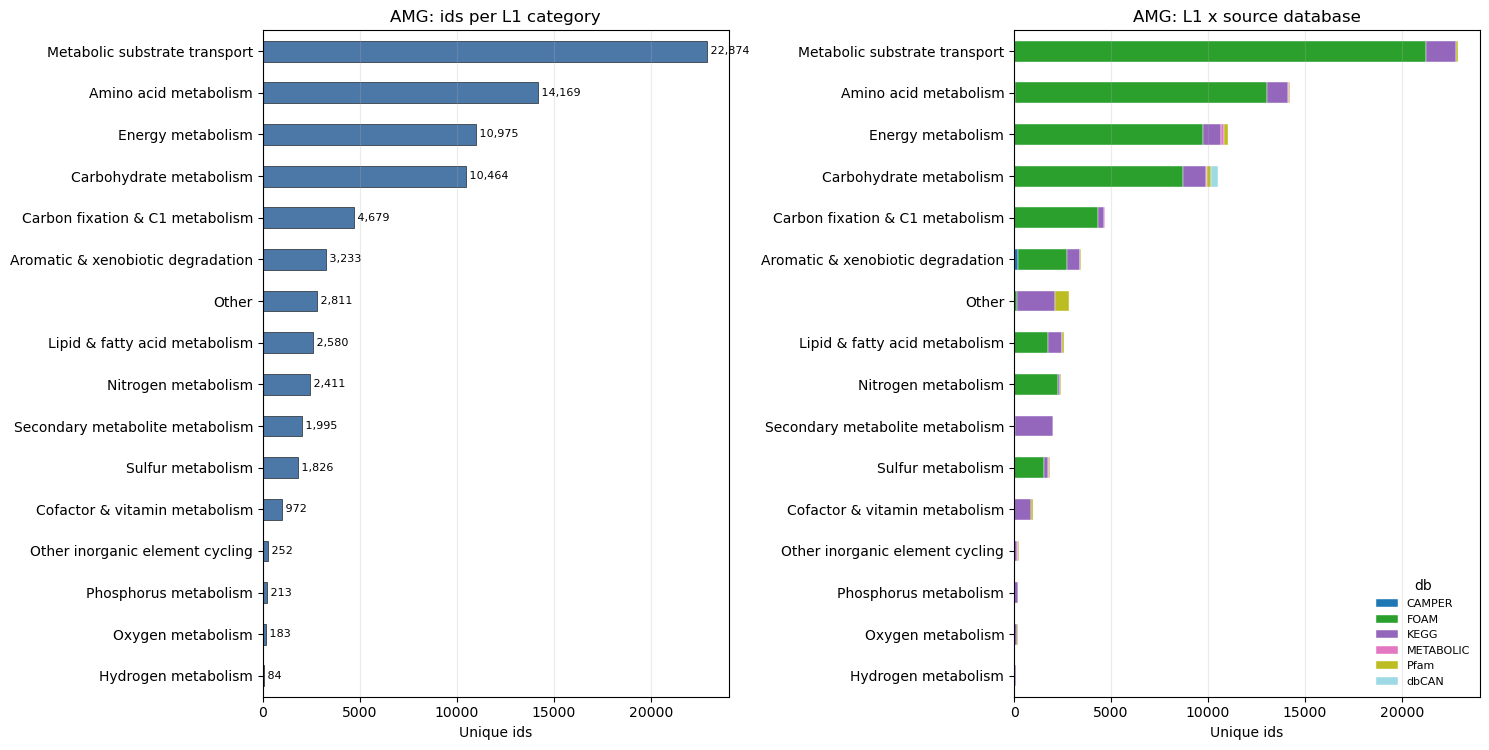

L1s per AMG id    median=1  mean=1.32  max=7

AMG L1 ids:
category_L1
Metabolic substrate transport        22874
Amino acid metabolism                14169
Energy metabolism                    10975
Carbohydrate metabolism              10464
Carbon fixation & C1 metabolism       4679
Aromatic & xenobiotic degradation     3233
Other                                 2811
Lipid & fatty acid metabolism         2580
Nitrogen metabolism                   2411
Secondary metabolite metabolism       1995
Sulfur metabolism                     1826
Cofactor & vitamin metabolism          972
Other inorganic element cycling        252
Phosphorus metabolism                  213
Oxygen metabolism                      183
Hydrogen metabolism                     84


In [409]:
amg_l1_counts, amg_l1_db = plot_l1_summary(AMGs_categorized_per_id, 'AMG')

# Multi-L1 distribution (how many distinct L1s per unique id)
n_l1_per_amg = (AMGs_categorized_per_id[['id', 'category_L1']]
                .drop_duplicates().groupby('id').size())
print(f"L1s per AMG id    median={n_l1_per_amg.median():.0f}  mean={n_l1_per_amg.mean():.2f}  max={n_l1_per_amg.max()}")
print()
print('AMG L1 ids:')
print(amg_l1_counts.to_string())

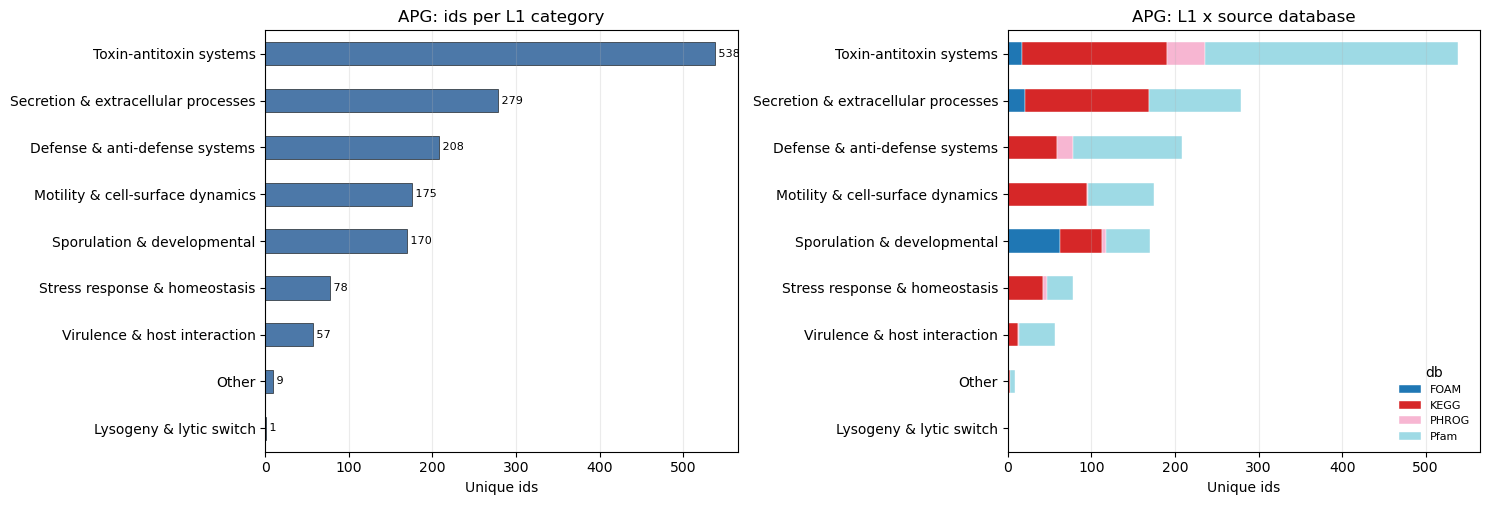

L1s per APG id    median=1  mean=1.00  max=2

APG L1 ids:
category_L1
Toxin-antitoxin systems                538
Secretion & extracellular processes    279
Defense & anti-defense systems         208
Motility & cell-surface dynamics       175
Sporulation & developmental            170
Stress response & homeostasis           78
Virulence & host interaction            57
Other                                    9
Lysogeny & lytic switch                  1


In [410]:
apg_l1_counts, apg_l1_db = plot_l1_summary(APGs_categorized_per_id, 'APG')

n_l1_per_apg = (APGs_categorized_per_id[['id', 'category_L1']]
                .drop_duplicates().groupby('id').size())
print(f"L1s per APG id    median={n_l1_per_apg.median():.0f}  mean={n_l1_per_apg.mean():.2f}  max={n_l1_per_apg.max()}")
print()
print('APG L1 ids:')
print(apg_l1_counts.to_string())

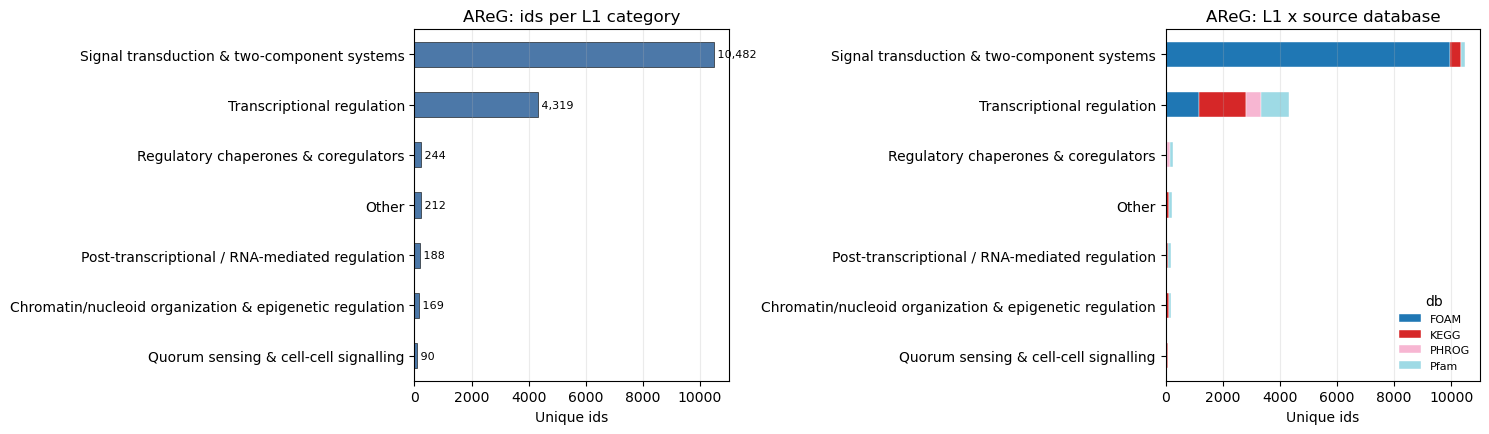

L1s per AReG id   median=1  mean=1.10  max=3

AReG L1 ids:
category_L1
Signal transduction & two-component systems                10482
Transcriptional regulation                                  4319
Regulatory chaperones & coregulators                         244
Other                                                        212
Post-transcriptional / RNA-mediated regulation               188
Chromatin/nucleoid organization & epigenetic regulation      169
Quorum sensing & cell-cell signalling                         90


In [411]:
areg_l1_counts, areg_l1_db = plot_l1_summary(AReGs_categorized_per_id, 'AReG')

n_l1_per_areg = (AReGs_categorized_per_id[['id', 'category_L1']]
                 .drop_duplicates().groupby('id').size())
print(f"L1s per AReG id   median={n_l1_per_areg.median():.0f}  mean={n_l1_per_areg.mean():.2f}  max={n_l1_per_areg.max()}")
print()
print('AReG L1 ids:')
print(areg_l1_counts.to_string())